<a href="https://colab.research.google.com/github/Fugant1/UMUSP-SemEval2026-Task9/blob/main/SemEvalDevPolar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering

## Unzip data

In [ ]:
!unzip test_phase.zip

Archive:  test_phase.zip
   creating: subtask1/
   creating: subtask1/test/
  inflating: subtask1/test/nep.csv   
  inflating: subtask1/test/ita.csv   
  inflating: subtask1/test/pol.csv   
  inflating: subtask1/test/rus.csv   
  inflating: subtask1/test/hin.csv   
  inflating: subtask1/test/tel.csv   
  inflating: subtask1/test/deu.csv   
  inflating: subtask1/test/fas.csv   
  inflating: subtask1/test/spa.csv   
  inflating: subtask1/test/ori.csv   
  inflating: subtask1/test/pan.csv   
  inflating: subtask1/test/hau.csv   
  inflating: subtask1/test/arb.csv   
  inflating: subtask1/test/amh.csv   
  inflating: subtask1/test/tur.csv   
  inflating: subtask1/test/zho.csv   
  inflating: subtask1/test/khm.csv   
  inflating: subtask1/test/ben.csv   
  inflating: subtask1/test/urd.csv   
  inflating: subtask1/test/swa.csv   
  inflating: subtask1/test/eng.csv   
  inflating: subtask1/test/mya.csv   
   creating: subtask1/dev/
  inflating: subtask1/dev/nep.csv    
  inflating: subtask1/d

## Imports

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

## Dataset prep

In [ ]:
task_columns = ["polarization", "political", "racial/ethnic", "religious", "gender/sexual", "other", "stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]

task1_columns = ["polarization"]
task2_columns = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]
task3_columns = ["stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]


In [ ]:
languages = [
    'arb', 'ben', 'mya', 'eng', 'hau', 'hin', 'nep', 'urd', 'zho', 'amh',
    'ori', 'fas', 'pol', 'pan', 'rus', 'spa', 'swa', 'tel', 'tur',
    'khm', 'deu', 'ita'
    ]
#the first and good result had no 'deu', 'ita', 'khm'
#'hau' is going bad too in the first training section

In [ ]:
def load_and_merge_robust(lang, split_name):
    """
    Loads Subtask 1 (Mandatory).
    If Subtask 2 or 3 are missing, fills their columns with 0.
    """
    # -------------------------------------------------------
    # A. Load Subtask 1 (The Anchor)
    # -------------------------------------------------------
    path_t1 = f'/content/subtask1/{split_name}/{lang}.csv'

    # If Task 1 is missing, we really can't do anything. Skip.
    if not os.path.exists(path_t1):
        if split_name == 'train': # Only warn for train, dev might be partial
            print(f"Skipping {lang.upper()}: No Subtask 1 file found.")
        return None

    # Load the anchor dataframe
    df = pd.read_csv(path_t1)

    # -------------------------------------------------------
    # B. Load Subtask 2 (Topic)
    # -------------------------------------------------------
    path_t2 = f'/content/subtask2/{split_name}/{lang}.csv'

    if os.path.exists(path_t2):
        df_t2 = pd.read_csv(path_t2)
        # LEFT MERGE: Keep all rows from Task 1. Match IDs from Task 2.
        df = df.merge(df_t2, on=['id', 'text'], how='left')
    else:
        # File missing? Fill columns with 0
        print(f"  -> {lang.upper()} missing Subtask 2. Filling columns with 0.")
        for col in task2_columns:
            df[col] = 0

    # -------------------------------------------------------
    # C. Load Subtask 3 (Critical Step for your missing files)
    # -------------------------------------------------------
    path_t3 = f'/content/subtask3/{split_name}/{lang}.csv'

    if os.path.exists(path_t3):
        df_t3 = pd.read_csv(path_t3)
        # LEFT MERGE again
        df = df.merge(df_t3, on=['id', 'text'], how='left')
    else:
        # This will trigger for ITA, MYA, POL, RUS
        print(f"  -> {lang.upper()} missing Subtask 3. Filling columns with 0.")
        for col in task3_columns:
            df[col] = 0

    # -------------------------------------------------------
    # D. Final Cleanup
    # -------------------------------------------------------
    # The merge might create NaNs if IDs didn't match perfectly. Fill them.
    df = df.fillna(0)

    # Tag the language
    df['language'] = lang

    return df

In [ ]:
df_train = None
df_val = None
train_frames = []
val_frames = []
for lang in languages:
    # Load Train
    df_train_lang = load_and_merge_robust(lang, 'train')
    if df_train_lang is not None:
        train_frames.append(df_train_lang)

    # Load Dev
    df_val_lang = load_and_merge_robust(lang, 'dev')
    if df_val_lang is not None:
        val_frames.append(df_val_lang)

  -> MYA missing Subtask 3. Filling columns with 0.
  -> MYA missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.
  -> ITA missing Subtask 3. Filling columns with 0.
  -> ITA missing Subtask 3. Filling columns with 0.


In [ ]:
train = pd.concat(train_frames, ignore_index=True)
val = pd.concat(val_frames, ignore_index=True)

In [ ]:
train['text'] = train['text'].astype(str)
val['text'] = val['text'].astype(str)

train = train[train['text'].str.strip().str.len() > 0]
val = val[val['text'].str.strip().str.len() > 0]

print(f"Cleaned Train Shape: {train.shape}")
print(f"Cleaned Val Shape: {val.shape}")

Cleaned Train Shape: (73681, 15)
Cleaned Val Shape: (3687, 15)


## Analysis

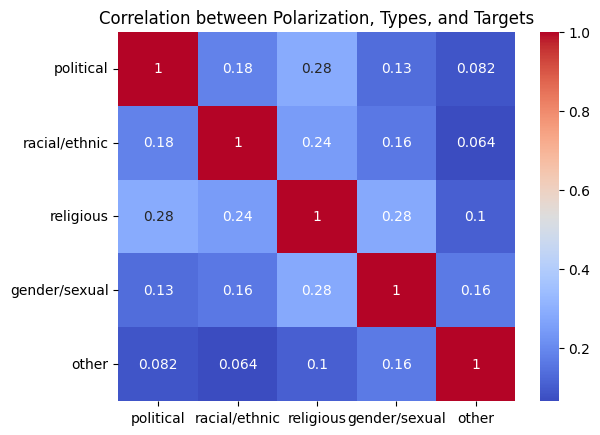

In [ ]:
corr_m = train[task2_columns].corr()
sns.heatmap(corr_m, annot=True, cmap='coolwarm')
plt.title("Correlation between Polarization, Types, and Targets")
plt.show()

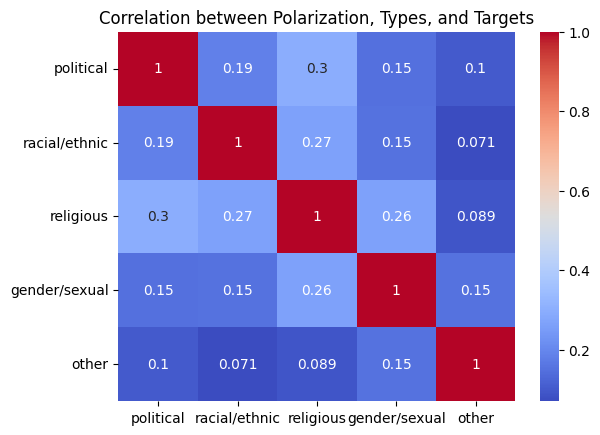

In [ ]:
corr_m = val[task2_columns].corr()
sns.heatmap(corr_m, annot=True, cmap='coolwarm')
plt.title("Correlation between Polarization, Types, and Targets")
plt.show()

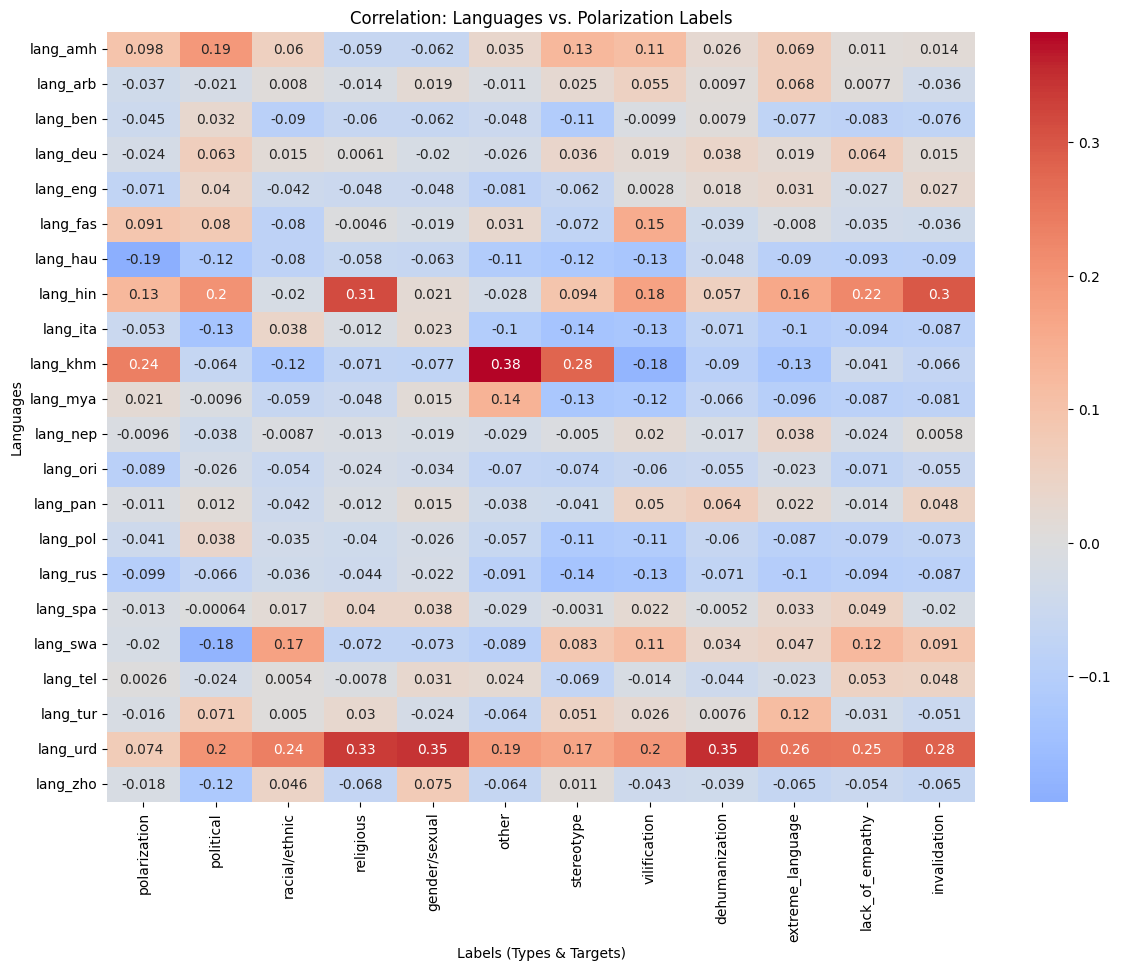

In [ ]:
lang_dummies = pd.get_dummies(train['language'], prefix='lang')

# 2. Combine with your 12 task columns
# Ensure task_columns = ['polarization', 'political', ..., 'invalidation']
correlation_df = pd.concat([lang_dummies, train[task_columns]], axis=1)

# 3. Calculate Correlation
# We specifically want the correlation BETWEEN languages and labels
# (filtering out lang-to-lang or label-to-label to keep it readable)
corr_m = correlation_df.corr().loc[lang_dummies.columns, task_columns]

# 4. Plot
plt.figure(figsize=(14, 10))
sns.heatmap(corr_m, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation: Languages vs. Polarization Labels")
plt.xlabel("Labels (Types & Targets)")
plt.ylabel("Languages")
plt.show()

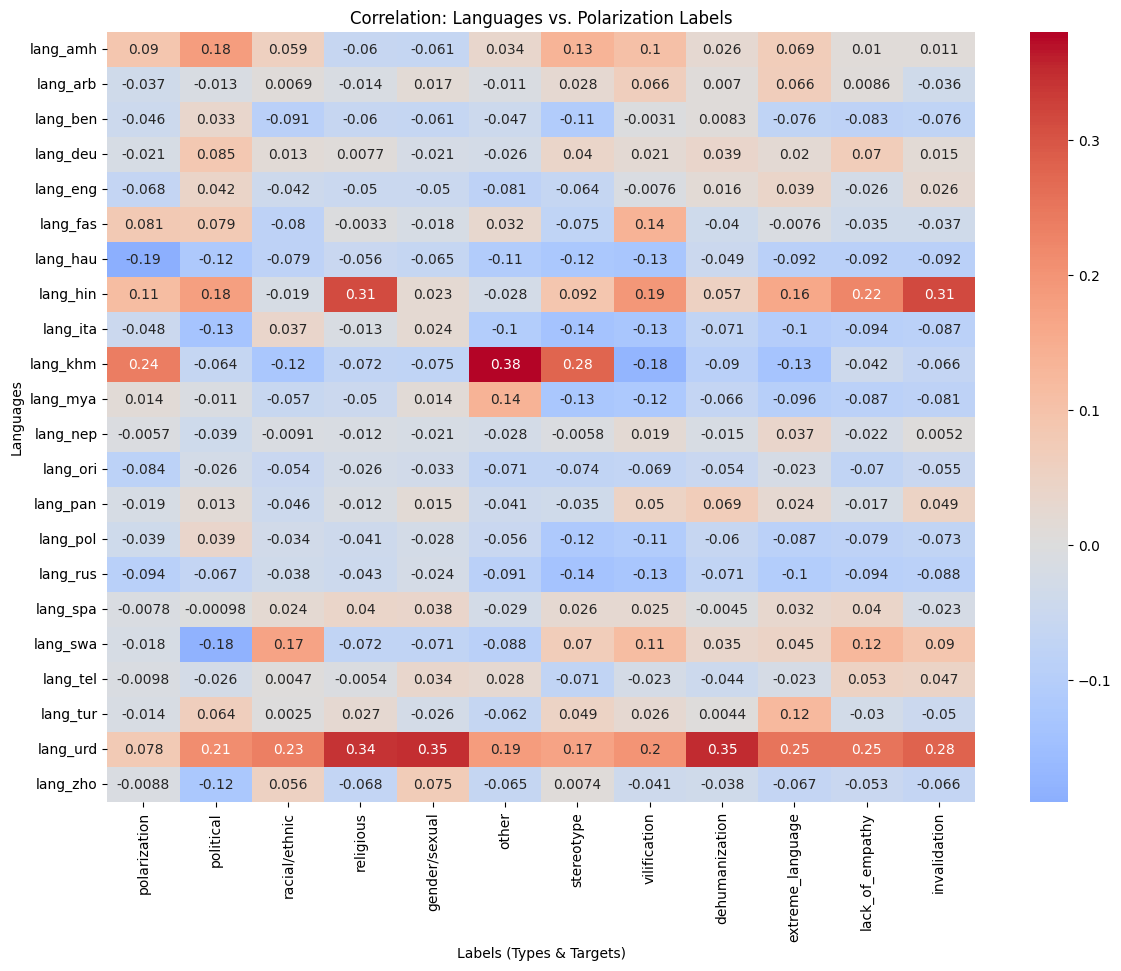

In [ ]:
lang_dummies = pd.get_dummies(val['language'], prefix='lang')

# 2. Combine with your 12 task columns
# Ensure task_columns = ['polarization', 'political', ..., 'invalidation']
correlation_df = pd.concat([lang_dummies, val[task_columns]], axis=1)

# 3. Calculate Correlation
# We specifically want the correlation BETWEEN languages and labels
# (filtering out lang-to-lang or label-to-label to keep it readable)
corr_m = correlation_df.corr().loc[lang_dummies.columns, task_columns]

# 4. Plot
plt.figure(figsize=(14, 10))
sns.heatmap(corr_m, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation: Languages vs. Polarization Labels")
plt.xlabel("Labels (Types & Targets)")
plt.ylabel("Languages")
plt.show()

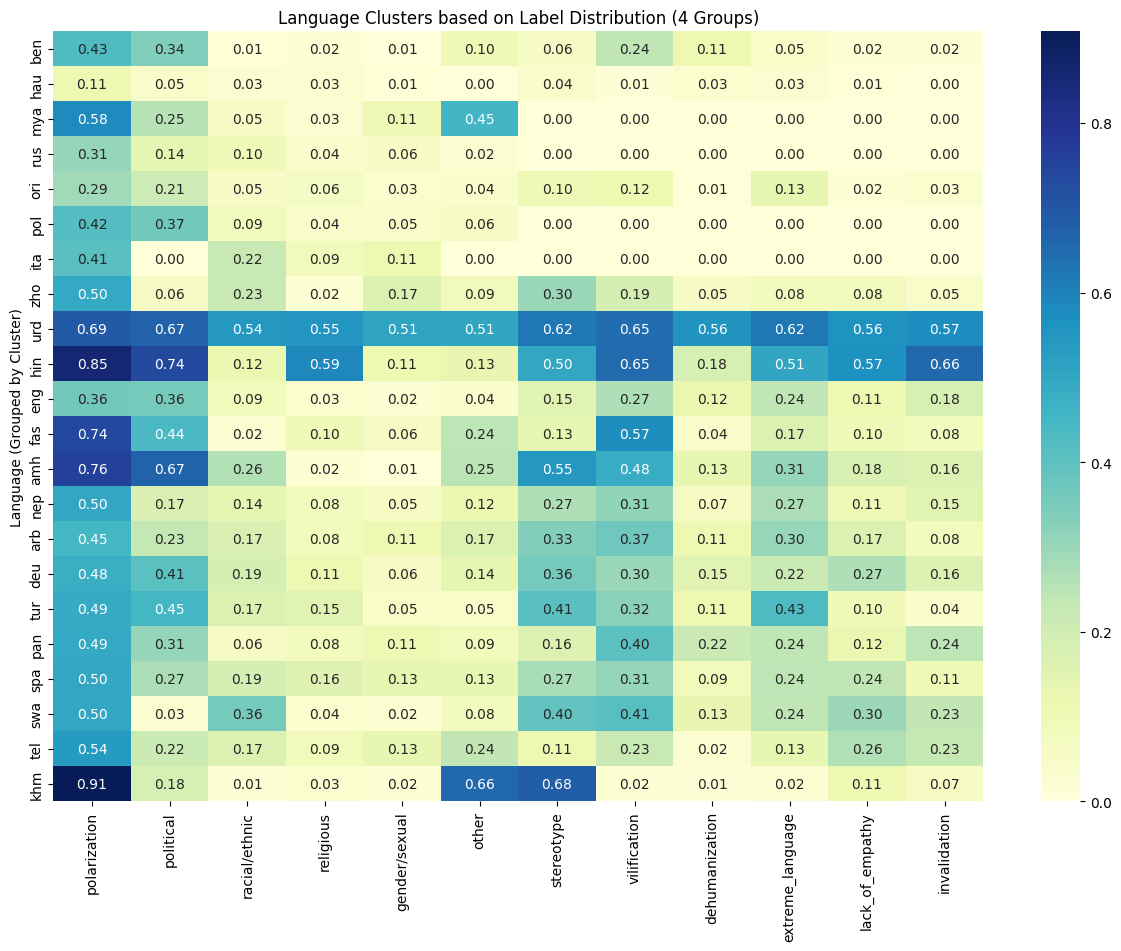

Power Model Group 0: ['ben', 'hau', 'mya', 'rus', 'ori', 'pol', 'ita', 'zho']
Power Model Group 1: ['urd', 'hin']
Power Model Group 2: ['eng', 'fas', 'amh', 'nep', 'arb', 'deu', 'tur', 'pan', 'spa', 'swa', 'tel']
Power Model Group 3: ['khm']


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

prevalence_matrix = train.groupby('language')[task_columns].mean()

scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(prevalence_matrix)

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
prevalence_matrix['cluster'] = kmeans.fit_predict(scaled_matrix)

prevalence_matrix = prevalence_matrix.sort_values('cluster')

plt.figure(figsize=(15, 10))
sns.heatmap(prevalence_matrix.drop(columns='cluster'),
            annot=True,
            cmap='YlGnBu',
            fmt=".2f")
plt.title(f"Language Clusters based on Label Distribution ({n_clusters} Groups)")
plt.ylabel("Language (Grouped by Cluster)")
plt.show()

for i in range(n_clusters):
    langs = prevalence_matrix[prevalence_matrix['cluster'] == i].index.tolist()
    print(f"Power Model Group {i}: {langs}")

# ----------------------------------------------------------------------

# TASK 1

# Baseline RoBERTa zho

## Unzip data

In [ ]:
!unzip dev_phase.zip

## Imports

In [ ]:
!pip install -q -U bitsandbytes --quiet

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np

import torch

from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType

from torch.utils.data import Dataset

In [ ]:
import wandb

wandb.init(mode="disabled")

## Dataset

In [ ]:
df = pd.read_csv('/content/subtask1/train/zho.csv')

In [ ]:
# Fix the dataset class by inheriting from torch.utils.data.Dataset
class PolarizationDataset(torch.utils.data.Dataset):
  def __init__(self,texts,labels,tokenizer,max_length =128):
    self.texts=texts
    self.labels=labels
    self.tokenizer= tokenizer
    self.max_length = max_length # Store max_length

  def __len__(self):
    return len(self.texts)

  def __getitem__(self,idx):
    text=self.texts[idx]
    label=self.labels[idx]
    encoding=self.tokenizer(text,truncation=True,padding=False,max_length=self.max_length,return_tensors='pt')

    # Ensure consistent tensor conversion for all items
    item = {key: encoding[key].squeeze() for key in encoding.keys()}
    item['labels'] = torch.tensor(label, dtype=torch.long)
    return item

In [ ]:
train, val = train_test_split(df, test_size=0.2, random_state=42, stratify=df['polarization'])

In [ ]:
print(len(train), len(val))

3424 856


In [ ]:
tokenizer = AutoTokenizer.from_pretrained('hfl/chinese-roberta-wwm-ext')

In [ ]:
train_dataset = PolarizationDataset(train['text'].tolist(), train['polarization'].tolist(), tokenizer)
val_dataset = PolarizationDataset(val['text'].tolist(), val['polarization'].tolist(), tokenizer)

## Model config

In [ ]:
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=4,
    lora_alpha=16,
    lora_dropout=0.2,
    bias="none",
    target_modules=["query", "key", "value", "dense"]
)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained('hfl/chinese-roberta-wwm-ext', num_labels=2)
model = get_peft_model(model, lora_config)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at hfl/chinese-roberta-wwm-ext and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Train

In [ ]:
# Define metrics function
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {'f1_macro': f1_score(p.label_ids, preds, average='macro')}

# Define training arguments
training_args = TrainingArguments(
        output_dir=f"./",
        num_train_epochs=10,
        weight_decay=0.1,
        optim="adamw_torch",
        label_smoothing_factor=0.1,
        learning_rate=2e-4,
        warmup_ratio=0.1,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=10,
        disable_tqdm=False,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=1
    )


In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=val_dataset,            # evaluation dataset
    compute_metrics=compute_metrics,     # the callback that computes metrics of interest
    data_collator=DataCollatorWithPadding(tokenizer), # Data collator for dynamic padding
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# Train the model
trainer.train()

# Evaluate the model on the validation set
eval_results = trainer.evaluate()
print(f"Macro F1 score on validation set: {eval_results['eval_f1_macro']}")

A ConfigError was raised whilst setting the number of model parameters in Weights & Biases config.


Epoch,Training Loss,Validation Loss,F1 Macro
1,0.490900,0.420050,0.856304
2,0.357200,0.395403,0.887526
3,0.302500,0.411794,0.894606
4,0.281000,0.417648,0.886678
5,0.295100,0.413690,0.897169


Macro F1 score on validation set: 0.8875256631354193


## Dev submission

In [ ]:
df_dev = pd.read_csv('/content/subtask1/dev/zho.csv')
df_dev['polarization'] = 0

In [ ]:
dev_dataset = PolarizationDataset(df_dev['text'].tolist(), df_dev['polarization'].tolist(), tokenizer)

In [ ]:
raw_pred, _, _ = trainer.predict(dev_dataset)

# 5. Convert Logits (probability scores) to Class IDs (0 or 1)
# axis=1 finds the highest score in each row
final_predictions = np.argmax(raw_pred, axis=1)

# 6. Save to CSV
submission = pd.DataFrame({
    'id': df_dev['id'], # Or df_dev['id'] if it exists
    'polarization': final_predictions
})

submission.to_csv('pred_zho.csv', index=False)
print("Submission saved successfully!")
print(submission.head())

Submission saved successfully!
                                     id  polarization
0  zho_3653010632292449856c11f234040704             1
1  zho_f186c48ab10bbad0110cc57f81929208             0
2  zho_cc96cfb2e302edf570548253578ced89             1
3  zho_6d06ab3b817c68c5bab057add5b06447             1
4  zho_ffe6eda7b6330733276218813605d369             1


In [ ]:
!zip -r /content/subtask_1.zip ./pred_zho.csv

  adding: subtask1/ (stored 0%)
  adding: subtask1/pred_zho.csv (deflated 48%)


# Encoder 19 languages

## Unzip data

In [ ]:
!unzip dev_phase.zip

Archive:  dev_phase.zip
   creating: subtask1/
   creating: subtask1/dev/
  inflating: subtask1/dev/nep.csv    
  inflating: subtask1/dev/ita.csv    
  inflating: subtask1/dev/pol.csv    
  inflating: subtask1/dev/rus.csv    
  inflating: subtask1/dev/tel.csv    
  inflating: subtask1/dev/hin.csv    
  inflating: subtask1/dev/hau.csv    
  inflating: subtask1/dev/pan.csv    
  inflating: subtask1/dev/ori.csv    
  inflating: subtask1/dev/spa.csv    
  inflating: subtask1/dev/deu.csv    
  inflating: subtask1/dev/fas.csv    
  inflating: subtask1/dev/arb.csv    
  inflating: subtask1/dev/ben.csv    
  inflating: subtask1/dev/amh.csv    
  inflating: subtask1/dev/khm.csv    
  inflating: subtask1/dev/tur.csv    
  inflating: subtask1/dev/zho.csv    
  inflating: subtask1/dev/eng.csv    
  inflating: subtask1/dev/swa.csv    
  inflating: subtask1/dev/urd.csv    
  inflating: subtask1/dev/mya.csv    
   creating: subtask1/train/
  inflating: subtask1/train/nep.csv  
  inflating: subtask1/t

## Imports

In [ ]:
!pip install -q -U bitsandbytes --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 25.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np

import torch
import torch.nn as nn

from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType

from torch.utils.data import Dataset

import shutil
from google.colab import files

In [ ]:
import wandb

wandb.init(mode="disabled")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


## Dataset

In [ ]:
languages = [
    'arb', 'ben', 'mya', 'eng', 'hin', 'nep', 'urd', 'rus', 'hau', 'amh'
    'ori', 'fas', 'pol', 'pan', 'spa', 'swa', 'tel', 'tur', 'zho'
]
#removi 'ita', 'deu', 'khm'

In [ ]:
df = None
for lang in languages:
  df_temp = pd.read_csv(f'/content/subtask1/train/{lang}.csv')
  df_temp['language'] = lang
  if df is None:
    df = df_temp
  else:
    df = pd.concat([df, df_temp], ignore_index=True)

In [ ]:
df.shape

(53544, 4)

In [ ]:
import re
import html
def clean_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Unescape HTML (e.g., "&amp;" -> "&", "&quot;" -> '"')
    text = html.unescape(text)

    # 2. Remove URLs (http://...)
    # We use \S+ to catch the whole link until a space
    text = re.sub(r'http\S+', '', text)

    # 3. Remove User Mentions (@username)
    # We use @\S+ to ensure we catch mentions in any language script
    text = re.sub(r'@\S+', '', text)

    # 4. Remove HTML Tags (<br>, <div>, etc.) if any exist
    text = re.sub(r'<.*?>', '', text)

    # 5. Fix Whitespace (Turn "Hello   World" into "Hello World")
    text = re.sub(r'\s+', ' ', text).strip()

    # NOTE: We do NOT remove punctuation or emojis.
    # In polarization detection, "!!!" or "😡" are strong signals.

    return text

In [ ]:
df['text'] = df['text'].apply(clean_text)

In [ ]:
df.shape

(53544, 4)

In [ ]:
# Fix the dataset class by inheriting from torch.utils.data.Dataset
class PolarizationDataset(torch.utils.data.Dataset):
  def __init__(self,texts,labels,tokenizer,max_length =256):
    self.texts=texts
    self.labels=labels
    self.tokenizer= tokenizer
    self.max_length = max_length # Store max_length

  def __len__(self):
    return len(self.texts)

  def __getitem__(self,idx):
    text=self.texts[idx]
    label=self.labels[idx]
    encoding=self.tokenizer(text,truncation=True,padding=False,max_length=self.max_length,return_tensors='pt')

    # Ensure consistent tensor conversion for all items
    item = {key: encoding[key].squeeze() for key in encoding.keys()}
    item['labels'] = torch.tensor(label, dtype=torch.long)
    return item

In [ ]:
df['stratify_col'] = df['language'].astype(str) + "_" + df['polarization'].astype(str)

counts = df['stratify_col'].value_counts()
single_samples = counts[counts < 2].index.tolist()

df_splitable = df[~df['stratify_col'].isin(single_samples)]
df_singles = df[df['stratify_col'].isin(single_samples)]

In [ ]:
train, val = train_test_split(df, test_size=0.2, random_state=42, stratify=df_splitable['stratify_col'])
df_train = pd.concat([train, df_singles], ignore_index=True)

In [ ]:
print(len(train), len(val))

42835 10709


In [ ]:
tokenizer = AutoTokenizer.from_pretrained('FacebookAI/xlm-roberta-large')

In [ ]:
train_dataset = PolarizationDataset(train['text'].tolist(), train['polarization'].tolist(), tokenizer)
val_dataset = PolarizationDataset(val['text'].tolist(), val['polarization'].tolist(), tokenizer)

## Model config

In [ ]:
# lora_config = LoraConfig(
#     task_type=TaskType.SEQ_CLS,
#     r=64,
#     lora_alpha=128,
#     lora_dropout=0.1,
#     bias="none",
#     target_modules=["query", "key", "value", "dense"]
# )

In [ ]:
config = AutoConfig.from_pretrained('FacebookAI/xlm-roberta-large')
config.hidden_dropout_prob = 0.2
config.attention_probs_dropout_prob = 0.2
config.classifier_dropout = 0.3
config.num_labels = 2  # ← Set it HERE in the config

model = AutoModelForSequenceClassification.from_pretrained(
    'FacebookAI/xlm-roberta-large',
    config=config  # Don't pass num_labels again
)
#model = get_peft_model(model, lora_config)

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Train

In [ ]:
# Define metrics function
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {'f1_macro': f1_score(p.label_ids, preds, average='macro')}

# Define training arguments
training_args = TrainingArguments(
        output_dir=f"./",
        num_train_epochs=10,
        weight_decay=0.1,
        max_grad_norm=1.0,
        bf16=True,
        tf32=True,
        optim="adamw_torch_fused",
        label_smoothing_factor=0.1,
        learning_rate=1.5e-5,
        warmup_ratio=0.08,
        per_device_train_batch_size=64,
        per_device_eval_batch_size=128,
        gradient_accumulation_steps=1,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,
        disable_tqdm=False,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        dataloader_num_workers=8,
        dataloader_pin_memory=True,
        lr_scheduler_type = "cosine",
        seed=42,
    )


In [ ]:
class FocalLoss(nn.Module):
    """
    Focal Loss for handling class imbalance
    Automatically focuses on hard examples and minority classes
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean', **kwargs):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


class FocalLossTrainer(Trainer):
    """Custom Trainer with Focal Loss"""
    def __init__(self, *args, focal_alpha=0.25, focal_gamma=2.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.focal_loss = FocalLoss(alpha=focal_alpha, gamma=focal_gamma)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss = self.focal_loss(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [ ]:
llrd_decay = 0.95
learning_rate = 1.5e-5

# 2. Function to group parameters
def get_optimizer_grouped_parameters(model, learning_rate, weight_decay, lr_decay):
    no_decay = ["bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters() if "classifier" in n],
            "weight_decay": 0.0,
            "lr": learning_rate
        },
    ]
    # XLM-R uses 'model.roberta'
    layers = [model.roberta.embeddings] + list(model.roberta.encoder.layer)
    layers.reverse()

    lr = learning_rate
    for layer in layers:
        lr *= lr_decay
        optimizer_grouped_parameters += [
            {
                "params": [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)],
                "weight_decay": weight_decay,
                "lr": lr,
            },
            {
                "params": [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)],
                "weight_decay": 0.0,
                "lr": lr,
            },
        ]
    return optimizer_grouped_parameters

# 3. Create the Optimizer
opt_params = get_optimizer_grouped_parameters(model, learning_rate, 0.1, llrd_decay)
optimizer = torch.optim.AdamW(opt_params, lr=learning_rate)

In [ ]:
# Initialize the Trainer
trainer = FocalLossTrainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=val_dataset,            # evaluation dataset
    compute_metrics=compute_metrics,     # the callback that computes metrics of interest
    data_collator=DataCollatorWithPadding(tokenizer), # Data collator for dynamic padding
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.01)],
    optimizers=(optimizer, None),
    focal_alpha=0.25,  # Focal loss parameters
    focal_gamma=2.0
)

# Train the model
trainer.train()

# Evaluate the model on the validation set
eval_results = trainer.evaluate()
print(f"Macro F1 score on validation set: {eval_results['eval_f1_macro']}")

Epoch,Training Loss,Validation Loss,F1 Macro
1,0.039900,0.032363,0.755708
2,0.034900,0.030225,0.788213
3,0.032900,0.029186,0.795872
4,0.030600,0.028695,0.808844
5,0.027900,0.028179,0.815376
6,0.026700,0.027382,0.817694


Macro F1 score on validation set: 0.8176935738944613


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
import torch

# Evaluate per language
def evaluate_per_language(trainer, tokenizer, df_val, languages):
    """
    Evaluate model performance for each language separately

    Args:
        trainer: Trained Hugging Face Trainer object
        tokenizer: Tokenizer used for the model
        df_val: Validation dataframe with 'text', 'polarization', and 'language' columns
        languages: List of language codes to evaluate
    """
    results = []

    print("=" * 80)
    print("PER-LANGUAGE EVALUATION RESULTS")
    print("=" * 80)

    for lang in languages:
        # Filter data for this language
        df_lang = df_val[df_val['language'] == lang]

        if len(df_lang) == 0:
            print(f"\n{lang.upper()}: No samples found - SKIPPED")
            continue

        # Create dataset for this language
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang['polarization'].tolist(),
            tokenizer
        )

        # Get predictions
        raw_pred, labels, _ = trainer.predict(lang_dataset)
        predictions = np.argmax(raw_pred, axis=1)

        # Calculate metrics
        f1_macro = f1_score(labels, predictions, average='macro')
        f1_binary = f1_score(labels, predictions, average='binary')
        precision = precision_score(labels, predictions, average='macro')
        recall = recall_score(labels, predictions, average='macro')

        # Class distribution
        true_dist = pd.Series(labels).value_counts().to_dict()
        pred_dist = pd.Series(predictions).value_counts().to_dict()

        # Store results
        results.append({
            'language': lang,
            'samples': len(df_lang),
            'f1_macro': f1_macro,
            'f1_binary': f1_binary,
            'precision': precision,
            'recall': recall,
            'true_0': true_dist.get(0, 0),
            'true_1': true_dist.get(1, 0),
            'pred_0': pred_dist.get(0, 0),
            'pred_1': pred_dist.get(1, 0)
        })

        # Print detailed results for this language
        print(f"\n{lang.upper()} ({len(df_lang)} samples)")
        print(f"  F1-Macro:     {f1_macro:.4f}")
        print(f"  F1-Binary:    {f1_binary:.4f}")
        print(f"  Precision:    {precision:.4f}")
        print(f"  Recall:       {recall:.4f}")
        print(f"  True labels:  [0: {true_dist.get(0, 0)}, 1: {true_dist.get(1, 0)}]")
        print(f"  Predictions:  [0: {pred_dist.get(0, 0)}, 1: {pred_dist.get(1, 0)}]")

    # Create summary dataframe
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('f1_macro')

    print("\n" + "=" * 80)
    print("SUMMARY TABLE (sorted by F1-Macro, worst to best)")
    print("=" * 80)
    print(results_df.to_string(index=False))

    print("\n" + "=" * 80)
    print("POTENTIAL ANNOTATION PROBLEMS (F1-Macro < 0.60)")
    print("=" * 80)
    problematic = results_df[results_df['f1_macro'] < 0.60]
    if len(problematic) > 0:
        print(problematic[['language', 'samples', 'f1_macro', 'true_0', 'true_1']].to_string(index=False))
    else:
        print("No languages with F1-Macro < 0.60 detected!")

    return results_df


# Usage after training:
# Assuming you have: trainer, tokenizer, val (validation df), and languages list

# For validation set evaluation (Chinese only in your case)
print("\nEVALUATING ON VALIDATION SET (Chinese)")
val_results = evaluate_per_language(trainer, tokenizer, val, languages)

# For evaluating on ALL languages (use training data as proxy)
print("\n\nEVALUATING ON ALL TRAINING LANGUAGES")
train_results = evaluate_per_language(trainer, tokenizer, train, languages)

# Save results to CSV
val_results.to_csv('language_f1_scores_val.csv', index=False)
train_results.to_csv('language_f1_scores_train.csv', index=False)
print("\nResults saved to 'language_f1_scores_val.csv' and 'language_f1_scores_train.csv'")


EVALUATING ON VALIDATION SET (Chinese)
PER-LANGUAGE EVALUATION RESULTS



ARB (676 samples)
  F1-Macro:     0.7934
  F1-Binary:    0.7650
  Precision:    0.7968
  Recall:       0.7917
  True labels:  [0: 374, 1: 302]
  Predictions:  [0: 395, 1: 281]



BEN (667 samples)
  F1-Macro:     0.8399
  F1-Binary:    0.8193
  Precision:    0.8387
  Recall:       0.8416
  True labels:  [0: 382, 1: 285]
  Predictions:  [0: 371, 1: 296]



MYA (577 samples)
  F1-Macro:     0.8698
  F1-Binary:    0.8858
  Precision:    0.8675
  Recall:       0.8752
  True labels:  [0: 241, 1: 336]
  Predictions:  [0: 265, 1: 312]



ENG (644 samples)
  F1-Macro:     0.7948
  F1-Binary:    0.7302
  Precision:    0.8063
  Recall:       0.7875
  True labels:  [0: 409, 1: 235]
  Predictions:  [0: 438, 1: 206]


...


SPA (2644 samples)
  F1-Macro:     0.8003
  F1-Binary:    0.7974
  Precision:    0.8007
  Recall:       0.8004
  True labels:  [0: 1316, 1: 1328]
  Predictions:  [0: 1366, 1: 1278]



SWA (5593 samples)
  F1-Macro:     0.7686
  F1-Binary:    0.7657
  Precision:    0.7689
  Recall:       0.7687
  True labels:  [0: 2790, 1: 2803]
  Predictions:  [0: 2872, 1: 2721]



TEL (1893 samples)
  F1-Macro:     0.8755
  F1-Binary:    0.8862
  Precision:    0.8762
  Recall:       0.8749
  True labels:  [0: 874, 1: 1019]
  Predictions:  [0: 856, 1: 1037]



TUR (1891 samples)
  F1-Macro:     0.8517
  F1-Binary:    0.8458
  Precision:    0.8524
  Recall:       0.8515
  True labels:  [0: 967, 1: 924]
  Predictions:  [0: 999, 1: 892]



ZHO (3424 samples)
  F1-Macro:     0.9474
  F1-Binary:    0.9461
  Precision:    0.9479
  Recall:       0.9473
  True labels:  [0: 1727, 1: 1697]
  Predictions:  [0: 1779, 1: 1645]

SUMMARY TABLE (sorted by F1-Macro, worst to best)
language  samples  f1_macro  f1_binary  precision   recall  true_0  true_1  pred_0  pred_1
     swa     5593  0.768604   0.765749   0.768867 0.768672    2790    2803    2872    2721
     pan     1360  0.789702   0.788774   0.789726 0.789763     688     672     678     682
     spa     2644  0.800261   0.797391   0.800711 0.800384    1316    1328    1366    1278
     urd     2851  0.812607   0.885238   0.812013 0.813213     870    1981     876    1975
     fas     2636  0.814115   0.900570   0.808541 0.820441     684    1952     726    1910
     hin     2195  0.823534   0.959320   0.926892 0.769856     318    1877     188    2007
     ori     1894  0.833480   0.752066   0.869459 0.811820    1348     546    1472     422
     arb     2704  0.842694   0.820645 

## Dev submission

In [ ]:
df_dev = None
for lang in languages:
    df_temp = pd.read_csv(f'/content/subtask1/dev/{lang}.csv')
    df_temp['language'] = lang
    if df_dev is None:
        df_dev = df_temp
    else:
        df_dev = pd.concat([df_dev, df_temp], ignore_index=True)

dev_dataset = PolarizationDataset(df_dev['text'].tolist(), df_dev['polarization'].tolist(), tokenizer)

raw_pred, _, _ = trainer.predict(dev_dataset)
final_predictions = np.argmax(raw_pred, axis=1)

submission = pd.DataFrame({
    'id': df_dev['id'],
    'polarization': final_predictions
})

In [ ]:
df_dev = None
for lang in languages:
  df_temp = pd.read_csv(f'/content/subtask1/dev/{lang}.csv')
  df_temp['language'] = lang
  if df_dev is None:
    df_dev = df_temp
  else:
    df_dev = pd.concat([df_dev, df_temp], ignore_index=True)

In [ ]:
submission.to_csv('pred_langs.csv', index=False)
print("Submission saved to pred_langs.csv")

# Create Zip (Fixed filename)
!zip -j /content/subtask_1.zip ./pred_langs.csv

In [ ]:
files.download('subtask_1.zip')

## Save model

In [ ]:
# 1. Save the adapter + config
save_path = "./final_model_adapter"
trainer.save_model(save_path)

# 2. Don't forget the tokenizer!
tokenizer.save_pretrained(save_path)

print(f"Adapter model saved to {save_path}")

In [ ]:
#merged_model = trainer.model.merge_and_unload()

# 2. Save the full huge model
full_save_path = "./final_model_full"
model.save_pretrained(full_save_path)
tokenizer.save_pretrained(full_save_path)

print(f"Full model saved to {full_save_path}")

In [ ]:
shutil.make_archive('my_best_model', 'zip', './final_model_adapter')

# 2. Trigger the download in your browser
files.download('my_best_model.zip')

# XLM-RoBERTa Language families

## Unzip data

In [ ]:
!unzip dev_phase.zip

Archive:  dev_phase.zip
   creating: subtask1/
   creating: subtask1/dev/
  inflating: subtask1/dev/nep.csv    
  inflating: subtask1/dev/ita.csv    
  inflating: subtask1/dev/pol.csv    
  inflating: subtask1/dev/rus.csv    
  inflating: subtask1/dev/tel.csv    
  inflating: subtask1/dev/hin.csv    
  inflating: subtask1/dev/hau.csv    
  inflating: subtask1/dev/pan.csv    
  inflating: subtask1/dev/ori.csv    
  inflating: subtask1/dev/spa.csv    
  inflating: subtask1/dev/deu.csv    
  inflating: subtask1/dev/fas.csv    
  inflating: subtask1/dev/arb.csv    
  inflating: subtask1/dev/ben.csv    
  inflating: subtask1/dev/amh.csv    
  inflating: subtask1/dev/khm.csv    
  inflating: subtask1/dev/tur.csv    
  inflating: subtask1/dev/zho.csv    
  inflating: subtask1/dev/eng.csv    
  inflating: subtask1/dev/swa.csv    
  inflating: subtask1/dev/urd.csv    
  inflating: subtask1/dev/mya.csv    
   creating: subtask1/train/
  inflating: subtask1/train/nep.csv  
  inflating: subtask1/t

## Imports

In [ ]:
!pip install -q -U bitsandbytes --quiet

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np

import torch

from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType

from torch.utils.data import Dataset

import shutil
from google.colab import files

In [ ]:
import wandb

wandb.init(mode="disabled")

## Dataset

In [ ]:
# Group 1: Latin & Cyrillic ("The Western Model")
# Shared alphabet or high-resource western structure.
# 'rus' (Cyrillic) is included here because it pairs well with 'pol' (Slavic).
group_standard = [
    'eng',  # English (Base language, simple morphology)
    'spa',  # Spanish (Inflectional, but easy for tokenizers)
    'rus',  # Russian (Distinct alphabet acts as a buffer)
    'pol',  # Polish (Complex, but if it's not failing, keep it here)
    'swa'   # Swahili (Agglutinative, but usually tokenizes cleaner than Turkish)
]
#vou remover ita, pq estão com resultados ridiculos, o modelo não entende
#removi hau incialmente, mas os resultados pioraram, então vou testar só removendo ita, já
#que o italiano parece um problema nessa competição

group_complex = [
    'deu',  # German (Compounding words -> needs long tokens)
    'tur',  # Turkish (Agglutinative -> needs suffix tokens)
    'hau'   # Hausa (Special characters -> needs specific vocab)
]

# Group 2: Indic, Semitic & Arabic Script ("The South-Central Model")
# These languages share intricate scripts and often overlap in cultural context.
# 'urd' is here because it shares script with 'arb'/'fas', even though spoken like 'hin'.
group_central = [
    'arb', 'fas', 'urd', 'amh',           # Semitic / Perso-Arabic / Ge'ez
    'hin', 'ben', 'nep', 'ori', 'pan', 'tel' # Indic / Dravidian
]

# Group 3: East Asian & Logographic ("The Eastern Model")
# These require distinct tokenization (no spaces, syllable blocks).
# This isolates 'zho' so it doesn't crush the other languages.
group_eastern = [
    'mya', 'khm'
]

others = [
    'ita', 'zho'
    ]
#chinês provavelmente vai acabar ficando separado, já que nenhuma língua tem um tokenizer semelhante

In [ ]:
df = None
for lang in group_standard:
  df_temp = pd.read_csv(f'/content/subtask1/train/{lang}.csv')
  df_temp['language'] = lang
  if df is None:
    df = df_temp
  else:
    df = pd.concat([df, df_temp], ignore_index=True)

In [ ]:
df.shape

(19257, 4)

In [ ]:
import re
import html
def clean_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Unescape HTML (e.g., "&amp;" -> "&", "&quot;" -> '"')
    text = html.unescape(text)

    # 2. Remove URLs (http://...)
    # We use \S+ to catch the whole link until a space
    text = re.sub(r'http\S+', '', text)

    # 3. Remove User Mentions (@username)
    # We use @\S+ to ensure we catch mentions in any language script
    text = re.sub(r'@\S+', '', text)

    # 4. Remove HTML Tags (<br>, <div>, etc.) if any exist
    text = re.sub(r'<.*?>', '', text)

    # 5. Fix Whitespace (Turn "Hello   World" into "Hello World")
    text = re.sub(r'\s+', ' ', text).strip()

    # NOTE: We do NOT remove punctuation or emojis.
    # In polarization detection, "!!!" or "😡" are strong signals.

    return text

In [ ]:
df['text'] = df['text'].apply(clean_text)

In [ ]:
df.shape

(19257, 4)

In [ ]:
# Fix the dataset class by inheriting from torch.utils.data.Dataset
class PolarizationDataset(torch.utils.data.Dataset):
  def __init__(self,texts,labels,tokenizer,max_length =256):
    self.texts=texts
    self.labels=labels
    self.tokenizer= tokenizer
    self.max_length = max_length # Store max_length

  def __len__(self):
    return len(self.texts)

  def __getitem__(self,idx):
    text=self.texts[idx]
    label=self.labels[idx]
    encoding=self.tokenizer(text,truncation=True,padding=False,max_length=self.max_length,return_tensors='pt')

    # Ensure consistent tensor conversion for all items
    item = {key: encoding[key].squeeze() for key in encoding.keys()}
    item['labels'] = torch.tensor(label, dtype=torch.long)
    return item

In [ ]:
df['stratify_col'] = df['language'].astype(str) + "_" + df['polarization'].astype(str)

counts = df['stratify_col'].value_counts()
single_samples = counts[counts < 2].index.tolist()

df_splitable = df[~df['stratify_col'].isin(single_samples)]
df_singles = df[df['stratify_col'].isin(single_samples)]

In [ ]:
train, val = train_test_split(df, test_size=0.2, random_state=42, stratify=df_splitable['stratify_col'])
df_train = pd.concat([train, df_singles], ignore_index=True)

In [ ]:
print(len(train), len(val))

15405 3852


In [ ]:
tokenizer = AutoTokenizer.from_pretrained('FacebookAI/xlm-roberta-large')

In [ ]:
train_dataset = PolarizationDataset(train['text'].tolist(), train['polarization'].tolist(), tokenizer)
val_dataset = PolarizationDataset(val['text'].tolist(), val['polarization'].tolist(), tokenizer)

## Model config

In [ ]:
# lora_config = LoraConfig(
#     task_type=TaskType.SEQ_CLS,
#     r=64,
#     lora_alpha=128,
#     lora_dropout=0.1,
#     bias="none",
#     target_modules=["query", "key", "value", "dense"]
# )

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained('FacebookAI/xlm-roberta-large', num_labels=2)
#model = get_peft_model(model, lora_config)

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Train

In [ ]:
# Define metrics function
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {'f1_macro': f1_score(p.label_ids, preds, average='macro')}

# Define training arguments
training_args = TrainingArguments(
        num_train_epochs=5,              # Reduced from 10 (Critical)
        warmup_ratio=0.1,                # Slightly higher warmup for stability
        learning_rate=1.5e-5,            # Slightly lower peak LR for "Large" model
        weight_decay=0.05,               # 0.1 is aggressive; 0.05 is standard for Large
        label_smoothing_factor=0.1,

        # 2. A100 40GB VRAM Optimization
        per_device_train_batch_size=32,  # 64 is risky for VRAM. 32 is safe.
        gradient_accumulation_steps=2,   # 32 * 2 = 64 Effective Batch Size
        per_device_eval_batch_size=128,   # 32 is safe.

        # 3. Speed & Precision
        bf16=True,                       # Native A100 precision
        tf32=True,                       # TensorFloat-32 (Fast Matrix Math)
        optim="adamw_torch_fused",            # Faster compilation

        # 4. Evaluation Strategy (Catch the peak)
        eval_strategy="steps",           # Don't wait for epoch end
        eval_steps=300,                  # Check every ~25% of an epoch
        save_strategy="steps",
        save_steps=300,
        logging_steps=25,

        # 5. Standard
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        dataloader_num_workers=8,
        dataloader_pin_memory=True,
        seed=42
    )


In [ ]:
llrd_decay = 0.90
learning_rate = 1.5e-5 # Peak LR for top layers

# 2. Function to group parameters
def get_optimizer_grouped_parameters(model, learning_rate, weight_decay, lr_decay):
    no_decay = ["bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters() if "classifier" in n],
            "weight_decay": 0.0,
            "lr": learning_rate
        },
    ]
    # XLM-R uses 'model.roberta'
    layers = [model.roberta.embeddings] + list(model.roberta.encoder.layer)
    layers.reverse()

    lr = learning_rate
    for layer in layers:
        lr *= lr_decay
        optimizer_grouped_parameters += [
            {
                "params": [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)],
                "weight_decay": weight_decay,
                "lr": lr,
            },
            {
                "params": [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)],
                "weight_decay": 0.0,
                "lr": lr,
            },
        ]
    return optimizer_grouped_parameters

# 3. Create the Optimizer
opt_params = get_optimizer_grouped_parameters(model, learning_rate, 0.1, llrd_decay)
optimizer = torch.optim.AdamW(opt_params, lr=learning_rate)

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=val_dataset,            # evaluation dataset
    compute_metrics=compute_metrics,     # the callback that computes metrics of interest
    data_collator=DataCollatorWithPadding(tokenizer), # Data collator for dynamic padding
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.001)],
    optimizers=(optimizer, None)
)

# Train the model
trainer.train()

# Evaluate the model on the validation set
eval_results = trainer.evaluate()
print(f"Macro F1 score on validation set: {eval_results['eval_f1_macro']}")

Step,Training Loss,Validation Loss,F1 Macro
300,0.573200,0.534430,0.759186
600,0.504900,0.525787,0.779716
900,0.477900,0.523975,0.776381
1200,0.475800,0.512872,0.784616


Macro F1 score on validation set: 0.7846156812463245


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
import torch

# Evaluate per language
def evaluate_per_language(trainer, tokenizer, df_val, languages):
    """
    Evaluate model performance for each language separately

    Args:
        trainer: Trained Hugging Face Trainer object
        tokenizer: Tokenizer used for the model
        df_val: Validation dataframe with 'text', 'polarization', and 'language' columns
        languages: List of language codes to evaluate
    """
    results = []

    print("=" * 80)
    print("PER-LANGUAGE EVALUATION RESULTS")
    print("=" * 80)

    for lang in languages:
        # Filter data for this language
        df_lang = df_val[df_val['language'] == lang]

        if len(df_lang) == 0:
            print(f"\n{lang.upper()}: No samples found - SKIPPED")
            continue

        # Create dataset for this language
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang['polarization'].tolist(),
            tokenizer
        )

        # Get predictions
        raw_pred, labels, _ = trainer.predict(lang_dataset)
        predictions = np.argmax(raw_pred, axis=1)

        # Calculate metrics
        f1_macro = f1_score(labels, predictions, average='macro')
        f1_binary = f1_score(labels, predictions, average='binary')
        precision = precision_score(labels, predictions, average='macro')
        recall = recall_score(labels, predictions, average='macro')

        # Class distribution
        true_dist = pd.Series(labels).value_counts().to_dict()
        pred_dist = pd.Series(predictions).value_counts().to_dict()

        # Store results
        results.append({
            'language': lang,
            'samples': len(df_lang),
            'f1_macro': f1_macro,
            'f1_binary': f1_binary,
            'precision': precision,
            'recall': recall,
            'true_0': true_dist.get(0, 0),
            'true_1': true_dist.get(1, 0),
            'pred_0': pred_dist.get(0, 0),
            'pred_1': pred_dist.get(1, 0)
        })

        # Print detailed results for this language
        print(f"\n{lang.upper()} ({len(df_lang)} samples)")
        print(f"  F1-Macro:     {f1_macro:.4f}")
        print(f"  F1-Binary:    {f1_binary:.4f}")
        print(f"  Precision:    {precision:.4f}")
        print(f"  Recall:       {recall:.4f}")
        print(f"  True labels:  [0: {true_dist.get(0, 0)}, 1: {true_dist.get(1, 0)}]")
        print(f"  Predictions:  [0: {pred_dist.get(0, 0)}, 1: {pred_dist.get(1, 0)}]")

    # Create summary dataframe
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('f1_macro')

    print("\n" + "=" * 80)
    print("SUMMARY TABLE (sorted by F1-Macro, worst to best)")
    print("=" * 80)
    print(results_df.to_string(index=False))

    print("\n" + "=" * 80)
    print("POTENTIAL ANNOTATION PROBLEMS (F1-Macro < 0.60)")
    print("=" * 80)
    problematic = results_df[results_df['f1_macro'] < 0.60]
    if len(problematic) > 0:
        print(problematic[['language', 'samples', 'f1_macro', 'true_0', 'true_1']].to_string(index=False))
    else:
        print("No languages with F1-Macro < 0.60 detected!")

    return results_df


# Usage after training:
# Assuming you have: trainer, tokenizer, val (validation df), and languages list

# For validation set evaluation (Chinese only in your case)
print("\nEVALUATING ON VALIDATION SET (Chinese)")
val_results = evaluate_per_language(trainer, tokenizer, val, group_standard)

# For evaluating on ALL languages (use training data as proxy)
print("\n\nEVALUATING ON ALL TRAINING LANGUAGES")
train_results = evaluate_per_language(trainer, tokenizer, train, group_standard)

# Save results to CSV
val_results.to_csv('language_f1_scores_val.csv', index=False)
train_results.to_csv('language_f1_scores_train.csv', index=False)
print("\nResults saved to 'language_f1_scores_val.csv' and 'language_f1_scores_train.csv'")


EVALUATING ON VALIDATION SET (Chinese)
PER-LANGUAGE EVALUATION RESULTS



ENG (644 samples)
  F1-Macro:     0.7930
  F1-Binary:    0.7412
  Precision:    0.7902
  Recall:       0.7965
  True labels:  [0: 409, 1: 235]
  Predictions:  [0: 396, 1: 248]



SPA (661 samples)
  F1-Macro:     0.7670
  F1-Binary:    0.7638
  Precision:    0.7674
  Recall:       0.7671
  True labels:  [0: 329, 1: 332]
  Predictions:  [0: 341, 1: 320]



RUS (670 samples)
  F1-Macro:     0.7703
  F1-Binary:    0.6798
  Precision:    0.7719
  Recall:       0.7688
  True labels:  [0: 465, 1: 205]
  Predictions:  [0: 469, 1: 201]



POL (479 samples)
  F1-Macro:     0.8177
  F1-Binary:    0.7880
  Precision:    0.8179
  Recall:       0.8175
  True labels:  [0: 278, 1: 201]
  Predictions:  [0: 279, 1: 200]


...


ENG (2578 samples)
  F1-Macro:     0.8651
  F1-Binary:    0.8306
  Precision:    0.8623
  Recall:       0.8684
  True labels:  [0: 1638, 1: 940]
  Predictions:  [0: 1599, 1: 979]



SPA (2644 samples)
  F1-Macro:     0.8234
  F1-Binary:    0.8218
  Precision:    0.8236
  Recall:       0.8234
  True labels:  [0: 1316, 1: 1328]
  Predictions:  [0: 1351, 1: 1293]



RUS (2678 samples)
  F1-Macro:     0.8808
  F1-Binary:    0.8334
  Precision:    0.8837
  Recall:       0.8780
  True labels:  [0: 1860, 1: 818]
  Predictions:  [0: 1881, 1: 797]



POL (1912 samples)
  F1-Macro:     0.8855
  F1-Binary:    0.8668
  Precision:    0.8859
  Recall:       0.8852
  True labels:  [0: 1110, 1: 802]
  Predictions:  [0: 1115, 1: 797]



SWA (5593 samples)
  F1-Macro:     0.8060
  F1-Binary:    0.8030
  Precision:    0.8064
  Recall:       0.8060
  True labels:  [0: 2790, 1: 2803]
  Predictions:  [0: 2889, 1: 2704]

SUMMARY TABLE (sorted by F1-Macro, worst to best)
language  samples  f1_macro  f1_binary  precision   recall  true_0  true_1  pred_0  pred_1
     swa     5593  0.805962   0.802978   0.806381 0.806048    2790    2803    2889    2704
     spa     2644  0.823360   0.821824   0.823579 0.823430    1316    1328    1351    1293
     eng     2578  0.865120   0.830641   0.862333 0.868381    1638     940    1599     979
     rus     2678  0.880765   0.833437   0.883665 0.878036    1860     818    1881     797
     pol     1912  0.885531   0.866792   0.885876 0.885198    1110     802    1115     797

POTENTIAL ANNOTATION PROBLEMS (F1-Macro < 0.60)
No languages with F1-Macro < 0.60 detected!

Results saved to 'language_f1_scores_val.csv' and 'language_f1_scores_train.csv'


## Dev submission

In [ ]:
df_dev = None
for lang in languages:
    df_temp = pd.read_csv(f'/content/subtask1/dev/{lang}.csv')
    df_temp['language'] = lang
    if df_dev is None:
        df_dev = df_temp
    else:
        df_dev = pd.concat([df_dev, df_temp], ignore_index=True)

dev_dataset = PolarizationDataset(df_dev['text'].tolist(), df_dev['polarization'].tolist(), tokenizer)

raw_pred, _, _ = trainer.predict(dev_dataset)
final_predictions = np.argmax(raw_pred, axis=1)

submission = pd.DataFrame({
    'id': df_dev['id'],
    'polarization': final_predictions
})

In [ ]:
df_dev = None
for lang in languages:
  df_temp = pd.read_csv(f'/content/subtask1/dev/{lang}.csv')
  df_temp['language'] = lang
  if df_dev is None:
    df_dev = df_temp
  else:
    df_dev = pd.concat([df_dev, df_temp], ignore_index=True)

In [ ]:
submission.to_csv('pred_langs.csv', index=False)
print("Submission saved to pred_langs.csv")

# Create Zip (Fixed filename)
!zip -j /content/subtask_1.zip ./pred_langs.csv

In [ ]:
files.download('subtask_1.zip')

## Save model

In [ ]:
# 1. Save the adapter + config
save_path = "./final_model_adapter"
trainer.save_model(save_path)

# 2. Don't forget the tokenizer!
tokenizer.save_pretrained(save_path)

print(f"Adapter model saved to {save_path}")

In [ ]:
#merged_model = trainer.model.merge_and_unload()

# 2. Save the full huge model
full_save_path = "./final_model_full"
model.save_pretrained(full_save_path)
tokenizer.save_pretrained(full_save_path)

print(f"Full model saved to {full_save_path}")

In [ ]:
shutil.make_archive('my_best_model', 'zip', './final_model_adapter')

# 2. Trigger the download in your browser
files.download('my_best_model.zip')

# Ensemble + 19 languages + LLRD

## Unzip

In [ ]:
!unzip test_phase.zip

Archive:  test_phase.zip
   creating: subtask1/
   creating: subtask1/test/
  inflating: subtask1/test/nep.csv   
  inflating: subtask1/test/ita.csv   
  inflating: subtask1/test/pol.csv   
  inflating: subtask1/test/rus.csv   
  inflating: subtask1/test/hin.csv   
  inflating: subtask1/test/tel.csv   
  inflating: subtask1/test/deu.csv   
  inflating: subtask1/test/fas.csv   
  inflating: subtask1/test/spa.csv   
  inflating: subtask1/test/ori.csv   
  inflating: subtask1/test/pan.csv   
  inflating: subtask1/test/hau.csv   
  inflating: subtask1/test/arb.csv   
  inflating: subtask1/test/amh.csv   
  inflating: subtask1/test/tur.csv   
  inflating: subtask1/test/zho.csv   
  inflating: subtask1/test/khm.csv   
  inflating: subtask1/test/ben.csv   
  inflating: subtask1/test/urd.csv   
  inflating: subtask1/test/swa.csv   
  inflating: subtask1/test/eng.csv   
  inflating: subtask1/test/mya.csv   
   creating: subtask1/dev/
  inflating: subtask1/dev/nep.csv    
  inflating: subtask1/d

## Imports

In [ ]:
!pip install -q -U bitsandbytes --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 21.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np
import re
import html
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from torch.utils.data import Dataset
import shutil
from google.colab import files
from google.colab import runtime
import wandb

wandb.init(mode="disabled")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


## Dataset

In [ ]:
import pandas as pd

In [ ]:
languages = [
    'arb', 'ben', 'mya', 'eng', 'hau', 'hin', 'nep',
    'ori', 'fas', 'pol', 'pan', 'rus', 'spa', 'swa', 'tel', 'tur',
    'urd', 'zho', 'amh'
]

In [ ]:
df_train = None
df_val = None
for lang in languages:
    df_temp1 = pd.read_csv(f'/content/subtask1/train/{lang}.csv')
    df_temp1['language'] = lang
    df_temp2 = pd.read_csv(f'/content/subtask1/dev/{lang}.csv')
    df_temp2['language'] = lang
    if df_train is None:
        df_train = df_temp1
    else:
        df_train = pd.concat([df_train, df_temp1], ignore_index=True)
    if df_val is None:
        df_val = df_temp2
    else:
        df_val = pd.concat([df_val, df_temp2], ignore_index=True)

In [ ]:
print(df_train.shape)
print(df_val.shape)

(60527, 4)
(3030, 4)


In [ ]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_train['text'] = df_train['text'].apply(clean_text)
df_val['text'] = df_val['text'].apply(clean_text)

In [ ]:
train_df = df_train
val_df = df_val

In [ ]:
class PolarizationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding=False,
            max_length=self.max_length,
            return_tensors='pt'
        )
        item = {key: encoding[key].squeeze() for key in encoding.keys()}
        item['labels'] = torch.tensor(label, dtype=torch.long)
        return item

In [ ]:
# # Train/val split
# df['stratify_col'] = df['language'].astype(str) + "_" + df['polarization'].astype(str)
# counts = df['stratify_col'].value_counts()
# single_samples = counts[counts < 2].index.tolist()
# df_splitable = df[~df['stratify_col'].isin(single_samples)]
# df_singles = df[df['stratify_col'].isin(single_samples)]

# train, val = train_test_split(
#     df, test_size=0.2, random_state=42,
#     stratify=df_splitable['stratify_col']
# )
# train = pd.concat([train, df_singles], ignore_index=True)

In [ ]:
print(f"Train: {len(train_df)}, Val: {len(val_df)}")

Train: 60527, Val: 3030


## Model Config

In [ ]:
class FocalLoss(nn.Module):
    """
    Focal Loss for handling class imbalance
    Automatically focuses on hard examples and minority classes
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean', **kwargs):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


class FocalLossTrainer(Trainer):
    """Custom Trainer with Focal Loss"""
    def __init__(self, *args, focal_alpha=0.25, focal_gamma=2.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.focal_loss = FocalLoss(alpha=focal_alpha, gamma=focal_gamma)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss = self.focal_loss(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [ ]:
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {'f1_macro': f1_score(p.label_ids, preds, average='macro')}

In [ ]:
def get_optimizer_grouped_parameters(model, learning_rate, weight_decay, lr_decay):
    """LLRD optimizer setup - Robust to RoBERTa and DeBERTa"""
    no_decay = ["bias", "LayerNorm.weight"]

    # 1. Dynamically identify the base model architecture
    if hasattr(model, "roberta"):
        base_model = model.roberta  # For XLM-RoBERTa
    elif hasattr(model, "deberta"):
        base_model = model.deberta  # For mDeBERTa
    elif hasattr(model, "bert"):
        base_model = model.bert     # For BERT (just in case)
    else:
        # Fallback if structure is unknown
        print(f"Warning: Could not identify base model for {type(model).__name__}. LLRD disabled for this model.")
        return [
            {"params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)], "weight_decay": weight_decay, "lr": learning_rate},
            {"params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)], "weight_decay": 0.0, "lr": learning_rate},
        ]

    # 2. Initialize classifier group (no decay usually)
    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters() if "classifier" in n],
            "weight_decay": 0.0,
            "lr": learning_rate
        },
    ]

    # 3. Get layers for layer-wise decay
    # Both architectures have .embeddings and .encoder.layer
    layers = [base_model.embeddings] + list(base_model.encoder.layer)
    layers.reverse()

    lr = learning_rate
    for layer in layers:
        lr *= lr_decay
        optimizer_grouped_parameters += [
            {
                "params": [p for n, p in layer.named_parameters()
                          if not any(nd in n for nd in no_decay)],
                "weight_decay": weight_decay,
                "lr": lr,
            },
            {
                "params": [p for n, p in layer.named_parameters()
                          if any(nd in n for nd in no_decay)],
                "weight_decay": 0.0,
                "lr": lr,
            },
        ]
    return optimizer_grouped_parameters

In [ ]:
def train_single_model(model_name, model_id, train_df, val_df, use_focal_loss=False):
    """
    Train a single model with Focal Loss
    """
    print(f"\n{'='*80}")
    print(f"Training Model {model_id}: {model_name}")
    print(f"Focal Loss: {use_focal_loss}")
    print(f"{'='*80}")

    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # Create datasets
    train_dataset = PolarizationDataset(
        train_df['text'].tolist(),
        train_df['polarization'].tolist(),
        tokenizer
    )
    val_dataset = PolarizationDataset(
        val_df['text'].tolist(),
        val_df['polarization'].tolist(),
        tokenizer
    )

    # Load model with dropout
    config = AutoConfig.from_pretrained(model_name)
    config.hidden_dropout_prob = 0.2
    config.attention_probs_dropout_prob = 0.2
    config.classifier_dropout = 0.3
    config.num_labels = 2

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config
    )

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"./model_{model_id}",
        num_train_epochs=10,
        weight_decay=0.1,
        max_grad_norm=1.0,
        bf16=True,
        tf32=True,
        optim="adamw_torch_fused",
        label_smoothing_factor=0.1,
        learning_rate=1.5e-5,
        warmup_ratio=0.08,
        per_device_train_batch_size=64,
        per_device_eval_batch_size=128,
        gradient_accumulation_steps=1,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,
        disable_tqdm=False,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        dataloader_num_workers=8,
        dataloader_pin_memory=True,
        lr_scheduler_type="cosine",
        seed=42 + model_id,  # Different seed per model for diversity
    )

    # LLRD optimizer
    llrd_decay = 0.95
    learning_rate = 1.5e-5

    opt_params = get_optimizer_grouped_parameters(
        model, learning_rate, weight_decay=0.1, lr_decay=llrd_decay
    )
    optimizer = torch.optim.AdamW(opt_params, lr=learning_rate)

    # Choose trainer based on focal_loss flag
    trainer = FocalLossTrainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            compute_metrics=compute_metrics,
            data_collator=DataCollatorWithPadding(tokenizer),
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.01)],
            optimizers=(optimizer, None),
            focal_alpha=0.25,
            focal_gamma=2.0
        )

    # Train
    trainer.train()

    # Evaluate
    eval_results = trainer.evaluate()
    print(f"\nModel {model_id} Validation F1: {eval_results['eval_f1_macro']:.4f}")

    return trainer, tokenizer

## Ensemble config

In [ ]:
## ENSEMBLE TRAINING
def train_ensemble_models(train_df, val_df, num_models=3):
    """
    Train multiple diverse models for ensemble
    """
    print(f"\n{'='*80}")
    print(f"TRAINING ENSEMBLE OF {num_models} MODELS")
    print(f"{'='*80}")

    # Define model configurations
    if num_models == 3:
        models_config = [
            ('FacebookAI/xlm-roberta-large', 1, True),   # With Focal Loss
            ('microsoft/mdeberta-v3-base', 2, True),     # Different architecture
            ('FacebookAI/xlm-roberta-base', 3, True),    # Smaller, faster
        ]
    elif num_models == 2:
        models_config = [
            ('FacebookAI/xlm-roberta-large', 1, True),
            ('microsoft/mdeberta-v3-base', 2, True),
        ]
    else:  # num_models == 1
        models_config = [
            ('FacebookAI/xlm-roberta-large', 1, True),
        ]

    trained_models = []
    tokenizers = []

    for model_name, model_id, use_focal in models_config:
        trainer, tokenizer = train_single_model(
            model_name, model_id, train_df, val_df, use_focal_loss=use_focal
        )
        trained_models.append(trainer)
        tokenizers.append(tokenizer)

    return trained_models, tokenizers


def ensemble_predict(trainers, tokenizers, df, description=""):
    """
    Make ensemble predictions by averaging probabilities
    """
    print(f"\n{'='*80}")
    print(f"ENSEMBLE PREDICTION {description}")
    print(f"{'='*80}")

    all_probs = []

    for i, (trainer, tokenizer) in enumerate(zip(trainers, tokenizers)):
        print(f"Getting predictions from model {i+1}...")

        # Create dataset
        dataset = PolarizationDataset(
            df['text'].tolist(),
            [0] * len(df),  # Dummy labels
            tokenizer
        )

        # Get predictions
        predictions = trainer.predict(dataset)
        logits = predictions.predictions

        # Convert to probabilities
        probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
        all_probs.append(probs)

    # Average probabilities
    avg_probs = np.mean(all_probs, axis=0)
    final_preds = np.argmax(avg_probs, axis=1)
    confidence = np.max(avg_probs, axis=1)

    print(f"Ensemble complete. Avg confidence: {confidence.mean():.3f}")

    return final_preds, confidence, avg_probs

## Evaluate config

In [ ]:
def evaluate_per_language(trainer, tokenizer, df_val, languages):
    """Evaluate model performance for each language"""
    results = []

    print("=" * 80)
    print("PER-LANGUAGE EVALUATION RESULTS")
    print("=" * 80)

    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]

        if len(df_lang) == 0:
            continue

        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang['polarization'].tolist(),
            tokenizer
        )

        raw_pred, labels, _ = trainer.predict(lang_dataset)
        predictions = np.argmax(raw_pred, axis=1)

        f1_macro = f1_score(labels, predictions, average='macro')
        f1_binary = f1_score(labels, predictions, average='binary')
        precision = precision_score(labels, predictions, average='macro')
        recall = recall_score(labels, predictions, average='macro')

        true_dist = pd.Series(labels).value_counts().to_dict()
        pred_dist = pd.Series(predictions).value_counts().to_dict()

        results.append({
            'language': lang,
            'samples': len(df_lang),
            'f1_macro': f1_macro,
            'f1_binary': f1_binary,
            'precision': precision,
            'recall': recall,
            'true_0': true_dist.get(0, 0),
            'true_1': true_dist.get(1, 0),
            'pred_0': pred_dist.get(0, 0),
            'pred_1': pred_dist.get(1, 0)
        })

        print(f"\n{lang.upper()} ({len(df_lang)} samples)")
        print(f"  F1-Macro:     {f1_macro:.4f}")
        print(f"  F1-Binary:    {f1_binary:.4f}")
        print(f"  Precision:    {precision:.4f}")
        print(f"  Recall:       {recall:.4f}")
        print(f"  True labels:  [0: {true_dist.get(0, 0)}, 1: {true_dist.get(1, 0)}]")
        print(f"  Predictions:  [0: {pred_dist.get(0, 0)}, 1: {pred_dist.get(1, 0)}]")

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('f1_macro')

    print("\n" + "=" * 80)
    print("SUMMARY TABLE (sorted by F1-Macro, worst to best)")
    print("=" * 80)
    print(results_df.to_string(index=False))

    return results_df


## Train

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
try:
  trainers, tokenizers = train_ensemble_models(df_train, df_val, num_models=3)
except:
  print("Error, disconnecting runtime now...")
  runtime.unassign()
main_trainer = trainers[0]
main_tokenizer = tokenizers[0]


TRAINING ENSEMBLE OF 3 MODELS

Training Model 1: FacebookAI/xlm-roberta-large
Focal Loss: True


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
A ConfigError was raised whilst setting the number of model parameters in Weights & Biases config.


Epoch,Training Loss,Validation Loss,F1 Macro
1,0.037600,0.032320,0.761639
2,0.031700,0.029011,0.790715
3,0.029200,0.028768,0.801977
4,0.026900,0.027732,0.810849
5,0.026300,0.029460,0.811870



Model 3 Validation F1: 0.8119


## Save and check

In [ ]:
def evaluate_ensemble_per_language(trainers, tokenizers, df_val, languages):
    """
    Evaluate ENSEMBLE performance for each language.
    It averages the probabilities of all models before calculating metrics.
    """
    results = []

    print("=" * 80)
    print("ENSEMBLE PER-LANGUAGE EVALUATION RESULTS")
    print("=" * 80)

    for lang in languages:
        # 1. Slice data for the specific language
        df_lang = df_val[df_val['language'] == lang]

        if len(df_lang) == 0:
            continue

        # Ground truth labels
        labels = df_lang['polarization'].tolist()

        # ---------------------------------------------------------
        # ENSEMBLE PREDICTION LOGIC
        # ---------------------------------------------------------
        all_probs = []

        # Loop through every model in your ensemble
        for trainer, tokenizer in zip(trainers, tokenizers):
            # Create a temporary dataset for this language slice
            lang_dataset = PolarizationDataset(
                df_lang['text'].tolist(),
                labels,
                tokenizer
            )

            # Get raw logits from this model
            raw_output = trainer.predict(lang_dataset)
            logits = raw_output.predictions

            # Convert to probabilities (Softmax)
            probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
            all_probs.append(probs)

        # Average the probabilities across all models (Soft Voting)
        avg_probs = np.mean(all_probs, axis=0)

        # Get final class predictions (Argmax)
        predictions = np.argmax(avg_probs, axis=1)
        # ---------------------------------------------------------

        # 3. Calculate Metrics (Same as before)
        f1_macro = f1_score(labels, predictions, average='macro')
        f1_binary = f1_score(labels, predictions, average='binary')
        precision = precision_score(labels, predictions, average='macro')
        recall = recall_score(labels, predictions, average='macro')

        true_dist = pd.Series(labels).value_counts().to_dict()
        pred_dist = pd.Series(predictions).value_counts().to_dict()

        results.append({
            'language': lang,
            'samples': len(df_lang),
            'f1_macro': f1_macro,
            'f1_binary': f1_binary,
            'precision': precision,
            'recall': recall,
            'true_0': true_dist.get(0, 0),
            'true_1': true_dist.get(1, 0),
            'pred_0': pred_dist.get(0, 0),
            'pred_1': pred_dist.get(1, 0)
        })

        print(f"\n{lang.upper()} ({len(df_lang)} samples)")
        print(f"  Ensemble F1-Macro:  {f1_macro:.4f}")
        print(f"  True labels:   [0: {true_dist.get(0, 0)}, 1: {true_dist.get(1, 0)}]")
        print(f"  Predictions:   [0: {pred_dist.get(0, 0)}, 1: {pred_dist.get(1, 0)}]")

    # 4. Create Summary Table
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('f1_macro')

    print("\n" + "=" * 80)
    print("ENSEMBLE SUMMARY TABLE (sorted by F1-Macro, worst to best)")
    print("=" * 80)
    print(results_df.to_string(index=False))

    return results_df

In [ ]:
try:
  ensemble_val_results = evaluate_ensemble_per_language(trainers, tokenizers, df_val, languages)
  ensemble_val_results.to_csv('ensemble_language_f1_scores.csv', index=False)
except:
  print("Error, disconnecting runtime now...")
  runtime.unassign()

ENSEMBLE PER-LANGUAGE EVALUATION RESULTS



ARB (169 samples)
  Ensemble F1-Macro:  0.7986
  True labels:   [0: 94, 1: 75]
  Predictions:   [0: 80, 1: 89]



BEN (166 samples)
  Ensemble F1-Macro:  0.8596
  True labels:   [0: 96, 1: 70]
  Predictions:   [0: 89, 1: 77]



MYA (144 samples)
  Ensemble F1-Macro:  0.8453
  True labels:   [0: 63, 1: 81]
  Predictions:   [0: 65, 1: 79]



ENG (160 samples)
  Ensemble F1-Macro:  0.8092
  True labels:   [0: 101, 1: 59]
  Predictions:   [0: 105, 1: 55]


...


TEL (118 samples)
  Ensemble F1-Macro:  0.8387
  True labels:   [0: 59, 1: 59]
  Predictions:   [0: 54, 1: 64]



TUR (115 samples)
  Ensemble F1-Macro:  0.8169
  True labels:   [0: 59, 1: 56]
  Predictions:   [0: 50, 1: 65]



URD (177 samples)
  Ensemble F1-Macro:  0.7246
  True labels:   [0: 53, 1: 124]
  Predictions:   [0: 49, 1: 128]



ZHO (214 samples)
  Ensemble F1-Macro:  0.8925
  True labels:   [0: 105, 1: 109]
  Predictions:   [0: 108, 1: 106]



AMH (166 samples)
  Ensemble F1-Macro:  0.7289
  True labels:   [0: 44, 1: 122]
  Predictions:   [0: 23, 1: 143]

ENSEMBLE SUMMARY TABLE (sorted by F1-Macro, worst to best)
language  samples  f1_macro  f1_binary  precision   recall  true_0  true_1  pred_0  pred_1
     spa      165  0.705182   0.739130   0.716923 0.707231      81      84      65     100
     urd      177  0.724556   0.841270   0.730389 0.719872      53     124      49     128
     amh      166  0.728865   0.890566   0.825631 0.699516      44     122      23     143
     ori      118  0.748547   0.620690   0.801831 0.727022      83      35      95      23
     hau      182  0.753388   0.555556   0.782380 0.731481     162      20     166      16
     rus      167  0.781055   0.703704   0.776223 0.787124     115      52     111      56
     swa      349  0.784754   0.793388   0.787202 0.785222     175     174     160     189
     hin      137  0.786128   0.940678   0.909119 0.735536      25     112      13     124
     ar

In [ ]:
import pandas as pd
import os
import shutil
from google.colab import drive, files

# 1. Mount Google Drive
drive.mount('/content/drive')

# ==========================================
# PART 1: PREDICTION & SUBMISSION
# ==========================================

# Load Dev Data
print("\n" + "="*40)
print("LOADING DEV DATA & PREDICTING")
print("="*40)

df_test = None
for lang in languages:
    # Ensure path exists, skip if not found
    path = f'/content/subtask1/dev/{lang}.csv'
    if os.path.exists(path):
        df_temp = pd.read_csv(path)
        df_temp['language'] = lang
        if df_test is None:
            df_test = df_temp
        else:
            df_test = pd.concat([df_test, df_temp], ignore_index=True)
    else:
        print(f"Warning: {path} not found.")

# Run Predictions
final_predictions, confidence, probs = ensemble_predict(
    trainers, tokenizers, df_test, description="(Dev Set)"
)
print(f"\nEnsemble prediction confidence: {confidence.mean():.3f}")

# Create Submission CSV
submission = pd.DataFrame({
    'id': df_test['id'],
    'polarization': final_predictions
})
submission.to_csv('pred_langs_final.csv', index=False)
print("Submission saved to pred_langs_final.csv")

# Create Submission Zip
!zip -j /content/submission.zip ./pred_langs_final.csv

# SAVE SUBMISSION TO DRIVE (Safer than direct download)
shutil.copy("/content/submission.zip", "/content/drive/MyDrive/submission.zip")
print("submission.zip successfully saved to Google Drive.")

# Optional: Try browser download as backup
try:
    files.download('/content/submission.zip')
except:
    pass

# ==========================================
# PART 2: SAVE ENSEMBLE MODELS TO DRIVE
# ==========================================

# Configuration
export_dir = "./ensemble_final_export_no_focaloss"
zip_filename = "ensemble_final_export_no_focaloss"

# Reset directory
if os.path.exists(export_dir):
    shutil.rmtree(export_dir)
os.makedirs(export_dir)

print(f"\n{'='*40}")
print(f"SAVING {len(trainers)} ENSEMBLE MODELS")
print(f"{'='*40}")

# Loop through ensemble and save each one
for i, (trainer, tokenizer) in enumerate(zip(trainers, tokenizers)):
    # Create sub-folder: ./ensemble_final_export.../model_1
    model_subfolder = os.path.join(export_dir, f"model_{i+1}")

    print(f"Saving Model {i+1} to {model_subfolder}...")
    trainer.save_model(model_subfolder)
    tokenizer.save_pretrained(model_subfolder)

# Zip the entire folder
print("\nZipping all models...")
shutil.make_archive(zip_filename, 'zip', export_dir)

# Move to Google Drive
drive_dest = f"/content/drive/MyDrive/{zip_filename}.zip"
print(f"Uploading models to Drive: {drive_dest}...")
shutil.copy(f"{zip_filename}.zip", drive_dest)

print(f"\nSUCCESS! Models and Submission are saved in your Drive.")
print("You can now safely disconnect the runtime.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

LOADING DEV DATA & PREDICTING

ENSEMBLE PREDICTION (Dev Set)
Getting predictions from model 1...


Getting predictions from model 2...


Getting predictions from model 3...


Ensemble complete. Avg confidence: 0.712

Ensemble prediction confidence: 0.712
Submission saved to pred_langs_final.csv
  adding: pred_langs_final.csv (deflated 47%)
submission.zip successfully saved to Google Drive.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


SAVING 3 ENSEMBLE MODELS
Saving Model 1 to ./ensemble_final_export_no_focaloss/model_1...
Saving Model 2 to ./ensemble_final_export_no_focaloss/model_2...
Saving Model 3 to ./ensemble_final_export_no_focaloss/model_3...

Zipping all models...
Uploading models to Drive: /content/drive/MyDrive/ensemble_final_export_no_focaloss.zip...

SUCCESS! Models and Submission are saved in your Drive.
You can now safely disconnect the runtime.


In [ ]:
from google.colab import runtime
print("Disconnecting runtime now...")
runtime.unassign()

Disconnecting runtime now...


# Obtivemos bons resultados, com o melhor modelo atingindo 0.81 de f1-macro em média nas 19 línguas

# -----------------------------------------------------------------------

# MULTI-TASK

# XLM-RoBERTa 22L

## Unzip

In [ ]:
!unzip test_phase.zip

Archive:  test_phase.zip
   creating: subtask1/
   creating: subtask1/test/
  inflating: subtask1/test/nep.csv   
  inflating: subtask1/test/ita.csv   
  inflating: subtask1/test/pol.csv   
  inflating: subtask1/test/rus.csv   
  inflating: subtask1/test/hin.csv   
  inflating: subtask1/test/tel.csv   
  inflating: subtask1/test/deu.csv   
  inflating: subtask1/test/fas.csv   
  inflating: subtask1/test/spa.csv   
  inflating: subtask1/test/ori.csv   
  inflating: subtask1/test/pan.csv   
  inflating: subtask1/test/hau.csv   
  inflating: subtask1/test/arb.csv   
  inflating: subtask1/test/amh.csv   
  inflating: subtask1/test/tur.csv   
  inflating: subtask1/test/zho.csv   
  inflating: subtask1/test/khm.csv   
  inflating: subtask1/test/ben.csv   
  inflating: subtask1/test/urd.csv   
  inflating: subtask1/test/swa.csv   
  inflating: subtask1/test/eng.csv   
  inflating: subtask1/test/mya.csv   
   creating: subtask1/dev/
  inflating: subtask1/dev/nep.csv    
  inflating: subtask1/d

## Imports

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np
import re
import os
import html
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    XLMRobertaModel,
    XLMRobertaPreTrainedModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from torch.utils.data import Dataset
import shutil
from google.colab import files, drive, runtime
import wandb

wandb.init(mode="disabled")

drive.mount('/content/drive')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Dataset prep

In [ ]:
task_columns = ["polarization", "political", "racial/ethnic", "religious", "gender/sexual", "other", "stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]

task1_columns = ["polarization"]
task2_columns = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]
task3_columns = ["stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]


In [ ]:
languages = [
    'arb', 'ben', 'mya', 'eng', 'hau', 'hin', 'nep', 'urd', 'zho', 'amh',
    'ori', 'fas', 'pol', 'pan', 'rus', 'spa', 'swa', 'tel', 'tur',
    'khm', 'deu', 'ita'
    ]
#the first and good result had no 'deu', 'ita', 'khm'
#'hau' is going bad too in the first training section

In [ ]:
def load_and_merge_robust(lang, split_name):
    """
    Loads Subtask 1 (Mandatory).
    If Subtask 2 or 3 are missing, fills their columns with 0.
    """
    # -------------------------------------------------------
    # A. Load Subtask 1 (The Anchor)
    # -------------------------------------------------------
    path_t1 = f'/content/subtask1/{split_name}/{lang}.csv'

    # If Task 1 is missing, we really can't do anything. Skip.
    if not os.path.exists(path_t1):
        if split_name == 'train': # Only warn for train, dev might be partial
            print(f"Skipping {lang.upper()}: No Subtask 1 file found.")
        return None

    # Load the anchor dataframe
    df = pd.read_csv(path_t1)

    # -------------------------------------------------------
    # B. Load Subtask 2 (Topic)
    # -------------------------------------------------------
    path_t2 = f'/content/subtask2/{split_name}/{lang}.csv'

    if os.path.exists(path_t2):
        df_t2 = pd.read_csv(path_t2)
        # LEFT MERGE: Keep all rows from Task 1. Match IDs from Task 2.
        df = df.merge(df_t2, on=['id', 'text'], how='left')
    else:
        # File missing? Fill columns with 0
        print(f"  -> {lang.upper()} missing Subtask 2. Filling columns with 0.")
        for col in task2_columns:
            df[col] = 0

    # -------------------------------------------------------
    # C. Load Subtask 3 (Critical Step for your missing files)
    # -------------------------------------------------------
    path_t3 = f'/content/subtask3/{split_name}/{lang}.csv'

    if os.path.exists(path_t3):
        df_t3 = pd.read_csv(path_t3)
        # LEFT MERGE again
        df = df.merge(df_t3, on=['id', 'text'], how='left')
    else:
        # This will trigger for ITA, MYA, POL, RUS
        print(f"  -> {lang.upper()} missing Subtask 3. Filling columns with 0.")
        for col in task3_columns:
            df[col] = 0

    # -------------------------------------------------------
    # D. Final Cleanup
    # -------------------------------------------------------
    # The merge might create NaNs if IDs didn't match perfectly. Fill them.
    df = df.fillna(0)

    # Tag the language
    df['language'] = lang

    return df

In [ ]:
df_train = None
df_val = None
train_frames = []
val_frames = []
for lang in languages:
    # Load Train
    df_train_lang = load_and_merge_robust(lang, 'train')
    if df_train_lang is not None:
        train_frames.append(df_train_lang)

    # Load Dev
    df_val_lang = load_and_merge_robust(lang, 'dev')
    if df_val_lang is not None:
        val_frames.append(df_val_lang)

  -> MYA missing Subtask 3. Filling columns with 0.
  -> MYA missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.
  -> ITA missing Subtask 3. Filling columns with 0.
  -> ITA missing Subtask 3. Filling columns with 0.


In [ ]:
train = pd.concat(train_frames, ignore_index=True)
val = pd.concat(val_frames, ignore_index=True)

In [ ]:
train['text'] = train['text'].astype(str)
val['text'] = val['text'].astype(str)

train = train[train['text'].str.strip().str.len() > 0]
val = val[val['text'].str.strip().str.len() > 0]

print(f"Cleaned Train Shape: {train.shape}")
print(f"Cleaned Val Shape: {val.shape}")

Cleaned Train Shape: (73681, 15)
Cleaned Val Shape: (3687, 15)


In [ ]:
# Fix the dataset class by inheriting from torch.utils.data.Dataset
class PolarizationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length # Store max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding=False, max_length=self.max_length, return_tensors='pt')

        # Ensure consistent tensor conversion for all items
        item = {key: encoding[key].squeeze() for key in encoding.keys()}
        # CHANGE THIS LINE: Use torch.float instead of torch.long for multi-label classification
        item['labels'] = torch.tensor(label, dtype=torch.float)
        return item

In [ ]:
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-large', num_labels=12)

# Create train and Test dataset for multilabel
train_dataset = PolarizationDataset(train['text'].tolist(), train[task_columns].values.tolist(), tokenizer)
val_dataset = PolarizationDataset(val['text'].tolist(), val[task_columns].values.tolist(), tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

## Model config

In [ ]:
class XLMRobertaForMultiLabelClassification(XLMRobertaPreTrainedModel):
    def __init__(self, config):
      #mantive as propriedade padrão
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = XLMRobertaModel(config)

      #alterações para o gated
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        self.expert_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size + 1, 11)
        )

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)

        pooler_output = outputs[0][:, 0, :]

        gate_logit = self.gate_classifier(pooler_output)

        expert_input = torch.cat((pooler_output, gate_logit), dim=1)
        expert_logits = self.expert_classifier(expert_input)

        loss = None
        if labels is not None:
            gate_labels = labels[:, 0].unsqueeze(1)
            expert_labels = labels[:, 1:]

            loss_fct = nn.BCEWithLogitsLoss()
            loss_gate = loss_fct(gate_logit, gate_labels)

            loss_expert = loss_fct(expert_logits, expert_labels)

            loss = loss_gate + loss_expert

        logits = torch.cat((gate_logit, expert_logits), dim=1)

        return {"loss": loss, "logits": logits}

In [ ]:
# Load the model
model = XLMRobertaForMultiLabelClassification.from_pretrained('xlm-roberta-large', num_labels=12) # use 6 labels

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of XLMRobertaForMultiLabelClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['expert_classifier.1.bias', 'expert_classifier.1.weight', 'gate_classifier.1.bias', 'gate_classifier.1.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training config

In [ ]:
# Define training arguments
training_args = TrainingArguments(
        num_train_epochs=10,              # Reduced from 10 (Critical)
        warmup_ratio=0.1,                # Slightly higher warmup for stability
        learning_rate=2e-5,            # Slightly lower peak LR for "Large" model
        weight_decay=0.01,               # 0.1 is aggressive; 0.05 is standard for Large

        # 2. A100 40GB VRAM Optimization
        per_device_train_batch_size=32,  # 64 is risky for VRAM. 32 is safe.
        gradient_accumulation_steps=2,   # 32 * 2 = 64 Effective Batch Size
        per_device_eval_batch_size=128,   # 32 is safe.

        # 3. Speed & Precision
        bf16=True,                       # Native A100 precision
        tf32=True,                       # TensorFloat-32 (Fast Matrix Math)
        optim="adamw_torch_fused",            # Faster compilation

        # 4. Evaluation Strategy (Catch the peak)
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,

        # 5. Standard
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        dataloader_num_workers=8,
        dataloader_pin_memory=True,
        seed=42
)

# Define metrics function for multi-label classification
def compute_metrics_gated(p):
    # p.predictions contains the raw LOGITS from the model (Batch, 12)
    logits = p.predictions
    labels = p.label_ids

    # 1. Convert Logits to Probabilities
    # We use Sigmoid because this is Multi-Label
    probs = 1 / (1 + np.exp(-logits)) # Numpy version of Sigmoid

    # 2. Split Gate vs. Experts
    gate_probs = probs[:, 0]        # Shape: (Batch,)
    expert_probs = probs[:, 1:]     # Shape: (Batch, 11)

    # 3. Apply the "Hard Rule" Logic
    # Gate Threshold
    gate_preds = (gate_probs > 0.5).astype(int)

    # Expert Threshold (Standard > 0.5)
    expert_preds_raw = (expert_probs > 0.5).astype(int)

    # THE MASK: If Gate is 0, Expert MUST be 0
    # We multiply (logical AND) the expert predictions by the gate prediction
    # Broadcasting: (Batch, 11) * (Batch, 1)
    expert_preds_masked = expert_preds_raw * gate_preds[:, None]

    # 4. Recombine for final evaluation
    # We want to evaluate all 12 labels together
    final_preds = np.column_stack((gate_preds, expert_preds_masked))

    # 5. Calculate Metrics
    # 'macro' average treats all 12 classes equally
    f1 = f1_score(labels, final_preds, average='macro')

    # Optional: Detailed breakdown if you want to see standard output
    return {
        'f1_macro': f1,
        'accuracy_gate': np.mean(gate_preds == labels[:, 0])
    }

/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


In [ ]:
def get_llrd_optimizer_parameters(model, learning_rate, weight_decay, lr_decay):
    # 1. Define distinct groups
    # The "Heads" get the Peak Learning Rate
    head_names = ["gate_classifier", "expert_classifier"]

    # Standard exceptions (no weight decay for bias/LayerNorm)
    no_decay = ["bias", "LayerNorm.weight"]

    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and not any(nd in n for nd in no_decay)],
            "weight_decay": weight_decay,
            "lr": learning_rate, # Peak LR (e.g., 2e-5)
        },
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
            "lr": learning_rate,
        },
    ]

    # 2. Iterate Backwards through the XLM-R Encoder Layers
    # Start from top layer (closer to head) -> go down to embeddings
    layers = [model.roberta.embeddings] + list(model.roberta.encoder.layer)
    layers.reverse() # Reverse so layer 23 is first, embedding is last

    lr = learning_rate
    for layer in layers:
        lr *= lr_decay # Decay the LR (e.g., * 0.95)

        optimizer_grouped_parameters += [
            {
                "params": [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)],
                "weight_decay": weight_decay,
                "lr": lr,
            },
            {
                "params": [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)],
                "weight_decay": 0.0,
                "lr": lr,
            },
        ]

    return optimizer_grouped_parameters

opt_parameters = get_llrd_optimizer_parameters(model, learning_rate=2e-5, weight_decay=0.01, lr_decay=0.95)
optimizer = torch.optim.AdamW(opt_parameters, lr=2e-5)

## Train

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics_gated,  # Use the new metrics function
    data_collator=DataCollatorWithPadding(tokenizer),
    optimizers=(optimizer, None),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.001)]
)

In [ ]:
# Train the model
trainer.train()

Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy Gate
1,0.782000,0.708302,0.563290,0.809330
2,0.668100,0.670990,0.594436,0.814483
3,0.628500,0.638210,0.643312,0.830485
4,0.547700,0.707949,0.646158,0.828587
5,0.440800,0.701908,0.659904,0.837809
6,0.400900,0.806066,0.650342,0.829129
7,0.342900,0.852455,0.649633,0.832926


TrainOutput(global_step=8064, training_loss=0.5722753533295223, metrics={'train_runtime': 1816.4034, 'train_samples_per_second': 405.642, 'train_steps_per_second': 6.342, 'total_flos': 9.021968278796718e+16, 'train_loss': 0.5722753533295223, 'epoch': 7.0})

## Evaluation

In [ ]:
# Evaluate the model on the validation set
results = trainer.evaluate()
print(f"Macro F1 score on validation set for Subtask 3: {results['eval_f1_macro']}")

Macro F1 score on validation set for Subtask 3: 0.6599043544179687


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score
import torch

def evaluate_per_language_multilabel(trainer, tokenizer, df_val, languages, task_columns):
    """
    Evaluate Multi-Label Gated performance for each language separately.

    Args:
        trainer: Trained Hugging Face Trainer object
        tokenizer: Tokenizer used for the model
        df_val: Validation dataframe with text, labels, and 'language' columns
        languages: List of language codes to evaluate
        task_columns: List of the 12 label names (0=polarization, 1-11=others)
    """
    results = []

    # Ensure task_columns matches the model output order
    # Index 0 MUST be 'polarization' (the Gate)
    gate_col = task_columns[0]
    expert_cols = task_columns[1:]

    print("=" * 100)
    print("PER-LANGUAGE MULTI-LABEL EVALUATION RESULTS")
    print("=" * 100)

    for lang in languages:
        # 1. Filter data for this language
        df_lang = df_val[df_val['language'] == lang]

        if len(df_lang) == 0:
            print(f"\n{lang.upper()}: No samples found - SKIPPED")
            continue

        # 2. Create dataset
        # We assume PolarizationDataset is defined as in previous steps
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(), # Ensure it's a list of lists
            tokenizer
        )

        # 3. Get Raw Predictions (Logits)
        # trainer.predict returns named tuple: (predictions, label_ids, metrics)
        output = trainer.predict(lang_dataset)
        logits = output.predictions
        labels = output.label_ids

        # 4. Apply Gated Logic (Sigmoid + Hard Rule)
        # Convert logits to probabilities
        probs = 1 / (1 + np.exp(-logits))

        # Split Gate vs Experts
        gate_probs = probs[:, 0]
        expert_probs = probs[:, 1:]

        # Thresholding
        gate_preds = (gate_probs > 0.5).astype(int)
        expert_preds_raw = (expert_probs > 0.5).astype(int)

        # Apply the "Business Rule": If Gate is 0, Experts become 0
        # Broadcasting: (N, 11) * (N, 1)
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]

        # Recombine into final (N, 12) matrix
        final_preds = np.column_stack((gate_preds, expert_preds_masked))

        # 5. Calculate Metrics
        # Global F1 (Macro across all 12 labels)
        f1_macro_global = f1_score(labels, final_preds, average='macro')

        # Specific F1 for the Gate (Polarization)
        f1_gate = f1_score(labels[:, 0], final_preds[:, 0], average='macro')

        # Specific F1 for Experts (Only the 11 topic labels)
        # We use 'samples' average or 'macro' depending on preference.
        # 'macro' treats each topic equally.
        f1_experts = f1_score(labels[:, 1:], final_preds[:, 1:], average='macro')

        # 6. Store Statistics
        results.append({
            'language': lang,
            'samples': len(df_lang),
            'f1_macro_all': f1_macro_global,   # The main metric
            'f1_gate': f1_gate,                # How good is it at spotting polarization?
            'f1_experts': f1_experts,          # How good is it at classification?
            'positive_rate_gate': np.mean(final_preds[:, 0]), # % of samples predicted as polarized
            'true_positive_rate': np.mean(labels[:, 0])       # % of samples actually polarized
        })

        # 7. Print Snapshot
        print(f"\n{lang.upper()} ({len(df_lang)} samples)")
        print(f"  Overall F1 (Macro):   {f1_macro_global:.4f}")
        print(f"  Gate F1 (Polarity):   {f1_gate:.4f}")
        print(f"  Expert F1 (Topics):   {f1_experts:.4f}")
        print(f"  Pred Polarized %:     {np.mean(final_preds[:, 0])*100:.1f}% (True: {np.mean(labels[:, 0])*100:.1f}%)")

    # 8. Create Summary DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('f1_macro_all')

    print("\n" + "=" * 100)
    print("SUMMARY TABLE (Sorted by Overall F1)")
    print("=" * 100)
    # Format columns for cleaner printing
    print(results_df[['language', 'samples', 'f1_macro_all', 'f1_gate', 'f1_experts']].to_string(index=False))

    return results_df

# ==========================================
# USAGE
# ==========================================

# Define your columns explicitly to ensure order
task_columns = [
    "polarization", # Index 0 (The Gate)
    "political", "racial/ethnic", "religious", "gender/sexual", "other",
    "stereotype", "vilification", "dehumanization", "extreme_language", "lack_of_empathy", "invalidation"
]

# Run evaluation
# Note: Ensure 'val' dataframe has the columns listed in task_columns with 0/1 values
print("\nEVALUATING PER LANGUAGE...")
df_results = evaluate_per_language_multilabel(trainer, tokenizer, val, languages, task_columns)


EVALUATING PER LANGUAGE...
PER-LANGUAGE MULTI-LABEL EVALUATION RESULTS



ARB (169 samples)
  Overall F1 (Macro):   0.5482
  Gate F1 (Polarity):   0.7927
  Expert F1 (Topics):   0.5260
  Pred Polarized %:     52.7% (True: 44.4%)



BEN (166 samples)
  Overall F1 (Macro):   0.3098
  Gate F1 (Polarity):   0.8267
  Expert F1 (Topics):   0.2628
  Pred Polarized %:     48.2% (True: 42.2%)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



MYA (144 samples)
  Overall F1 (Macro):   0.2394
  Gate F1 (Polarity):   0.8902
  Expert F1 (Topics):   0.1802
  Pred Polarized %:     57.6% (True: 56.2%)


...


KHM (332 samples)
  Overall F1 (Macro):   0.4197
  Gate F1 (Polarity):   0.9547
  Expert F1 (Topics):   0.3711
  Pred Polarized %:     95.5% (True: 90.7%)



DEU (159 samples)
  Overall F1 (Macro):   0.4937
  Gate F1 (Polarity):   0.7439
  Expert F1 (Topics):   0.4709
  Pred Polarized %:     55.3% (True: 47.8%)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



ITA (166 samples)
  Overall F1 (Macro):   0.2256
  Gate F1 (Polarity):   0.6818
  Expert F1 (Topics):   0.1841
  Pred Polarized %:     38.0% (True: 41.6%)

SUMMARY TABLE (Sorted by Overall F1)
language  samples  f1_macro_all  f1_gate  f1_experts
     hau      182      0.160305 0.545455    0.125291
     ita      166      0.225600 0.681818    0.184126
     mya      144      0.239354 0.890244    0.180182
     tel      118      0.281062 0.854839    0.228900
     pol      119      0.285682 0.767677    0.241865
     rus      167      0.293247 0.774775    0.249471
     ben      166      0.309765 0.826667    0.262773
     fas      164      0.351643 0.906122    0.301236
     amh      166      0.394366 0.883721    0.349880
     ori      118      0.406248 0.794118    0.370987
     eng      160      0.417631 0.684211    0.393396
     khm      332      0.419711 0.954693    0.371076
     swa      349      0.430887 0.811765    0.396262
     pan      100      0.470769 0.838095    0.437376
     zho   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

def evaluate_tasks_separately(trainer, tokenizer, df_val, languages, task_columns):
    """
    Evaluates F1-Macro specifically for Task 1, Task 2, and Task 3.
    """
    results = []

    # 1. Define Column Indices based on your task_columns list
    # Task 1: Polarization (Index 0)
    # Task 2: Topics (Indices 1-5) -> political, racial, religious, gender, other
    # Task 3: Vilification (Indices 6-11) -> stereotype, vilification, dehumanization, etc.
    idx_t1 = [0]
    idx_t2 = [1, 2, 3, 4, 5]
    idx_t3 = [6, 7, 8, 9, 10, 11]

    print("=" * 110)
    print(f"{'LANG':<5} | {'SAMPLES':<7} | {'TASK 1 (Gate)':<13} | {'TASK 2 (Topics)':<15} | {'TASK 3 (Toxic)':<15} | {'OVERALL':<10}")
    print("=" * 110)

    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        # Create dataset & Predict
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )
        output = trainer.predict(lang_dataset)

        # Apply Logic
        probs = 1 / (1 + np.exp(-output.predictions))
        gate_preds = (probs[:, 0] > 0.5).astype(int)
        expert_preds_raw = (probs[:, 1:] > 0.5).astype(int) # Try changing 0.5 to 0.25 here if you want to test!

        # Masking: If Gate is 0, all experts become 0
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]
        final_preds = np.column_stack((gate_preds, expert_preds_masked))
        labels = output.label_ids

        # --- CALCULATE SPECIFIC SCORES ---

        # Task 1: Polarization (Binary F1)
        f1_t1 = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro')

        # Task 2: Topics (Macro F1 over 5 columns)
        f1_t2 = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro')

        # Task 3: Vilification (Macro F1 over 6 columns)
        f1_t3 = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro')

        # Overall
        f1_all = f1_score(labels, final_preds, average='macro')

        results.append({
            'language': lang,
            'samples': len(df_lang),
            'Task_1_Polarization': f1_t1,
            'Task_2_Topics': f1_t2,
            'Task_3_Toxic': f1_t3,
            'Overall_Macro': f1_all
        })

        # Print row
        print(f"{lang.upper():<5} | {len(df_lang):<7} | {f1_t1:.4f}        | {f1_t2:.4f}          | {f1_t3:.4f}          | {f1_all:.4f}")

    print("=" * 110)
    return pd.DataFrame(results).sort_values('Overall_Macro')

# Run it
detailed_results = evaluate_tasks_separately(trainer, tokenizer, val, languages, task_columns)

LANG  | SAMPLES | TASK 1 (Gate) | TASK 2 (Topics) | TASK 3 (Toxic)  | OVERALL   


ARB   | 169     | 0.7927        | 0.5665          | 0.4922          | 0.5482


BEN   | 166     | 0.8267        | 0.4510          | 0.1059          | 0.3098


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


MYA   | 144     | 0.8902        | 0.3964          | 0.0000          | 0.2394


...

KHM   | 332     | 0.9547        | 0.6039          | 0.1771          | 0.4197


DEU   | 159     | 0.7439        | 0.5224          | 0.4280          | 0.4937


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


ITA   | 166     | 0.6818        | 0.4051          | 0.0000          | 0.2256


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Save

In [ ]:
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

In [ ]:
drive_folder = "/content/drive/MyDrive/XLM_RoBERTa_Gated_22L"

if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)

In [ ]:
csv_path = os.path.join(drive_folder, "detailed_results.csv")
detailed_results.to_csv(csv_path, index=False)

In [ ]:
import time

In [ ]:
print(f"Saving model to {drive_folder}...")
trainer.save_model(drive_folder)
tokenizer.save_pretrained(drive_folder)
print("Model saved.")

print("Waiting 180 seconds for Drive background sync to finish...")
time.sleep(180)

if os.path.exists(os.path.join(drive_folder, "config.json")):
    print("SUCCESS: Config file verified. Safe to shutdown.")
    print("Shutting down runtime now, everything good")
    runtime.unassign()
else:
    print("WARNING: Something went wrong. File not found after waiting.")

print("Shutting down runtime now, no model saved :/")
runtime.unassign()

Saving model to /content/drive/MyDrive/XLM_RoBERTa_Gated_22L...
Model saved.
Waiting 180 seconds for Drive background sync to finish...
SUCCESS: Config file verified. Safe to shutdown.
Shutting down runtime now, everything good


# XLM-RoBERTa 22L + Focal Loss

## Unzip

In [ ]:
!unzip test_phase.zip

Archive:  test_phase.zip
   creating: subtask1/
   creating: subtask1/test/
  inflating: subtask1/test/nep.csv   
  inflating: subtask1/test/ita.csv   
  inflating: subtask1/test/pol.csv   
  inflating: subtask1/test/rus.csv   
  inflating: subtask1/test/hin.csv   
  inflating: subtask1/test/tel.csv   
  inflating: subtask1/test/deu.csv   
  inflating: subtask1/test/fas.csv   
  inflating: subtask1/test/spa.csv   
  inflating: subtask1/test/ori.csv   
  inflating: subtask1/test/pan.csv   
  inflating: subtask1/test/hau.csv   
  inflating: subtask1/test/arb.csv   
  inflating: subtask1/test/amh.csv   
  inflating: subtask1/test/tur.csv   
  inflating: subtask1/test/zho.csv   
  inflating: subtask1/test/khm.csv   
  inflating: subtask1/test/ben.csv   
  inflating: subtask1/test/urd.csv   
  inflating: subtask1/test/swa.csv   
  inflating: subtask1/test/eng.csv   
  inflating: subtask1/test/mya.csv   
   creating: subtask1/dev/
  inflating: subtask1/dev/nep.csv    
  inflating: subtask1/d

## Imports

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np
import re
import os
import html
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    XLMRobertaModel,
    XLMRobertaPreTrainedModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from torch.utils.data import Dataset
import shutil
from google.colab import files, drive, runtime
import wandb

wandb.init(mode="disabled")

drive.mount('/content/drive')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Dataset prep

In [ ]:
task_columns = ["polarization", "political", "racial/ethnic", "religious", "gender/sexual", "other", "stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]

task1_columns = ["polarization"]
task2_columns = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]
task3_columns = ["stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]


In [ ]:
languages = [
    'arb', 'ben', 'mya', 'eng', 'hau', 'hin', 'nep', 'urd', 'zho', 'amh',
    'ori', 'fas', 'pol', 'pan', 'rus', 'spa', 'swa', 'tel', 'tur',
    'khm', 'deu', 'ita'
    ]
#the first and good result had no 'deu', 'ita', 'khm'
#'hau' is going bad too in the first training section

In [ ]:
def load_and_merge_robust(lang, split_name):
    """
    Loads Subtask 1 (Mandatory).
    If Subtask 2 or 3 are missing, fills their columns with 0.
    """
    # -------------------------------------------------------
    # A. Load Subtask 1 (The Anchor)
    # -------------------------------------------------------
    path_t1 = f'/content/subtask1/{split_name}/{lang}.csv'

    # If Task 1 is missing, we really can't do anything. Skip.
    if not os.path.exists(path_t1):
        if split_name == 'train': # Only warn for train, dev might be partial
            print(f"Skipping {lang.upper()}: No Subtask 1 file found.")
        return None

    # Load the anchor dataframe
    df = pd.read_csv(path_t1)

    # -------------------------------------------------------
    # B. Load Subtask 2 (Topic)
    # -------------------------------------------------------
    path_t2 = f'/content/subtask2/{split_name}/{lang}.csv'

    if os.path.exists(path_t2):
        df_t2 = pd.read_csv(path_t2)
        # LEFT MERGE: Keep all rows from Task 1. Match IDs from Task 2.
        df = df.merge(df_t2, on=['id', 'text'], how='left')
    else:
        # File missing? Fill columns with 0
        print(f"  -> {lang.upper()} missing Subtask 2. Filling columns with 0.")
        for col in task2_columns:
            df[col] = 0

    # -------------------------------------------------------
    # C. Load Subtask 3 (Critical Step for your missing files)
    # -------------------------------------------------------
    path_t3 = f'/content/subtask3/{split_name}/{lang}.csv'

    if os.path.exists(path_t3):
        df_t3 = pd.read_csv(path_t3)
        # LEFT MERGE again
        df = df.merge(df_t3, on=['id', 'text'], how='left')
    else:
        # This will trigger for ITA, MYA, POL, RUS
        print(f"  -> {lang.upper()} missing Subtask 3. Filling columns with 0.")
        for col in task3_columns:
            df[col] = 0

    # -------------------------------------------------------
    # D. Final Cleanup
    # -------------------------------------------------------
    # The merge might create NaNs if IDs didn't match perfectly. Fill them.
    df = df.fillna(0)

    # Tag the language
    df['language'] = lang

    return df

In [ ]:
df_train = None
df_val = None
train_frames = []
val_frames = []
for lang in languages:
    # Load Train
    df_train_lang = load_and_merge_robust(lang, 'train')
    if df_train_lang is not None:
        train_frames.append(df_train_lang)

    # Load Dev
    df_val_lang = load_and_merge_robust(lang, 'dev')
    if df_val_lang is not None:
        val_frames.append(df_val_lang)

  -> MYA missing Subtask 3. Filling columns with 0.
  -> MYA missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.
  -> ITA missing Subtask 3. Filling columns with 0.
  -> ITA missing Subtask 3. Filling columns with 0.


In [ ]:
train = pd.concat(train_frames, ignore_index=True)
val = pd.concat(val_frames, ignore_index=True)

In [ ]:
train['text'] = train['text'].astype(str)
val['text'] = val['text'].astype(str)

train = train[train['text'].str.strip().str.len() > 0]
val = val[val['text'].str.strip().str.len() > 0]

print(f"Cleaned Train Shape: {train.shape}")
print(f"Cleaned Val Shape: {val.shape}")

Cleaned Train Shape: (73681, 15)
Cleaned Val Shape: (3687, 15)


In [ ]:
# Fix the dataset class by inheriting from torch.utils.data.Dataset
class PolarizationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length # Store max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding=False, max_length=self.max_length, return_tensors='pt')

        # Ensure consistent tensor conversion for all items
        item = {key: encoding[key].squeeze() for key in encoding.keys()}
        # CHANGE THIS LINE: Use torch.float instead of torch.long for multi-label classification
        item['labels'] = torch.tensor(label, dtype=torch.float)
        return item

In [ ]:
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-large', num_labels=12)

# Create train and Test dataset for multilabel
train_dataset = PolarizationDataset(train['text'].tolist(), train[task_columns].values.tolist(), tokenizer)
val_dataset = PolarizationDataset(val['text'].tolist(), val[task_columns].values.tolist(), tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

## Model config

In [ ]:
class MultiLabelFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(MultiLabelFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # CRITICAL CHANGE: Use binary_cross_entropy_with_logits
        # This applies Sigmoid internally, suitable for Multi-Label
        bce_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')

        # Calculate p_t (probability of the true class)
        pt = torch.exp(-bce_loss)

        # Focal Loss Formula
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [ ]:
class XLMRobertaForMultiLabelClassification(XLMRobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = XLMRobertaModel(config)

        # Gate (Polarization)
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # Experts (Topics)
        self.expert_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size + 1, 11)
        )

        # Initialize the Loss functions here
        self.loss_gate_fct = nn.BCEWithLogitsLoss()

        # USE FOCAL LOSS FOR EXPERTS ONLY (The hard part)
        self.loss_expert_fct = MultiLabelFocalLoss(alpha=0.25, gamma=2.0)

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = outputs[0][:, 0, :]

        # 1. Gate Forward
        gate_logit = self.gate_classifier(pooler_output)

        # 2. Expert Forward
        expert_input = torch.cat((pooler_output, gate_logit), dim=1)
        expert_logits = self.expert_classifier(expert_input)

        # 3. Loss Calculation
        loss = None
        if labels is not None:
            # Separate Labels
            gate_labels = labels[:, 0].unsqueeze(1)
            expert_labels = labels[:, 1:]

            # A. Calculate Gate Loss (Standard BCE is fine here)
            loss_gate = self.loss_gate_fct(gate_logit, gate_labels)

            # B. Calculate Expert Loss (Using Focal Loss to fix sparsity)
            loss_expert = self.loss_expert_fct(expert_logits, expert_labels)

            # Combine them
            loss = loss_gate + (10*loss_expert) #multipliquei por 5 pra garantir que o modelo não ignore as outras 2 tasks, pra ficar em igual peso deveria multplicar por 10, vamos ver

        logits = torch.cat((gate_logit, expert_logits), dim=1)

        return {"loss": loss, "logits": logits}

In [ ]:
# Load the model
model = XLMRobertaForMultiLabelClassification.from_pretrained('xlm-roberta-large', num_labels=12) # use 6 labels

Some weights of XLMRobertaForMultiLabelClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['expert_classifier.1.bias', 'expert_classifier.1.weight', 'gate_classifier.1.bias', 'gate_classifier.1.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training config

In [ ]:
# Define training arguments
training_args = TrainingArguments(
        num_train_epochs=10,              # Reduced from 10 (Critical)
        warmup_ratio=0.1,                # Slightly higher warmup for stability
        learning_rate=2e-5,            # Slightly lower peak LR for "Large" model
        weight_decay=0.01,               # 0.1 is aggressive; 0.05 is standard for Large

        # 2. A100 40GB VRAM Optimization
        per_device_train_batch_size=32,  # 64 is risky for VRAM. 32 is safe.
        gradient_accumulation_steps=2,   # 32 * 2 = 64 Effective Batch Size
        per_device_eval_batch_size=128,   # 32 is safe.

        # 3. Speed & Precision
        bf16=True,                       # Native A100 precision
        tf32=True,                       # TensorFloat-32 (Fast Matrix Math)
        optim="adamw_torch_fused",            # Faster compilation

        # 4. Evaluation Strategy (Catch the peak)
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,

        # 5. Standard
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        save_total_limit=1,
        dataloader_num_workers=8,
        dataloader_pin_memory=True,
        seed=42
)

# Define metrics function for multi-label classification
def compute_metrics_gated(p):
    # p.predictions contains the raw LOGITS from the model (Batch, 12)
    logits = p.predictions
    labels = p.label_ids

    # 1. Convert Logits to Probabilities
    # We use Sigmoid because this is Multi-Label
    probs = 1 / (1 + np.exp(-logits)) # Numpy version of Sigmoid

    # 2. Split Gate vs. Experts
    gate_probs = probs[:, 0]        # Shape: (Batch,)
    expert_probs = probs[:, 1:]     # Shape: (Batch, 11)

    # 3. Apply the "Hard Rule" Logic
    # Gate Threshold
    gate_preds = (gate_probs > 0.5).astype(int)

    # Expert Threshold (Standard > 0.5)
    expert_preds_raw = (expert_probs > 0.5).astype(int)

    # THE MASK: If Gate is 0, Expert MUST be 0
    # We multiply (logical AND) the expert predictions by the gate prediction
    # Broadcasting: (Batch, 11) * (Batch, 1)
    expert_preds_masked = expert_preds_raw * gate_preds[:, None]

    # 4. Recombine for final evaluation
    # We want to evaluate all 12 labels together
    final_preds = np.column_stack((gate_preds, expert_preds_masked))

    # 5. Calculate Metrics
    # 'macro' average treats all 12 classes equally
    f1 = f1_score(labels, final_preds, average='macro')

    # Optional: Detailed breakdown if you want to see standard output
    return {
        'f1_macro': f1,
        'accuracy_gate': np.mean(gate_preds == labels[:, 0])
    }

In [ ]:
def get_llrd_optimizer_parameters(model, learning_rate, weight_decay, lr_decay):
    # 1. Define distinct groups
    # The "Heads" get the Peak Learning Rate
    head_names = ["gate_classifier", "expert_classifier"]

    # Standard exceptions (no weight decay for bias/LayerNorm)
    no_decay = ["bias", "LayerNorm.weight"]

    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and not any(nd in n for nd in no_decay)],
            "weight_decay": weight_decay,
            "lr": learning_rate, # Peak LR (e.g., 2e-5)
        },
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
            "lr": learning_rate,
        },
    ]

    # 2. Iterate Backwards through the XLM-R Encoder Layers
    # Start from top layer (closer to head) -> go down to embeddings
    layers = [model.roberta.embeddings] + list(model.roberta.encoder.layer)
    layers.reverse() # Reverse so layer 23 is first, embedding is last

    lr = learning_rate
    for layer in layers:
        lr *= lr_decay # Decay the LR (e.g., * 0.95)

        optimizer_grouped_parameters += [
            {
                "params": [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)],
                "weight_decay": weight_decay,
                "lr": lr,
            },
            {
                "params": [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)],
                "weight_decay": 0.0,
                "lr": lr,
            },
        ]

    return optimizer_grouped_parameters

opt_parameters = get_llrd_optimizer_parameters(model, learning_rate=2e-5, weight_decay=0.01, lr_decay=0.95)
optimizer = torch.optim.AdamW(opt_parameters, lr=2e-5)

## Train

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics_gated,  # Use the new metrics function
    data_collator=DataCollatorWithPadding(tokenizer),
    optimizers=(optimizer, None),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.001)],
)

In [ ]:
# Train the model
trainer.train()

Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy Gate
1,0.683100,0.634883,0.535255,0.795226
2,0.578300,0.575397,0.589719,0.823976
3,0.533400,0.536375,0.638416,0.833469
4,0.440000,0.616794,0.642926,0.830757
5,0.354500,0.635137,0.649578,0.832113


TrainOutput(global_step=5760, training_loss=0.5518528031806151, metrics={'train_runtime': 1309.3806, 'train_samples_per_second': 562.716, 'train_steps_per_second': 8.798, 'total_flos': 6.4447894696942616e+16, 'train_loss': 0.5518528031806151, 'epoch': 5.0})

## Evaluation

In [ ]:
# Evaluate the model on the validation set
results = trainer.evaluate()
print(f"Macro F1 score on validation set for Subtask 3: {results['eval_f1_macro']}")

Macro F1 score on validation set for Subtask 3: 0.6384156899773392


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score
import torch

def evaluate_per_language_multilabel(trainer, tokenizer, df_val, languages, task_columns):
    """
    Evaluate Multi-Label Gated performance for each language separately.

    Args:
        trainer: Trained Hugging Face Trainer object
        tokenizer: Tokenizer used for the model
        df_val: Validation dataframe with text, labels, and 'language' columns
        languages: List of language codes to evaluate
        task_columns: List of the 12 label names (0=polarization, 1-11=others)
    """
    results = []

    # Ensure task_columns matches the model output order
    # Index 0 MUST be 'polarization' (the Gate)
    gate_col = task_columns[0]
    expert_cols = task_columns[1:]

    print("=" * 100)
    print("PER-LANGUAGE MULTI-LABEL EVALUATION RESULTS")
    print("=" * 100)

    for lang in languages:
        # 1. Filter data for this language
        df_lang = df_val[df_val['language'] == lang]

        if len(df_lang) == 0:
            print(f"\n{lang.upper()}: No samples found - SKIPPED")
            continue

        # 2. Create dataset
        # We assume PolarizationDataset is defined as in previous steps
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(), # Ensure it's a list of lists
            tokenizer
        )

        # 3. Get Raw Predictions (Logits)
        # trainer.predict returns named tuple: (predictions, label_ids, metrics)
        output = trainer.predict(lang_dataset)
        logits = output.predictions
        labels = output.label_ids

        # 4. Apply Gated Logic (Sigmoid + Hard Rule)
        # Convert logits to probabilities
        probs = 1 / (1 + np.exp(-logits))

        # Split Gate vs Experts
        gate_probs = probs[:, 0]
        expert_probs = probs[:, 1:]

        # Thresholding
        gate_preds = (gate_probs > 0.5).astype(int)
        expert_preds_raw = (expert_probs > 0.5).astype(int)

        # Apply the "Business Rule": If Gate is 0, Experts become 0
        # Broadcasting: (N, 11) * (N, 1)
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]

        # Recombine into final (N, 12) matrix
        final_preds = np.column_stack((gate_preds, expert_preds_masked))

        # 5. Calculate Metrics
        # Global F1 (Macro across all 12 labels)
        f1_macro_global = f1_score(labels, final_preds, average='macro')

        # Specific F1 for the Gate (Polarization)
        f1_gate = f1_score(labels[:, 0], final_preds[:, 0], average='macro')

        # Specific F1 for Experts (Only the 11 topic labels)
        # We use 'samples' average or 'macro' depending on preference.
        # 'macro' treats each topic equally.
        f1_experts = f1_score(labels[:, 1:], final_preds[:, 1:], average='macro')

        # 6. Store Statistics
        results.append({
            'language': lang,
            'samples': len(df_lang),
            'f1_macro_all': f1_macro_global,   # The main metric
            'f1_gate': f1_gate,                # How good is it at spotting polarization?
            'f1_experts': f1_experts,          # How good is it at classification?
            'positive_rate_gate': np.mean(final_preds[:, 0]), # % of samples predicted as polarized
            'true_positive_rate': np.mean(labels[:, 0])       # % of samples actually polarized
        })

        # 7. Print Snapshot
        print(f"\n{lang.upper()} ({len(df_lang)} samples)")
        print(f"  Overall F1 (Macro):   {f1_macro_global:.4f}")
        print(f"  Gate F1 (Polarity):   {f1_gate:.4f}")
        print(f"  Expert F1 (Topics):   {f1_experts:.4f}")
        print(f"  Pred Polarized %:     {np.mean(final_preds[:, 0])*100:.1f}% (True: {np.mean(labels[:, 0])*100:.1f}%)")

    # 8. Create Summary DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('f1_macro_all')

    print("\n" + "=" * 100)
    print("SUMMARY TABLE (Sorted by Overall F1)")
    print("=" * 100)
    # Format columns for cleaner printing
    print(results_df[['language', 'samples', 'f1_macro_all', 'f1_gate', 'f1_experts']].to_string(index=False))

    return results_df

# ==========================================
# USAGE
# ==========================================

# Define your columns explicitly to ensure order
task_columns = [
    "polarization", # Index 0 (The Gate)
    "political", "racial/ethnic", "religious", "gender/sexual", "other",
    "stereotype", "vilification", "dehumanization", "extreme_language", "lack_of_empathy", "invalidation"
]

# Run evaluation
# Note: Ensure 'val' dataframe has the columns listed in task_columns with 0/1 values
print("\nEVALUATING PER LANGUAGE...")
df_results = evaluate_per_language_multilabel(trainer, tokenizer, val, languages, task_columns)


EVALUATING PER LANGUAGE...
PER-LANGUAGE MULTI-LABEL EVALUATION RESULTS



ARB (169 samples)
  Overall F1 (Macro):   0.4896
  Gate F1 (Polarity):   0.8387
  Expert F1 (Topics):   0.4579
  Pred Polarized %:     47.3% (True: 44.4%)



BEN (166 samples)
  Overall F1 (Macro):   0.2689
  Gate F1 (Polarity):   0.8000
  Expert F1 (Topics):   0.2207
  Pred Polarized %:     42.2% (True: 42.2%)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



MYA (144 samples)
  Overall F1 (Macro):   0.1947
  Gate F1 (Polarity):   0.8889
  Expert F1 (Topics):   0.1316
  Pred Polarized %:     50.0% (True: 56.2%)


...


KHM (332 samples)
  Overall F1 (Macro):   0.4240
  Gate F1 (Polarity):   0.9550
  Expert F1 (Topics):   0.3757
  Pred Polarized %:     96.7% (True: 90.7%)



DEU (159 samples)
  Overall F1 (Macro):   0.4183
  Gate F1 (Polarity):   0.7417
  Expert F1 (Topics):   0.3889
  Pred Polarized %:     47.2% (True: 47.8%)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



ITA (166 samples)
  Overall F1 (Macro):   0.2024
  Gate F1 (Polarity):   0.6234
  Expert F1 (Topics):   0.1641
  Pred Polarized %:     51.2% (True: 41.6%)

SUMMARY TABLE (Sorted by Overall F1)
language  samples  f1_macro_all  f1_gate  f1_experts
     hau      182      0.169049 0.634146    0.126768
     mya      144      0.194695 0.888889    0.131586
     ita      166      0.202394 0.623377    0.164123
     ben      166      0.268933 0.800000    0.220654
     tel      118      0.272870 0.846847    0.220690
     pol      119      0.285102 0.836735    0.234954
     rus      167      0.296575 0.747253    0.255605
     fas      164      0.328530 0.899160    0.276655
     ori      118      0.330310 0.754098    0.291783
     eng      160      0.348904 0.690265    0.317871
     amh      166      0.385519 0.864865    0.341942
     swa      349      0.413972 0.807229    0.378221
     deu      159      0.418302 0.741722    0.388900
     khm      332      0.424006 0.954984    0.375735
     pan   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

def evaluate_tasks_separately(trainer, tokenizer, df_val, languages, task_columns):
    """
    Evaluates F1-Macro specifically for Task 1, Task 2, and Task 3.
    """
    results = []

    # 1. Define Column Indices based on your task_columns list
    # Task 1: Polarization (Index 0)
    # Task 2: Topics (Indices 1-5) -> political, racial, religious, gender, other
    # Task 3: Vilification (Indices 6-11) -> stereotype, vilification, dehumanization, etc.
    idx_t1 = [0]
    idx_t2 = [1, 2, 3, 4, 5]
    idx_t3 = [6, 7, 8, 9, 10, 11]

    print("=" * 110)
    print(f"{'LANG':<5} | {'SAMPLES':<7} | {'TASK 1 (Gate)':<13} | {'TASK 2 (Topics)':<15} | {'TASK 3 (Toxic)':<15} | {'OVERALL':<10}")
    print("=" * 110)

    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        # Create dataset & Predict
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )
        output = trainer.predict(lang_dataset)

        # Apply Logic
        probs = 1 / (1 + np.exp(-output.predictions))
        gate_preds = (probs[:, 0] > 0.5).astype(int)
        expert_preds_raw = (probs[:, 1:] > 0.5).astype(int) # Try changing 0.5 to 0.25 here if you want to test!

        # Masking: If Gate is 0, all experts become 0
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]
        final_preds = np.column_stack((gate_preds, expert_preds_masked))
        labels = output.label_ids

        # --- CALCULATE SPECIFIC SCORES ---

        # Task 1: Polarization (Binary F1)
        f1_t1 = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='binary')

        # Task 2: Topics (Macro F1 over 5 columns)
        f1_t2 = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro')

        # Task 3: Vilification (Macro F1 over 6 columns)
        f1_t3 = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro')

        # Overall
        f1_all = f1_score(labels, final_preds, average='macro')

        results.append({
            'language': lang,
            'samples': len(df_lang),
            'Task_1_Polarization': f1_t1,
            'Task_2_Topics': f1_t2,
            'Task_3_Toxic': f1_t3,
            'Overall_Macro': f1_all
        })

        # Print row
        print(f"{lang.upper():<5} | {len(df_lang):<7} | {f1_t1:.4f}        | {f1_t2:.4f}          | {f1_t3:.4f}          | {f1_all:.4f}")

    print("=" * 110)
    return pd.DataFrame(results).sort_values('Overall_Macro')

# Run it
detailed_results = evaluate_tasks_separately(trainer, tokenizer, val, languages, task_columns)

LANG  | SAMPLES | TASK 1 (Gate) | TASK 2 (Topics) | TASK 3 (Toxic)  | OVERALL   


ARB   | 169     | 0.8387        | 0.5240          | 0.4027          | 0.4896


BEN   | 166     | 0.8000        | 0.3754          | 0.0917          | 0.2689


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


MYA   | 144     | 0.8889        | 0.2895          | 0.0000          | 0.1947


...

KHM   | 332     | 0.9550        | 0.6338          | 0.1607          | 0.4240


DEU   | 159     | 0.7417        | 0.4644          | 0.3260          | 0.4183


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


ITA   | 166     | 0.6234        | 0.3611          | 0.0000          | 0.2024


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Save

In [ ]:
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

In [ ]:
drive_folder = "/content/drive/MyDrive/XLM_RoBERTa_Gated_22L_FL"

if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)

In [ ]:
csv_path = os.path.join(drive_folder, "detailed_results.csv")
detailed_results.to_csv(csv_path, index=False)

In [ ]:
import time

In [ ]:
print(f"Saving model to {drive_folder}...")
trainer.save_model(drive_folder)
tokenizer.save_pretrained(drive_folder)
print("Model saved.")

print("Waiting 180 seconds for Drive background sync to finish...")
time.sleep(180)

if os.path.exists(os.path.join(drive_folder, "config.json")):
    print("SUCCESS: Config file verified. Safe to shutdown.")
    print("Shutting down runtime now, everything good")
    runtime.unassign()
else:
    print("WARNING: Something went wrong. File not found after waiting.")

print("Shutting down runtime now, no model saved :/")
runtime.unassign()

Saving model to /content/drive/MyDrive/XLM_RoBERTa_Gated_22L_FL...
Model saved.
Waiting 180 seconds for Drive background sync to finish...
SUCCESS: Config file verified. Safe to shutdown.
Shutting down runtime now, everything good


# XLM-RoBERTa 22L + Focal Loss + (cutting of poor result languages)

## Unzip

In [ ]:
!unzip test_phase.zip

Archive:  test_phase.zip
   creating: subtask1/
   creating: subtask1/test/
  inflating: subtask1/test/nep.csv   
  inflating: subtask1/test/ita.csv   
  inflating: subtask1/test/pol.csv   
  inflating: subtask1/test/rus.csv   
  inflating: subtask1/test/hin.csv   
  inflating: subtask1/test/tel.csv   
  inflating: subtask1/test/deu.csv   
  inflating: subtask1/test/fas.csv   
  inflating: subtask1/test/spa.csv   
  inflating: subtask1/test/ori.csv   
  inflating: subtask1/test/pan.csv   
  inflating: subtask1/test/hau.csv   
  inflating: subtask1/test/arb.csv   
  inflating: subtask1/test/amh.csv   
  inflating: subtask1/test/tur.csv   
  inflating: subtask1/test/zho.csv   
  inflating: subtask1/test/khm.csv   
  inflating: subtask1/test/ben.csv   
  inflating: subtask1/test/urd.csv   
  inflating: subtask1/test/swa.csv   
  inflating: subtask1/test/eng.csv   
  inflating: subtask1/test/mya.csv   
   creating: subtask1/dev/
  inflating: subtask1/dev/nep.csv    
  inflating: subtask1/d

## Imports

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np
import re
import os
import html
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    XLMRobertaModel,
    XLMRobertaPreTrainedModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from torch.utils.data import Dataset
import shutil
from google.colab import files, drive, runtime
import wandb

wandb.init(mode="disabled")

drive.mount('/content/drive')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Dataset prep

In [ ]:
task_columns = ["polarization", "political", "racial/ethnic", "religious", "gender/sexual", "other", "stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]

task1_columns = ["polarization"]
task2_columns = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]
task3_columns = ["stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]


In [ ]:
languages = [
    'arb', 'ben', 'mya', 'eng', 'hin', 'nep', 'urd', 'zho', 'amh', 'hau'
    'ori', 'fas', 'pol', 'pan', 'rus', 'spa', 'swa', 'tel', 'tur', 'khm'
    ]
#remover 'hau', 'ita', 'deu' e 'khm' prejudica a performance
#remover 'ita', 'deu', e 'khm' resultou na melhor performance até agr
#por outro lado, khm ganha absurdamente com as 3 tasks
#inglês ganha sem 'ita', 'deu' e 'khm'
#chinês ganha sem 'ita, 'deu' e 'khm'
#remover 'hau' e colocar 'khm' não ajudou nem piorou o inglês, piorou ori e piorou muito zho
#removi 'ita', 'deu' apenas, vamos ver os resultados

In [ ]:
def load_and_merge_robust(lang, split_name):
    """
    Loads Subtask 1 (Mandatory).
    If Subtask 2 or 3 are missing, fills their columns with 0.
    """
    # -------------------------------------------------------
    # A. Load Subtask 1 (The Anchor)
    # -------------------------------------------------------
    path_t1 = f'/content/subtask1/{split_name}/{lang}.csv'

    # If Task 1 is missing, we really can't do anything. Skip.
    if not os.path.exists(path_t1):
        if split_name == 'train': # Only warn for train, dev might be partial
            print(f"Skipping {lang.upper()}: No Subtask 1 file found.")
        return None

    # Load the anchor dataframe
    df = pd.read_csv(path_t1)

    # -------------------------------------------------------
    # B. Load Subtask 2 (Topic)
    # -------------------------------------------------------
    path_t2 = f'/content/subtask2/{split_name}/{lang}.csv'

    if os.path.exists(path_t2):
        df_t2 = pd.read_csv(path_t2)
        # LEFT MERGE: Keep all rows from Task 1. Match IDs from Task 2.
        df = df.merge(df_t2, on=['id', 'text'], how='left')
    else:
        # File missing? Fill columns with 0
        print(f"  -> {lang.upper()} missing Subtask 2. Filling columns with 0.")
        for col in task2_columns:
            df[col] = 0

    # -------------------------------------------------------
    # C. Load Subtask 3 (Critical Step for your missing files)
    # -------------------------------------------------------
    path_t3 = f'/content/subtask3/{split_name}/{lang}.csv'

    if os.path.exists(path_t3):
        df_t3 = pd.read_csv(path_t3)
        # LEFT MERGE again
        df = df.merge(df_t3, on=['id', 'text'], how='left')
    else:
        # This will trigger for ITA, MYA, POL, RUS
        print(f"  -> {lang.upper()} missing Subtask 3. Filling columns with 0.")
        for col in task3_columns:
            df[col] = 0

    # -------------------------------------------------------
    # D. Final Cleanup
    # -------------------------------------------------------
    # The merge might create NaNs if IDs didn't match perfectly. Fill them.
    df = df.fillna(0)

    # Tag the language
    df['language'] = lang

    return df

In [ ]:
df_train = None
df_val = None
train_frames = []
val_frames = []
for lang in languages:
    # Load Train
    df_train_lang = load_and_merge_robust(lang, 'train')
    if df_train_lang is not None:
        train_frames.append(df_train_lang)

    # Load Dev
    df_val_lang = load_and_merge_robust(lang, 'dev')
    if df_val_lang is not None:
        val_frames.append(df_val_lang)

  -> MYA missing Subtask 3. Filling columns with 0.
  -> MYA missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.


In [ ]:
train = pd.concat(train_frames, ignore_index=True)
val = pd.concat(val_frames, ignore_index=True)

In [ ]:
train['text'] = train['text'].astype(str)
val['text'] = val['text'].astype(str)

train = train[train['text'].str.strip().str.len() > 0]
val = val[val['text'].str.strip().str.len() > 0]

print(f"Cleaned Train Shape: {train.shape}")
print(f"Cleaned Val Shape: {val.shape}")

Cleaned Train Shape: (63516, 15)
Cleaned Val Shape: (3180, 15)


In [ ]:
# Fix the dataset class by inheriting from torch.utils.data.Dataset
class PolarizationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length # Store max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding=False, max_length=self.max_length, return_tensors='pt')

        # Ensure consistent tensor conversion for all items
        item = {key: encoding[key].squeeze() for key in encoding.keys()}
        # CHANGE THIS LINE: Use torch.float instead of torch.long for multi-label classification
        item['labels'] = torch.tensor(label, dtype=torch.float)
        return item

In [ ]:
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-large', num_labels=12)

# Create train and Test dataset for multilabel
train_dataset = PolarizationDataset(train['text'].tolist(), train[task_columns].values.tolist(), tokenizer)
val_dataset = PolarizationDataset(val['text'].tolist(), val[task_columns].values.tolist(), tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

## Model config

In [ ]:
class MultiLabelFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(MultiLabelFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # CRITICAL CHANGE: Use binary_cross_entropy_with_logits
        # This applies Sigmoid internally, suitable for Multi-Label
        bce_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')

        # Calculate p_t (probability of the true class)
        pt = torch.exp(-bce_loss)

        # Focal Loss Formula
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [ ]:
class XLMRobertaForMultiLabelClassification(XLMRobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = XLMRobertaModel(config)

        # Gate (Polarization)
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # Experts (Topics)
        self.expert_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size + 1, 11)
        )

        # Initialize the Loss functions here
        self.loss_gate_fct = nn.BCEWithLogitsLoss()

        # USE FOCAL LOSS FOR EXPERTS ONLY (The hard part)
        self.loss_expert_fct = MultiLabelFocalLoss(alpha=0.25, gamma=2.0)

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = outputs[0][:, 0, :]

        # 1. Gate Forward
        gate_logit = self.gate_classifier(pooler_output)

        # 2. Expert Forward
        expert_input = torch.cat((pooler_output, gate_logit), dim=1)
        expert_logits = self.expert_classifier(expert_input)

        # 3. Loss Calculation
        loss = None
        if labels is not None:
            # Separate Labels
            gate_labels = labels[:, 0].unsqueeze(1)
            expert_labels = labels[:, 1:]

            # A. Calculate Gate Loss (Standard BCE is fine here)
            loss_gate = self.loss_gate_fct(gate_logit, gate_labels)

            # B. Calculate Expert Loss (Using Focal Loss to fix sparsity)
            loss_expert = self.loss_expert_fct(expert_logits, expert_labels)

            # Combine them
            loss = loss_gate + (5*loss_expert)

        logits = torch.cat((gate_logit, expert_logits), dim=1)

        return {"loss": loss, "logits": logits}


In [ ]:
# Load the model
model = XLMRobertaForMultiLabelClassification.from_pretrained('xlm-roberta-large', num_labels=12) # use 6 labels

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of XLMRobertaForMultiLabelClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['expert_classifier.1.bias', 'expert_classifier.1.weight', 'gate_classifier.1.bias', 'gate_classifier.1.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training config

In [ ]:
# Define training arguments
training_args = TrainingArguments(
        num_train_epochs=10,              # Reduced from 10 (Critical)
        warmup_ratio=0.1,                # Slightly higher warmup for stability
        learning_rate=2e-5,            # Slightly lower peak LR for "Large" model
        weight_decay=0.01,               # 0.1 is aggressive; 0.05 is standard for Large

        # 2. A100 40GB VRAM Optimization
        per_device_train_batch_size=32,  # 64 is risky for VRAM. 32 is safe.
        gradient_accumulation_steps=2,   # 32 * 2 = 64 Effective Batch Size
        per_device_eval_batch_size=128,   # 32 is safe.

        # 3. Speed & Precision
        bf16=True,                       # Native A100 precision
        tf32=True,                       # TensorFloat-32 (Fast Matrix Math)
        optim="adamw_torch_fused",            # Faster compilation

        # 4. Evaluation Strategy (Catch the peak)
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,

        # 5. Standard
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        save_total_limit=1,
        dataloader_num_workers=8,
        dataloader_pin_memory=True,
        seed=42
)

# Define metrics function for multi-label classification
def compute_metrics_gated(p):
    # p.predictions contains the raw LOGITS from the model (Batch, 12)
    logits = p.predictions
    labels = p.label_ids

    # 1. Convert Logits to Probabilities
    # We use Sigmoid because this is Multi-Label
    probs = 1 / (1 + np.exp(-logits)) # Numpy version of Sigmoid

    # 2. Split Gate vs. Experts
    gate_probs = probs[:, 0]        # Shape: (Batch,)
    expert_probs = probs[:, 1:]     # Shape: (Batch, 11)

    # 3. Apply the "Hard Rule" Logic
    # Gate Threshold
    gate_preds = (gate_probs > 0.5).astype(int)

    # Expert Threshold (Standard > 0.5)
    expert_preds_raw = (expert_probs > 0.5).astype(int)

    # THE MASK: If Gate is 0, Expert MUST be 0
    # We multiply (logical AND) the expert predictions by the gate prediction
    # Broadcasting: (Batch, 11) * (Batch, 1)
    expert_preds_masked = expert_preds_raw * gate_preds[:, None]

    # 4. Recombine for final evaluation
    # We want to evaluate all 12 labels together
    final_preds = np.column_stack((gate_preds, expert_preds_masked))

    # 5. Calculate Metrics
    # 'macro' average treats all 12 classes equally
    f1 = f1_score(labels, final_preds, average='macro')

    # Optional: Detailed breakdown if you want to see standard output
    return {
        'f1_macro': f1,
        'accuracy_gate': np.mean(gate_preds == labels[:, 0])
    }

/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


In [ ]:
def get_llrd_optimizer_parameters(model, learning_rate, weight_decay, lr_decay):
    # 1. Define distinct groups
    # The "Heads" get the Peak Learning Rate
    head_names = ["gate_classifier", "expert_classifier"]

    # Standard exceptions (no weight decay for bias/LayerNorm)
    no_decay = ["bias", "LayerNorm.weight"]

    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and not any(nd in n for nd in no_decay)],
            "weight_decay": weight_decay,
            "lr": learning_rate, # Peak LR (e.g., 2e-5)
        },
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
            "lr": learning_rate,
        },
    ]

    # 2. Iterate Backwards through the XLM-R Encoder Layers
    # Start from top layer (closer to head) -> go down to embeddings
    layers = [model.roberta.embeddings] + list(model.roberta.encoder.layer)
    layers.reverse() # Reverse so layer 23 is first, embedding is last

    lr = learning_rate
    for layer in layers:
        lr *= lr_decay # Decay the LR (e.g., * 0.95)

        optimizer_grouped_parameters += [
            {
                "params": [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)],
                "weight_decay": weight_decay,
                "lr": lr,
            },
            {
                "params": [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)],
                "weight_decay": 0.0,
                "lr": lr,
            },
        ]

    return optimizer_grouped_parameters

opt_parameters = get_llrd_optimizer_parameters(model, learning_rate=2e-5, weight_decay=0.01, lr_decay=0.95)
optimizer = torch.optim.AdamW(opt_parameters, lr=2e-5)

## Train

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics_gated,  # Use the new metrics function
    data_collator=DataCollatorWithPadding(tokenizer),
    optimizers=(optimizer, None),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.001)],
)

In [ ]:
# Train the model
trainer.train()

Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy Gate
1,0.568300,0.528325,0.523517,0.803774
2,0.488700,0.477325,0.621161,0.829560
3,0.406000,0.471703,0.627027,0.836478
4,0.368200,0.489492,0.639160,0.833333
5,0.313900,0.516650,0.656599,0.838994


TrainOutput(global_step=4965, training_loss=0.45628411176821737, metrics={'train_runtime': 1130.2427, 'train_samples_per_second': 561.968, 'train_steps_per_second': 8.786, 'total_flos': 5.552843833098108e+16, 'train_loss': 0.45628411176821737, 'epoch': 5.0})

## Evaluation

In [ ]:
# Evaluate the model on the validation set
results = trainer.evaluate()
print(f"Macro F1 score on validation set for Subtask 3: {results['eval_f1_macro']}")

Macro F1 score on validation set for Subtask 3: 0.6270270668795426


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score
import torch

def evaluate_per_language_multilabel(trainer, tokenizer, df_val, languages, task_columns):
    """
    Evaluate Multi-Label Gated performance for each language separately.

    Args:
        trainer: Trained Hugging Face Trainer object
        tokenizer: Tokenizer used for the model
        df_val: Validation dataframe with text, labels, and 'language' columns
        languages: List of language codes to evaluate
        task_columns: List of the 12 label names (0=polarization, 1-11=others)
    """
    results = []

    # Ensure task_columns matches the model output order
    # Index 0 MUST be 'polarization' (the Gate)
    gate_col = task_columns[0]
    expert_cols = task_columns[1:]

    print("=" * 100)
    print("PER-LANGUAGE MULTI-LABEL EVALUATION RESULTS")
    print("=" * 100)

    for lang in languages:
        # 1. Filter data for this language
        df_lang = df_val[df_val['language'] == lang]

        if len(df_lang) == 0:
            print(f"\n{lang.upper()}: No samples found - SKIPPED")
            continue

        # 2. Create dataset
        # We assume PolarizationDataset is defined as in previous steps
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(), # Ensure it's a list of lists
            tokenizer
        )

        # 3. Get Raw Predictions (Logits)
        # trainer.predict returns named tuple: (predictions, label_ids, metrics)
        output = trainer.predict(lang_dataset)
        logits = output.predictions
        labels = output.label_ids

        # 4. Apply Gated Logic (Sigmoid + Hard Rule)
        # Convert logits to probabilities
        probs = 1 / (1 + np.exp(-logits))

        # Split Gate vs Experts
        gate_probs = probs[:, 0]
        expert_probs = probs[:, 1:]

        # Thresholding
        gate_preds = (gate_probs > 0.5).astype(int)
        expert_preds_raw = (expert_probs > 0.5).astype(int)

        # Apply the "Business Rule": If Gate is 0, Experts become 0
        # Broadcasting: (N, 11) * (N, 1)
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]

        # Recombine into final (N, 12) matrix
        final_preds = np.column_stack((gate_preds, expert_preds_masked))

        # 5. Calculate Metrics
        # Global F1 (Macro across all 12 labels)
        f1_macro_global = f1_score(labels, final_preds, average='macro')

        # Specific F1 for the Gate (Polarization)
        f1_gate = f1_score(labels[:, 0], final_preds[:, 0], average='macro')

        # Specific F1 for Experts (Only the 11 topic labels)
        # We use 'samples' average or 'macro' depending on preference.
        # 'macro' treats each topic equally.
        f1_experts = f1_score(labels[:, 1:], final_preds[:, 1:], average='macro')

        # 6. Store Statistics
        results.append({
            'language': lang,
            'samples': len(df_lang),
            'f1_macro_all': f1_macro_global,   # The main metric
            'f1_gate': f1_gate,                # How good is it at spotting polarization?
            'f1_experts': f1_experts,          # How good is it at classification?
            'positive_rate_gate': np.mean(final_preds[:, 0]), # % of samples predicted as polarized
            'true_positive_rate': np.mean(labels[:, 0])       # % of samples actually polarized
        })

        # 7. Print Snapshot
        print(f"\n{lang.upper()} ({len(df_lang)} samples)")
        print(f"  Overall F1 (Macro):   {f1_macro_global:.4f}")
        print(f"  Gate F1 (Polarity):   {f1_gate:.4f}")
        print(f"  Expert F1 (Topics):   {f1_experts:.4f}")
        print(f"  Pred Polarized %:     {np.mean(final_preds[:, 0])*100:.1f}% (True: {np.mean(labels[:, 0])*100:.1f}%)")

    # 8. Create Summary DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('f1_macro_all')

    print("\n" + "=" * 100)
    print("SUMMARY TABLE (Sorted by Overall F1)")
    print("=" * 100)
    # Format columns for cleaner printing
    print(results_df[['language', 'samples', 'f1_macro_all', 'f1_gate', 'f1_experts']].to_string(index=False))

    return results_df

# ==========================================
# USAGE
# ==========================================

# Define your columns explicitly to ensure order
task_columns = [
    "polarization", # Index 0 (The Gate)
    "political", "racial/ethnic", "religious", "gender/sexual", "other",
    "stereotype", "vilification", "dehumanization", "extreme_language", "lack_of_empathy", "invalidation"
]

# Run evaluation
# Note: Ensure 'val' dataframe has the columns listed in task_columns with 0/1 values
print("\nEVALUATING PER LANGUAGE...")
df_results = evaluate_per_language_multilabel(trainer, tokenizer, val, languages, task_columns)


EVALUATING PER LANGUAGE...
PER-LANGUAGE MULTI-LABEL EVALUATION RESULTS



ARB (169 samples)
  Overall F1 (Macro):   0.4437
  Gate F1 (Polarity):   0.7682
  Expert F1 (Topics):   0.4142
  Pred Polarized %:     45.0% (True: 44.4%)



BEN (166 samples)
  Overall F1 (Macro):   0.2038
  Gate F1 (Polarity):   0.8276
  Expert F1 (Topics):   0.1471
  Pred Polarized %:     45.2% (True: 42.2%)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



MYA (144 samples)
  Overall F1 (Macro):   0.1987
  Gate F1 (Polarity):   0.8931
  Expert F1 (Topics):   0.1356
  Pred Polarized %:     54.2% (True: 56.2%)


...


SPA (165 samples)
  Overall F1 (Macro):   0.4901
  Gate F1 (Polarity):   0.8000
  Expert F1 (Topics):   0.4619
  Pred Polarized %:     58.2% (True: 50.9%)



SWA (349 samples)
  Overall F1 (Macro):   0.4099
  Gate F1 (Polarity):   0.7802
  Expert F1 (Topics):   0.3762
  Pred Polarized %:     54.4% (True: 49.9%)



TEL (118 samples)
  Overall F1 (Macro):   0.3016
  Gate F1 (Polarity):   0.8833
  Expert F1 (Topics):   0.2487
  Pred Polarized %:     51.7% (True: 50.0%)



TUR (115 samples)
  Overall F1 (Macro):   0.4904
  Gate F1 (Polarity):   0.8288
  Expert F1 (Topics):   0.4596
  Pred Polarized %:     47.8% (True: 48.7%)



KHM (332 samples)
  Overall F1 (Macro):   0.3542
  Gate F1 (Polarity):   0.9513
  Expert F1 (Topics):   0.2999
  Pred Polarized %:     94.9% (True: 90.7%)

SUMMARY TABLE (Sorted by Overall F1)
language  samples  f1_macro_all  f1_gate  f1_experts
     mya      144      0.198732 0.893082    0.135609
     ben      166      0.203804 0.827586    0.147096
     pol      119      0.231346 0.791667    0.180407
     ori      118      0.283846 0.607143    0.254456
     rus      167      0.298818 0.784314    0.254682
     tel      118      0.301621 0.883333    0.248738
     fas      164      0.341071 0.906122    0.289703
     amh      166      0.348448 0.842553    0.303530
     khm      332      0.354184 0.951299    0.299901
     eng      160      0.367556 0.724138    0.335140
     swa      349      0.409908 0.780220    0.376243
     arb      169      0.443678 0.768212    0.414175
     zho      214      0.449443 0.879227    0.410372
     pan      100      0.456645 0.811881    0.424350
     spa   

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

def evaluate_tasks_separately(trainer, tokenizer, df_val, languages, task_columns):
    """
    Evaluates F1-Macro specifically for Task 1, Task 2, and Task 3.
    """
    results = []

    # 1. Define Column Indices based on your task_columns list
    # Task 1: Polarization (Index 0)
    # Task 2: Topics (Indices 1-5) -> political, racial, religious, gender, other
    # Task 3: Vilification (Indices 6-11) -> stereotype, vilification, dehumanization, etc.
    idx_t1 = [0]
    idx_t2 = [1, 2, 3, 4, 5]
    idx_t3 = [6, 7, 8, 9, 10, 11]

    print("=" * 110)
    print(f"{'LANG':<5} | {'SAMPLES':<7} | {'TASK 1 (Gate)':<13} | {'TASK 2 (Topics)':<15} | {'TASK 3 (Toxic)':<15} | {'OVERALL':<10}")
    print("=" * 110)

    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        # Create dataset & Predict
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )
        output = trainer.predict(lang_dataset)

        # Apply Logic
        probs = 1 / (1 + np.exp(-output.predictions))
        gate_preds = (probs[:, 0] > 0.5).astype(int)
        expert_preds_raw = (probs[:, 1:] > 0.5).astype(int) # Try changing 0.5 to 0.25 here if you want to test!

        # Masking: If Gate is 0, all experts become 0
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]
        final_preds = np.column_stack((gate_preds, expert_preds_masked))
        labels = output.label_ids

        # --- CALCULATE SPECIFIC SCORES ---

        # Task 1: Polarization (Binary F1)
        f1_t1 = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='binary')

        # Task 2: Topics (Macro F1 over 5 columns)
        f1_t2 = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro')

        # Task 3: Vilification (Macro F1 over 6 columns)
        f1_t3 = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro')

        # Overall
        f1_all = f1_score(labels, final_preds, average='macro')

        results.append({
            'language': lang,
            'samples': len(df_lang),
            'Task_1_Polarization': f1_t1,
            'Task_2_Topics': f1_t2,
            'Task_3_Toxic': f1_t3,
            'Overall_Macro': f1_all
        })

        # Print row
        print(f"{lang.upper():<5} | {len(df_lang):<7} | {f1_t1:.4f}        | {f1_t2:.4f}          | {f1_t3:.4f}          | {f1_all:.4f}")

    print("=" * 110)
    return pd.DataFrame(results).sort_values('Overall_Macro')

# Run it
detailed_results = evaluate_tasks_separately(trainer, tokenizer, val, languages, task_columns)

LANG  | SAMPLES | TASK 1 (Gate) | TASK 2 (Topics) | TASK 3 (Toxic)  | OVERALL   


ARB   | 169     | 0.7682        | 0.4285          | 0.4022          | 0.4437


BEN   | 166     | 0.8276        | 0.2197          | 0.0866          | 0.2038


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


MYA   | 144     | 0.8931        | 0.2983          | 0.0000          | 0.1987


...

SPA   | 165     | 0.8000        | 0.5959          | 0.3503          | 0.4901


SWA   | 349     | 0.7802        | 0.3109          | 0.4307          | 0.4099


TEL   | 118     | 0.8833        | 0.2850          | 0.2185          | 0.3016


TUR   | 115     | 0.8288        | 0.5117          | 0.4162          | 0.4904


KHM   | 332     | 0.9513        | 0.4870          | 0.1440          | 0.3542


## Save

In [ ]:
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

In [ ]:
drive_folder = "/content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v2"

if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)

In [ ]:
csv_path = os.path.join(drive_folder, "detailed_results.csv")
detailed_results.to_csv(csv_path, index=False)

In [ ]:
import time

In [ ]:
print(f"Saving model to {drive_folder}...")
trainer.save_model(drive_folder)
tokenizer.save_pretrained(drive_folder)
print("Model saved.")

print("Waiting 180 seconds for Drive background sync to finish...")
time.sleep(180)

if os.path.exists(os.path.join(drive_folder, "config.json")):
    print("SUCCESS: Config file verified. Safe to shutdown.")
    print("Shutting down runtime now, everything good")
    runtime.unassign()
else:
    print("WARNING: Something went wrong. File not found after waiting.")

print("Shutting down runtime now, no model saved :/")
runtime.unassign()

Saving model to /content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v2...
Model saved.
Waiting 180 seconds for Drive background sync to finish...
SUCCESS: Config file verified. Safe to shutdown.
Shutting down runtime now, everything good


# XLM-RoBERTa 19L (no khm, ita and deu) + PW ⭐

## Unzip

In [ ]:
!unzip test_phase.zip

Archive:  test_phase.zip
   creating: subtask1/
   creating: subtask1/test/
  inflating: subtask1/test/nep.csv   
  inflating: subtask1/test/ita.csv   
  inflating: subtask1/test/pol.csv   
  inflating: subtask1/test/rus.csv   
  inflating: subtask1/test/hin.csv   
  inflating: subtask1/test/tel.csv   
  inflating: subtask1/test/deu.csv   
  inflating: subtask1/test/fas.csv   
  inflating: subtask1/test/spa.csv   
  inflating: subtask1/test/ori.csv   
  inflating: subtask1/test/pan.csv   
  inflating: subtask1/test/hau.csv   
  inflating: subtask1/test/arb.csv   
  inflating: subtask1/test/amh.csv   
  inflating: subtask1/test/tur.csv   
  inflating: subtask1/test/zho.csv   
  inflating: subtask1/test/khm.csv   
  inflating: subtask1/test/ben.csv   
  inflating: subtask1/test/urd.csv   
  inflating: subtask1/test/swa.csv   
  inflating: subtask1/test/eng.csv   
  inflating: subtask1/test/mya.csv   
   creating: subtask1/dev/
  inflating: subtask1/dev/nep.csv    
  inflating: subtask1/d

## Imports

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np
import re
import os
import html
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    XLMRobertaModel,
    XLMRobertaPreTrainedModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    TrainerCallback
)
from torch.utils.data import Dataset
import shutil
from google.colab import files, drive, runtime
import wandb

wandb.init(mode="disabled")

#drive.mount('/content/drive')

## Dataset prep

In [ ]:
task_columns = ["polarization", "political", "racial/ethnic", "religious", "gender/sexual", "other", "stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]

task1_columns = ["polarization"]
task2_columns = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]
task3_columns = ["stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]


In [ ]:
languages = [
    'arb', 'ben', 'mya', 'eng', 'hin', 'nep', 'urd', 'zho', 'amh', 'hau',
    'ori', 'fas', 'pol', 'pan', 'rus', 'spa', 'swa', 'tel', 'tur'
    ]
#remover 'hau', 'ita', 'deu' e 'khm' prejudica a performance
#remover 'ita', 'deu', e 'khm' resultou na melhor performance até agr ***
#por outro lado, khm ganha absurdamente com as 3 tasks
#inglês ganha sem 'ita', 'deu' e 'khm'
#chinês ganha sem 'ita, 'deu' e 'khm'
#remover 'hau' e colocar 'khm' não ajudou nem piorou o inglês, piorou ori e piorou muito zho
#removi 'ita', 'deu' apenas, vamos ver os resultados

In [ ]:
def load_and_merge_robust(lang, split_name):
    """
    Loads Subtask 1 (Mandatory).
    If Subtask 2 or 3 are missing, fills their columns with 0.
    """
    # -------------------------------------------------------
    # A. Load Subtask 1 (The Anchor)
    # -------------------------------------------------------
    path_t1 = f'/content/subtask1/{split_name}/{lang}.csv'

    # If Task 1 is missing, we really can't do anything. Skip.
    if not os.path.exists(path_t1):
        if split_name == 'train': # Only warn for train, dev might be partial
            print(f"Skipping {lang.upper()}: No Subtask 1 file found.")
        return None

    # Load the anchor dataframe
    df = pd.read_csv(path_t1)

    # -------------------------------------------------------
    # B. Load Subtask 2 (Topic)
    # -------------------------------------------------------
    path_t2 = f'/content/subtask2/{split_name}/{lang}.csv'

    if os.path.exists(path_t2):
        df_t2 = pd.read_csv(path_t2)
        # LEFT MERGE: Keep all rows from Task 1. Match IDs from Task 2.
        df = df.merge(df_t2, on=['id', 'text'], how='left')
    else:
        # File missing? Fill columns with 0
        print(f"  -> {lang.upper()} missing Subtask 2. Filling columns with 0.")
        for col in task2_columns:
            df[col] = 0

    # -------------------------------------------------------
    # C. Load Subtask 3 (Critical Step for your missing files)
    # -------------------------------------------------------
    path_t3 = f'/content/subtask3/{split_name}/{lang}.csv'

    if os.path.exists(path_t3):
        df_t3 = pd.read_csv(path_t3)
        # LEFT MERGE again
        df = df.merge(df_t3, on=['id', 'text'], how='left')
    else:
        # This will trigger for ITA, MYA, POL, RUS
        print(f"  -> {lang.upper()} missing Subtask 3. Filling columns with 0.")
        for col in task3_columns:
            df[col] = 0

    # -------------------------------------------------------
    # D. Final Cleanup
    # -------------------------------------------------------
    # The merge might create NaNs if IDs didn't match perfectly. Fill them.
    df = df.fillna(0)

    # Tag the language
    df['language'] = lang

    return df

In [ ]:
df_train = None
df_val = None
train_frames = []
val_frames = []
for lang in languages:
    # Load Train
    df_train_lang = load_and_merge_robust(lang, 'train')
    if df_train_lang is not None:
        train_frames.append(df_train_lang)

    # Load Dev
    df_val_lang = load_and_merge_robust(lang, 'dev')
    if df_val_lang is not None:
        val_frames.append(df_val_lang)

  -> MYA missing Subtask 3. Filling columns with 0.
  -> MYA missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.


In [ ]:
train = pd.concat(train_frames, ignore_index=True)
val = pd.concat(val_frames, ignore_index=True)

In [ ]:
train['text'] = train['text'].astype(str)
val['text'] = val['text'].astype(str)

train = train[train['text'].str.strip().str.len() > 0]
val = val[val['text'].str.strip().str.len() > 0]

print(f"Cleaned Train Shape: {train.shape}")
print(f"Cleaned Val Shape: {val.shape}")

Cleaned Train Shape: (60527, 15)
Cleaned Val Shape: (3030, 15)


In [ ]:
# Defina as colunas da Task 2 (Experts)
expert_cols = task_columns
weights_for_pos = []

print(f"{'LABEL':<20} | {'POSITIVOS (%)':<15} | {'SPARSIDADE (ZEROS)':<20} | {'PESO SUGERIDO'}")
print("-" * 75)

train_pol = train[train['polarization'] == 1]

total_rows = len(train_pol) # Assumindo que 'train' é seu dataframe

for col in expert_cols:
    num_pos = train_pol[col].sum()
    ratio_pos = num_pos / total_rows
    ratio_neg = 1 - ratio_pos

    # O peso ideal é geralmente: Negativos / Positivos
    # Isso equilibra a balança para que 1 positivo valha tanto quanto N negativos
    suggested_weight = ratio_neg / ratio_pos if ratio_pos > 0 else 0
    weights_for_pos.append(suggested_weight)
    print(f"{col:<20} | {ratio_pos*100:.1f}%          | {ratio_neg*100:.1f}%              | {suggested_weight:.1f}")
weights_for_pos = weights_for_pos[1:]
print(weights_for_pos)

LABEL                | POSITIVOS (%)   | SPARSIDADE (ZEROS)   | PESO SUGERIDO
---------------------------------------------------------------------------
polarization         | 50.0%          | 50.0%              | 1.0
political            | 29.2%          | 70.8%              | 2.4
racial/ethnic        | 17.0%          | 83.0%              | 4.9
religious            | 11.1%          | 88.9%              | 8.0
gender/sexual        | 9.2%          | 90.8%              | 9.9
other                | 14.7%          | 85.3%              | 5.8
stereotype           | 24.9%          | 75.1%              | 3.0
vilification         | 30.0%          | 70.0%              | 2.3
dehumanization       | 10.8%          | 89.2%              | 8.2
extreme_language     | 20.9%          | 79.1%              | 3.8
lack_of_empathy      | 16.5%          | 83.5%              | 5.0
invalidation         | 15.2%          | 84.8%              | 5.6
[np.float64(2.4252164563408973), np.float64(4.882118561710398), np.

In [ ]:
# Fix the dataset class by inheriting from torch.utils.data.Dataset
class PolarizationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length # Store max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding=False, max_length=self.max_length, return_tensors='pt')

        # Ensure consistent tensor conversion for all items
        item = {key: encoding[key].squeeze() for key in encoding.keys()}
        # CHANGE THIS LINE: Use torch.float instead of torch.long for multi-label classification
        item['labels'] = torch.tensor(label, dtype=torch.float)
        return item

In [ ]:
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-large', num_labels=12)

# Create train and Test dataset for multilabel
train_dataset = PolarizationDataset(train['text'].tolist(), train[task_columns].values.tolist(), tokenizer)
val_dataset = PolarizationDataset(val['text'].tolist(), val[task_columns].values.tolist(), tokenizer)

## Model config

In [ ]:
# Cálculo do peso para o Gate
num_pos_gate = train['polarization'].sum()
num_neg_gate = len(train) - num_pos_gate
# Peso = Negativos / Positivos
gate_pos_weight_val = num_neg_gate / num_pos_gate

print(f"Gate Positive Weight: {gate_pos_weight_val:.2f}")

# ... (seu cálculo de pesos dos experts continua aqui) ...

In [ ]:
#positional_weighting = weights_for_pos
positional_weighting = 6.0
class XLMRobertaForMultiLabelClassification(XLMRobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = XLMRobertaModel(config)

        # Gate (Polarization)
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # Experts (Topics)
        self.expert_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size + 1, 11)
        )

        # Initialize the Loss functions here
        self.loss_gate_fct = nn.BCEWithLogitsLoss()

        # USE FOCAL LOSS FOR EXPERTS ONLY (The hard part)
        self.pos_weight = torch.tensor([positional_weighting]*11)
        self.loss_expert_fct = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = outputs[0][:, 0, :]

        # 1. Gate Forward
        gate_logit = self.gate_classifier(pooler_output)

        # 2. Expert Forward
        expert_input = torch.cat((pooler_output, gate_logit), dim=1)
        expert_logits = self.expert_classifier(expert_input)

        # 3. Loss Calculation
        loss = None
        if labels is not None:
            # Separate Labels
            gate_labels = labels[:, 0].unsqueeze(1)
            expert_labels = labels[:, 1:]

            # A. Calculate Gate Loss (Standard BCE is fine here)
            loss_gate = self.loss_gate_fct(gate_logit, gate_labels)

            # B. Calculate Expert Loss (Using Focal Loss to fix sparsity)
            loss_expert = self.loss_expert_fct(expert_logits, expert_labels)

            # Combine them
            loss = loss_gate + loss_expert

        logits = torch.cat((gate_logit, expert_logits), dim=1)

        return {"loss": loss, "logits": logits}

In [ ]:
# Load the model
model = XLMRobertaForMultiLabelClassification.from_pretrained('xlm-roberta-large', num_labels=12) # use 6 labels

Some weights of XLMRobertaForMultiLabelClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['expert_classifier.1.bias', 'expert_classifier.1.weight', 'gate_classifier.1.bias', 'gate_classifier.1.weight', 'loss_expert_fct.pos_weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training config

In [ ]:
# Define training arguments
training_args = TrainingArguments(
        num_train_epochs=4,              # Reduced from 10 (Critical)
        warmup_ratio=0.1,                # Slightly higher warmup for stability
        learning_rate=2e-5,            # Slightly lower peak LR for "Large" model
        weight_decay=0.01,               # 0.1 is aggressive; 0.05 is standard for Large

        # 2. A100 40GB VRAM Optimization
        per_device_train_batch_size=32,  # 64 is risky for VRAM. 32 is safe.
        gradient_accumulation_steps=2,   # 32 * 2 = 64 Effective Batch Size
        per_device_eval_batch_size=128,   # 32 is safe.

        # 3. Speed & Precision
        bf16=True,                       # Native A100 precision
        tf32=True,                       # TensorFloat-32 (Fast Matrix Math)
        optim="adamw_torch_fused",            # Faster compilation

        # 4. Evaluation Strategy (Catch the peak)
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,

        # 5. Standard
        load_best_model_at_end=True,
        metric_for_best_model="eval_f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        dataloader_num_workers=8,
        dataloader_pin_memory=True,
        seed=42
)

def compute_metrics_gated(p):
    logits = p.predictions
    labels = p.label_ids

    probs = 1 / (1 + np.exp(-logits))

    gate_probs = probs[:, 0]
    expert_probs = probs[:, 1:]

    gate_preds = (gate_probs > 0.5).astype(int)
    expert_preds_raw = (expert_probs > 0.5).astype(int)

    expert_preds_masked = expert_preds_raw * gate_preds[:, None]

    final_preds = np.column_stack((gate_preds, expert_preds_masked))

    # Definição dos índices das Tasks
    idx_t1 = [0]
    idx_t2 = [1, 2, 3, 4, 5]
    idx_t3 = [6, 7, 8, 9, 10, 11]

    # Cálculo dos F1 Scores Específicos
    f1_all = f1_score(labels, final_preds, average='macro')

    # Task 1: Gate (Binary)
    f1_gate = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro')

    # Task 2: Topics (Macro)
    f1_topics = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro')

    # Task 3: Vilification (Macro)
    f1_toxic = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro')

    return {
        'f1_macro': f1_all,
        'f1_gate': f1_gate,
        'f1_topics': f1_topics,
        'f1_toxic': f1_toxic
    }

In [ ]:
def get_llrd_optimizer_parameters(model, learning_rate, weight_decay, lr_decay):
    # 1. Define distinct groups
    # The "Heads" get the Peak Learning Rate
    head_names = ["gate_classifier", "expert_classifier"]

    # Standard exceptions (no weight decay for bias/LayerNorm)
    no_decay = ["bias", "LayerNorm.weight"]

    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and not any(nd in n for nd in no_decay)],
            "weight_decay": weight_decay,
            "lr": learning_rate, # Peak LR (e.g., 2e-5)
        },
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
            "lr": learning_rate,
        },
    ]

    # 2. Iterate Backwards through the XLM-R Encoder Layers
    # Start from top layer (closer to head) -> go down to embeddings
    layers = [model.roberta.embeddings] + list(model.roberta.encoder.layer)
    layers.reverse() # Reverse so layer 23 is first, embedding is last

    lr = learning_rate
    for layer in layers:
        lr *= lr_decay # Decay the LR (e.g., * 0.95)

        optimizer_grouped_parameters += [
            {
                "params": [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)],
                "weight_decay": weight_decay,
                "lr": lr,
            },
            {
                "params": [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)],
                "weight_decay": 0.0,
                "lr": lr,
            },
        ]

    return optimizer_grouped_parameters

opt_parameters = get_llrd_optimizer_parameters(model, learning_rate=2e-5, weight_decay=0.01, lr_decay=0.95)
optimizer = torch.optim.AdamW(opt_parameters, lr=2e-5)

## Train

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics_gated,  # Use the new metrics function
    data_collator=DataCollatorWithPadding(tokenizer),
    optimizers=(optimizer, None),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

In [ ]:
# Train the model
trainer.train()

Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy Gate
1,1.223400,1.151630,0.601089,0.818812
2,1.127000,1.064546,0.621654,0.830693
3,0.984700,1.074467,0.634911,0.835314
4,0.899900,1.071183,0.634451,0.833663


TrainOutput(global_step=3784, training_loss=1.1248085680270044, metrics={'train_runtime': 902.3626, 'train_samples_per_second': 268.305, 'train_steps_per_second': 4.193, 'total_flos': 4.054697113107618e+16, 'train_loss': 1.1248085680270044, 'epoch': 4.0})

## Evaluation

In [ ]:
# Evaluate the model on the validation set
results = trainer.evaluate()
print(f"Macro F1 score on validation set for Subtask 3: {results['eval_f1_macro']}")

Macro F1 score on validation set for Subtask 3: 0.6349105625171854


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

def evaluate_tasks_separately(trainer, tokenizer, df_val, languages, task_columns):
    """
    Evaluates F1-Macro specifically for Task 1, Task 2, and Task 3.
    """
    results = []

    # 1. Define Column Indices based on your task_columns list
    # Task 1: Polarization (Index 0)
    # Task 2: Topics (Indices 1-5) -> political, racial, religious, gender, other
    # Task 3: Vilification (Indices 6-11) -> stereotype, vilification, dehumanization, etc.
    idx_t1 = [0]
    idx_t2 = [1, 2, 3, 4, 5]
    idx_t3 = [6, 7, 8, 9, 10, 11]

    print("=" * 110)
    print(f"{'LANG':<5} | {'SAMPLES':<7} | {'TASK 1 (Gate)':<13} | {'TASK 2 (Topics)':<15} | {'TASK 3 (Toxic)':<15} | {'OVERALL':<10}")
    print("=" * 110)

    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        # Create dataset & Predict
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )
        output = trainer.predict(lang_dataset)

        # Apply Logic
        probs = 1 / (1 + np.exp(-output.predictions))
        gate_preds = (probs[:, 0] > 0.5).astype(int)
        expert_preds_raw = (probs[:, 1:] > 0.5).astype(int) # Try changing 0.5 to 0.25 here if you want to test!

        # Masking: If Gate is 0, all experts become 0
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]
        final_preds = np.column_stack((gate_preds, expert_preds_masked))
        labels = output.label_ids

        # --- CALCULATE SPECIFIC SCORES ---

        # Task 1: Polarization (Binary F1)
        f1_t1 = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro')

        # Task 2: Topics (Macro F1 over 5 columns)
        f1_t2 = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro')

        # Task 3: Vilification (Macro F1 over 6 columns)
        f1_t3 = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro')

        # Overall
        f1_all = f1_score(labels, final_preds, average='macro')

        results.append({
            'language': lang,
            'samples': len(df_lang),
            'Task_1_Polarization': f1_t1,
            'Task_2_Topics': f1_t2,
            'Task_3_Toxic': f1_t3,
            'Overall_Macro': f1_all
        })

        # Print row
        print(f"{lang.upper():<5} | {len(df_lang):<7} | {f1_t1:.4f}        | {f1_t2:.4f}          | {f1_t3:.4f}          | {f1_all:.4f}")

    print("=" * 110)
    return pd.DataFrame(results).sort_values('Overall_Macro')

# Run it
detailed_results = evaluate_tasks_separately(trainer, tokenizer, val, languages, task_columns)

LANG  | SAMPLES | TASK 1 (Gate) | TASK 2 (Topics) | TASK 3 (Toxic)  | OVERALL   


ARB   | 169     | 0.7901        | 0.5447          | 0.5610          | 0.5733


BEN   | 166     | 0.8227        | 0.4627          | 0.2436          | 0.3831


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


MYA   | 144     | 0.9102        | 0.4747          | 0.0000          | 0.2736


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


SPA   | 165     | 0.7314        | 0.5920          | 0.4776          | 0.5464


SWA   | 349     | 0.7895        | 0.4126          | 0.5386          | 0.5070


TEL   | 118     | 0.8525        | 0.4548          | 0.3907          | 0.4559


TUR   | 115     | 0.8448        | 0.6389          | 0.5470          | 0.6101


In [ ]:
print(detailed_results['Task_1_Polarization'].mean())
print(detailed_results['Task_2_Topics'].mean())
print(detailed_results['Task_3_Toxic'].mean())

0.811143157263614
0.5273022196795026
0.40664924221225873


## Inference

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
import warnings

def evaluate_sensitivity(trainer, tokenizer, df_val, languages, task_columns):
    """
    Testa 3 cenários de threshold (0.40, 0.50, 0.60) ignorando warnings de divisão por zero.
    """
    scenarios = [0.40, 0.50, 0.60]

    # Índices
    idx_t1 = [0]
    idx_t2 = [1, 2, 3, 4, 5]
    idx_t3 = [6, 7, 8, 9, 10, 11]

    print("=" * 100)
    print(f"{'CENÁRIO':<10} | {'TASK 1 (Gate)':<15} | {'TASK 2 (Topics)':<15} | {'TASK 3 (Toxic)':<15} | {'OVERALL':<10}")
    print("=" * 100)

    # Pré-calcular previsões para não rodar o modelo 3 vezes (ganho de tempo)
    all_preds = []
    all_labels = []

    print("⏳ Gerando predições (isso acontece apenas uma vez)...")
    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        ds = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )
        out = trainer.predict(ds)
        all_preds.append(out.predictions)
        all_labels.append(out.label_ids)

    # Concatena tudo
    if not all_preds:
        print("❌ Erro: Nenhuma predição gerada. Verifique se o DataFrame 'val' e a lista 'languages' estão corretos.")
        return

    predictions_raw = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    probs_raw = 1 / (1 + np.exp(-predictions_raw))

    # Loop apenas de cálculo (rápido)
    for th in scenarios:
        # Threshold fixo
        binary_preds = (probs_raw > th).astype(int)

        # Lógica de Gate
        gate = binary_preds[:, 0]
        experts = binary_preds[:, 1:]
        experts_masked = experts * gate[:, None]
        final_preds = np.column_stack((gate, experts_masked))

        # Scores com supressão de warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore") # Ignora avisos de divisão por zero

            f1_t1 = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='binary', zero_division=0)
            f1_t2 = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro', zero_division=0)
            f1_t3 = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro', zero_division=0)
            f1_all = f1_score(labels, final_preds, average='macro', zero_division=0)

        print(f"TH = {th:.2f}  | {f1_t1:.4f}          | {f1_t2:.4f}          | {f1_t3:.4f}          | {f1_all:.4f}")

    print("=" * 100)

# Rodar diagnóstico corrigido
evaluate_sensitivity(trainer, tokenizer, val, languages, task_columns)

CENÁRIO    | TASK 1 (Gate)   | TASK 2 (Topics) | TASK 3 (Toxic)  | OVERALL   
⏳ Gerando predições (isso acontece apenas uma vez)...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


TH = 0.40  | 0.8358          | 0.6188          | 0.5752          | 0.6151
TH = 0.50  | 0.8361          | 0.6427          | 0.5949          | 0.6349
TH = 0.60  | 0.8296          | 0.6544          | 0.6050          | 0.6443


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

# 1. Definir os Thresholds exatos da sua análise
# Certifique-se que as chaves aqui correspondem EXATAMENTE aos nomes em 'task_columns'
def evaluate_with_thresholds(trainer, tokenizer, df_val, languages, task_columns, threshold_map):
    """
    Avalia F1-Macro aplicando thresholds específicos por classe.
    """
    results = []

    # Índices das Tasks
    idx_t1 = [0]                  # Task 1: Polarization
    idx_t2 = [1, 2, 3, 4, 5]      # Task 2: Topics
    idx_t3 = [6, 7, 8, 9, 10, 11] # Task 3: Vilification strategies

    # Criar vetor de thresholds na ordem correta das colunas
    # Isso garante que o threshold 0.46 vá para a col 0, 0.55 para a col 1, etc.
    #th_vector = np.array([threshold_map[col] for col in task_columns])
    th_list = [0.40] + [0.6] * 11
    th_vector = np.array(th_list)

    print("=" * 110)
    print(f"{'LANG':<5} | {'SAMPLES':<7} | {'TASK 1 (Gate)':<13} | {'TASK 2 (Topics)':<15} | {'TASK 3 (Toxic)':<15} | {'OVERALL':<10}")
    print("=" * 110)

    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        # Dataset & Predict
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )
        output = trainer.predict(lang_dataset)

        # --- APLICAÇÃO DOS THRESHOLDS ---
        probs = 1 / (1 + np.exp(-output.predictions))

        # Comparação vetorizada: cada coluna de 'probs' é comparada com seu respectivo threshold em 'th_vector'
        all_preds_raw = (probs > th_vector).astype(int)

        # Separa Gate e Experts
        gate_preds = all_preds_raw[:, 0]
        expert_preds_raw = all_preds_raw[:, 1:]

        # Lógica de Mascaramento (Gate): Se Gate é 0, força experts para 0
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]

        # Reconstrói a matriz final de predições
        final_preds = np.column_stack((gate_preds, expert_preds_masked))
        labels = output.label_ids

        # --- CÁLCULO DAS MÉTRICAS ---
        f1_t1 = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='binary')
        f1_t2 = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro')
        f1_t3 = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro')
        f1_all = f1_score(labels, final_preds, average='macro')

        results.append({
            'language': lang,
            'samples': len(df_lang),
            'Task_1_Polarization': f1_t1,
            'Task_2_Topics': f1_t2,
            'Task_3_Toxic': f1_t3,
            'Overall_Macro': f1_all
        })

        print(f"{lang.upper():<5} | {len(df_lang):<7} | {f1_t1:.4f}        | {f1_t2:.4f}          | {f1_t3:.4f}          | {f1_all:.4f}")

    print("=" * 110)
    return pd.DataFrame(results).sort_values('Overall_Macro', ascending=False)

# Executar com os novos thresholds
detailed_results_optimized = evaluate_with_thresholds(
    trainer,
    tokenizer,
    val,
    languages,
    task_columns,
    custom_thresholds
)

LANG  | SAMPLES | TASK 1 (Gate) | TASK 2 (Topics) | TASK 3 (Toxic)  | OVERALL   


ARB   | 169     | 0.7952        | 0.5851          | 0.5638          | 0.5920


BEN   | 166     | 0.8356        | 0.4505          | 0.2550          | 0.3849


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


MYA   | 144     | 0.9070        | 0.4753          | 0.0000          | 0.2736


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


SPA   | 165     | 0.7322        | 0.6010          | 0.4819          | 0.5524


SWA   | 349     | 0.7874        | 0.3912          | 0.5308          | 0.4940


TEL   | 118     | 0.8320        | 0.4606          | 0.3811          | 0.4518


TUR   | 115     | 0.8667        | 0.6515          | 0.5017          | 0.5945


In [ ]:
print(detailed_results_optimized['Task_1_Polarization'].mean())
print(detailed_results_optimized['Task_2_Topics'].mean())
print(detailed_results_optimized['Task_3_Toxic'].mean())

0.8135847386036049
0.5384347266974906
0.3989987356281197


## Save

In [ ]:
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

In [ ]:
drive_folder = "/content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v3"

if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)

In [ ]:
csv_path = os.path.join(drive_folder, "detailed_results.csv")
detailed_results.to_csv(csv_path, index=False)

In [ ]:
import time

In [ ]:
print(f"Saving model to {drive_folder}...")
trainer.save_model(drive_folder)
tokenizer.save_pretrained(drive_folder)
print("Model saved.")

print("Waiting 180 seconds for Drive background sync to finish...")
time.sleep(180)

if os.path.exists(os.path.join(drive_folder, "config.json")):
    print("SUCCESS: Config file verified. Safe to shutdown.")
    print("Shutting down runtime now, everything good")
    runtime.unassign()
else:
    print("WARNING: Something went wrong. File not found after waiting.")

print("Shutting down runtime now, no model saved :/")
runtime.unassign()

Saving model to /content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v2...
Model saved.
Waiting 180 seconds for Drive background sync to finish...
SUCCESS: Config file verified. Safe to shutdown.
Shutting down runtime now, everything good


## Save Local

In [ ]:
folder = "/content/XLM_RoBERTa_Gated_19L_PW_v3"
name_zip = "XLM_RoBERTa_Gated_19L_PW_v3.zip"

if not os.path.exists(folder):
    os.makedirs(folder)

In [ ]:
trainer.save_model(folder)
tokenizer.save_pretrained(folder)
detailed_results.to_csv(os.path.join(folder, "detailed_results.csv"), index=False)

In [ ]:
shutil.make_archive(name_zip.replace('.zip', ''), 'zip', folder)

'/content/XLM_RoBERTa_Gated_19L_PW_v3.zip'

In [ ]:
files.download('/content/XLM_RoBERTa_Gated_19L_PW_v3.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# XLM-RoBERTa 19L (no khm, ita and deu) + CPW

## Unzip

In [ ]:
!unzip test_phase.zip

Archive:  test_phase.zip
   creating: subtask1/
   creating: subtask1/test/
  inflating: subtask1/test/nep.csv   
  inflating: subtask1/test/ita.csv   
  inflating: subtask1/test/pol.csv   
  inflating: subtask1/test/rus.csv   
  inflating: subtask1/test/hin.csv   
  inflating: subtask1/test/tel.csv   
  inflating: subtask1/test/deu.csv   
  inflating: subtask1/test/fas.csv   
  inflating: subtask1/test/spa.csv   
  inflating: subtask1/test/ori.csv   
  inflating: subtask1/test/pan.csv   
  inflating: subtask1/test/hau.csv   
  inflating: subtask1/test/arb.csv   
  inflating: subtask1/test/amh.csv   
  inflating: subtask1/test/tur.csv   
  inflating: subtask1/test/zho.csv   
  inflating: subtask1/test/khm.csv   
  inflating: subtask1/test/ben.csv   
  inflating: subtask1/test/urd.csv   
  inflating: subtask1/test/swa.csv   
  inflating: subtask1/test/eng.csv   
  inflating: subtask1/test/mya.csv   
   creating: subtask1/dev/
  inflating: subtask1/dev/nep.csv    
  inflating: subtask1/d

## Imports

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np
import re
import os
import html
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    XLMRobertaModel,
    XLMRobertaPreTrainedModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    TrainerCallback
)
from torch.utils.data import Dataset
import shutil
from google.colab import files, drive, runtime
import wandb

wandb.init(mode="disabled")

#drive.mount('/content/drive')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


## Dataset prep

In [ ]:
task_columns = ["polarization", "political", "racial/ethnic", "religious", "gender/sexual", "other", "stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]

task1_columns = ["polarization"]
task2_columns = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]
task3_columns = ["stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]


In [ ]:
languages = [
    'arb', 'ben', 'mya', 'eng', 'hin', 'nep', 'urd', 'zho', 'amh', 'hau',
    'ori', 'fas', 'pol', 'pan', 'rus', 'spa', 'swa', 'tel', 'tur'
    ]
#remover 'hau', 'ita', 'deu' e 'khm' prejudica a performance
#remover 'ita', 'deu', e 'khm' resultou na melhor performance até agr ***
#por outro lado, khm ganha absurdamente com as 3 tasks
#inglês ganha sem 'ita', 'deu' e 'khm'
#chinês ganha sem 'ita, 'deu' e 'khm'
#remover 'hau' e colocar 'khm' não ajudou nem piorou o inglês, piorou ori e piorou muito zho
#removi 'ita', 'deu' apenas, vamos ver os resultados

In [ ]:
def load_and_merge_robust(lang, split_name):
    """
    Loads Subtask 1 (Mandatory).
    If Subtask 2 or 3 are missing, fills their columns with 0.
    """
    # -------------------------------------------------------
    # A. Load Subtask 1 (The Anchor)
    # -------------------------------------------------------
    path_t1 = f'/content/subtask1/{split_name}/{lang}.csv'

    # If Task 1 is missing, we really can't do anything. Skip.
    if not os.path.exists(path_t1):
        if split_name == 'train': # Only warn for train, dev might be partial
            print(f"Skipping {lang.upper()}: No Subtask 1 file found.")
        return None

    # Load the anchor dataframe
    df = pd.read_csv(path_t1)

    # -------------------------------------------------------
    # B. Load Subtask 2 (Topic)
    # -------------------------------------------------------
    path_t2 = f'/content/subtask2/{split_name}/{lang}.csv'

    if os.path.exists(path_t2):
        df_t2 = pd.read_csv(path_t2)
        # LEFT MERGE: Keep all rows from Task 1. Match IDs from Task 2.
        df = df.merge(df_t2, on=['id', 'text'], how='left')
    else:
        # File missing? Fill columns with 0
        print(f"  -> {lang.upper()} missing Subtask 2. Filling columns with 0.")
        for col in task2_columns:
            df[col] = 0

    # -------------------------------------------------------
    # C. Load Subtask 3 (Critical Step for your missing files)
    # -------------------------------------------------------
    path_t3 = f'/content/subtask3/{split_name}/{lang}.csv'

    if os.path.exists(path_t3):
        df_t3 = pd.read_csv(path_t3)
        # LEFT MERGE again
        df = df.merge(df_t3, on=['id', 'text'], how='left')
    else:
        # This will trigger for ITA, MYA, POL, RUS
        print(f"  -> {lang.upper()} missing Subtask 3. Filling columns with 0.")
        for col in task3_columns:
            df[col] = 0

    # -------------------------------------------------------
    # D. Final Cleanup
    # -------------------------------------------------------
    # The merge might create NaNs if IDs didn't match perfectly. Fill them.
    df = df.fillna(0)

    # Tag the language
    df['language'] = lang

    return df

In [ ]:
df_train = None
df_val = None
train_frames = []
val_frames = []
for lang in languages:
    # Load Train
    df_train_lang = load_and_merge_robust(lang, 'train')
    if df_train_lang is not None:
        train_frames.append(df_train_lang)

    # Load Dev
    df_val_lang = load_and_merge_robust(lang, 'dev')
    if df_val_lang is not None:
        val_frames.append(df_val_lang)

  -> MYA missing Subtask 3. Filling columns with 0.
  -> MYA missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.


In [ ]:
train = pd.concat(train_frames, ignore_index=True)
val = pd.concat(val_frames, ignore_index=True)

In [ ]:
train['text'] = train['text'].astype(str)
val['text'] = val['text'].astype(str)

train = train[train['text'].str.strip().str.len() > 0]
val = val[val['text'].str.strip().str.len() > 0]

print(f"Cleaned Train Shape: {train.shape}")
print(f"Cleaned Val Shape: {val.shape}")

Cleaned Train Shape: (60527, 15)
Cleaned Val Shape: (3030, 15)


In [ ]:
# Defina as colunas da Task 2 (Experts)
expert_cols = task_columns
weights_for_pos = []

print(f"{'LABEL':<20} | {'POSITIVOS (%)':<15} | {'SPARSIDADE (ZEROS)':<20} | {'PESO SUGERIDO'}")
print("-" * 75)

# 1. Filtra o DataFrame
train_non_polarized = train[train['polarization'] == 1]

# 2. Garante que temos um INTEIRO para o denominador
total_rows = len(train_non_polarized)

for col in expert_cols:
    if col == 'polarization':
        continue

    # CORREÇÃO LÓGICA: Se estamos analisando 'non_polarized',
    # devemos somar apenas dentro desse dataframe filtrado, e não no 'train' original.
    num_pos = train_non_polarized[col].sum()

    # CORREÇÃO DO ERRO: Divisão por inteiro (total_rows), nunca pelo dataframe
    ratio_pos = num_pos / total_rows
    ratio_neg = 1 - ratio_pos

    # Evita divisão por zero se não houver positivos
    suggested_weight = ratio_neg / ratio_pos if ratio_pos > 0 else 0

    weights_for_pos.append(suggested_weight)
    print(f"{col:<20} | {ratio_pos*100:.1f}%              | {ratio_neg*100:.1f}%               | {suggested_weight:.1f}")

LABEL                | POSITIVOS (%)   | SPARSIDADE (ZEROS)   | PESO SUGERIDO
---------------------------------------------------------------------------
political            | 58.4%              | 41.6%               | 0.7
racial/ethnic        | 34.0%              | 66.0%               | 1.9
religious            | 22.2%              | 77.8%               | 3.5
gender/sexual        | 18.4%              | 81.6%               | 4.4
other                | 29.4%              | 70.6%               | 2.4
stereotype           | 49.8%              | 50.2%               | 1.0
vilification         | 60.0%              | 40.0%               | 0.7
dehumanization       | 21.7%              | 78.3%               | 3.6
extreme_language     | 41.9%              | 58.1%               | 1.4
lack_of_empathy      | 33.1%              | 66.9%               | 2.0
invalidation         | 30.4%              | 69.6%               | 2.3


In [ ]:
# Fix the dataset class by inheriting from torch.utils.data.Dataset
class PolarizationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length # Store max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding=False, max_length=self.max_length, return_tensors='pt')

        # Ensure consistent tensor conversion for all items
        item = {key: encoding[key].squeeze() for key in encoding.keys()}
        # CHANGE THIS LINE: Use torch.float instead of torch.long for multi-label classification
        item['labels'] = torch.tensor(label, dtype=torch.float)
        return item

In [ ]:
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-large', num_labels=12)

# Create train and Test dataset for multilabel
train_dataset = PolarizationDataset(train['text'].tolist(), train[task_columns].values.tolist(), tokenizer)
val_dataset = PolarizationDataset(val['text'].tolist(), val[task_columns].values.tolist(), tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

## Model config

In [ ]:
positional_weighting = weights_for_pos
class XLMRobertaForMultiLabelClassification(XLMRobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = XLMRobertaModel(config)

        # Gate (Polarization)
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # Experts (Topics)
        self.expert_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size + 1, 11)
        )

        # Initialize the Loss functions here
        p_pos_weight = torch.tensor(4)
        self.loss_gate_fct = nn.BCEWithLogitsLoss(pos_weight=p_pos_weight)

        # USE FOCAL LOSS FOR EXPERTS ONLY (The hard part)
        self.pos_weight = torch.tensor(positional_weighting)
        self.loss_expert_fct = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = outputs[0][:, 0, :]

        # 1. Gate Forward
        gate_logit = self.gate_classifier(pooler_output)

        # 2. Expert Forward
        expert_input = torch.cat((pooler_output, gate_logit), dim=1)
        expert_logits = self.expert_classifier(expert_input)

        # 3. Loss Calculation
        loss = None
        if labels is not None:
            # Separate Labels
            gate_labels = labels[:, 0].unsqueeze(1)
            expert_labels = labels[:, 1:]

            # A. Calculate Gate Loss (Standard BCE is fine here)
            loss_gate = self.loss_gate_fct(gate_logit, gate_labels)

            # B. Calculate Expert Loss (Using Focal Loss to fix sparsity)
            loss_expert = self.loss_expert_fct(expert_logits, expert_labels)

            # Combine them
            loss = loss_gate + loss_expert

        logits = torch.cat((gate_logit, expert_logits), dim=1)

        return {"loss": loss, "logits": logits}

In [ ]:
# Load the model
model = XLMRobertaForMultiLabelClassification.from_pretrained('xlm-roberta-large', num_labels=12) # use 6 labels

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of XLMRobertaForMultiLabelClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['expert_classifier.1.bias', 'expert_classifier.1.weight', 'gate_classifier.1.bias', 'gate_classifier.1.weight', 'loss_expert_fct.pos_weight', 'loss_gate_fct.pos_weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training config

In [ ]:
# Define training arguments
training_args = TrainingArguments(
        num_train_epochs=4,              # Reduced from 10 (Critical)
        warmup_ratio=0.1,                # Slightly higher warmup for stability
        learning_rate=2e-5,            # Slightly lower peak LR for "Large" model
        weight_decay=0.01,               # 0.1 is aggressive; 0.05 is standard for Large

        # 2. A100 40GB VRAM Optimization
        per_device_train_batch_size=32,  # 64 is risky for VRAM. 32 is safe.
        gradient_accumulation_steps=2,   # 32 * 2 = 64 Effective Batch Size
        per_device_eval_batch_size=128,   # 32 is safe.

        # 3. Speed & Precision
        bf16=True,                       # Native A100 precision
        tf32=True,                       # TensorFloat-32 (Fast Matrix Math)
        optim="adamw_torch_fused",            # Faster compilation

        # 4. Evaluation Strategy (Catch the peak)
        eval_strategy="steps",
        eval_steps=300,
        save_strategy="steps",
        save_steps=300,
        logging_steps=50,

        # 5. Standard
        load_best_model_at_end=True,
        metric_for_best_model="eval_f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        dataloader_num_workers=8,
        dataloader_pin_memory=True,
        seed=42
)

def compute_metrics_gated(p):
    logits = p.predictions
    labels = p.label_ids

    probs = 1 / (1 + np.exp(-logits))

    gate_probs = probs[:, 0]
    expert_probs = probs[:, 1:]

    gate_preds = (gate_probs > 0.5).astype(int)
    expert_preds_raw = (expert_probs > 0.5).astype(int)

    expert_preds_masked = expert_preds_raw * gate_preds[:, None]

    final_preds = np.column_stack((gate_preds, expert_preds_masked))

    # Definição dos índices das Tasks
    idx_t1 = [0]
    idx_t2 = [1, 2, 3, 4, 5]
    idx_t3 = [6, 7, 8, 9, 10, 11]

    # Cálculo dos F1 Scores Específicos
    f1_all = f1_score(labels, final_preds, average='macro')

    # Task 1: Gate (Binary)
    f1_gate = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro')

    # Task 2: Topics (Macro)
    f1_topics = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro')

    # Task 3: Vilification (Macro)
    f1_toxic = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro')

    return {
        'f1_macro': f1_all,
        'f1_gate': f1_gate,
        'f1_topics': f1_topics,
        'f1_toxic': f1_toxic
    }

/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


In [ ]:
def get_llrd_optimizer_parameters(model, BODY_LR, HEAD_LR, weight_decay, lr_decay):
    head_names = ["gate_classifier", "topic_classifier", "toxic_classifier"]

    no_decay = ["bias", "LayerNorm.weight"]

    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and not any(nd in n for nd in no_decay)],
            "weight_decay": weight_decay,
            "lr": HEAD_LR,
        },
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
            "lr": HEAD_LR,
        },
    ]

    # 2. Iterate Backwards through the XLM-R Encoder Layers
    # Start from top layer (closer to head) -> go down to embeddings
    layers = [model.roberta.embeddings] + list(model.roberta.encoder.layer)
    layers.reverse() # Reverse so layer 23 is first, embedding is last

    lr = BODY_LR
    for layer in layers:
        lr *= lr_decay # Decay the LR (e.g., * 0.95)

        optimizer_grouped_parameters += [
            {
                "params": [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)],
                "weight_decay": weight_decay,
                "lr": lr,
            },
            {
                "params": [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)],
                "weight_decay": 0.0,
                "lr": lr,
            },
        ]

    return optimizer_grouped_parameters

BODY_LR = 2e-5
HEAD_LR = 1e-4

opt_parameters = get_llrd_optimizer_parameters(model, BODY_LR=BODY_LR, HEAD_LR=HEAD_LR, weight_decay=0.01, lr_decay=0.95)
optimizer = torch.optim.AdamW(opt_parameters, lr=BODY_LR)

## Train

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics_gated,  # Use the new metrics function
    data_collator=DataCollatorWithPadding(tokenizer),
    optimizers=(optimizer, None),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

In [ ]:
# Train the model
trainer.train()

Step,Training Loss,Validation Loss,F1 Macro,F1 Gate,F1 Topics,F1 Toxic
300,1.535300,1.444934,0.441602,0.736380,0.423483,0.401598
600,1.344500,1.252903,0.578876,0.695988,0.584823,0.542345
900,1.261800,1.200630,0.597810,0.700266,0.600350,0.567109
1200,1.147700,1.160033,0.625408,0.749564,0.628432,0.594647
1500,1.157900,1.176548,0.628146,0.797912,0.640427,0.586194
1800,1.086000,1.133101,0.637906,0.788115,0.649570,0.598967
2100,1.004100,1.123511,0.644279,0.781093,0.661134,0.601893
2400,0.975200,1.112366,0.649607,0.772169,0.658695,0.615253
2700,0.976300,1.103688,0.649528,0.794087,0.668695,0.605135
3000,0.835800,1.171217,0.650891,0.811177,0.669023,0.606087


## Evaluation

In [ ]:
# Evaluate the model on the validation set
results = trainer.evaluate()
print(f"Macro F1 score on validation set for Subtask 3: {results['eval_f1_macro']}")

Macro F1 score on validation set for Subtask 3: 0.6580737461974911


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

def evaluate_tasks_separately(trainer, tokenizer, df_val, languages, task_columns):
    """
    Evaluates F1-Macro specifically for Task 1, Task 2, and Task 3.
    """
    results = []

    # 1. Define Column Indices based on your task_columns list
    # Task 1: Polarization (Index 0)
    # Task 2: Topics (Indices 1-5) -> political, racial, religious, gender, other
    # Task 3: Vilification (Indices 6-11) -> stereotype, vilification, dehumanization, etc.
    idx_t1 = [0]
    idx_t2 = [1, 2, 3, 4, 5]
    idx_t3 = [6, 7, 8, 9, 10, 11]

    print("=" * 110)
    print(f"{'LANG':<5} | {'SAMPLES':<7} | {'TASK 1 (Gate)':<13} | {'TASK 2 (Topics)':<15} | {'TASK 3 (Toxic)':<15} | {'OVERALL':<10}")
    print("=" * 110)

    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        # Create dataset & Predict
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )
        output = trainer.predict(lang_dataset)

        # Apply Logic
        probs = 1 / (1 + np.exp(-output.predictions))
        gate_preds = (probs[:, 0] > 0.5).astype(int)
        expert_preds_raw = (probs[:, 1:] > 0.5).astype(int) # Try changing 0.5 to 0.25 here if you want to test!

        # Masking: If Gate is 0, all experts become 0
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]
        final_preds = np.column_stack((gate_preds, expert_preds_masked))
        labels = output.label_ids

        # --- CALCULATE SPECIFIC SCORES ---

        # Task 1: Polarization (Binary F1)
        f1_t1 = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro')

        # Task 2: Topics (Macro F1 over 5 columns)
        f1_t2 = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro')

        # Task 3: Vilification (Macro F1 over 6 columns)
        f1_t3 = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro')

        # Overall
        f1_all = f1_score(labels, final_preds, average='macro')

        results.append({
            'language': lang,
            'samples': len(df_lang),
            'Task_1_Polarization': f1_t1,
            'Task_2_Topics': f1_t2,
            'Task_3_Toxic': f1_t3,
            'Overall_Macro': f1_all
        })

        # Print row
        print(f"{lang.upper():<5} | {len(df_lang):<7} | {f1_t1:.4f}        | {f1_t2:.4f}          | {f1_t3:.4f}          | {f1_all:.4f}")

    print("=" * 110)
    return pd.DataFrame(results).sort_values('Overall_Macro')

# Run it
detailed_results = evaluate_tasks_separately(trainer, tokenizer, val, languages, task_columns)

LANG  | SAMPLES | TASK 1 (Gate) | TASK 2 (Topics) | TASK 3 (Toxic)  | OVERALL   


ARB   | 169     | 0.7922        | 0.6106          | 0.5648          | 0.6018


BEN   | 166     | 0.8528        | 0.4355          | 0.1174          | 0.3096


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


MYA   | 144     | 0.8878        | 0.4346          | 0.0000          | 0.2560


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


SPA   | 165     | 0.7204        | 0.5979          | 0.4280          | 0.5244


SWA   | 349     | 0.7935        | 0.3946          | 0.5002          | 0.4801


TEL   | 118     | 0.8301        | 0.3747          | 0.2133          | 0.3327


TUR   | 115     | 0.8154        | 0.6416          | 0.4722          | 0.5730


In [ ]:
print(detailed_results['Task_1_Polarization'].mean())
print(detailed_results['Task_2_Topics'].mean())
print(detailed_results['Task_3_Toxic'].mean())

0.8041656353210606
0.5258774670434336
0.34175103847381133


## Inference

In [ ]:
import numpy as np
from sklearn.metrics import f1_score
import json

def optimize_thresholds_per_language(tokenizer, trainer, df_val, task_columns):
    print("🚀 Iniciando Otimização de Thresholds por Língua...")
    print(f"Total de Línguas para analisar: {len(df_val['language'].unique())}")

    # 1. Obter predições brutas
    # Criamos o dataset temporário apenas para inferência
    val_dataset = PolarizationDataset(
        df_val['text'].tolist(),
        df_val[task_columns].values.tolist(), # Usa apenas as colunas ativas
        tokenizer
    )

    # Predict retorna logits
    output = trainer.predict(val_dataset)

    # Logits -> Probabilidades (Sigmoid)
    probs = 1 / (1 + np.exp(-output.predictions))
    labels = output.label_ids
    languages = df_val['language'].values

    unique_langs = np.unique(languages)
    best_config = {}

    # Índices (Baseado na arquitetura Task 1 + 2)
    idx_gate = 0
    idx_topic = slice(1, 6) # Colunas 1 a 5
    idx_toxic = slice(6, 12)

    overall_f1_sum = 0

    # Cabeçalho da Tabela
    print("\n" + "="*80)
    print(f"{'LANG':<5} | {'GATE TH':<8} {'F1':<8} | {'TOPIC TH':<8} {'F1':<8} | {'MÉDIA':<8}")
    print("="*80)

    for lang in unique_langs:
        # Máscara para pegar só essa língua
        mask = (languages == lang)
        if not np.any(mask): continue

        l_probs = probs[mask]
        l_labels = labels[mask]

        # --- Otimizar Gate (Binary F1) ---
        best_th_gate = 0.5
        best_f1_gate = -1.0
        # Busca fina entre 0.1 e 0.9
        for th in np.arange(0.1, 0.95, 0.05):
            preds = (l_probs[:, idx_gate] > th).astype(int)
            # average='binary' para o Gate
            score = f1_score(l_labels[:, idx_gate], preds, average='macro', zero_division=0)
            if score > best_f1_gate:
                best_f1_gate = score
                best_th_gate = th

        # --- Otimizar Tópicos (Macro F1) ---
        best_th_topic = 0.5
        best_f1_topic = -1.0
        # Busca fina entre 0.1 e 0.9
        for th in np.arange(0.1, 0.95, 0.05):
            preds = (l_probs[:, idx_topic] > th).astype(int)
            # average='macro' para os 5 tópicos
            score = f1_score(l_labels[:, idx_topic], preds, average='macro', zero_division=0)
            if score > best_f1_topic:
                best_f1_topic = score
                best_th_topic = th

        # Salva configuração vencedora

        est_th_toxic = 0.5
        best_f1_toxic = -1.0
        # Busca fina entre 0.1 e 0.9
        for th in np.arange(0.1, 0.95, 0.05):
            preds = (l_probs[:, idx_toxic] > th).astype(int)
            # average='macro' para os 5 tópicos
            score = f1_score(l_labels[:, idx_toxic], preds, average='macro', zero_division=0)
            if score > best_f1_toxic:
                best_f1_toxic = score
                best_th_toxic = th

        # Salva configuração vencedora

        best_config[lang] = {
            'gate_th': float(best_th_gate),
            'topic_th': float(best_th_topic),
            'toxic_th' : float(best_th_toxic)
        }

        # Métrica combinada para referência visual
        avg_score = (best_f1_gate + best_f1_topic) / 2
        overall_f1_sum += avg_score

        print(f"{lang.upper():<5} | {best_th_gate:.2f}     {best_f1_gate:.4f}   | {best_th_topic:.2f}     {best_f1_topic:.4f}   |  {best_th_toxic:.2f}     {best_f1_toxic:.4f}    {avg_score:.4f}")

    avg_final = overall_f1_sum / len(unique_langs)
    print("="*80)
    print(f"\n🌟 Média Estimada das Melhores Configurações (Por Língua): {avg_final:.4f}")

    return best_config

# --- EXECUÇÃO ---
best_thresholds = optimize_thresholds_per_language(tokenizer, trainer, val, task_columns)

# Opcional: Salvar em JSON para usar depois na inferência do teste
with open('best_thresholds_per_lang.json', 'w') as f:
    json.dump(best_thresholds, f, indent=4)
    print("\n✅ Dicionário de thresholds salvo em 'best_thresholds_per_lang.json'")

🚀 Iniciando Otimização de Thresholds por Língua...
Total de Línguas para analisar: 19



LANG  | GATE TH  F1       | TOPIC TH F1       | MÉDIA   
AMH   | 0.80     0.7625   | 0.25     0.5157   |  0.30     0.5092    0.6391
ARB   | 0.65     0.8249   | 0.50     0.6242   |  0.40     0.5935    0.7246
BEN   | 0.45     0.8533   | 0.55     0.4368   |  0.10     0.2614    0.6451
ENG   | 0.30     0.7953   | 0.10     0.4199   |  0.35     0.4954    0.6076
FAS   | 0.85     0.8489   | 0.70     0.5461   |  0.25     0.3812    0.6975
HAU   | 0.20     0.8022   | 0.20     0.4672   |  0.10     0.1808    0.6347
HIN   | 0.80     0.8246   | 0.35     0.7109   |  0.50     0.7630    0.7677
MYA   | 0.40     0.8944   | 0.20     0.4372   |  0.10     0.0000    0.6658
NEP   | 0.65     0.9000   | 0.50     0.7377   |  0.40     0.5978    0.8188
ORI   | 0.50     0.8408   | 0.65     0.6330   |  0.15     0.2437    0.7369
PAN   | 0.70     0.8399   | 0.45     0.3895   |  0.25     0.5030    0.6147
POL   | 0.55     0.8381   | 0.45     0.6676   |  0.10     0.0000    0.7529
RUS   | 0.65     0.8570   | 0.75     0.579

In [ ]:
print(best_thresholds)

{'amh': {'gate_th': 0.8000000000000002, 'topic_th': 0.25000000000000006, 'toxic_th': 0.30000000000000004}, 'arb': {'gate_th': 0.6500000000000001, 'topic_th': 0.5000000000000001, 'toxic_th': 0.40000000000000013}, 'ben': {'gate_th': 0.45000000000000007, 'topic_th': 0.5500000000000002, 'toxic_th': 0.1}, 'eng': {'gate_th': 0.30000000000000004, 'topic_th': 0.1, 'toxic_th': 0.3500000000000001}, 'fas': {'gate_th': 0.8500000000000002, 'topic_th': 0.7000000000000002, 'toxic_th': 0.25000000000000006}, 'hau': {'gate_th': 0.20000000000000004, 'topic_th': 0.20000000000000004, 'toxic_th': 0.1}, 'hin': {'gate_th': 0.8000000000000002, 'topic_th': 0.3500000000000001, 'toxic_th': 0.5000000000000001}, 'mya': {'gate_th': 0.40000000000000013, 'topic_th': 0.20000000000000004, 'toxic_th': 0.1}, 'nep': {'gate_th': 0.6500000000000001, 'topic_th': 0.5000000000000001, 'toxic_th': 0.40000000000000013}, 'ori': {'gate_th': 0.5000000000000001, 'topic_th': 0.6500000000000001, 'toxic_th': 0.15000000000000002}, 'pan': 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

def evaluate_using_custom_thresholds(trainer, df_val, best_thresholds, task_columns, tokenizer):
    print("📊 Avaliando Dataset de Validação com Thresholds Customizados...")

    # 1. Gerar Predições (Logits) para tudo de uma vez
    val_dataset = PolarizationDataset(
        df_val['text'].tolist(),
        df_val[task_columns].values.tolist(),
        tokenizer
    )
    output = trainer.predict(val_dataset)
    probs = 1 / (1 + np.exp(-output.predictions)) # Logits -> Sigmoid
    labels = output.label_ids
    languages = df_val['language'].values

    # Índices (Baseado na arquitetura Task 1 + 2)
    idx_gate = 0
    idx_topic = slice(1, 6)
    idx_toxic = slice(6, 12)

    # Lista para armazenar os dados de cada língua
    results_data = []

    print("\n" + "="*105)
    print(f"{'LANG':<5} | {'GATE TH':<8} {'TOPIC TH':<8} | {'GATE F1':<8} | {'TOPIC F1':<8} | {'MACRO F1 (All)':<12}")
    print("="*105)

    unique_langs = np.unique(languages)

    for lang in unique_langs:
        # Pular se não tivermos thresholds para essa língua (segurança)
        if lang not in best_thresholds:
            print(f"⚠️ {lang} não encontrado em best_thresholds. Pulando.")
            continue

        # Filtrar dados da língua
        mask = (languages == lang)
        l_probs = probs[mask]
        l_labels = labels[mask]

        # Recuperar Thresholds Específicos
        th_gate = best_thresholds[lang]['gate_th']
        th_topic = best_thresholds[lang]['topic_th']
        th_toxic = best_thresholds[lang]['toxic_th']

        # --- APLICAR LÓGICA DE INFERÊNCIA ---

        # 1. Thresholding
        pred_gate = (l_probs[:, idx_gate] > th_gate).astype(int)
        pred_topic_raw = (l_probs[:, idx_topic] > th_topic).astype(int)
        pred_toxic_raw = (l_probs[:, idx_toxic] > th_topic).astype(int)

        # 2. Mascaramento (Gate fechado = Tópicos zerados)
        pred_topic_masked = pred_topic_raw * pred_gate[:, None]

        pred_toxic_masked = pred_toxic_raw * pred_gate[:, None]

        # 3. Juntar tudo
        final_preds = np.column_stack((pred_gate, pred_topic_masked, pred_toxic_masked))

        # --- CÁLCULO DE MÉTRICAS ---

        # F1 do Gate (Binary)
        f1_gate = f1_score(l_labels[:, idx_gate], final_preds[:, idx_gate], average='macro', zero_division=0)

        # F1 dos Tópicos (Macro)
        f1_topic = f1_score(l_labels[:, idx_topic], final_preds[:, idx_topic], average='macro', zero_division=0)

        # F1 Geral (Macro sobre as 6 colunas) - ESTE É O QUE CONTA PARA A MÉDIA
        f1_toxic = f1_score(l_labels[:, idx_toxic], final_preds[:, idx_toxic], average='macro', zero_division=0)

        f1_macro_all = (f1_gate + f1_topic + f1_toxic) / 3

        # Adicionar ao dataset de resultados
        results_data.append({
            'language': lang,
            'gate_threshold': th_gate,
            'topic_threshold': th_topic,
            'f1_gate': f1_gate,
            'f1_topic': f1_topic,
            'f1_toxic': f1_toxic,
            'f1_macro_all': f1_macro_all
        })

        print(f"{lang.upper():<5} | {th_gate:.2f}     {th_topic:.2f}     | {f1_gate:.4f}   | {f1_topic:.4f}   | {f1_macro_all:.4f}")

    # Criar DataFrame final
    df_results = pd.DataFrame(results_data)

    # Calcular médias baseadas no DataFrame
    avg_macro_per_lang = df_results['f1_macro_all'].mean()
    avg_gate = df_results['f1_gate'].mean()
    avg_topic = df_results['f1_topic'].mean()
    avg_toxic = df_results['f1_toxic'].mean()

    print("="*105)
    print(f"\n🏆 MÉDIAS FINAIS (Calculadas sobre {len(df_results)} línguas):")
    print(f"   Gate F1 Médio:  {avg_gate:.4f}")
    print(f"   Topic F1 Médio: {avg_topic:.4f}")
    print(f"   Toxic F1 Médio {avg_toxic:.4f}")
    print(f"   MACRO F1 Médio: {avg_macro_per_lang:.4f}")
    print("="*105)

    # Retorna o DataFrame para você usar depois (ex: df_results.to_csv(...))
    return df_results

In [ ]:
df_final_metrics = evaluate_using_custom_thresholds(
     trainer,
     val,
     best_thresholds,
     task_columns,
     tokenizer
 )
print(df_final_metrics)

📊 Avaliando Dataset de Validação com Thresholds Customizados...



LANG  | GATE TH  TOPIC TH | GATE F1  | TOPIC F1 | MACRO F1 (All)
AMH   | 0.80     0.25     | 0.7625   | 0.4559   | 0.5709
ARB   | 0.65     0.50     | 0.8249   | 0.6056   | 0.6651
BEN   | 0.45     0.55     | 0.8533   | 0.4368   | 0.4630
ENG   | 0.30     0.10     | 0.7953   | 0.4189   | 0.5647
FAS   | 0.85     0.70     | 0.8489   | 0.5482   | 0.5021
HAU   | 0.20     0.20     | 0.8022   | 0.4541   | 0.4616
HIN   | 0.80     0.35     | 0.8246   | 0.7006   | 0.7581
MYA   | 0.40     0.20     | 0.8944   | 0.4449   | 0.4464
NEP   | 0.65     0.50     | 0.9000   | 0.7683   | 0.7497
ORI   | 0.50     0.65     | 0.8408   | 0.6433   | 0.5211
PAN   | 0.70     0.45     | 0.8399   | 0.3989   | 0.5725
POL   | 0.55     0.45     | 0.8381   | 0.6627   | 0.5003
RUS   | 0.65     0.75     | 0.8570   | 0.5910   | 0.4827
SPA   | 0.50     0.55     | 0.7204   | 0.6026   | 0.5794
SWA   | 0.55     0.50     | 0.8070   | 0.3644   | 0.5563
TEL   | 0.85     0.25     | 0.8808   | 0.4419   | 0.5645
TUR   | 0.80     0.50 

## Save

In [ ]:
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

In [ ]:
drive_folder = "/content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v3"

if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)

In [ ]:
csv_path = os.path.join(drive_folder, "detailed_results.csv")
detailed_results.to_csv(csv_path, index=False)

In [ ]:
import time

In [ ]:
print(f"Saving model to {drive_folder}...")
trainer.save_model(drive_folder)
tokenizer.save_pretrained(drive_folder)
print("Model saved.")

print("Waiting 180 seconds for Drive background sync to finish...")
time.sleep(180)

if os.path.exists(os.path.join(drive_folder, "config.json")):
    print("SUCCESS: Config file verified. Safe to shutdown.")
    print("Shutting down runtime now, everything good")
    runtime.unassign()
else:
    print("WARNING: Something went wrong. File not found after waiting.")

print("Shutting down runtime now, no model saved :/")
runtime.unassign()

Saving model to /content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v2...
Model saved.
Waiting 180 seconds for Drive background sync to finish...
SUCCESS: Config file verified. Safe to shutdown.
Shutting down runtime now, everything good


## Save Local

In [ ]:
folder = "/content/XLM_RoBERTa_Gated_19L_PW_v3"
name_zip = "XLM_RoBERTa_Gated_19L_PW_v3.zip"

if not os.path.exists(folder):
    os.makedirs(folder)

In [ ]:
trainer.save_model(folder)
tokenizer.save_pretrained(folder)
detailed_results.to_csv(os.path.join(folder, "detailed_results.csv"), index=False)

In [ ]:
shutil.make_archive(name_zip.replace('.zip', ''), 'zip', folder)

'/content/XLM_RoBERTa_Gated_19L_PW_v3.zip'

In [ ]:
files.download('/content/XLM_RoBERTa_Gated_19L_PW_v3.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# M-DeBERTa-v3 19L (no khm, ita and deu) + PW

## Unzip

In [ ]:
!unzip test_phase.zip

Archive:  test_phase.zip
   creating: subtask1/
   creating: subtask1/test/
  inflating: subtask1/test/nep.csv   
  inflating: subtask1/test/ita.csv   
  inflating: subtask1/test/pol.csv   
  inflating: subtask1/test/rus.csv   
  inflating: subtask1/test/hin.csv   
  inflating: subtask1/test/tel.csv   
  inflating: subtask1/test/deu.csv   
  inflating: subtask1/test/fas.csv   
  inflating: subtask1/test/spa.csv   
  inflating: subtask1/test/ori.csv   
  inflating: subtask1/test/pan.csv   
  inflating: subtask1/test/hau.csv   
  inflating: subtask1/test/arb.csv   
  inflating: subtask1/test/amh.csv   
  inflating: subtask1/test/tur.csv   
  inflating: subtask1/test/zho.csv   
  inflating: subtask1/test/khm.csv   
  inflating: subtask1/test/ben.csv   
  inflating: subtask1/test/urd.csv   
  inflating: subtask1/test/swa.csv   
  inflating: subtask1/test/eng.csv   
  inflating: subtask1/test/mya.csv   
   creating: subtask1/dev/
  inflating: subtask1/dev/nep.csv    
  inflating: subtask1/d

## Imports

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np
import re
import os
import html
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    DebertaV2Model,
    DebertaV2PreTrainedModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    TrainerCallback
)
from torch.utils.data import Dataset
import shutil
from google.colab import files, drive, runtime
import wandb

wandb.init(mode="disabled")

#drive.mount('/content/drive')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


## Dataset prep

In [ ]:
task_columns = ["polarization", "political", "racial/ethnic", "religious", "gender/sexual", "other", "stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]

task1_columns = ["polarization"]
task2_columns = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]
task3_columns = ["stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]


In [ ]:
languages = [
    'arb', 'ben', 'mya', 'eng', 'hin', 'nep', 'urd', 'zho', 'amh', 'hau',
    'ori', 'fas', 'pol', 'pan', 'rus', 'spa', 'swa', 'tel', 'tur'
    ]
#remover 'hau', 'ita', 'deu' e 'khm' prejudica a performance
#remover 'ita', 'deu', e 'khm' resultou na melhor performance até agr ***
#por outro lado, khm ganha absurdamente com as 3 tasks
#inglês ganha sem 'ita', 'deu' e 'khm'
#chinês ganha sem 'ita, 'deu' e 'khm'
#remover 'hau' e colocar 'khm' não ajudou nem piorou o inglês, piorou ori e piorou muito zho
#removi 'ita', 'deu' apenas, vamos ver os resultados

In [ ]:
def load_and_merge_robust(lang, split_name):
    """
    Loads Subtask 1 (Mandatory).
    If Subtask 2 or 3 are missing, fills their columns with 0.
    """
    # -------------------------------------------------------
    # A. Load Subtask 1 (The Anchor)
    # -------------------------------------------------------
    path_t1 = f'/content/subtask1/{split_name}/{lang}.csv'

    # If Task 1 is missing, we really can't do anything. Skip.
    if not os.path.exists(path_t1):
        if split_name == 'train': # Only warn for train, dev might be partial
            print(f"Skipping {lang.upper()}: No Subtask 1 file found.")
        return None

    # Load the anchor dataframe
    df = pd.read_csv(path_t1)

    # -------------------------------------------------------
    # B. Load Subtask 2 (Topic)
    # -------------------------------------------------------
    path_t2 = f'/content/subtask2/{split_name}/{lang}.csv'

    if os.path.exists(path_t2):
        df_t2 = pd.read_csv(path_t2)
        # LEFT MERGE: Keep all rows from Task 1. Match IDs from Task 2.
        df = df.merge(df_t2, on=['id', 'text'], how='left')
    else:
        # File missing? Fill columns with 0
        print(f"  -> {lang.upper()} missing Subtask 2. Filling columns with 0.")
        for col in task2_columns:
            df[col] = 0

    # -------------------------------------------------------
    # C. Load Subtask 3 (Critical Step for your missing files)
    # -------------------------------------------------------
    path_t3 = f'/content/subtask3/{split_name}/{lang}.csv'

    if os.path.exists(path_t3):
        df_t3 = pd.read_csv(path_t3)
        # LEFT MERGE again
        df = df.merge(df_t3, on=['id', 'text'], how='left')
    else:
        # This will trigger for ITA, MYA, POL, RUS
        print(f"  -> {lang.upper()} missing Subtask 3. Filling columns with 0.")
        for col in task3_columns:
            df[col] = 0

    # -------------------------------------------------------
    # D. Final Cleanup
    # -------------------------------------------------------
    # The merge might create NaNs if IDs didn't match perfectly. Fill them.
    df = df.fillna(0)

    # Tag the language
    df['language'] = lang

    return df

In [ ]:
df_train = None
df_val = None
train_frames = []
val_frames = []
for lang in languages:
    # Load Train
    df_train_lang = load_and_merge_robust(lang, 'train')
    if df_train_lang is not None:
        train_frames.append(df_train_lang)

    # Load Dev
    df_val_lang = load_and_merge_robust(lang, 'dev')
    if df_val_lang is not None:
        val_frames.append(df_val_lang)

  -> MYA missing Subtask 3. Filling columns with 0.
  -> MYA missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.


In [ ]:
train = pd.concat(train_frames, ignore_index=True)
val = pd.concat(val_frames, ignore_index=True)

In [ ]:
train['text'] = train['text'].astype(str)
val['text'] = val['text'].astype(str)

train = train[train['text'].str.strip().str.len() > 0]
val = val[val['text'].str.strip().str.len() > 0]

print(f"Cleaned Train Shape: {train.shape}")
print(f"Cleaned Val Shape: {val.shape}")

Cleaned Train Shape: (60527, 15)
Cleaned Val Shape: (3030, 15)


In [ ]:
# Defina as colunas da Task 2 (Experts)
expert_cols = task_columns
weights_for_pos = []

print(f"{'LABEL':<20} | {'POSITIVOS (%)':<15} | {'SPARSIDADE (ZEROS)':<20} | {'PESO SUGERIDO'}")
print("-" * 75)

total_rows = len(train) # Assumindo que 'train' é seu dataframe

for col in expert_cols:
    num_pos = train[col].sum()
    ratio_pos = num_pos / total_rows
    ratio_neg = 1 - ratio_pos

    # O peso ideal é geralmente: Negativos / Positivos
    # Isso equilibra a balança para que 1 positivo valha tanto quanto N negativos
    suggested_weight = ratio_neg / ratio_pos if ratio_pos > 0 else 0
    weights_for_pos.append(suggested_weight)
    print(f"{col:<20} | {ratio_pos*100:.1f}%          | {ratio_neg*100:.1f}%              | {suggested_weight:.1f}")
weights_for_pos = weights_for_pos[1:]
print(weights_for_pos)

LABEL                | POSITIVOS (%)   | SPARSIDADE (ZEROS)   | PESO SUGERIDO
---------------------------------------------------------------------------
polarization         | 50.0%          | 50.0%              | 1.0
political            | 29.2%          | 70.8%              | 2.4
racial/ethnic        | 17.0%          | 83.0%              | 4.9
religious            | 11.1%          | 88.9%              | 8.0
gender/sexual        | 9.2%          | 90.8%              | 9.9
other                | 14.7%          | 85.3%              | 5.8
stereotype           | 24.9%          | 75.1%              | 3.0
vilification         | 30.0%          | 70.0%              | 2.3
dehumanization       | 10.8%          | 89.2%              | 8.2
extreme_language     | 20.9%          | 79.1%              | 3.8
lack_of_empathy      | 16.5%          | 83.5%              | 5.0
invalidation         | 15.2%          | 84.8%              | 5.6
[np.float64(2.4252164563408973), np.float64(4.882118561710398), np.

In [ ]:
# Fix the dataset class by inheriting from torch.utils.data.Dataset
class PolarizationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length # Store max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding=False, max_length=self.max_length, return_tensors='pt')

        # Ensure consistent tensor conversion for all items
        item = {key: encoding[key].squeeze() for key in encoding.keys()}
        # CHANGE THIS LINE: Use torch.float instead of torch.long for multi-label classification
        item['labels'] = torch.tensor(label, dtype=torch.float)
        return item

In [ ]:
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained('microsoft/mdeberta-v3-base', num_labels=12)

# Create train and Test dataset for multilabel
train_dataset = PolarizationDataset(train['text'].tolist(), train[task_columns].values.tolist(), tokenizer)
val_dataset = PolarizationDataset(val['text'].tolist(), val[task_columns].values.tolist(), tokenizer)

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


## Model config

In [ ]:
#positional_weighting = weights_for_pos
positional_weighting = 6.0
class MDebertaForMultiLabelClassification(DebertaV2PreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.deberta = DebertaV2Model(config)

        # Gate (Polarization)
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # Experts (Topics)
        self.expert_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size + 1, 11)
        )

        # Initialize the Loss functions here
        self.loss_gate_fct = nn.BCEWithLogitsLoss()

        # USE FOCAL LOSS FOR EXPERTS ONLY (The hard part)
        self.pos_weight = torch.tensor([positional_weighting]*11)
        self.loss_expert_fct = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.deberta(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = outputs[0][:, 0, :]

        # 1. Gate Forward
        gate_logit = self.gate_classifier(pooler_output)

        # 2. Expert Forward
        expert_input = torch.cat((pooler_output, gate_logit), dim=1)
        expert_logits = self.expert_classifier(expert_input)

        # 3. Loss Calculation
        loss = None
        if labels is not None:
            # Separate Labels
            gate_labels = labels[:, 0].unsqueeze(1)
            expert_labels = labels[:, 1:]

            # A. Calculate Gate Loss (Standard BCE is fine here)
            loss_gate = self.loss_gate_fct(gate_logit, gate_labels)

            # B. Calculate Expert Loss (Using Focal Loss to fix sparsity)
            loss_expert = self.loss_expert_fct(expert_logits, expert_labels)

            # Combine them
            loss = loss_gate + loss_expert

        logits = torch.cat((gate_logit, expert_logits), dim=1)

        return {"loss": loss, "logits": logits}

In [ ]:
# Load the model
model = MDebertaForMultiLabelClassification.from_pretrained('microsoft/mdeberta-v3-base', num_labels=12) # use 6 labels

pytorch_model.bin:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of MDebertaForMultiLabelClassification were not initialized from the model checkpoint at microsoft/mdeberta-v3-base and are newly initialized: ['expert_classifier.1.bias', 'expert_classifier.1.weight', 'gate_classifier.1.bias', 'gate_classifier.1.weight', 'loss_expert_fct.pos_weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training config

In [ ]:
# def compute_metrics_gated(p):
#     probs = 1 / (1 + np.exp(-p.predictions))
#     gate_preds = (probs[:, 0] > 0.5).astype(int)
#     # Using 0.3 threshold for experts to improve Recall on hard classes
#     expert_preds = (probs[:, 1:] > 0.3).astype(int)

#     # Masking logic
#     expert_preds_masked = expert_preds * gate_preds[:, None]
#     final_preds = np.column_stack((gate_preds, expert_preds_masked))

#     return {'f1_macro': f1_score(p.label_ids, final_preds, average='macro')}

# class CombinedScoreCallback(TrainerCallback):
#     """Calculates F1 - Loss to find the TRUE best model."""
#     def on_evaluate(self, args, state, control, metrics, **kwargs):
#         if "eval_f1_macro" in metrics and "eval_loss" in metrics:
#             metrics["eval_combined_score"] = metrics["eval_f1_macro"] - metrics["eval_loss"]

In [ ]:
# Define training arguments
training_args = TrainingArguments(
        num_train_epochs=4,              # Reduced from 10 (Critical)
        warmup_ratio=0.1,                # Slightly higher warmup for stability
        learning_rate=2e-5,            # Slightly lower peak LR for "Large" model
        weight_decay=0.01,               # 0.1 is aggressive; 0.05 is standard for Large

        # 2. A100 40GB VRAM Optimization
        per_device_train_batch_size=32,  # 64 is risky for VRAM. 32 is safe.
        gradient_accumulation_steps=2,   # 32 * 2 = 64 Effective Batch Size
        per_device_eval_batch_size=128,   # 32 is safe.

        # 3. Speed & Precision
        bf16=True,                       # Native A100 precision
        tf32=True,                       # TensorFloat-32 (Fast Matrix Math)
        optim="adamw_torch_fused",            # Faster compilation

        # 4. Evaluation Strategy (Catch the peak)
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,

        # 5. Standard
        load_best_model_at_end=True,
        metric_for_best_model="eval_f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        dataloader_num_workers=8,
        dataloader_pin_memory=True,
        seed=42
)

def compute_metrics_gated(p):
    logits = p.predictions
    labels = p.label_ids

    probs = 1 / (1 + np.exp(-logits))

    gate_probs = probs[:, 0]
    expert_probs = probs[:, 1:]

    gate_preds = (gate_probs > 0.5).astype(int)
    expert_preds_raw = (expert_probs > 0.5).astype(int)

    expert_preds_masked = expert_preds_raw * gate_preds[:, None]

    final_preds = np.column_stack((gate_preds, expert_preds_masked))

    # Definição dos índices das Tasks
    idx_t1 = [0]
    idx_t2 = [1, 2, 3, 4, 5]
    idx_t3 = [6, 7, 8, 9, 10, 11]

    # Cálculo dos F1 Scores Específicos
    f1_all = f1_score(labels, final_preds, average='macro')

    # Task 1: Gate (Binary)
    f1_gate = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='binary')

    # Task 2: Topics (Macro)
    f1_topics = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro')

    # Task 3: Vilification (Macro)
    f1_toxic = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro')

    return {
        'f1_macro': f1_all,
        'f1_gate': f1_gate,
        'f1_topics': f1_topics,
        'f1_toxic': f1_toxic
    }

/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


In [ ]:
def get_llrd_optimizer_parameters(model, learning_rate, weight_decay, lr_decay):
    # 1. Define distinct groups
    # The "Heads" get the Peak Learning Rate
    head_names = ["gate_classifier", "expert_classifier"]

    # Standard exceptions (no weight decay for bias/LayerNorm)
    no_decay = ["bias", "LayerNorm.weight"]

    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and not any(nd in n for nd in no_decay)],
            "weight_decay": weight_decay,
            "lr": learning_rate, # Peak LR (e.g., 2e-5)
        },
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
            "lr": learning_rate,
        },
    ]

    # 2. Iterate Backwards through the XLM-R Encoder Layers
    # Start from top layer (closer to head) -> go down to embeddings
    layers = [model.deberta.embeddings] + list(model.deberta.encoder.layer)
    layers.reverse() # Reverse so layer 23 is first, embedding is last

    lr = learning_rate
    for layer in layers:
        lr *= lr_decay # Decay the LR (e.g., * 0.95)

        optimizer_grouped_parameters += [
            {
                "params": [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)],
                "weight_decay": weight_decay,
                "lr": lr,
            },
            {
                "params": [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)],
                "weight_decay": 0.0,
                "lr": lr,
            },
        ]

    return optimizer_grouped_parameters

opt_parameters = get_llrd_optimizer_parameters(model, learning_rate=2e-5, weight_decay=0.01, lr_decay=0.95)
optimizer = torch.optim.AdamW(opt_parameters, lr=2e-5)

## Train

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics_gated,  # Use the new metrics function
    data_collator=DataCollatorWithPadding(tokenizer),
    optimizers=(optimizer, None),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

In [ ]:
# Train the model
trainer.train()

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Gate,F1 Topics,F1 Toxic
1,1.342800,1.276143,0.549868,0.807990,0.507042,0.542537
2,1.185300,1.208155,0.568510,0.818066,0.544799,0.546676
3,1.106900,1.151932,0.584235,0.822259,0.560383,0.564440
4,1.028900,1.169655,0.581117,0.822617,0.559090,0.559223


TrainOutput(global_step=3784, training_loss=1.2277431084792156, metrics={'train_runtime': 687.3739, 'train_samples_per_second': 352.222, 'train_steps_per_second': 5.505, 'total_flos': 1.38641578097346e+16, 'train_loss': 1.2277431084792156, 'epoch': 4.0})

## Evaluation

In [ ]:
# Evaluate the model on the validation set
results = trainer.evaluate()
print(f"Macro F1 score on validation set for Subtask 3: {results['eval_f1_macro']}")

Macro F1 score on validation set for Subtask 3: 0.5842345717610321


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score
import torch

def evaluate_per_language_multilabel(trainer, tokenizer, df_val, languages, task_columns):
    """
    Evaluate Multi-Label Gated performance for each language separately.

    Args:
        trainer: Trained Hugging Face Trainer object
        tokenizer: Tokenizer used for the model
        df_val: Validation dataframe with text, labels, and 'language' columns
        languages: List of language codes to evaluate
        task_columns: List of the 12 label names (0=polarization, 1-11=others)
    """
    results = []

    # Ensure task_columns matches the model output order
    # Index 0 MUST be 'polarization' (the Gate)
    gate_col = task_columns[0]
    expert_cols = task_columns[1:]

    print("=" * 100)
    print("PER-LANGUAGE MULTI-LABEL EVALUATION RESULTS")
    print("=" * 100)

    for lang in languages:
        # 1. Filter data for this language
        df_lang = df_val[df_val['language'] == lang]

        if len(df_lang) == 0:
            print(f"\n{lang.upper()}: No samples found - SKIPPED")
            continue

        # 2. Create dataset
        # We assume PolarizationDataset is defined as in previous steps
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(), # Ensure it's a list of lists
            tokenizer
        )

        # 3. Get Raw Predictions (Logits)
        # trainer.predict returns named tuple: (predictions, label_ids, metrics)
        output = trainer.predict(lang_dataset)
        logits = output.predictions
        labels = output.label_ids

        # 4. Apply Gated Logic (Sigmoid + Hard Rule)
        # Convert logits to probabilities
        probs = 1 / (1 + np.exp(-logits))

        # Split Gate vs Experts
        gate_probs = probs[:, 0]
        expert_probs = probs[:, 1:]

        # Thresholding
        gate_preds = (gate_probs > 0.5).astype(int)
        expert_preds_raw = (expert_probs > 0.5).astype(int)

        # Apply the "Business Rule": If Gate is 0, Experts become 0
        # Broadcasting: (N, 11) * (N, 1)
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]

        # Recombine into final (N, 12) matrix
        final_preds = np.column_stack((gate_preds, expert_preds_masked))

        # 5. Calculate Metrics
        # Global F1 (Macro across all 12 labels)
        f1_macro_global = f1_score(labels, final_preds, average='macro')

        # Specific F1 for the Gate (Polarization)
        f1_gate = f1_score(labels[:, 0], final_preds[:, 0], average='macro')

        # Specific F1 for Experts (Only the 11 topic labels)
        # We use 'samples' average or 'macro' depending on preference.
        # 'macro' treats each topic equally.
        f1_experts = f1_score(labels[:, 1:], final_preds[:, 1:], average='macro')

        # 6. Store Statistics
        results.append({
            'language': lang,
            'samples': len(df_lang),
            'f1_macro_all': f1_macro_global,   # The main metric
            'f1_gate': f1_gate,                # How good is it at spotting polarization?
            'f1_experts': f1_experts,          # How good is it at classification?
            'positive_rate_gate': np.mean(final_preds[:, 0]), # % of samples predicted as polarized
            'true_positive_rate': np.mean(labels[:, 0])       # % of samples actually polarized
        })

        # 7. Print Snapshot
        print(f"\n{lang.upper()} ({len(df_lang)} samples)")
        print(f"  Overall F1 (Macro):   {f1_macro_global:.4f}")
        print(f"  Gate F1 (Polarity):   {f1_gate:.4f}")
        print(f"  Expert F1 (Topics):   {f1_experts:.4f}")
        print(f"  Pred Polarized %:     {np.mean(final_preds[:, 0])*100:.1f}% (True: {np.mean(labels[:, 0])*100:.1f}%)")

    # 8. Create Summary DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('f1_macro_all')

    print("\n" + "=" * 100)
    print("SUMMARY TABLE (Sorted by Overall F1)")
    print("=" * 100)
    # Format columns for cleaner printing
    print(results_df[['language', 'samples', 'f1_macro_all', 'f1_gate', 'f1_experts']].to_string(index=False))

    return results_df

# ==========================================
# USAGE
# ==========================================

# Define your columns explicitly to ensure order
task_columns = [
    "polarization", # Index 0 (The Gate)
    "political", "racial/ethnic", "religious", "gender/sexual", "other",
    "stereotype", "vilification", "dehumanization", "extreme_language", "lack_of_empathy", "invalidation"
]

# Run evaluation
# Note: Ensure 'val' dataframe has the columns listed in task_columns with 0/1 values
print("\nEVALUATING PER LANGUAGE...")
df_results = evaluate_per_language_multilabel(trainer, tokenizer, val, languages, task_columns)


EVALUATING PER LANGUAGE...
PER-LANGUAGE MULTI-LABEL EVALUATION RESULTS



ARB (169 samples)
  Overall F1 (Macro):   0.5534
  Gate F1 (Polarity):   0.8052
  Expert F1 (Topics):   0.5305
  Pred Polarized %:     46.7% (True: 44.4%)



BEN (166 samples)
  Overall F1 (Macro):   0.3065
  Gate F1 (Polarity):   0.7914
  Expert F1 (Topics):   0.2624
  Pred Polarized %:     41.6% (True: 42.2%)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



MYA (144 samples)
  Overall F1 (Macro):   0.2431
  Gate F1 (Polarity):   0.8889
  Expert F1 (Topics):   0.1844
  Pred Polarized %:     56.2% (True: 56.2%)


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



SPA (165 samples)
  Overall F1 (Macro):   0.4672
  Gate F1 (Polarity):   0.7263
  Expert F1 (Topics):   0.4436
  Pred Polarized %:     57.6% (True: 50.9%)



SWA (349 samples)
  Overall F1 (Macro):   0.4580
  Gate F1 (Polarity):   0.7887
  Expert F1 (Topics):   0.4279
  Pred Polarized %:     51.9% (True: 49.9%)



TEL (118 samples)
  Overall F1 (Macro):   0.4236
  Gate F1 (Polarity):   0.8062
  Expert F1 (Topics):   0.3889
  Pred Polarized %:     59.3% (True: 50.0%)



TUR (115 samples)
  Overall F1 (Macro):   0.5224
  Gate F1 (Polarity):   0.8174
  Expert F1 (Topics):   0.4956
  Pred Polarized %:     51.3% (True: 48.7%)

SUMMARY TABLE (Sorted by Overall F1)
language  samples  f1_macro_all  f1_gate  f1_experts
     rus      167      0.173291 0.627451    0.132004
     pol      119      0.197683 0.788462    0.143975
     hau      182      0.232822 0.606061    0.198891
     mya      144      0.243135 0.888889    0.184430
     ori      118      0.243580 0.571429    0.213776
     ben      166      0.306474 0.791367    0.262393
     fas      164      0.418464 0.896000    0.375052
     tel      118      0.423635 0.806202    0.388857
     eng      160      0.424417 0.727273    0.396884
     pan      100      0.452081 0.770833    0.423103
     swa      349      0.457969 0.788732    0.427900
     spa      165      0.467190 0.726257    0.443638
     zho      214      0.471096 0.900901    0.432023
     amh      166      0.473415 0.881226    0.436341
     tur   

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

def evaluate_tasks_separately(trainer, tokenizer, df_val, languages, task_columns):
    """
    Evaluates F1-Macro specifically for Task 1, Task 2, and Task 3.
    """
    results = []

    # 1. Define Column Indices based on your task_columns list
    # Task 1: Polarization (Index 0)
    # Task 2: Topics (Indices 1-5) -> political, racial, religious, gender, other
    # Task 3: Vilification (Indices 6-11) -> stereotype, vilification, dehumanization, etc.
    idx_t1 = [0]
    idx_t2 = [1, 2, 3, 4, 5]
    idx_t3 = [6, 7, 8, 9, 10, 11]

    print("=" * 110)
    print(f"{'LANG':<5} | {'SAMPLES':<7} | {'TASK 1 (Gate)':<13} | {'TASK 2 (Topics)':<15} | {'TASK 3 (Toxic)':<15} | {'OVERALL':<10}")
    print("=" * 110)

    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        # Create dataset & Predict
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )
        output = trainer.predict(lang_dataset)

        # Apply Logic
        probs = 1 / (1 + np.exp(-output.predictions))
        gate_preds = (probs[:, 0] > 0.5).astype(int)
        expert_preds_raw = (probs[:, 1:] > 0.5).astype(int) # Try changing 0.5 to 0.25 here if you want to test!

        # Masking: If Gate is 0, all experts become 0
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]
        final_preds = np.column_stack((gate_preds, expert_preds_masked))
        labels = output.label_ids

        # --- CALCULATE SPECIFIC SCORES ---

        # Task 1: Polarization (Binary F1)
        f1_t1 = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro')

        # Task 2: Topics (Macro F1 over 5 columns)
        f1_t2 = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro')

        # Task 3: Vilification (Macro F1 over 6 columns)
        f1_t3 = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro')

        # Overall
        f1_all = f1_score(labels, final_preds, average='macro')

        results.append({
            'language': lang,
            'samples': len(df_lang),
            'Task_1_Polarization': f1_t1,
            'Task_2_Topics': f1_t2,
            'Task_3_Toxic': f1_t3,
            'Overall_Macro': f1_all
        })

        # Print row
        print(f"{lang.upper():<5} | {len(df_lang):<7} | {f1_t1:.4f}        | {f1_t2:.4f}          | {f1_t3:.4f}          | {f1_all:.4f}")

    print("=" * 110)
    return pd.DataFrame(results).sort_values('Overall_Macro')

# Run it
detailed_results = evaluate_tasks_separately(trainer, tokenizer, val, languages, task_columns)

LANG  | SAMPLES | TASK 1 (Gate) | TASK 2 (Topics) | TASK 3 (Toxic)  | OVERALL   


ARB   | 169     | 0.8052        | 0.4970          | 0.5585          | 0.5534


BEN   | 166     | 0.7914        | 0.3180          | 0.2161          | 0.3065


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


MYA   | 144     | 0.8889        | 0.4057          | 0.0000          | 0.2431


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


SPA   | 165     | 0.7263        | 0.4722          | 0.4199          | 0.4672


SWA   | 349     | 0.7887        | 0.3148          | 0.5221          | 0.4580


TEL   | 118     | 0.8062        | 0.4076          | 0.3733          | 0.4236


TUR   | 115     | 0.8174        | 0.4734          | 0.5141          | 0.5224


In [ ]:
display(detailed_results)

,language,samples,Task_1_Polarization,Task_2_Topics,Task_3_Toxic,Overall_Macro
14,rus,167,0.627451,0.290408,0.000000,0.173291
12,pol,119,0.788462,0.316746,0.000000,0.197683
9,hau,182,0.606061,0.167719,0.224868,0.232822
2,mya,144,0.888889,0.405747,0.000000,0.243135
10,ori,118,0.571429,0.292199,0.148423,0.243580
1,ben,166,0.791367,0.317989,0.216062,0.306474
11,fas,164,0.896000,0.452566,0.310457,0.418464
17,tel,118,0.806202,0.407566,0.373265,0.423635
3,eng,160,0.727273,0.286759,0.488655,0.424417
13,pan,100,0.770833,0.326414,0.503678,0.452081


In [ ]:
print(detailed_results['Task_1_Polarization'].mean())
print(detailed_results['Task_2_Topics'].mean())
print(detailed_results['Task_3_Toxic'].mean())

0.7917746880733307
0.39878543092485286
0.38244105989786115


## Inference

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
import warnings

def evaluate_sensitivity(trainer, tokenizer, df_val, languages, task_columns):
    """
    Testa 3 cenários de threshold (0.40, 0.50, 0.60) ignorando warnings de divisão por zero.
    """
    scenarios = [0.40, 0.50, 0.60, 0.65, 0.70, 0.75, 0.80]

    # Índices
    idx_t1 = [0]
    idx_t2 = [1, 2, 3, 4, 5]
    idx_t3 = [6, 7, 8, 9, 10, 11]

    print("=" * 100)
    print(f"{'CENÁRIO':<10} | {'TASK 1 (Gate)':<15} | {'TASK 2 (Topics)':<15} | {'TASK 3 (Toxic)':<15} | {'OVERALL':<10}")
    print("=" * 100)

    # Pré-calcular previsões para não rodar o modelo 3 vezes (ganho de tempo)
    all_preds = []
    all_labels = []

    print("⏳ Gerando predições (isso acontece apenas uma vez)...")
    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        ds = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )
        out = trainer.predict(ds)
        all_preds.append(out.predictions)
        all_labels.append(out.label_ids)

    # Concatena tudo
    if not all_preds:
        print("❌ Erro: Nenhuma predição gerada. Verifique se o DataFrame 'val' e a lista 'languages' estão corretos.")
        return

    predictions_raw = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    probs_raw = 1 / (1 + np.exp(-predictions_raw))

    # Loop apenas de cálculo (rápido)
    for th in scenarios:
        # Threshold fixo
        binary_preds = (probs_raw > th).astype(int)

        # Lógica de Gate
        gate = binary_preds[:, 0]
        experts = binary_preds[:, 1:]
        experts_masked = experts * gate[:, None]
        final_preds = np.column_stack((gate, experts_masked))

        # Scores com supressão de warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore") # Ignora avisos de divisão por zero

            f1_t1 = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='binary', zero_division=0)
            f1_t2 = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro', zero_division=0)
            f1_t3 = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro', zero_division=0)
            f1_all = f1_score(labels, final_preds, average='macro', zero_division=0)

        print(f"TH = {th:.2f}  | {f1_t1:.4f}          | {f1_t2:.4f}          | {f1_t3:.4f}          | {f1_all:.4f}")

    print("=" * 100)

# Rodar diagnóstico corrigido
evaluate_sensitivity(trainer, tokenizer, val, languages, task_columns)

CENÁRIO    | TASK 1 (Gate)   | TASK 2 (Topics) | TASK 3 (Toxic)  | OVERALL   
⏳ Gerando predições (isso acontece apenas uma vez)...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


TH = 0.40  | 0.8257          | 0.5376          | 0.5511          | 0.5684
TH = 0.50  | 0.8219          | 0.5590          | 0.5643          | 0.5836
TH = 0.60  | 0.8199          | 0.5797          | 0.5776          | 0.5987
TH = 0.65  | 0.8119          | 0.5872          | 0.5812          | 0.6029
TH = 0.70  | 0.7999          | 0.5883          | 0.5786          | 0.6011
TH = 0.75  | 0.7941          | 0.5835          | 0.5800          | 0.5993
TH = 0.80  | 0.7842          | 0.5682          | 0.5662          | 0.5852


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

# 1. Definir os Thresholds exatos da sua análise
# Certifique-se que as chaves aqui correspondem EXATAMENTE aos nomes em 'task_columns'
def evaluate_with_thresholds(trainer, tokenizer, df_val, languages, task_columns):
    """
    Avalia F1-Macro aplicando thresholds específicos por classe.
    """
    results = []

    # Índices das Tasks
    idx_t1 = [0]                  # Task 1: Polarization
    idx_t2 = [1, 2, 3, 4, 5]      # Task 2: Topics
    idx_t3 = [6, 7, 8, 9, 10, 11] # Task 3: Vilification strategies

    # Criar vetor de thresholds na ordem correta das colunas
    # Isso garante que o threshold 0.46 vá para a col 0, 0.55 para a col 1, etc.
    #th_vector = np.array([threshold_map[col] for col in task_columns])
    th_list = [0.40] + [0.65] * 11
    th_vector = np.array(th_list)

    print("=" * 110)
    print(f"{'LANG':<5} | {'SAMPLES':<7} | {'TASK 1 (Gate)':<13} | {'TASK 2 (Topics)':<15} | {'TASK 3 (Toxic)':<15} | {'OVERALL':<10}")
    print("=" * 110)

    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        # Dataset & Predict
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )
        output = trainer.predict(lang_dataset)

        # --- APLICAÇÃO DOS THRESHOLDS ---
        probs = 1 / (1 + np.exp(-output.predictions))

        # Comparação vetorizada: cada coluna de 'probs' é comparada com seu respectivo threshold em 'th_vector'
        all_preds_raw = (probs > th_vector).astype(int)

        # Separa Gate e Experts
        gate_preds = all_preds_raw[:, 0]
        expert_preds_raw = all_preds_raw[:, 1:]

        # Lógica de Mascaramento (Gate): Se Gate é 0, força experts para 0
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]

        # Reconstrói a matriz final de predições
        final_preds = np.column_stack((gate_preds, expert_preds_masked))
        labels = output.label_ids

        # --- CÁLCULO DAS MÉTRICAS ---
        f1_t1 = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='binary')
        f1_t2 = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro')
        f1_t3 = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro')
        f1_all = f1_score(labels, final_preds, average='macro')

        results.append({
            'language': lang,
            'samples': len(df_lang),
            'Task_1_Polarization': f1_t1,
            'Task_2_Topics': f1_t2,
            'Task_3_Toxic': f1_t3,
            'Overall_Macro': f1_all
        })

        print(f"{lang.upper():<5} | {len(df_lang):<7} | {f1_t1:.4f}        | {f1_t2:.4f}          | {f1_t3:.4f}          | {f1_all:.4f}")

    print("=" * 110)
    return pd.DataFrame(results).sort_values('Overall_Macro', ascending=False)

# Executar com os novos thresholds
detailed_results_optimized = evaluate_with_thresholds(
    trainer,
    tokenizer,
    val,
    languages,
    task_columns,
)

LANG  | SAMPLES | TASK 1 (Gate) | TASK 2 (Topics) | TASK 3 (Toxic)  | OVERALL   


ARB   | 169     | 0.8101        | 0.5397          | 0.5885          | 0.5866


BEN   | 166     | 0.7945        | 0.2195          | 0.1672          | 0.2413


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


MYA   | 144     | 0.8902        | 0.3741          | 0.0000          | 0.2300


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


SPA   | 165     | 0.7243        | 0.4990          | 0.4237          | 0.4801


SWA   | 349     | 0.7855        | 0.2817          | 0.5342          | 0.4500


TEL   | 118     | 0.7939        | 0.4035          | 0.3919          | 0.4303


TUR   | 115     | 0.8361        | 0.4748          | 0.5172          | 0.5261


In [ ]:
print(detailed_results_optimized['Task_1_Polarization'].mean())
print(detailed_results_optimized['Task_2_Topics'].mean())
print(detailed_results_optimized['Task_3_Toxic'].mean())

0.8027580455058827
0.40325418363096605
0.37264961995904416


## Save

In [ ]:
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

In [ ]:
drive_folder = "/content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v3"

if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)

In [ ]:
csv_path = os.path.join(drive_folder, "detailed_results.csv")
detailed_results.to_csv(csv_path, index=False)

In [ ]:
import time

In [ ]:
print(f"Saving model to {drive_folder}...")
trainer.save_model(drive_folder)
tokenizer.save_pretrained(drive_folder)
print("Model saved.")

print("Waiting 180 seconds for Drive background sync to finish...")
time.sleep(180)

if os.path.exists(os.path.join(drive_folder, "config.json")):
    print("SUCCESS: Config file verified. Safe to shutdown.")
    print("Shutting down runtime now, everything good")
    runtime.unassign()
else:
    print("WARNING: Something went wrong. File not found after waiting.")

print("Shutting down runtime now, no model saved :/")
runtime.unassign()

Saving model to /content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v2...
Model saved.
Waiting 180 seconds for Drive background sync to finish...
SUCCESS: Config file verified. Safe to shutdown.
Shutting down runtime now, everything good


## Save Local

In [ ]:
folder = "/content/MDeBERTa_Gated_19L_PW_v1"
name_zip = "MDeBERTa_Gated_19L_PW_v1.zip"

if not os.path.exists(folder):
    os.makedirs(folder)

In [ ]:
trainer.save_model(folder)
tokenizer.save_pretrained(folder)
detailed_results.to_csv(os.path.join(folder, "detailed_results.csv"), index=False)

In [ ]:
shutil.make_archive(name_zip.replace('.zip', ''), 'zip', folder)

'/content/MDeBERTa_Gated_19L_PW_v1.zip'

In [ ]:
files.download('/content/MDeBERTa_Gated_19L_PW_v1.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Ensemble XLM-RoBERTa-Large + mDeBERTa-v3-base

## Unzip

In [ ]:
!unzip -q test_phase.zip

## Imports

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np
import re
import os
import html
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    DebertaV2Model,
    DebertaV2PreTrainedModel,
    XLMRobertaModel,
    XLMRobertaPreTrainedModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    TrainerCallback
)
from torch.utils.data import Dataset
import shutil
from google.colab import files, drive, runtime

drive.mount('/content/drive')

Mounted at /content/drive


## Dataset prep

In [ ]:
task_columns = ["polarization", "political", "racial/ethnic", "religious", "gender/sexual", "other", "stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]

task1_columns = ["polarization"]
task2_columns = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]
task3_columns = ["stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]


In [ ]:
languages = [
    'arb', 'ben', 'mya', 'eng', 'hin', 'nep', 'urd', 'zho', 'amh', 'hau',
    'ori', 'fas', 'pol', 'pan', 'rus', 'spa', 'swa', 'tel', 'tur'
    ]
#remover 'hau', 'ita', 'deu' e 'khm' prejudica a performance
#remover 'ita', 'deu', e 'khm' resultou na melhor performance até agr ***
#por outro lado, khm ganha absurdamente com as 3 tasks
#inglês ganha sem 'ita', 'deu' e 'khm'
#chinês ganha sem 'ita, 'deu' e 'khm'
#remover 'hau' e colocar 'khm' não ajudou nem piorou o inglês, piorou ori e piorou muito zho
#removi 'ita', 'deu' apenas, vamos ver os resultados

In [ ]:
def load_and_merge_robust(lang, split_name):
    """
    Loads Subtask 1 (Mandatory).
    If Subtask 2 or 3 are missing, fills their columns with 0.
    """
    # -------------------------------------------------------
    # A. Load Subtask 1 (The Anchor)
    # -------------------------------------------------------
    path_t1 = f'/content/subtask1/{split_name}/{lang}.csv'

    # If Task 1 is missing, we really can't do anything. Skip.
    if not os.path.exists(path_t1):
        if split_name == 'train': # Only warn for train, dev might be partial
            print(f"Skipping {lang.upper()}: No Subtask 1 file found.")
        return None

    # Load the anchor dataframe
    df = pd.read_csv(path_t1)

    # -------------------------------------------------------
    # B. Load Subtask 2 (Topic)
    # -------------------------------------------------------
    path_t2 = f'/content/subtask2/{split_name}/{lang}.csv'

    if os.path.exists(path_t2):
        df_t2 = pd.read_csv(path_t2)
        # LEFT MERGE: Keep all rows from Task 1. Match IDs from Task 2.
        df = df.merge(df_t2, on=['id', 'text'], how='left')
    else:
        # File missing? Fill columns with 0
        print(f"  -> {lang.upper()} missing Subtask 2. Filling columns with 0.")
        for col in task2_columns:
            df[col] = 0

    # -------------------------------------------------------
    # C. Load Subtask 3 (Critical Step for your missing files)
    # -------------------------------------------------------
    path_t3 = f'/content/subtask3/{split_name}/{lang}.csv'

    if os.path.exists(path_t3):
        df_t3 = pd.read_csv(path_t3)
        # LEFT MERGE again
        df = df.merge(df_t3, on=['id', 'text'], how='left')
    else:
        # This will trigger for ITA, MYA, POL, RUS
        print(f"  -> {lang.upper()} missing Subtask 3. Filling columns with 0.")
        for col in task3_columns:
            df[col] = 0

    # -------------------------------------------------------
    # D. Final Cleanup
    # -------------------------------------------------------
    # The merge might create NaNs if IDs didn't match perfectly. Fill them.
    df = df.fillna(0)

    # Tag the language
    df['language'] = lang

    return df

In [ ]:
df_train = None
df_val = None
train_frames = []
val_frames = []
for lang in languages:
    # Load Train
    df_train_lang = load_and_merge_robust(lang, 'train')
    if df_train_lang is not None:
        train_frames.append(df_train_lang)

    # Load Dev
    df_val_lang = load_and_merge_robust(lang, 'dev')
    if df_val_lang is not None:
        val_frames.append(df_val_lang)

  -> MYA missing Subtask 3. Filling columns with 0.
  -> MYA missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.


In [ ]:
train = pd.concat(train_frames, ignore_index=True)
val = pd.concat(val_frames, ignore_index=True)

In [ ]:
train['text'] = train['text'].astype(str)
val['text'] = val['text'].astype(str)

train = train[train['text'].str.strip().str.len() > 0]
val = val[val['text'].str.strip().str.len() > 0]

print(f"Cleaned Train Shape: {train.shape}")
print(f"Cleaned Val Shape: {val.shape}")

Cleaned Train Shape: (60527, 15)
Cleaned Val Shape: (3030, 15)


In [ ]:
# --- 1. DEFINIÇÃO DO DATASET (Obrigatório) ---
class PolarizationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length", # Importante para batch processing
            max_length=self.max_length,
            return_tensors='pt'
        )
        item = {key: encoding[key].squeeze() for key in encoding.keys()}
        item['labels'] = torch.tensor(label, dtype=torch.float)
        return item

## Load models

In [ ]:
PATH_XLMR = "/content/drive/MyDrive/SemEvalMultiTaskResults/XLM_RoBERTa_Gated_19L_PW_v1"  # Ajuste o caminho!
PATH_DEBERTA = "/content/drive/MyDrive/SemEvalMultiTaskResults/MDeBERTa_Gated_19L_PW_v1" # Ajuste o caminho! (ou onde salvou o DeBERTa)

In [ ]:
#positional_weighting = weights_for_pos
positional_weighting = 6.0
class MDebertaForMultiLabelClassification(DebertaV2PreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.deberta = DebertaV2Model(config)

        # Gate (Polarization)
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # Experts (Topics)
        self.expert_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size + 1, 11)
        )

        # Initialize the Loss functions here
        self.loss_gate_fct = nn.BCEWithLogitsLoss()

        # USE FOCAL LOSS FOR EXPERTS ONLY (The hard part)
        self.pos_weight = torch.tensor([positional_weighting]*11)
        self.loss_expert_fct = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.deberta(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = outputs[0][:, 0, :]

        # 1. Gate Forward
        gate_logit = self.gate_classifier(pooler_output)

        # 2. Expert Forward
        expert_input = torch.cat((pooler_output, gate_logit), dim=1)
        expert_logits = self.expert_classifier(expert_input)

        # 3. Loss Calculation
        loss = None
        if labels is not None:
            # Separate Labels
            gate_labels = labels[:, 0].unsqueeze(1)
            expert_labels = labels[:, 1:]

            # A. Calculate Gate Loss (Standard BCE is fine here)
            loss_gate = self.loss_gate_fct(gate_logit, gate_labels)

            # B. Calculate Expert Loss (Using Focal Loss to fix sparsity)
            loss_expert = self.loss_expert_fct(expert_logits, expert_labels)

            # Combine them
            loss = loss_gate + loss_expert

        logits = torch.cat((gate_logit, expert_logits), dim=1)

        return {"loss": loss, "logits": logits}

In [ ]:
#positional_weighting = weights_for_pos
positional_weighting = 6.0
class XLMRobertaForMultiLabelClassification(XLMRobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = XLMRobertaModel(config)

        # Gate (Polarization)
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # Experts (Topics)
        self.expert_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size + 1, 11)
        )

        # Initialize the Loss functions here
        self.loss_gate_fct = nn.BCEWithLogitsLoss()

        # USE FOCAL LOSS FOR EXPERTS ONLY (The hard part)
        self.pos_weight = torch.tensor([positional_weighting]*11)
        self.loss_expert_fct = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = outputs[0][:, 0, :]

        # 1. Gate Forward
        gate_logit = self.gate_classifier(pooler_output)

        # 2. Expert Forward
        expert_input = torch.cat((pooler_output, gate_logit), dim=1)
        expert_logits = self.expert_classifier(expert_input)

        # 3. Loss Calculation
        loss = None
        if labels is not None:
            # Separate Labels
            gate_labels = labels[:, 0].unsqueeze(1)
            expert_labels = labels[:, 1:]

            # A. Calculate Gate Loss (Standard BCE is fine here)
            loss_gate = self.loss_gate_fct(gate_logit, gate_labels)

            # B. Calculate Expert Loss (Using Focal Loss to fix sparsity)
            loss_expert = self.loss_expert_fct(expert_logits, expert_labels)

            # Combine them
            loss = loss_gate + loss_expert

        logits = torch.cat((gate_logit, expert_logits), dim=1)

        return {"loss": loss, "logits": logits}

In [ ]:
# Seus dados de validação reais
val_df = val.copy() # O dataframe 'val' que você já tem carregado
labels_val = val_df[task_columns].values

# --- FUNÇÃO DE INFERÊNCIA LIMPA ---
def get_model_probs(model_path, model_class, tokenizer_class, df, task_cols):
    print(f"🔄 Carregando modelo de: {model_path}...")

    # 1. Carregar Tokenizer e Modelo
    tokenizer = tokenizer_class.from_pretrained(model_path)
    model = model_class.from_pretrained(model_path, num_labels=12)
    model.eval()
    model.to("cuda" if torch.cuda.is_available() else "cpu")

    # 2. Criar Dataset
    # Reutilizando sua classe PolarizationDataset
    dataset = PolarizationDataset(
        df['text'].tolist(),
        df[task_cols].values.tolist(),
        tokenizer
    )

    # 3. Loop de Predição (Manual para economizar RAM do Trainer)
    # Usamos um DataLoader simples
    loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=False)

    all_logits = []
    print("🚀 Gerando predições...")
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(model.device)
            attention_mask = batch['attention_mask'].to(model.device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            all_logits.append(outputs['logits'].cpu().numpy())

    # 4. Limpeza
    probs = 1 / (1 + np.exp(-np.concatenate(all_logits))) # Sigmoid

    del model
    del tokenizer
    torch.cuda.empty_cache()
    print("✅ Concluído e memória limpa.")

    return probs

In [ ]:
probs_xlm = get_model_probs(PATH_XLMR, XLMRobertaForMultiLabelClassification, AutoTokenizer, val_df, task_columns)

🔄 Carregando modelo de: /content/drive/MyDrive/SemEvalMultiTaskResults/XLM_RoBERTa_Gated_19L_PW_v1...


The tokenizer you are loading from '/content/drive/MyDrive/SemEvalMultiTaskResults/XLM_RoBERTa_Gated_19L_PW_v1' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


🚀 Gerando predições...
✅ Concluído e memória limpa.


In [ ]:
probs_deb = get_model_probs(PATH_DEBERTA, MDebertaForMultiLabelClassification, AutoTokenizer, val_df, task_columns)

🔄 Carregando modelo de: /content/drive/MyDrive/SemEvalMultiTaskResults/MDeBERTa_Gated_19L_PW_v1...


The tokenizer you are loading from '/content/drive/MyDrive/SemEvalMultiTaskResults/MDeBERTa_Gated_19L_PW_v1' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


🚀 Gerando predições...
✅ Concluído e memória limpa.


## Ensemble

In [ ]:
probs_ens_t1 = (0.60 * probs_xlm[:, 0]) + (0.40 * probs_deb[:, 0])

# Task 2 (Topics): 80% XLM / 20% DeBERTa (XLM domina aqui)
probs_ens_t2 = (0.80 * probs_xlm[:, 1:6]) + (0.20 * probs_deb[:, 1:6])

# Task 3 (Toxic): 55% XLM / 45% DeBERTa (DeBERTa ajuda muito aqui)
probs_ens_t3 = (0.55 * probs_xlm[:, 6:]) + (0.45 * probs_deb[:, 6:])

# Juntar tudo
probs_ensemble = np.column_stack([probs_ens_t1, probs_ens_t2, probs_ens_t3])

# ... (Mantenha todo o seu código de carregamento e ensemble até a linha 'probs_ensemble = ...')

# --- AVALIAÇÃO COMPARATIVA E POR LÍNGUA ---

print("\n📊 Calculando métricas detalhadas...")

def get_preds_with_logic(probs):
    """Aplica Threshold e Lógica do Gate (Máscara)"""
    # 1. Threshold
    preds = (probs > 0.5).astype(int)

    # 2. Gate Logic (Se Gate=0, Experts=0)
    gate_preds = preds[:, 0]
    expert_preds = preds[:, 1:]
    expert_preds_masked = expert_preds * gate_preds[:, None]

    return np.column_stack((gate_preds, expert_preds_masked))

# 1. Gerar predições finais (binárias) para os 3 cenários
preds_xlm = get_preds_with_logic(probs_xlm)
preds_deb = get_preds_with_logic(probs_deb)
preds_ens = get_preds_with_logic(probs_ensemble)

# 2. Função para calcular métricas globais
def calc_global_metrics(preds, name):
    f1_gate = f1_score(labels_val[:, 0], preds[:, 0], average='macro')
    f1_topics = f1_score(labels_val[:, 1:6], preds[:, 1:6], average='macro')
    f1_toxic = f1_score(labels_val[:, 6:], preds[:, 6:], average='macro')
    f1_all = f1_score(labels_val, preds, average='macro')
    return {"Model": name, "F1 bin Gate": f1_gate, "F1 Topics": f1_topics, "F1 Toxic": f1_toxic, "F1 GLOBAL": f1_all}

# 3. Função para calcular F1-Macro por língua
def calc_per_lang_metrics(preds, model_name, df_val, labels_val):
    lang_results = []
    unique_langs = df_val['language'].unique()

    for lang in unique_langs:
        # Filtra índices dessa língua
        mask = df_val['language'] == lang
        if not mask.any(): continue

        y_true = labels_val[mask]
        y_pred = preds[mask]

        f1_gate = f1_score(y_true[:, 0], y_pred[:, 0], average='macro')
        f1_topics = f1_score(y_true[:, 1:6], y_pred[:, 1:6], average='macro')
        f1_toxic = f1_score(y_true[:, 6:], y_pred[:, 6:], average='macro')
        f1 = f1_score(y_true, y_pred, average='macro')

        # Calcula F1 Macro
        f1 = f1_score(y_true, y_pred, average='macro')

        lang_results.append({
            "Language": lang,
            "Samples": mask.sum(),
            f"F1_{model_name}": f1,
            f"F1_Gate_{model_name}": f1_gate,
            f"F1_Topics_{model_name}": f1_topics,
            f"F1_Toxic_{model_name}": f1_toxic
        })
    return pd.DataFrame(lang_results)

# --- EXECUÇÃO ---

# A. Tabela Global
global_results = []
global_results.append(calc_global_metrics(preds_xlm, "XLM-R"))
global_results.append(calc_global_metrics(preds_deb, "DeBERTa"))
global_results.append(calc_global_metrics(preds_ens, "Ensemble"))

df_global = pd.DataFrame(global_results)

# B. Tabela Por Língua
df_lang_xlm = calc_per_lang_metrics(preds_xlm, "XLM", val_df, labels_val)
df_lang_deb = calc_per_lang_metrics(preds_deb, "DeBERTa", val_df, labels_val)
df_lang_ens = calc_per_lang_metrics(preds_ens, "Ensemble", val_df, labels_val)

# Juntar tudo em um único DataFrame (Merge on Language)
df_per_lang = df_lang_xlm[['Language', 'Samples', 'F1_XLM', 'F1_Gate_XLM', 'F1_Topics_XLM', 'F1_Toxic_XLM']].merge(
    df_lang_deb[['Language', 'F1_DeBERTa', 'F1_Gate_DeBERTa', 'F1_Topics_DeBERTa', 'F1_Toxic_DeBERTa']], on='Language'
).merge(
    df_lang_ens[['Language', 'F1_Ensemble', 'F1_Gate_Ensemble', 'F1_Topics_Ensemble', 'F1_Toxic_Ensemble']], on='Language'
)

# Calcular a diferença (Ganho do Ensemble vs Melhor Single)
df_per_lang['Best_Single'] = df_per_lang[['F1_XLM', 'F1_DeBERTa']].max(axis=1)
df_per_lang['Ensemble_Gain'] = df_per_lang['F1_Ensemble'] - df_per_lang['Best_Single']

# Ordenar por ganho do Ensemble para ver onde ele ajudou mais
df_per_lang = df_per_lang.sort_values('F1_Ensemble', ascending=False)

# --- IMPRESSÃO DOS RESULTADOS ---

print("\n" + "="*60)
print("🌍 RESULTADOS GLOBAIS")
print("="*60)
print(df_global.to_string(index=False))

print("\n" + "="*80)
print("🏳️ RESULTADOS POR LÍNGUA (F1-Macro)")
print("="*80)
# Formatando para ficar bonito (4 casas decimais)
print(df_per_lang.to_string(index=False, float_format="%.4f"))

# --- SALVAR ARQUIVOS ---
print("\n💾 Salvando CSVs...")
df_global.to_csv('/content/drive/MyDrive/SemEvalMultiTaskResults/ensemble_global_results.csv', index=False)
df_per_lang.to_csv('/content/drive/MyDrive/SemEvalMultiTaskResults/ensemble_per_lang_results.csv', index=False)

print("✅ Tudo pronto! CSVs salvos no Drive.")
# runtime.unassign() # Descomente se quiser desligar o Colab após rodar


📊 Calculando métricas detalhadas...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/di


🌍 RESULTADOS GLOBAIS
   Model  F1 bin Gate  F1 Topics  F1 Toxic  F1 GLOBAL
   XLM-R     0.838961   0.651236  0.590818   0.636671
 DeBERTa     0.824140   0.559951  0.563796   0.583889
Ensemble     0.844055   0.650264  0.592821   0.637692

🏳️ RESULTADOS POR LÍNGUA (F1-Macro)
Language  Samples  F1_XLM  F1_Gate_XLM  F1_Topics_XLM  F1_Toxic_XLM  F1_DeBERTa  F1_Gate_DeBERTa  F1_Topics_DeBERTa  F1_Toxic_DeBERTa  F1_Ensemble  F1_Gate_Ensemble  F1_Topics_Ensemble  F1_Toxic_Ensemble  Best_Single  Ensemble_Gain
     urd      177  0.7988       0.7482         0.7780        0.8051      0.7777           0.7299             0.7550            0.7852       0.7937            0.7427              0.7727             0.8002       0.7988        -0.0050
     hin      137  0.7527       0.7658         0.7233        0.7474      0.6684           0.8538             0.5177            0.7467       0.7529            0.8313              0.7166             0.7506       0.7527         0.0002
     nep      100  0.6604    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
runtime.unassign()

# XLM-RoBERTa 19L (no khm, ita and deu) + PW (TASK 1 e 2 apenas)

## Unzip

In [ ]:
!unzip test_phase.zip

Archive:  test_phase.zip
   creating: subtask1/
   creating: subtask1/test/
  inflating: subtask1/test/nep.csv   
  inflating: subtask1/test/ita.csv   
  inflating: subtask1/test/pol.csv   
  inflating: subtask1/test/rus.csv   
  inflating: subtask1/test/hin.csv   
  inflating: subtask1/test/tel.csv   
  inflating: subtask1/test/deu.csv   
  inflating: subtask1/test/fas.csv   
  inflating: subtask1/test/spa.csv   
  inflating: subtask1/test/ori.csv   
  inflating: subtask1/test/pan.csv   
  inflating: subtask1/test/hau.csv   
  inflating: subtask1/test/arb.csv   
  inflating: subtask1/test/amh.csv   
  inflating: subtask1/test/tur.csv   
  inflating: subtask1/test/zho.csv   
  inflating: subtask1/test/khm.csv   
  inflating: subtask1/test/ben.csv   
  inflating: subtask1/test/urd.csv   
  inflating: subtask1/test/swa.csv   
  inflating: subtask1/test/eng.csv   
  inflating: subtask1/test/mya.csv   
   creating: subtask1/dev/
  inflating: subtask1/dev/nep.csv    
  inflating: subtask1/d

## Imports

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np
import re
import os
import html
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    XLMRobertaModel,
    XLMRobertaPreTrainedModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    TrainerCallback
)
from torch.utils.data import Dataset
import shutil
from google.colab import files, drive, runtime
import wandb

wandb.init(mode="disabled")

#drive.mount('/content/drive')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


## Dataset prep

In [ ]:
task_columns = ["polarization", "political", "racial/ethnic", "religious", "gender/sexual", "other"]
task1_columns = ["polarization"]
task2_columns = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]
task3_columns = ["stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]


In [ ]:
languages = [
    'arb', 'ben', 'mya', 'eng', 'hin', 'nep', 'urd', 'zho', 'amh', 'hau',
    'ori', 'fas', 'pol', 'pan', 'rus', 'spa', 'swa', 'tel', 'tur'
    ]
#remover 'hau', 'ita', 'deu' e 'khm' prejudica a performance
#remover 'ita', 'deu', e 'khm' resultou na melhor performance até agr ***
#por outro lado, khm ganha absurdamente com as 3 tasks
#inglês ganha sem 'ita', 'deu' e 'khm'
#chinês ganha sem 'ita, 'deu' e 'khm'
#remover 'hau' e colocar 'khm' não ajudou nem piorou o inglês, piorou ori e piorou muito zho
#removi 'ita', 'deu' apenas, vamos ver os resultados

In [ ]:
def load_and_merge_robust(lang, split_name):
    """
    Loads Subtask 1 (Mandatory).
    If Subtask 2 or 3 are missing, fills their columns with 0.
    """
    # -------------------------------------------------------
    # A. Load Subtask 1 (The Anchor)
    # -------------------------------------------------------
    path_t1 = f'/content/subtask1/{split_name}/{lang}.csv'

    # If Task 1 is missing, we really can't do anything. Skip.
    if not os.path.exists(path_t1):
        if split_name == 'train': # Only warn for train, dev might be partial
            print(f"Skipping {lang.upper()}: No Subtask 1 file found.")
        return None

    # Load the anchor dataframe
    df = pd.read_csv(path_t1)

    # -------------------------------------------------------
    # B. Load Subtask 2 (Topic)
    # -------------------------------------------------------
    path_t2 = f'/content/subtask2/{split_name}/{lang}.csv'

    if os.path.exists(path_t2):
        df_t2 = pd.read_csv(path_t2)
        # LEFT MERGE: Keep all rows from Task 1. Match IDs from Task 2.
        df = df.merge(df_t2, on=['id', 'text'], how='left')
    else:
        # File missing? Fill columns with 0
        print(f"  -> {lang.upper()} missing Subtask 2. Filling columns with 0.")
        for col in task2_columns:
            df[col] = 0

    # Tag the language
    df['language'] = lang

    return df

In [ ]:
df_train = None
df_val = None
train_frames = []
val_frames = []
for lang in languages:
    # Load Train
    df_train_lang = load_and_merge_robust(lang, 'train')
    if df_train_lang is not None:
        train_frames.append(df_train_lang)

    # Load Dev
    df_val_lang = load_and_merge_robust(lang, 'dev')
    if df_val_lang is not None:
        val_frames.append(df_val_lang)

In [ ]:
train = pd.concat(train_frames, ignore_index=True)
val = pd.concat(val_frames, ignore_index=True)

In [ ]:
train['text'] = train['text'].astype(str)
val['text'] = val['text'].astype(str)

train = train[train['text'].str.strip().str.len() > 0]
val = val[val['text'].str.strip().str.len() > 0]

print(f"Cleaned Train Shape: {train.shape}")
print(f"Cleaned Val Shape: {val.shape}")

Cleaned Train Shape: (60527, 9)
Cleaned Val Shape: (3030, 9)


In [ ]:
# Defina as colunas da Task 2 (Experts)
expert_cols = task_columns
weights_for_pos = []

print(f"{'LABEL':<20} | {'POSITIVOS (%)':<15} | {'SPARSIDADE (ZEROS)':<20} | {'PESO SUGERIDO'}")
print("-" * 75)

total_rows = len(train) # Assumindo que 'train' é seu dataframe

for col in expert_cols:
    num_pos = train[col].sum()
    ratio_pos = num_pos / total_rows
    ratio_neg = 1 - ratio_pos

    # O peso ideal é geralmente: Negativos / Positivos
    # Isso equilibra a balança para que 1 positivo valha tanto quanto N negativos
    suggested_weight = ratio_neg / ratio_pos if ratio_pos > 0 else 0
    weights_for_pos.append(suggested_weight)
    print(f"{col:<20} | {ratio_pos*100:.1f}%          | {ratio_neg*100:.1f}%              | {suggested_weight:.1f}")
weights_for_pos = weights_for_pos[1:]
print(weights_for_pos)

LABEL                | POSITIVOS (%)   | SPARSIDADE (ZEROS)   | PESO SUGERIDO
---------------------------------------------------------------------------
polarization         | 50.0%          | 50.0%              | 1.0
political            | 29.2%          | 70.8%              | 2.4
racial/ethnic        | 17.0%          | 83.0%              | 4.9
religious            | 11.1%          | 88.9%              | 8.0
gender/sexual        | 9.2%          | 90.8%              | 9.9
other                | 14.7%          | 85.3%              | 5.8
[np.float64(2.4252164563408973), np.float64(4.882118561710398), np.float64(8.033880597014926), np.float64(9.866606822262119), np.float64(5.812267867191896)]


In [ ]:
# ANTES DE CRIAR OS DATASETS, LIMPE OS DADOS:

# Força todas as colunas para int (remove NaN e floats)
for col in task_columns:
    train[col] = train[col].fillna(0).astype(int)
    val[col] = val[col].fillna(0).astype(int)

# Verifica se só tem 0 e 1
for col in task_columns:
    unique_vals = train[col].unique()
    if not all(v in [0, 1] for v in unique_vals):
        print(f"❌ ERRO: {col} tem valores inválidos: {unique_vals}")

In [ ]:
# Fix the dataset class by inheriting from torch.utils.data.Dataset
class PolarizationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length # Store max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding=False, max_length=self.max_length, return_tensors='pt')

        # Ensure consistent tensor conversion for all items
        item = {key: encoding[key].squeeze() for key in encoding.keys()}
        # CHANGE THIS LINE: Use torch.float instead of torch.long for multi-label classification
        item['labels'] = torch.tensor(label, dtype=torch.float)
        return item

In [ ]:
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-large', num_labels=6)

# Create train and Test dataset for multilabel
train_dataset = PolarizationDataset(train['text'].tolist(), train[task_columns].values.tolist(), tokenizer)
val_dataset = PolarizationDataset(val['text'].tolist(), val[task_columns].values.tolist(), tokenizer)

## Model config

In [ ]:
#positional_weighting = weights_for_pos
positional_weighting = 2.5
class XLMRobertaForMultiLabelClassification(XLMRobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = XLMRobertaModel(config)

        # Gate (Polarization)
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # Experts (Topics)
        self.expert_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size + 1, 5)
        )

        # Initialize the Loss functions here
        self.loss_gate_fct = nn.BCEWithLogitsLoss()

        # USE FOCAL LOSS FOR EXPERTS ONLY (The hard part)
        self.pos_weight = torch.tensor([positional_weighting]*5)
        self.loss_expert_fct = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = outputs[0][:, 0, :]

        # 1. Gate Forward
        gate_logit = self.gate_classifier(pooler_output)

        # 2. Expert Forward
        expert_input = torch.cat((pooler_output, gate_logit), dim=1)
        expert_logits = self.expert_classifier(expert_input)

        # 3. Loss Calculation
        loss = None
        if labels is not None:
            # Separate Labels
            gate_labels = labels[:, 0].unsqueeze(1)
            expert_labels = labels[:, 1:]

            # A. Calculate Gate Loss (Standard BCE is fine here)
            loss_gate = self.loss_gate_fct(gate_logit, gate_labels)

            # B. Calculate Expert Loss (Using Focal Loss to fix sparsity)
            loss_expert = self.loss_expert_fct(expert_logits, expert_labels)

            # Combine them
            loss = loss_gate + loss_expert

        logits = torch.cat((gate_logit, expert_logits), dim=1)

        return {"loss": loss, "logits": logits}

In [ ]:
# Load the model
model = XLMRobertaForMultiLabelClassification.from_pretrained('xlm-roberta-large', num_labels=6) # use 6 labels

Some weights of XLMRobertaForMultiLabelClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['expert_classifier.1.bias', 'expert_classifier.1.weight', 'gate_classifier.1.bias', 'gate_classifier.1.weight', 'loss_expert_fct.pos_weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training config

In [ ]:
# class CombinedScoreCallback(TrainerCallback):
#     """Calculates F1 - Loss to find the TRUE best model."""
#     def on_evaluate(self, args, state, control, metrics, **kwargs):
#         if "eval_f1_macro" in metrics and "eval_loss" in metrics:
#             metrics["eval_combined_score"] = metrics["eval_f1_macro"] - metrics["eval_loss"]

In [ ]:
# Define training arguments
training_args = TrainingArguments(
        num_train_epochs=4,              # Reduced from 10 (Critical)
        warmup_ratio=0.1,                # Slightly higher warmup for stability
        learning_rate=2e-5,            # Slightly lower peak LR for "Large" model
        weight_decay=0.01,               # 0.1 is aggressive; 0.05 is standard for Large

        # 2. A100 40GB VRAM Optimization
        per_device_train_batch_size=32,  # 64 is risky for VRAM. 32 is safe.
        gradient_accumulation_steps=2,   # 32 * 2 = 64 Effective Batch Size
        per_device_eval_batch_size=128,   # 32 is safe.

        # 3. Speed & Precision
        bf16=True,                       # Native A100 precision
        tf32=True,                       # TensorFloat-32 (Fast Matrix Math)
        optim="adamw_torch_fused",            # Faster compilation

        # 4. Evaluation Strategy (Catch the peak)
        eval_strategy="steps",
        eval_steps=200,
        save_strategy="steps",
        save_steps=200,
        logging_steps=50,

        # 5. Standard
        load_best_model_at_end=True,
        metric_for_best_model="eval_f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        dataloader_num_workers=8,
        dataloader_pin_memory=True,
        seed=42
)

def compute_metrics_gated(p):
    logits = p.predictions
    labels = p.label_ids

    probs = 1 / (1 + np.exp(-logits))

    gate_probs = probs[:, 0]
    expert_probs = probs[:, 1:]

    gate_preds = (gate_probs > 0.5).astype(int)
    expert_preds_raw = (expert_probs > 0.5).astype(int)

    expert_preds_masked = expert_preds_raw * gate_preds[:, None]

    final_preds = np.column_stack((gate_preds, expert_preds_masked))

    # Definição dos índices das Tasks
    idx_t1 = [0]
    idx_t2 = [1, 2, 3, 4, 5]

    # Cálculo dos F1 Scores Específicos
    f1_all = f1_score(labels, final_preds, average='macro')

    # Task 1: Gate (Binary)
    f1_gate = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro')

    # Task 2: Topics (Macro)
    f1_topics = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro')

    return {
        'f1_macro': f1_all,
        'f1_gate': f1_gate,
        'f1_topics': f1_topics,
    }

In [ ]:
def get_llrd_optimizer_parameters(model, learning_rate, weight_decay, lr_decay):
    # 1. Define distinct groups
    # The "Heads" get the Peak Learning Rate
    head_names = ["gate_classifier", "expert_classifier"]

    # Standard exceptions (no weight decay for bias/LayerNorm)
    no_decay = ["bias", "LayerNorm.weight"]

    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and not any(nd in n for nd in no_decay)],
            "weight_decay": weight_decay,
            "lr": learning_rate, # Peak LR (e.g., 2e-5)
        },
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
            "lr": learning_rate,
        },
    ]

    # 2. Iterate Backwards through the XLM-R Encoder Layers
    # Start from top layer (closer to head) -> go down to embeddings
    layers = [model.roberta.embeddings] + list(model.roberta.encoder.layer)
    layers.reverse() # Reverse so layer 23 is first, embedding is last

    lr = learning_rate
    for layer in layers:
        lr *= lr_decay # Decay the LR (e.g., * 0.95)

        optimizer_grouped_parameters += [
            {
                "params": [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)],
                "weight_decay": weight_decay,
                "lr": lr,
            },
            {
                "params": [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)],
                "weight_decay": 0.0,
                "lr": lr,
            },
        ]

    return optimizer_grouped_parameters

opt_parameters = get_llrd_optimizer_parameters(model, learning_rate=2e-5, weight_decay=0.01, lr_decay=0.95)
optimizer = torch.optim.AdamW(opt_parameters, lr=2e-5)

## Train

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics_gated,  # Use the new metrics function
    data_collator=DataCollatorWithPadding(tokenizer),
    optimizers=(optimizer, None),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

In [ ]:
# Train the model
trainer.train()

Step,Training Loss,Validation Loss,F1 Macro,F1 Gate,F1 Topics
200,1.308300,1.214898,0.458241,0.649635,0.434000
400,1.054400,0.923979,0.637813,0.792390,0.606500
600,0.916600,0.869087,0.665537,0.804575,0.635381
800,0.933400,0.871697,0.649755,0.800313,0.623637
1000,0.806500,0.799467,0.683171,0.818148,0.656019
1200,0.801500,0.782634,0.692862,0.825049,0.665940
1400,0.774800,0.776029,0.689274,0.821118,0.663071
1600,0.773500,0.759932,0.697063,0.833523,0.671540
1800,0.757700,0.765644,0.694547,0.832782,0.669328
2000,0.692800,0.791331,0.711784,0.827253,0.686889


TrainOutput(global_step=2800, training_loss=0.8452455547877721, metrics={'train_runtime': 806.2748, 'train_samples_per_second': 300.28, 'train_steps_per_second': 4.693, 'total_flos': 3.004337639953159e+16, 'train_loss': 0.8452455547877721, 'epoch': 2.9598308668076108})

## Evaluation

In [ ]:
# Evaluate the model on the validation set
results = trainer.evaluate()
print(f"Macro F1 score on validation set for Subtask 3: {results['eval_f1_macro']}")

Macro F1 score on validation set for Subtask 3: 0.7163015726731615


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

def evaluate_tasks_separately(trainer, tokenizer, df_val, languages, task_columns):
    """
    Evaluates F1-Macro specifically for Task 1, Task 2, and Task 3.
    """
    results = []

    # 1. Define Column Indices based on your task_columns list
    # Task 1: Polarization (Index 0)
    # Task 2: Topics (Indices 1-5) -> political, racial, religious, gender, other
    # Task 3: Vilification (Indices 6-11) -> stereotype, vilification, dehumanization, etc.
    idx_t1 = [0]
    idx_t2 = [1, 2, 3, 4, 5]

    print("=" * 110)
    print(f"{'LANG':<5} | {'SAMPLES':<7} | {'TASK 1 (Gate)':<13} | {'TASK 2 (Topics)':<15} | {'OVERALL':<10}")
    print("=" * 110)

    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        # Create dataset & Predict
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )
        output = trainer.predict(lang_dataset)

        # Apply Logic
        probs = 1 / (1 + np.exp(-output.predictions))
        gate_preds = (probs[:, 0] > 0.5).astype(int)
        expert_preds_raw = (probs[:, 1:] > 0.5).astype(int) # Try changing 0.5 to 0.25 here if you want to test!

        # Masking: If Gate is 0, all experts become 0
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]
        final_preds = np.column_stack((gate_preds, expert_preds_masked))
        labels = output.label_ids

        # --- CALCULATE SPECIFIC SCORES ---

        # Task 1: Polarization (Binary F1)
        f1_t1 = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro')

        # Task 2: Topics (Macro F1 over 5 columns)
        f1_t2 = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro')

        # Overall
        f1_all = f1_score(labels, final_preds, average='macro')

        results.append({
            'language': lang,
            'samples': len(df_lang),
            'Task_1_Polarization': f1_t1,
            'Task_2_Topics': f1_t2,
            'Overall_Macro': f1_all
        })

        # Print row
        print(f"{lang.upper():<5} | {len(df_lang):<7} | {f1_t1:.4f}        | {f1_t2:.4f}          | {f1_all:.4f}")

    print("=" * 110)
    return pd.DataFrame(results).sort_values('Overall_Macro')

# Run it
detailed_results = evaluate_tasks_separately(trainer, tokenizer, val, languages, task_columns)

LANG  | SAMPLES | TASK 1 (Gate) | TASK 2 (Topics) | OVERALL   


ARB   | 169     | 0.8275        | 0.6156          | 0.6489


BEN   | 166     | 0.8342        | 0.4678          | 0.5250


MYA   | 144     | 0.8950        | 0.4851          | 0.5550


ENG   | 160     | 0.7912        | 0.3777          | 0.4373


...

RUS   | 167     | 0.8224        | 0.5708          | 0.6039


SPA   | 165     | 0.7200        | 0.6257          | 0.6445


SWA   | 349     | 0.7978        | 0.3527          | 0.4239


TEL   | 118     | 0.8389        | 0.3794          | 0.4566


TUR   | 115     | 0.8520        | 0.6588          | 0.6918


In [ ]:
print(detailed_results['Task_1_Polarization'].mean())
print(detailed_results['Task_2_Topics'].mean())

0.8154858061716697
0.5467212660675065


## Inference

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
import warnings

def evaluate_sensitivity(trainer, tokenizer, df_val, languages, task_columns):
    """
    Testa 3 cenários de threshold (0.40, 0.50, 0.60) ignorando warnings de divisão por zero.
    """
    scenarios = [0.40, 0.50, 0.60]

    # Índices
    idx_t1 = [0]
    idx_t2 = [1, 2, 3, 4, 5]

    print("=" * 100)
    print(f"{'CENÁRIO':<10} | {'TASK 1 (Gate)':<15} | {'TASK 2 (Topics)':<15} | {'OVERALL':<10}")
    print("=" * 100)

    # Pré-calcular previsões para não rodar o modelo 3 vezes (ganho de tempo)
    all_preds = []
    all_labels = []

    print("⏳ Gerando predições (isso acontece apenas uma vez)...")
    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        ds = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )
        out = trainer.predict(ds)
        all_preds.append(out.predictions)
        all_labels.append(out.label_ids)

    # Concatena tudo
    if not all_preds:
        print("❌ Erro: Nenhuma predição gerada. Verifique se o DataFrame 'val' e a lista 'languages' estão corretos.")
        return

    predictions_raw = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    probs_raw = 1 / (1 + np.exp(-predictions_raw))

    # Loop apenas de cálculo (rápido)
    for th in scenarios:
        # Threshold fixo
        binary_preds = (probs_raw > th).astype(int)

        # Lógica de Gate
        gate = binary_preds[:, 0]
        experts = binary_preds[:, 1:]
        experts_masked = experts * gate[:, None]
        final_preds = np.column_stack((gate, experts_masked))

        # Scores com supressão de warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore") # Ignora avisos de divisão por zero

            f1_t1 = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro', zero_division=0)
            f1_t2 = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro', zero_division=0)
            f1_all = f1_score(labels, final_preds, average='macro', zero_division=0)

        print(f"TH = {th:.2f}  | {f1_t1:.4f}          | {f1_t2:.4f}          | {f1_all:.4f}")

    print("=" * 100)

# Rodar diagnóstico corrigido
evaluate_sensitivity(trainer, tokenizer, val, languages, task_columns)

CENÁRIO    | TASK 1 (Gate)   | TASK 2 (Topics) | OVERALL   
⏳ Gerando predições (isso acontece apenas uma vez)...


TH = 0.40  | 0.8330          | 0.6791          | 0.7060
TH = 0.50  | 0.8399          | 0.6914          | 0.7165
TH = 0.60  | 0.8408          | 0.6870          | 0.7120


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

# 1. Definir os Thresholds exatos da sua análise
# Certifique-se que as chaves aqui correspondem EXATAMENTE aos nomes em 'task_columns'
def evaluate_with_thresholds(trainer, tokenizer, df_val, languages, task_columns):
    """
    Avalia F1-Macro aplicando thresholds específicos por classe.
    """
    results = []

    # Índices das Tasks
    idx_t1 = [0]                  # Task 1: Polarization
    idx_t2 = [1, 2, 3, 4, 5]      # Task 2: Topics

    # Criar vetor de thresholds na ordem correta das colunas
    # Isso garante que o threshold 0.46 vá para a col 0, 0.55 para a col 1, etc.
    #th_vector = np.array([threshold_map[col] for col in task_columns])
    th_list = [0.6] + [0.5] * 5
    th_vector = np.array(th_list)

    print("=" * 110)
    print(f"{'LANG':<5} | {'SAMPLES':<7} | {'TASK 1 (Gate)':<13} | {'TASK 2 (Topics)':<15} | {'OVERALL':<10}")
    print("=" * 110)

    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        # Dataset & Predict
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )
        output = trainer.predict(lang_dataset)

        # --- APLICAÇÃO DOS THRESHOLDS ---
        probs = 1 / (1 + np.exp(-output.predictions))

        # Comparação vetorizada: cada coluna de 'probs' é comparada com seu respectivo threshold em 'th_vector'
        all_preds_raw = (probs > th_vector).astype(int)

        # Separa Gate e Experts
        gate_preds = all_preds_raw[:, 0]
        expert_preds_raw = all_preds_raw[:, 1:]

        # Lógica de Mascaramento (Gate): Se Gate é 0, força experts para 0
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]

        # Reconstrói a matriz final de predições
        final_preds = np.column_stack((gate_preds, expert_preds_masked))
        labels = output.label_ids

        # --- CÁLCULO DAS MÉTRICAS ---
        f1_t1 = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro')
        f1_t2 = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro')
        f1_all = f1_score(labels, final_preds, average='macro')

        results.append({
            'language': lang,
            'samples': len(df_lang),
            'Task_1_Polarization': f1_t1,
            'Task_2_Topics': f1_t2,
            'Overall_Macro': f1_all
        })

        print(f"{lang.upper():<5} | {len(df_lang):<7} | {f1_t1:.4f}        | {f1_t2:.4f}          | {f1_all:.4f}")

    print("=" * 110)
    return pd.DataFrame(results).sort_values('Overall_Macro', ascending=False)

# Executar com os novos thresholds
detailed_results_optimized = evaluate_with_thresholds(
    trainer,
    tokenizer,
    val,
    languages,
    task_columns,
)

LANG  | SAMPLES | TASK 1 (Gate) | TASK 2 (Topics) | OVERALL   


ARB   | 169     | 0.8202        | 0.5955          | 0.6296


BEN   | 166     | 0.8329        | 0.4702          | 0.5261


MYA   | 144     | 0.8607        | 0.4852          | 0.5491


ENG   | 160     | 0.7880        | 0.3758          | 0.4341


...

RUS   | 167     | 0.8298        | 0.5829          | 0.6142


SPA   | 165     | 0.6969        | 0.5791          | 0.5978


SWA   | 349     | 0.8024        | 0.3558          | 0.4264


TEL   | 118     | 0.8559        | 0.3809          | 0.4599


TUR   | 115     | 0.8956        | 0.6693          | 0.7069


In [ ]:
print(detailed_results_optimized['Task_1_Polarization'].mean())
print(detailed_results_optimized['Task_2_Topics'].mean())

0.8177738352574132
0.5429450532028683


## Save

In [ ]:
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

In [ ]:
drive_folder = "/content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v3"

if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)

In [ ]:
csv_path = os.path.join(drive_folder, "detailed_results.csv")
detailed_results.to_csv(csv_path, index=False)

In [ ]:
import time

In [ ]:
print(f"Saving model to {drive_folder}...")
trainer.save_model(drive_folder)
tokenizer.save_pretrained(drive_folder)
print("Model saved.")

print("Waiting 180 seconds for Drive background sync to finish...")
time.sleep(180)

if os.path.exists(os.path.join(drive_folder, "config.json")):
    print("SUCCESS: Config file verified. Safe to shutdown.")
    print("Shutting down runtime now, everything good")
    runtime.unassign()
else:
    print("WARNING: Something went wrong. File not found after waiting.")

print("Shutting down runtime now, no model saved :/")
runtime.unassign()

Saving model to /content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v2...
Model saved.
Waiting 180 seconds for Drive background sync to finish...
SUCCESS: Config file verified. Safe to shutdown.
Shutting down runtime now, everything good


## Save Local

In [ ]:
folder = "/content/XLM_RoBERTa_Gated_19L_PW_T12"
name_zip = "XLM_RoBERTa_Gated_19L_PW_T12.zip"

if not os.path.exists(folder):
    os.makedirs(folder)

In [ ]:
trainer.save_model(folder)
tokenizer.save_pretrained(folder)
detailed_results.to_csv(os.path.join(folder, "detailed_results.csv"), index=False)

In [ ]:
shutil.make_archive(name_zip.replace('.zip', ''), 'zip', folder)

'/content/XLM_RoBERTa_Gated_19L_PW_T12.zip'

In [ ]:
files.download('/content/XLM_RoBERTa_Gated_19L_PW_T12.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# XLM-RoBERTa 18L (no khm, ita and deu) + PW (TASK 1 e 3 apenas)

## Unzip

In [ ]:
!unzip test_phase.zip

Archive:  test_phase.zip
   creating: subtask1/
   creating: subtask1/test/
  inflating: subtask1/test/nep.csv   
  inflating: subtask1/test/ita.csv   
  inflating: subtask1/test/pol.csv   
  inflating: subtask1/test/rus.csv   
  inflating: subtask1/test/hin.csv   
  inflating: subtask1/test/tel.csv   
  inflating: subtask1/test/deu.csv   
  inflating: subtask1/test/fas.csv   
  inflating: subtask1/test/spa.csv   
  inflating: subtask1/test/ori.csv   
  inflating: subtask1/test/pan.csv   
  inflating: subtask1/test/hau.csv   
  inflating: subtask1/test/arb.csv   
  inflating: subtask1/test/amh.csv   
  inflating: subtask1/test/tur.csv   
  inflating: subtask1/test/zho.csv   
  inflating: subtask1/test/khm.csv   
  inflating: subtask1/test/ben.csv   
  inflating: subtask1/test/urd.csv   
  inflating: subtask1/test/swa.csv   
  inflating: subtask1/test/eng.csv   
  inflating: subtask1/test/mya.csv   
   creating: subtask1/dev/
  inflating: subtask1/dev/nep.csv    
  inflating: subtask1/d

## Imports

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np
import re
import os
import html
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    XLMRobertaModel,
    XLMRobertaPreTrainedModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    TrainerCallback
)
from torch.utils.data import Dataset
import shutil
from google.colab import files, drive, runtime
import wandb

wandb.init(mode="disabled")

#drive.mount('/content/drive')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


## Dataset prep

In [ ]:
task_columns = ["polarization", "stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]

task1_columns = ["polarization"]
task2_columns = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]
task3_columns = ["stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]


In [ ]:
languages = [
    'arb', 'ben', 'eng', 'hin', 'nep', 'urd', 'zho', 'amh', 'khm',
    'ori', 'fas', 'pan', 'spa', 'swa', 'tel', 'tur', 'deu', 'hau'
    ]
#remover 'hau', 'ita', 'deu' e 'khm' prejudica a performance
#remover 'ita', 'deu', e 'khm' resultou na melhor performance até agr ***
#por outro lado, khm ganha absurdamente com as 3 tasks
#inglês ganha sem 'ita', 'deu' e 'khm'
#chinês ganha sem 'ita, 'deu' e 'khm'
#remover 'hau' e colocar 'khm' não ajudou nem piorou o inglês, piorou ori e piorou muito zho
#removi 'ita', 'deu' apenas, vamos ver os resultados

In [ ]:
def load_and_merge_robust(lang, split_name):
    path_t1 = f'/content/subtask1/{split_name}/{lang}.csv'

    # If Task 1 is missing, we really can't do anything. Skip.
    if not os.path.exists(path_t1):
        if split_name == 'train': # Only warn for train, dev might be partial
            print(f"Skipping {lang.upper()}: No Subtask 1 file found.")
        return None

    # Load the anchor dataframe
    df = pd.read_csv(path_t1)

    path_t3 = f'/content/subtask3/{split_name}/{lang}.csv'

    if os.path.exists(path_t3):
        df_t3 = pd.read_csv(path_t3)
        df = df.merge(df_t3, on=['id', 'text'], how='left')
    else:
        print(f"  -> {lang.upper()} missing Subtask 3. Filling columns with 0.")
        for col in task3_columns:
            df[col] = 0

    df = df.fillna(0)

    df['language'] = lang

    return df

In [ ]:
df_train = None
df_val = None
train_frames = []
val_frames = []
for lang in languages:
    # Load Train
    df_train_lang = load_and_merge_robust(lang, 'train')
    if df_train_lang is not None:
        train_frames.append(df_train_lang)

    # Load Dev
    df_val_lang = load_and_merge_robust(lang, 'dev')
    if df_val_lang is not None:
        val_frames.append(df_val_lang)

In [ ]:
train = pd.concat(train_frames, ignore_index=True)
val = pd.concat(val_frames, ignore_index=True)

In [ ]:
train['text'] = train['text'].astype(str)
val['text'] = val['text'].astype(str)

train = train[train['text'].str.strip().str.len() > 0]
val = val[val['text'].str.strip().str.len() > 0]

print(f"Cleaned Train Shape: {train.shape}")
print(f"Cleaned Val Shape: {val.shape}")

Cleaned Train Shape: (61719, 10)
Cleaned Val Shape: (3091, 10)


In [ ]:
# Defina as colunas da Task 2 (Experts)
expert_cols = task_columns
weights_for_pos = []

print(f"{'LABEL':<20} | {'POSITIVOS (%)':<15} | {'SPARSIDADE (ZEROS)':<20} | {'PESO SUGERIDO'}")
print("-" * 75)

total_rows = len(train) # Assumindo que 'train' é seu dataframe

for col in expert_cols:
    num_pos = train[col].sum()
    ratio_pos = num_pos / total_rows
    ratio_neg = 1 - ratio_pos

    # O peso ideal é geralmente: Negativos / Positivos
    # Isso equilibra a balança para que 1 positivo valha tanto quanto N negativos
    suggested_weight = ratio_neg / ratio_pos if ratio_pos > 0 else 0
    weights_for_pos.append(suggested_weight)
    print(f"{col:<20} | {ratio_pos*100:.1f}%          | {ratio_neg*100:.1f}%              | {suggested_weight:.1f}")
weights_for_pos = weights_for_pos[1:]
print(weights_for_pos)

LABEL                | POSITIVOS (%)   | SPARSIDADE (ZEROS)   | PESO SUGERIDO
---------------------------------------------------------------------------
polarization         | 55.2%          | 44.8%              | 0.8
stereotype           | 33.6%          | 66.4%              | 2.0
vilification         | 31.1%          | 68.9%              | 2.2
dehumanization       | 11.5%          | 88.5%              | 7.7
extreme_language     | 21.9%          | 78.1%              | 3.6
lack_of_empathy      | 18.8%          | 81.2%              | 4.3
invalidation         | 16.4%          | 83.6%              | 5.1
[np.float64(1.9781412854661264), np.float64(2.214029057959694), np.float64(7.689145431507813), np.float64(3.5690701806336986), np.float64(4.324734707963075), np.float64(5.08848771825984)]


In [ ]:
# Fix the dataset class by inheriting from torch.utils.data.Dataset
class PolarizationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length # Store max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding=False, max_length=self.max_length, return_tensors='pt')

        # Ensure consistent tensor conversion for all items
        item = {key: encoding[key].squeeze() for key in encoding.keys()}
        # CHANGE THIS LINE: Use torch.float instead of torch.long for multi-label classification
        item['labels'] = torch.tensor(label, dtype=torch.float)
        return item

In [ ]:
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-large', num_labels=7)

# Create train and Test dataset for multilabel
train_dataset = PolarizationDataset(train['text'].tolist(), train[task_columns].values.tolist(), tokenizer)
val_dataset = PolarizationDataset(val['text'].tolist(), val[task_columns].values.tolist(), tokenizer)

## Model config

In [ ]:
#positional_weighting = weights_for_pos
positional_weighting = 4.5
class XLMRobertaForMultiLabelClassification(XLMRobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = XLMRobertaModel(config)

        # Gate (Polarization)
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # Experts (Topics)
        self.expert_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size + 1, 6)
        )

        # Initialize the Loss functions here
        self.loss_gate_fct = nn.BCEWithLogitsLoss()

        # USE FOCAL LOSS FOR EXPERTS ONLY (The hard part)
        self.pos_weight = torch.tensor([positional_weighting]*6)
        self.loss_expert_fct = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = outputs[0][:, 0, :]

        # 1. Gate Forward
        gate_logit = self.gate_classifier(pooler_output)

        # 2. Expert Forward
        expert_input = torch.cat((pooler_output, gate_logit), dim=1)
        expert_logits = self.expert_classifier(expert_input)

        # 3. Loss Calculation
        loss = None
        if labels is not None:
            # Separate Labels
            gate_labels = labels[:, 0].unsqueeze(1)
            expert_labels = labels[:, 1:]

            # A. Calculate Gate Loss (Standard BCE is fine here)
            loss_gate = self.loss_gate_fct(gate_logit, gate_labels)

            # B. Calculate Expert Loss (Using Focal Loss to fix sparsity)
            loss_expert = self.loss_expert_fct(expert_logits, expert_labels)

            # Combine them
            loss = loss_gate + loss_expert

        logits = torch.cat((gate_logit, expert_logits), dim=1)

        return {"loss": loss, "logits": logits}

In [ ]:
# Load the model
model = XLMRobertaForMultiLabelClassification.from_pretrained('xlm-roberta-large', num_labels=7) # use 6 labels

Some weights of XLMRobertaForMultiLabelClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['expert_classifier.1.bias', 'expert_classifier.1.weight', 'gate_classifier.1.bias', 'gate_classifier.1.weight', 'loss_expert_fct.pos_weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training config

In [ ]:
# Define training arguments
training_args = TrainingArguments(
        num_train_epochs=4,              # Reduced from 10 (Critical)
        warmup_ratio=0.1,                # Slightly higher warmup for stability
        learning_rate=2e-5,            # Slightly lower peak LR for "Large" model
        weight_decay=0.01,               # 0.1 is aggressive; 0.05 is standard for Large

        # 2. A100 40GB VRAM Optimization
        per_device_train_batch_size=32,  # 64 is risky for VRAM. 32 is safe.
        gradient_accumulation_steps=2,   # 32 * 2 = 64 Effective Batch Size
        per_device_eval_batch_size=128,   # 32 is safe.

        # 3. Speed & Precision
        bf16=True,                       # Native A100 precision
        tf32=True,                       # TensorFloat-32 (Fast Matrix Math)
        optim="adamw_torch_fused",            # Faster compilation

        # 4. Evaluation Strategy (Catch the peak)
        eval_strategy="steps",
        eval_steps=200,
        save_strategy="steps",
        save_steps=200,
        logging_steps=50,

        # 5. Standard
        load_best_model_at_end=True,
        metric_for_best_model="eval_f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        dataloader_num_workers=8,
        dataloader_pin_memory=True,
        seed=42
)

def compute_metrics_gated(p):
    logits = p.predictions
    labels = p.label_ids

    probs = 1 / (1 + np.exp(-logits))

    gate_probs = probs[:, 0]
    expert_probs = probs[:, 1:]

    gate_preds = (gate_probs > 0.5).astype(int)
    expert_preds_raw = (expert_probs > 0.5).astype(int)

    expert_preds_masked = expert_preds_raw * gate_preds[:, None]

    final_preds = np.column_stack((gate_preds, expert_preds_masked))

    # Definição dos índices das Tasks
    idx_t1 = [0]
    idx_t3 = [1, 2, 3, 4, 5, 6]

    # Cálculo dos F1 Scores Específicos
    f1_all = f1_score(labels, final_preds, average='macro')

    # Task 1: Gate (Binary)
    f1_gate = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro')

    # Task 3: Vilification (Macro)
    f1_toxic = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro')

    return {
        'f1_macro': f1_all,
        'f1_gate': f1_gate,
        'f1_toxic': f1_toxic
    }

In [ ]:
def get_llrd_optimizer_parameters(model, learning_rate, weight_decay, lr_decay):
    # 1. Define distinct groups
    # The "Heads" get the Peak Learning Rate
    head_names = ["gate_classifier", "expert_classifier"]

    # Standard exceptions (no weight decay for bias/LayerNorm)
    no_decay = ["bias", "LayerNorm.weight"]

    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and not any(nd in n for nd in no_decay)],
            "weight_decay": weight_decay,
            "lr": learning_rate, # Peak LR (e.g., 2e-5)
        },
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
            "lr": learning_rate,
        },
    ]

    # 2. Iterate Backwards through the XLM-R Encoder Layers
    # Start from top layer (closer to head) -> go down to embeddings
    layers = [model.roberta.embeddings] + list(model.roberta.encoder.layer)
    layers.reverse() # Reverse so layer 23 is first, embedding is last

    lr = learning_rate
    for layer in layers:
        lr *= lr_decay # Decay the LR (e.g., * 0.95)

        optimizer_grouped_parameters += [
            {
                "params": [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)],
                "weight_decay": weight_decay,
                "lr": lr,
            },
            {
                "params": [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)],
                "weight_decay": 0.0,
                "lr": lr,
            },
        ]

    return optimizer_grouped_parameters

opt_parameters = get_llrd_optimizer_parameters(model, learning_rate=2e-5, weight_decay=0.01, lr_decay=0.95)
optimizer = torch.optim.AdamW(opt_parameters, lr=2e-5)

## Train

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics_gated,  # Use the new metrics function
    data_collator=DataCollatorWithPadding(tokenizer),
    optimizers=(optimizer, None),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

In [ ]:
# Train the model
trainer.train()

Step,Training Loss,Validation Loss,F1 Macro,F1 Gate,F1 Toxic
200,1.668800,1.550582,0.547752,0.729550,0.512786
400,1.411900,1.342265,0.575675,0.779604,0.538787
600,1.334000,1.305171,0.580363,0.756275,0.541188
800,1.301200,1.234334,0.599525,0.807653,0.560180
1000,1.233700,1.202605,0.612270,0.807690,0.574536
1200,1.154000,1.184765,0.618450,0.815354,0.582048
1400,1.141400,1.151423,0.633569,0.831334,0.597762
1600,1.191700,1.145686,0.621575,0.829034,0.583394
1800,1.127200,1.139917,0.626996,0.828223,0.591717
2000,1.061500,1.131438,0.632354,0.834210,0.595609


TrainOutput(global_step=2000, training_loss=1.3045295906066894, metrics={'train_runtime': 627.1243, 'train_samples_per_second': 393.664, 'train_steps_per_second': 6.155, 'total_flos': 2.191927262364756e+16, 'train_loss': 1.3045295906066894, 'epoch': 2.072576464489373})

## Evaluation

In [ ]:
# Evaluate the model on the validation set
results = trainer.evaluate()
print(f"Macro F1 score on validation set for Subtask 3: {results['eval_f1_macro']}")

Macro F1 score on validation set for Subtask 3: 0.6335694995498091


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

def evaluate_tasks_separately(trainer, tokenizer, df_val, languages, task_columns):
    """
    Evaluates F1-Macro specifically for Task 1, Task 2, and Task 3.
    """
    results = []

    # 1. Define Column Indices based on your task_columns list
    # Task 1: Polarization (Index 0)
    # Task 2: Topics (Indices 1-5) -> political, racial, religious, gender, other
    # Task 3: Vilification (Indices 6-11) -> stereotype, vilification, dehumanization, etc.
    idx_t1 = [0]
    idx_t3 = [1, 2, 3, 4, 5, 6]

    print("=" * 110)
    print(f"{'LANG':<5} | {'SAMPLES':<7} | {'TASK 1 (Gate)':<13} | {'TASK 3 (Toxic)':<15} | {'OVERALL':<10}")
    print("=" * 110)

    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        # Create dataset & Predict
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )
        output = trainer.predict(lang_dataset)

        # Apply Logic
        probs = 1 / (1 + np.exp(-output.predictions))
        gate_preds = (probs[:, 0] > 0.5).astype(int)
        expert_preds_raw = (probs[:, 1:] > 0.5).astype(int) # Try changing 0.5 to 0.25 here if you want to test!

        # Masking: If Gate is 0, all experts become 0
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]
        final_preds = np.column_stack((gate_preds, expert_preds_masked))
        labels = output.label_ids

        # --- CALCULATE SPECIFIC SCORES ---

        # Task 1: Polarization (Binary F1)
        f1_t1 = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro')

        # Task 3: Vilification (Macro F1 over 6 columns)
        f1_t3 = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro')

        # Overall
        f1_all = f1_score(labels, final_preds, average='macro')

        results.append({
            'language': lang,
            'samples': len(df_lang),
            'Task_1_Polarization': f1_t1,
            'Task_3_Toxic': f1_t3,
            'Overall_Macro': f1_all
        })

        # Print row
        print(f"{lang.upper():<5} | {len(df_lang):<7} | {f1_t1:.4f}        | {f1_t3:.4f}          | {f1_all:.4f}")

    print("=" * 110)
    return pd.DataFrame(results).sort_values('Overall_Macro')

# Run it
detailed_results = evaluate_tasks_separately(trainer, tokenizer, val, languages, task_columns)

LANG  | SAMPLES | TASK 1 (Gate) | TASK 3 (Toxic)  | OVERALL   


ARB   | 169     | 0.8011        | 0.5284          | 0.5611


BEN   | 166     | 0.8587        | 0.2491          | 0.3334


ENG   | 160     | 0.7820        | 0.4892          | 0.5221


HIN   | 137     | 0.7556        | 0.7468          | 0.7733


...

SWA   | 349     | 0.8023        | 0.5078          | 0.5499


TEL   | 118     | 0.8384        | 0.3660          | 0.4321


TUR   | 115     | 0.8520        | 0.5032          | 0.5523


DEU   | 159     | 0.7353        | 0.5024          | 0.5340


HAU   | 182     | 0.7101        | 0.0733          | 0.1287


In [ ]:
print(detailed_results['Task_1_Polarization'].mean())
print(detailed_results['Task_3_Toxic'].mean())

0.7752543198715274
0.4498102094334972


## Inference

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
import warnings

def evaluate_sensitivity(trainer, tokenizer, df_val, languages, task_columns):
    """
    Testa 3 cenários de threshold (0.40, 0.50, 0.60) ignorando warnings de divisão por zero.
    """
    scenarios = [0.40, 0.50, 0.60]

    # Índices
    idx_t1 = [0]
    idx_t3 = [1, 2, 3, 4, 5, 6]

    print("=" * 100)
    print(f"{'CENÁRIO':<10} | {'TASK 1 (Gate)':<15} | {'TASK 3 (Toxic)':<15} | {'OVERALL':<10}")
    print("=" * 100)

    # Pré-calcular previsões para não rodar o modelo 3 vezes (ganho de tempo)
    all_preds = []
    all_labels = []

    print("⏳ Gerando predições (isso acontece apenas uma vez)...")
    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        ds = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )
        out = trainer.predict(ds)
        all_preds.append(out.predictions)
        all_labels.append(out.label_ids)

    # Concatena tudo
    if not all_preds:
        print("❌ Erro: Nenhuma predição gerada. Verifique se o DataFrame 'val' e a lista 'languages' estão corretos.")
        return

    predictions_raw = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    probs_raw = 1 / (1 + np.exp(-predictions_raw))

    # Loop apenas de cálculo (rápido)
    for th in scenarios:
        # Threshold fixo
        binary_preds = (probs_raw > th).astype(int)

        # Lógica de Gate
        gate = binary_preds[:, 0]
        experts = binary_preds[:, 1:]
        experts_masked = experts * gate[:, None]
        final_preds = np.column_stack((gate, experts_masked))

        # Scores com supressão de warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore") # Ignora avisos de divisão por zero

            f1_t1 = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='binary', zero_division=0)
            f1_t3 = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro', zero_division=0)
            f1_all = f1_score(labels, final_preds, average='macro', zero_division=0)

        print(f"TH = {th:.2f}  | {f1_t1:.4f}          | {f1_t3:.4f}          | {f1_all:.4f}")

    print("=" * 100)

# Rodar diagnóstico corrigido
evaluate_sensitivity(trainer, tokenizer, val, languages, task_columns)

CENÁRIO    | TASK 1 (Gate)   | TASK 3 (Toxic)  | OVERALL   
⏳ Gerando predições (isso acontece apenas uma vez)...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


TH = 0.40  | 0.8438          | 0.5741          | 0.6127
TH = 0.50  | 0.8414          | 0.5921          | 0.6277
TH = 0.60  | 0.8396          | 0.6009          | 0.6350


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

# 1. Definir os Thresholds exatos da sua análise
# Certifique-se que as chaves aqui correspondem EXATAMENTE aos nomes em 'task_columns'
def evaluate_with_thresholds(trainer, tokenizer, df_val, languages, task_columns):
    """
    Avalia F1-Macro aplicando thresholds específicos por classe.
    """
    results = []

    # Índices das Tasks
    idx_t1 = [0]                  # Task 1: Polarization
    idx_t3 = [1, 2, 3, 4, 5, 6]      # Task 2: Topics

    # Criar vetor de thresholds na ordem correta das colunas
    # Isso garante que o threshold 0.46 vá para a col 0, 0.55 para a col 1, etc.
    #th_vector = np.array([threshold_map[col] for col in task_columns])
    th_list = [0.40] + [0.6] * 6
    th_vector = np.array(th_list)

    print("=" * 110)
    print(f"{'LANG':<5} | {'SAMPLES':<7} | {'TASK 1 (Gate)':<13} | {'TASK 3 (Toxic)':<15} | {'OVERALL':<10}")
    print("=" * 110)

    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        # Dataset & Predict
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )
        output = trainer.predict(lang_dataset)

        # --- APLICAÇÃO DOS THRESHOLDS ---
        probs = 1 / (1 + np.exp(-output.predictions))

        # Comparação vetorizada: cada coluna de 'probs' é comparada com seu respectivo threshold em 'th_vector'
        all_preds_raw = (probs > th_vector).astype(int)

        # Separa Gate e Experts
        gate_preds = all_preds_raw[:, 0]
        expert_preds_raw = all_preds_raw[:, 1:]

        # Lógica de Mascaramento (Gate): Se Gate é 0, força experts para 0
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]

        # Reconstrói a matriz final de predições
        final_preds = np.column_stack((gate_preds, expert_preds_masked))
        labels = output.label_ids

        # --- CÁLCULO DAS MÉTRICAS ---
        f1_t1 = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='binary')
        f1_t3 = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro')
        f1_all = f1_score(labels, final_preds, average='macro')

        results.append({
            'language': lang,
            'samples': len(df_lang),
            'Task_1_Polarization': f1_t1,
            'Task_3_Toxic': f1_t3,
            'Overall_Macro': f1_all
        })

        print(f"{lang.upper():<5} | {len(df_lang):<7} | {f1_t1:.4f}        | {f1_t3:.4f}          | {f1_all:.4f}")

    print("=" * 110)
    return pd.DataFrame(results).sort_values('Overall_Macro', ascending=False)

# Executar com os novos thresholds
detailed_results_optimized = evaluate_with_thresholds(
    trainer,
    tokenizer,
    val,
    languages,
    task_columns
)

LANG  | SAMPLES | TASK 1 (Gate) | TASK 3 (Toxic)  | OVERALL   


ARB   | 169     | 0.8025        | 0.5522          | 0.5880


BEN   | 166     | 0.8085        | 0.2085          | 0.2943


ENG   | 160     | 0.7273        | 0.4881          | 0.5223


HIN   | 137     | 0.9316        | 0.7477          | 0.7740


...

SWA   | 349     | 0.7711        | 0.4832          | 0.5243


TEL   | 118     | 0.8644        | 0.3944          | 0.4616


TUR   | 115     | 0.8571        | 0.4997          | 0.5507


KHM   | 332     | 0.9492        | 0.3732          | 0.4554


DEU   | 159     | 0.6986        | 0.4738          | 0.5059


In [ ]:
print(detailed_results_optimized['Task_1_Polarization'].mean())
print(detailed_results_optimized['Task_3_Toxic'].mean())

0.8073639050796635
0.45857000083574145


## Save

In [ ]:
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

In [ ]:
drive_folder = "/content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v3"

if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)

In [ ]:
csv_path = os.path.join(drive_folder, "detailed_results.csv")
detailed_results.to_csv(csv_path, index=False)

In [ ]:
import time

In [ ]:
print(f"Saving model to {drive_folder}...")
trainer.save_model(drive_folder)
tokenizer.save_pretrained(drive_folder)
print("Model saved.")

print("Waiting 180 seconds for Drive background sync to finish...")
time.sleep(180)

if os.path.exists(os.path.join(drive_folder, "config.json")):
    print("SUCCESS: Config file verified. Safe to shutdown.")
    print("Shutting down runtime now, everything good")
    runtime.unassign()
else:
    print("WARNING: Something went wrong. File not found after waiting.")

print("Shutting down runtime now, no model saved :/")
runtime.unassign()

Saving model to /content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v2...
Model saved.
Waiting 180 seconds for Drive background sync to finish...
SUCCESS: Config file verified. Safe to shutdown.
Shutting down runtime now, everything good


## Save Local

In [ ]:
folder = "/content/XLM_RoBERTa_Gated_18L_PW_T13_v2"
name_zip = "XLM_RoBERTa_Gated_18L_PW_T13_v2.zip"

if not os.path.exists(folder):
    os.makedirs(folder)

In [ ]:
trainer.save_model(folder)
tokenizer.save_pretrained(folder)
detailed_results.to_csv(os.path.join(folder, "detailed_results.csv"), index=False)

In [ ]:
shutil.make_archive(name_zip.replace('.zip', ''), 'zip', folder)

'/content/XLM_RoBERTa_Gated_18L_PW_T13_v2.zip'

In [ ]:
files.download('/content/XLM_RoBERTa_Gated_18L_PW_T13_v2.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# XLM-RoBERTa 19L (no khm, ita and deu) + specific loss for task + ASL

## Unzip

In [ ]:
!unzip test_phase.zip

Archive:  test_phase.zip
   creating: subtask1/
   creating: subtask1/test/
  inflating: subtask1/test/nep.csv   
  inflating: subtask1/test/ita.csv   
  inflating: subtask1/test/pol.csv   
  inflating: subtask1/test/rus.csv   
  inflating: subtask1/test/hin.csv   
  inflating: subtask1/test/tel.csv   
  inflating: subtask1/test/deu.csv   
  inflating: subtask1/test/fas.csv   
  inflating: subtask1/test/spa.csv   
  inflating: subtask1/test/ori.csv   
  inflating: subtask1/test/pan.csv   
  inflating: subtask1/test/hau.csv   
  inflating: subtask1/test/arb.csv   
  inflating: subtask1/test/amh.csv   
  inflating: subtask1/test/tur.csv   
  inflating: subtask1/test/zho.csv   
  inflating: subtask1/test/khm.csv   
  inflating: subtask1/test/ben.csv   
  inflating: subtask1/test/urd.csv   
  inflating: subtask1/test/swa.csv   
  inflating: subtask1/test/eng.csv   
  inflating: subtask1/test/mya.csv   
   creating: subtask1/dev/
  inflating: subtask1/dev/nep.csv    
  inflating: subtask1/d

## Imports

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np
import re
import os
import html
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    XLMRobertaModel,
    XLMRobertaPreTrainedModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    TrainerCallback
)
from torch.utils.data import Dataset
import shutil
from google.colab import files, drive, runtime
import wandb

wandb.init(mode="disabled")

#drive.mount('/content/drive')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


## Dataset prep

In [ ]:
task_columns = ["polarization", "political", "racial/ethnic", "religious", "gender/sexual", "other", "stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]

task1_columns = ["polarization"]
task2_columns = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]
task3_columns = ["stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]


In [ ]:
languages = [
    'arb', 'ben', 'mya', 'eng', 'hin', 'nep', 'urd', 'zho', 'amh', 'hau',
    'ori', 'fas', 'pol', 'pan', 'rus', 'spa', 'swa', 'tel', 'tur'
    ]
#remover 'hau', 'ita', 'deu' e 'khm' prejudica a performance
#remover 'ita', 'deu', e 'khm' resultou na melhor performance até agr ***
#por outro lado, khm ganha absurdamente com as 3 tasks
#inglês ganha sem 'ita', 'deu' e 'khm'
#chinês ganha sem 'ita, 'deu' e 'khm'
#remover 'hau' e colocar 'khm' não ajudou nem piorou o inglês, piorou ori e piorou muito zho
#removi 'ita', 'deu' apenas, vamos ver os resultados

In [ ]:
def load_and_merge_robust(lang, split_name):
    """
    Loads Subtask 1 (Mandatory).
    If Subtask 2 or 3 are missing, fills their columns with 0.
    """
    # -------------------------------------------------------
    # A. Load Subtask 1 (The Anchor)
    # -------------------------------------------------------
    path_t1 = f'/content/subtask1/{split_name}/{lang}.csv'

    # If Task 1 is missing, we really can't do anything. Skip.
    if not os.path.exists(path_t1):
        if split_name == 'train': # Only warn for train, dev might be partial
            print(f"Skipping {lang.upper()}: No Subtask 1 file found.")
        return None

    # Load the anchor dataframe
    df = pd.read_csv(path_t1)

    # -------------------------------------------------------
    # B. Load Subtask 2 (Topic)
    # -------------------------------------------------------
    path_t2 = f'/content/subtask2/{split_name}/{lang}.csv'

    if os.path.exists(path_t2):
        df_t2 = pd.read_csv(path_t2)
        # LEFT MERGE: Keep all rows from Task 1. Match IDs from Task 2.
        df = df.merge(df_t2, on=['id', 'text'], how='left')
    else:
        # File missing? Fill columns with 0
        print(f"  -> {lang.upper()} missing Subtask 2. Filling columns with 0.")
        for col in task2_columns:
            df[col] = 0

    # -------------------------------------------------------
    # C. Load Subtask 3 (Critical Step for your missing files)
    # -------------------------------------------------------
    path_t3 = f'/content/subtask3/{split_name}/{lang}.csv'

    if os.path.exists(path_t3):
        df_t3 = pd.read_csv(path_t3)
        # LEFT MERGE again
        df = df.merge(df_t3, on=['id', 'text'], how='left')
    else:
        # This will trigger for ITA, MYA, POL, RUS
        print(f"  -> {lang.upper()} missing Subtask 3. Filling columns with 0.")
        for col in task3_columns:
            df[col] = 0

    # -------------------------------------------------------
    # D. Final Cleanup
    # -------------------------------------------------------
    # The merge might create NaNs if IDs didn't match perfectly. Fill them.
    df = df.fillna(0)

    # Tag the language
    df['language'] = lang

    return df

In [ ]:
df_train = None
df_val = None
train_frames = []
val_frames = []
for lang in languages:
    # Load Train
    df_train_lang = load_and_merge_robust(lang, 'train')
    if df_train_lang is not None:
        train_frames.append(df_train_lang)

    # Load Dev
    df_val_lang = load_and_merge_robust(lang, 'dev')
    if df_val_lang is not None:
        val_frames.append(df_val_lang)

  -> MYA missing Subtask 3. Filling columns with 0.
  -> MYA missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.


In [ ]:
train = pd.concat(train_frames, ignore_index=True)
val = pd.concat(val_frames, ignore_index=True)

In [ ]:
train['text'] = train['text'].astype(str)
val['text'] = val['text'].astype(str)

train = train[train['text'].str.strip().str.len() > 0]
val = val[val['text'].str.strip().str.len() > 0]

print(f"Cleaned Train Shape: {train.shape}")
print(f"Cleaned Val Shape: {val.shape}")

Cleaned Train Shape: (60527, 15)
Cleaned Val Shape: (3030, 15)


In [ ]:
# Fix the dataset class by inheriting from torch.utils.data.Dataset
class PolarizationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length # Store max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding=False, max_length=self.max_length, return_tensors='pt')

        # Ensure consistent tensor conversion for all items
        item = {key: encoding[key].squeeze() for key in encoding.keys()}
        # CHANGE THIS LINE: Use torch.float instead of torch.long for multi-label classification
        item['labels'] = torch.tensor(label, dtype=torch.float)
        return item

In [ ]:
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-large', num_labels=12)

# Create train and Test dataset for multilabel
train_dataset = PolarizationDataset(train['text'].tolist(), train[task_columns].values.tolist(), tokenizer)
val_dataset = PolarizationDataset(val['text'].tolist(), val[task_columns].values.tolist(), tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

## Model config

In [ ]:
class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05, eps=1e-8, disable_torch_grad_focal_loss=True):
        super(AsymmetricLoss, self).__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.disable_torch_grad_focal_loss = disable_torch_grad_focal_loss
        self.eps = eps

    def forward(self, x, y):
        # x: logits, y: targets
        x_sigmoid = torch.sigmoid(x)
        xs_pos = x_sigmoid
        xs_neg = 1 - x_sigmoid

        # Asymmetric Clipping
        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1)

        # Basic CE calculation
        los_pos = y * torch.log(xs_pos.clamp(min=self.eps))
        los_neg = (1 - y) * torch.log(xs_neg.clamp(min=self.eps))

        # Asymmetric Focusing
        if self.disable_torch_grad_focal_loss:
            torch.set_grad_enabled(False)
        weight_pos = 1 - xs_pos
        weight_neg = xs_neg
        if self.disable_torch_grad_focal_loss:
            torch.set_grad_enabled(True)

        weight_pos = weight_pos ** self.gamma_pos
        weight_neg = weight_neg ** self.gamma_neg

        loss = - (weight_pos * los_pos + weight_neg * los_neg)
        return loss.sum(dim=1).mean()

In [ ]:
class XLMRobertaForMultiLabelClassification(XLMRobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = XLMRobertaModel(config)

        # Gate (Polarization)
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # Topics
        self.topic_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 5)
        )

        # Toxic
        self.toxic_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 6)
        )

        # Initialize the Loss functions here
        self.loss_gate_fct = nn.BCEWithLogitsLoss()

        self.loss_asl_fct = AsymmetricLoss(gamma_neg=4, gamma_pos=1, clip=0.05)

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = outputs[0][:, 0, :]

        # 1. Gate Forward
        gate_logit = self.gate_classifier(pooler_output)
        topic_logits = self.topic_classifier(pooler_output)
        toxic_logits = self.toxic_classifier(pooler_output)

        # Concatenate for output consistency (Gate, Topic1..5, Toxic1..6)
        all_logits = torch.cat((gate_logit, topic_logits, toxic_logits), dim=1)
        # 3. Loss Calculation
        loss = None
        if labels is not None:
            # Separate Labels
            gate_labels = labels[:, 0].unsqueeze(1)
            target_topic = labels[:, 1:6]
            target_toxic = labels[:, 6:]

            # A. Calculate Gate Loss (Standard BCE is fine here)
            loss_gate = self.loss_gate_fct(gate_logit, gate_labels)

            loss_topic = self.loss_asl_fct(topic_logits, target_topic)

            # B. Calculate Expert Loss (Using Focal Loss to fix sparsity)
            loss_toxic = self.loss_asl_fct(toxic_logits, target_toxic)

            # Combine them
            loss = loss_gate + loss_topic + loss_toxic

        return {"loss": loss, "logits": all_logits}

In [ ]:
# Load the model
model = XLMRobertaForMultiLabelClassification.from_pretrained('xlm-roberta-large', num_labels=12) # use 6 labels

Some weights of XLMRobertaForMultiLabelClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['gate_classifier.1.bias', 'gate_classifier.1.weight', 'topic_classifier.1.bias', 'topic_classifier.1.weight', 'toxic_classifier.1.bias', 'toxic_classifier.1.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training config

In [ ]:
# Define training arguments
training_args = TrainingArguments(
        num_train_epochs=6,              # Reduced from 10 (Critical)
        warmup_ratio=0.1,                # Slightly higher warmup for stability
        learning_rate=2e-5,            # Slightly lower peak LR for "Large" model
        weight_decay=0.01,               # 0.1 is aggressive; 0.05 is standard for Large

        # 2. A100 40GB VRAM Optimization
        per_device_train_batch_size=32,  # 64 is risky for VRAM. 32 is safe.
        gradient_accumulation_steps=2,   # 32 * 2 = 64 Effective Batch Size
        per_device_eval_batch_size=128,   # 32 is safe.

        # 3. Speed & Precision
        bf16=True,                       # Native A100 precision
        tf32=True,                       # TensorFloat-32 (Fast Matrix Math)
        optim="adamw_torch_fused",            # Faster compilation

        # 4. Evaluation Strategy (Catch the peak)
        eval_strategy="steps",
        eval_steps = 200,
        save_strategy="steps",
        save_steps = 200,
        logging_steps=50,

        # 5. Standard
        load_best_model_at_end=True,
        metric_for_best_model="eval_f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        dataloader_num_workers=8,
        dataloader_pin_memory=True,
        seed=42
)

def compute_metrics_gated(p):
    logits = p.predictions
    labels = p.label_ids

    probs = 1 / (1 + np.exp(-logits))

    gate_probs = probs[:, 0]
    expert_probs = probs[:, 1:]

    gate_preds = (gate_probs > 0.5).astype(int)
    expert_preds_raw = (expert_probs > 0.5).astype(int)

    expert_preds_masked = expert_preds_raw * gate_preds[:, None]

    final_preds = np.column_stack((gate_preds, expert_preds_masked))

    # Definição dos índices das Tasks
    idx_t1 = [0]
    idx_t2 = [1, 2, 3, 4, 5]
    idx_t3 = [6, 7, 8, 9, 10, 11]

    # Cálculo dos F1 Scores Específicos
    f1_all = f1_score(labels, final_preds, average='macro')

    # Task 1: Gate (Binary)
    f1_gate = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro')

    # Task 2: Topics (Macro)
    f1_topics = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro')

    # Task 3: Vilification (Macro)
    f1_toxic = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro')

    return {
        'f1_macro': f1_all,
        'f1_gate': f1_gate,
        'f1_topics': f1_topics,
        'f1_toxic': f1_toxic
    }

In [ ]:
def get_llrd_optimizer_parameters(model, BODY_LR, HEAD_LR, weight_decay, lr_decay):
    head_names = ["gate_classifier", "topic_classifier", "toxic_classifier"]

    no_decay = ["bias", "LayerNorm.weight"]

    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and not any(nd in n for nd in no_decay)],
            "weight_decay": weight_decay,
            "lr": HEAD_LR,
        },
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
            "lr": HEAD_LR,
        },
    ]

    # 2. Iterate Backwards through the XLM-R Encoder Layers
    # Start from top layer (closer to head) -> go down to embeddings
    layers = [model.roberta.embeddings] + list(model.roberta.encoder.layer)
    layers.reverse() # Reverse so layer 23 is first, embedding is last

    lr = BODY_LR
    for layer in layers:
        lr *= lr_decay # Decay the LR (e.g., * 0.95)

        optimizer_grouped_parameters += [
            {
                "params": [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)],
                "weight_decay": weight_decay,
                "lr": lr,
            },
            {
                "params": [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)],
                "weight_decay": 0.0,
                "lr": lr,
            },
        ]

    return optimizer_grouped_parameters

BODY_LR = 2e-5
HEAD_LR = 1e-4

opt_parameters = get_llrd_optimizer_parameters(model, BODY_LR=BODY_LR, HEAD_LR=HEAD_LR, weight_decay=0.01, lr_decay=0.95)
optimizer = torch.optim.AdamW(opt_parameters, lr=BODY_LR)

## Train

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics_gated,  # Use the new metrics function
    data_collator=DataCollatorWithPadding(tokenizer),
    optimizers=(optimizer, None),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
)

In [ ]:
# Train the model
trainer.train()

Step,Training Loss,Validation Loss,F1 Macro,F1 Gate,F1 Topics,F1 Toxic
200,0.649100,0.569180,0.441086,0.717262,0.379439,0.449525
400,0.516800,0.449579,0.456596,0.787742,0.392774,0.455116
600,0.478400,0.427236,0.457779,0.802488,0.391420,0.454714
800,0.471800,0.405919,0.464030,0.814358,0.396768,0.460774
1000,0.420300,0.404189,0.477006,0.816594,0.410039,0.477314
1200,0.391500,0.389502,0.471692,0.830693,0.401755,0.470150
1400,0.386600,0.379601,0.466828,0.830553,0.399256,0.461706
1600,0.391200,0.370818,0.480683,0.832310,0.415507,0.477692
1800,0.373400,0.382340,0.479959,0.828541,0.417034,0.476290
2000,0.308100,0.394933,0.468046,0.829510,0.397767,0.465411


TrainOutput(global_step=3800, training_loss=0.38700900253496673, metrics={'train_runtime': 1211.7088, 'train_samples_per_second': 299.711, 'train_steps_per_second': 4.684, 'total_flos': 4.07290519029636e+16, 'train_loss': 0.38700900253496673, 'epoch': 4.016913319238901})

In [ ]:
# Defina as colunas da Task 2 (Experts)
expert_cols = task_columns
weights_for_pos = []

print(f"{'LABEL':<20} | {'POSITIVOS (%)':<15} | {'SPARSIDADE (ZEROS)':<20} | {'PESO SUGERIDO'}")
print("-" * 75)

# 1. Filtra o DataFrame
train_non_polarized = train[train['polarization'] == 1]

# 2. Garante que temos um INTEIRO para o denominador
total_rows = len(train_non_polarized)

for col in expert_cols:
    if col == 'polarization':
        continue

    # CORREÇÃO LÓGICA: Se estamos analisando 'non_polarized',
    # devemos somar apenas dentro desse dataframe filtrado, e não no 'train' original.
    num_pos = train_non_polarized[col].sum()

    # CORREÇÃO DO ERRO: Divisão por inteiro (total_rows), nunca pelo dataframe
    ratio_pos = num_pos / total_rows
    ratio_neg = 1 - ratio_pos

    # Evita divisão por zero se não houver positivos
    suggested_weight = ratio_neg / ratio_pos if ratio_pos > 0 else 0

    weights_for_pos.append(suggested_weight)
    print(f"{col:<20} | {ratio_pos*100:.1f}%              | {ratio_neg*100:.1f}%               | {suggested_weight:.1f}")

# Opcional: Se 'polarization' foi a primeira coluna e você a pulou,
# verifique se precisa ajustar o slice aqui.
# weights_for_pos = weights_for_pos[1:]
print("\nLista final de pesos:", weights_for_pos)

LABEL                | POSITIVOS (%)   | SPARSIDADE (ZEROS)   | PESO SUGERIDO
---------------------------------------------------------------------------
political            | 58.4%              | 41.6%               | 0.7
racial/ethnic        | 34.0%              | 66.0%               | 1.9
religious            | 22.2%              | 77.8%               | 3.5
gender/sexual        | 18.4%              | 81.6%               | 4.4
other                | 29.4%              | 70.6%               | 2.4
stereotype           | 49.8%              | 50.2%               | 1.0
vilification         | 60.0%              | 40.0%               | 0.7
dehumanization       | 21.7%              | 78.3%               | 3.6
extreme_language     | 41.9%              | 58.1%               | 1.4
lack_of_empathy      | 33.1%              | 66.9%               | 2.0
invalidation         | 30.4%              | 69.6%               | 2.3

Lista final de pesos: [np.float64(0.7110520061117085), np.float64(1.9383867

## Evaluation

In [ ]:
# Evaluate the model on the validation set
results = trainer.evaluate()
print(f"Macro F1 score on validation set for Subtask 3: {results['eval_f1_macro']}")

Macro F1 score on validation set for Subtask 3: 0.4809376864446934


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
import warnings

def evaluate_comprehensive(trainer, df_val, languages, task_columns, threshold=0.3):
    """
    Single function to evaluate everything efficiently.
    Args:
        threshold (float): Defaults to 0.3 for ASL/Sparse tasks.
    """
    # 1. Define Indices
    idx_t1 = [0]                    # Gate
    idx_t2 = [1, 2, 3, 4, 5]        # Topics
    idx_t3 = [6, 7, 8, 9, 10, 11]   # Toxic

    results = []

    print("=" * 120)
    print(f"{'LANG':<5} | {'N':<5} | {'GATE F1':<8} | {'TOPIC F1':<8} | {'TOXIC F1':<8} | {'ALL MACRO':<9} | {'GATE RATE':<9}")
    print("=" * 120)

    # 2. Loop per Language
    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        # A. Create Dataset & Predict ONCE
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            trainer.tokenizer
        )
        output = trainer.predict(lang_dataset)

        # B. Probabilities & Thresholding
        probs = 1 / (1 + np.exp(-output.predictions))

        # KEY FIX: Use the adjusted threshold (e.g., 0.3)
        # We use 0.5 for the Gate (Binary/Balanced) but 'threshold' for Experts (Sparse)
        gate_preds = (probs[:, 0] > 0.5).astype(int)
        expert_preds_raw = (probs[:, 1:] > threshold).astype(int)

        # C. Apply Gated Logic
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]
        final_preds = np.column_stack((gate_preds, expert_preds_masked))
        labels = output.label_ids

        # D. Metrics (Suppress ZeroDivision warnings for sparse classes)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            f1_gate = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro', zero_division=0)
            f1_topic = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro', zero_division=0)
            f1_toxic = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro', zero_division=0)
            f1_all = f1_score(labels, final_preds, average='macro', zero_division=0)

            # Diagnostic: How often is the Gate opening?
            gate_rate = np.mean(gate_preds)

        results.append({
            'language': lang,
            'samples': len(df_lang),
            'f1_gate': f1_gate,
            'f1_topic': f1_topic,
            'f1_toxic': f1_toxic,
            'f1_all': f1_all,
            'gate_open_rate': gate_rate
        })

        print(f"{lang.upper():<5} | {len(df_lang):<5} | {f1_gate:.4f}   | {f1_topic:.4f}   | {f1_toxic:.4f}   | {f1_all:.4f}    | {gate_rate:.1%}")

    print("=" * 120)

    # Return sorted dataframe
    return pd.DataFrame(results).sort_values('f1_all', ascending=False)

# Usage
# Note the threshold=0.3 to accommodate ASL
detailed_results = evaluate_comprehensive(trainer, val, languages, task_columns, threshold=0.3)

print("\n--- AVERAGES ---")
print(f"Gate:  {detailed_results['f1_gate'].mean():.4f}")
print(f"Topic: {detailed_results['f1_topic'].mean():.4f}")
print(f"Toxic: {detailed_results['f1_toxic'].mean():.4f}")

## Inference

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
import warnings

def evaluate_sensitivity(trainer, tokenizer, df_val, languages, task_columns):
    """
    Testa 3 cenários de threshold (0.40, 0.50, 0.60) ignorando warnings de divisão por zero.
    """
    scenarios = [0.40, 0.50, 0.60]

    # Índices
    idx_t1 = [0]
    idx_t2 = [1, 2, 3, 4, 5]
    idx_t3 = [6, 7, 8, 9, 10, 11]

    print("=" * 100)
    print(f"{'CENÁRIO':<10} | {'TASK 1 (Gate)':<15} | {'TASK 2 (Topics)':<15} | {'TASK 3 (Toxic)':<15} | {'OVERALL':<10}")
    print("=" * 100)

    # Pré-calcular previsões para não rodar o modelo 3 vezes (ganho de tempo)
    all_preds = []
    all_labels = []

    print("⏳ Gerando predições (isso acontece apenas uma vez)...")
    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        ds = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )
        out = trainer.predict(ds)
        all_preds.append(out.predictions)
        all_labels.append(out.label_ids)

    # Concatena tudo
    if not all_preds:
        print("❌ Erro: Nenhuma predição gerada. Verifique se o DataFrame 'val' e a lista 'languages' estão corretos.")
        return

    predictions_raw = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    probs_raw = 1 / (1 + np.exp(-predictions_raw))

    # Loop apenas de cálculo (rápido)
    for th in scenarios:
        # Threshold fixo
        binary_preds = (probs_raw > th).astype(int)

        # Lógica de Gate
        gate = binary_preds[:, 0]
        experts = binary_preds[:, 1:]
        experts_masked = experts * gate[:, None]
        final_preds = np.column_stack((gate, experts_masked))

        # Scores com supressão de warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore") # Ignora avisos de divisão por zero

            f1_t1 = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro', zero_division=0)
            f1_t2 = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro', zero_division=0)
            f1_t3 = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro', zero_division=0)
            f1_all = f1_score(labels, final_preds, average='macro', zero_division=0)

        print(f"TH = {th:.2f}  | {f1_t1:.4f}          | {f1_t2:.4f}          | {f1_t3:.4f}          | {f1_all:.4f}")

    print("=" * 100)

# Rodar diagnóstico corrigido
evaluate_sensitivity(trainer, tokenizer, val, languages, task_columns)

CENÁRIO    | TASK 1 (Gate)   | TASK 2 (Topics) | TASK 3 (Toxic)  | OVERALL   
⏳ Gerando predições (isso acontece apenas uma vez)...


TH = 0.40  | 0.8328          | 0.3971          | 0.4674          | 0.4690
TH = 0.50  | 0.8386          | 0.4060          | 0.4765          | 0.4774
TH = 0.60  | 0.8398          | 0.4129          | 0.4797          | 0.4815


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

# 1. Definir os Thresholds exatos da sua análise
# Certifique-se que as chaves aqui correspondem EXATAMENTE aos nomes em 'task_columns'
def evaluate_with_thresholds(trainer, tokenizer, df_val, languages, task_columns):
    """
    Avalia F1-Macro aplicando thresholds específicos por classe.
    """
    results = []

    # Índices das Tasks
    idx_t1 = [0]                  # Task 1: Polarization
    idx_t2 = [1, 2, 3, 4, 5]      # Task 2: Topics
    idx_t3 = [6, 7, 8, 9, 10, 11] # Task 3: Vilification strategies

    # Criar vetor de thresholds na ordem correta das colunas
    # Isso garante que o threshold 0.46 vá para a col 0, 0.55 para a col 1, etc.
    #th_vector = np.array([threshold_map[col] for col in task_columns])
    th_list = [0.60] + [0.6] * 11
    th_vector = np.array(th_list)

    print("=" * 110)
    print(f"{'LANG':<5} | {'SAMPLES':<7} | {'TASK 1 (Gate)':<13} | {'TASK 2 (Topics)':<15} | {'TASK 3 (Toxic)':<15} | {'OVERALL':<10}")
    print("=" * 110)

    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        # Dataset & Predict
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )
        output = trainer.predict(lang_dataset)

        # --- APLICAÇÃO DOS THRESHOLDS ---
        probs = 1 / (1 + np.exp(-output.predictions))

        # Comparação vetorizada: cada coluna de 'probs' é comparada com seu respectivo threshold em 'th_vector'
        all_preds_raw = (probs > th_vector).astype(int)

        # Separa Gate e Experts
        gate_preds = all_preds_raw[:, 0]
        expert_preds_raw = all_preds_raw[:, 1:]

        # Lógica de Mascaramento (Gate): Se Gate é 0, força experts para 0
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]

        # Reconstrói a matriz final de predições
        final_preds = np.column_stack((gate_preds, expert_preds_masked))
        labels = output.label_ids

        # --- CÁLCULO DAS MÉTRICAS ---
        f1_t1 = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='binary')
        f1_t2 = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro')
        f1_t3 = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro')
        f1_all = f1_score(labels, final_preds, average='macro')

        results.append({
            'language': lang,
            'samples': len(df_lang),
            'Task_1_Polarization': f1_t1,
            'Task_2_Topics': f1_t2,
            'Task_3_Toxic': f1_t3,
            'Overall_Macro': f1_all
        })

        print(f"{lang.upper():<5} | {len(df_lang):<7} | {f1_t1:.4f}        | {f1_t2:.4f}          | {f1_t3:.4f}          | {f1_all:.4f}")

    print("=" * 110)
    return pd.DataFrame(results).sort_values('Overall_Macro', ascending=False)

# Executar com os novos thresholds
detailed_results_optimized = evaluate_with_thresholds(
    trainer,
    tokenizer,
    val,
    languages,
    task_columns,
)

LANG  | SAMPLES | TASK 1 (Gate) | TASK 2 (Topics) | TASK 3 (Toxic)  | OVERALL   


ARB   | 169     | 0.7600        | 0.3913          | 0.5274          | 0.4901


BEN   | 166     | 0.8000        | 0.2292          | 0.2295          | 0.2769


MYA   | 144     | 0.8831        | 0.3915          | 0.0000          | 0.2367


ENG   | 160     | 0.7156        | 0.2727          | 0.4716          | 0.4090


...

RUS   | 167     | 0.7800        | 0.2887          | 0.0000          | 0.1853


SPA   | 165     | 0.7500        | 0.3811          | 0.4283          | 0.4354


SWA   | 349     | 0.7988        | 0.2277          | 0.5368          | 0.4299


TEL   | 118     | 0.8833        | 0.4605          | 0.4195          | 0.4753


TUR   | 115     | 0.8621        | 0.3979          | 0.5176          | 0.4964


In [ ]:
print(detailed_results_optimized['Task_1_Polarization'].mean())
print(detailed_results_optimized['Task_2_Topics'].mean())
print(detailed_results_optimized['Task_3_Toxic'].mean())

0.8125102882535853
0.35497746572915184
0.3839827152473541


## Save

In [ ]:
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

In [ ]:
drive_folder = "/content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v3"

if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)

In [ ]:
csv_path = os.path.join(drive_folder, "detailed_results.csv")
detailed_results.to_csv(csv_path, index=False)

In [ ]:
import time

In [ ]:
print(f"Saving model to {drive_folder}...")
trainer.save_model(drive_folder)
tokenizer.save_pretrained(drive_folder)
print("Model saved.")

print("Waiting 180 seconds for Drive background sync to finish...")
time.sleep(180)

if os.path.exists(os.path.join(drive_folder, "config.json")):
    print("SUCCESS: Config file verified. Safe to shutdown.")
    print("Shutting down runtime now, everything good")
    runtime.unassign()
else:
    print("WARNING: Something went wrong. File not found after waiting.")

print("Shutting down runtime now, no model saved :/")
runtime.unassign()

Saving model to /content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v2...
Model saved.
Waiting 180 seconds for Drive background sync to finish...
SUCCESS: Config file verified. Safe to shutdown.
Shutting down runtime now, everything good


## Save Local

In [ ]:
folder = "/content/XLM_RoBERTa_Gated_19L_PW_v3"
name_zip = "XLM_RoBERTa_Gated_19L_PW_v3.zip"

if not os.path.exists(folder):
    os.makedirs(folder)

In [ ]:
trainer.save_model(folder)
tokenizer.save_pretrained(folder)
detailed_results.to_csv(os.path.join(folder, "detailed_results.csv"), index=False)

In [ ]:
shutil.make_archive(name_zip.replace('.zip', ''), 'zip', folder)

'/content/XLM_RoBERTa_Gated_19L_PW_v3.zip'

In [ ]:
files.download('/content/XLM_RoBERTa_Gated_19L_PW_v3.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# XLM-RoBERTa 19L (no khm, ita and deu) + specific loss for task + complex PW + oversampling ⭐

## Unzip

In [ ]:
!unzip test_phase.zip

Archive:  test_phase.zip
   creating: subtask1/
   creating: subtask1/test/
  inflating: subtask1/test/nep.csv   
  inflating: subtask1/test/ita.csv   
  inflating: subtask1/test/pol.csv   
  inflating: subtask1/test/rus.csv   
  inflating: subtask1/test/hin.csv   
  inflating: subtask1/test/tel.csv   
  inflating: subtask1/test/deu.csv   
  inflating: subtask1/test/fas.csv   
  inflating: subtask1/test/spa.csv   
  inflating: subtask1/test/ori.csv   
  inflating: subtask1/test/pan.csv   
  inflating: subtask1/test/hau.csv   
  inflating: subtask1/test/arb.csv   
  inflating: subtask1/test/amh.csv   
  inflating: subtask1/test/tur.csv   
  inflating: subtask1/test/zho.csv   
  inflating: subtask1/test/khm.csv   
  inflating: subtask1/test/ben.csv   
  inflating: subtask1/test/urd.csv   
  inflating: subtask1/test/swa.csv   
  inflating: subtask1/test/eng.csv   
  inflating: subtask1/test/mya.csv   
   creating: subtask1/dev/
  inflating: subtask1/dev/nep.csv    
  inflating: subtask1/d

## Imports

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np
import re
import os
import html
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    XLMRobertaModel,
    XLMRobertaPreTrainedModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    TrainerCallback
)
from torch.utils.data import Dataset
import shutil
from google.colab import files, drive, runtime
import wandb

wandb.init(mode="disabled")

#drive.mount('/content/drive')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


## Dataset prep

In [ ]:
task_columns = ["polarization", "political", "racial/ethnic", "religious", "gender/sexual", "other", "stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]

task1_columns = ["polarization"]
task2_columns = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]
task3_columns = ["stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]


In [ ]:
languages = [
    'arb', 'ben', 'mya', 'eng', 'hin', 'nep', 'urd', 'zho', 'amh', 'hau',
    'ori', 'fas', 'pol', 'pan', 'rus', 'spa', 'swa', 'tel', 'tur'
    ]

In [ ]:
def load_and_merge_robust(lang, split_name):
    """
    Loads Subtask 1 (Mandatory).
    If Subtask 2 or 3 are missing, fills their columns with 0.
    """
    # -------------------------------------------------------
    # A. Load Subtask 1 (The Anchor)
    # -------------------------------------------------------
    path_t1 = f'/content/subtask1/{split_name}/{lang}.csv'

    # If Task 1 is missing, we really can't do anything. Skip.
    if not os.path.exists(path_t1):
        if split_name == 'train': # Only warn for train, dev might be partial
            print(f"Skipping {lang.upper()}: No Subtask 1 file found.")
        return None

    # Load the anchor dataframe
    df = pd.read_csv(path_t1)

    # -------------------------------------------------------
    # B. Load Subtask 2 (Topic)
    # -------------------------------------------------------
    path_t2 = f'/content/subtask2/{split_name}/{lang}.csv'

    if os.path.exists(path_t2):
        df_t2 = pd.read_csv(path_t2)
        # LEFT MERGE: Keep all rows from Task 1. Match IDs from Task 2.
        df = df.merge(df_t2, on=['id', 'text'], how='left')
    else:
        # File missing? Fill columns with 0
        print(f"  -> {lang.upper()} missing Subtask 2. Filling columns with 0.")
        for col in task2_columns:
            df[col] = 0

    # -------------------------------------------------------
    # C. Load Subtask 3 (Critical Step for your missing files)
    # -------------------------------------------------------
    path_t3 = f'/content/subtask3/{split_name}/{lang}.csv'

    if os.path.exists(path_t3):
        df_t3 = pd.read_csv(path_t3)
        # LEFT MERGE again
        df = df.merge(df_t3, on=['id', 'text'], how='left')
    else:
        # This will trigger for ITA, MYA, POL, RUS
        print(f"  -> {lang.upper()} missing Subtask 3. Filling columns with 0.")
        for col in task3_columns:
            df[col] = 0

    # -------------------------------------------------------
    # D. Final Cleanup
    # -------------------------------------------------------
    # The merge might create NaNs if IDs didn't match perfectly. Fill them.
    df = df.fillna(0)

    # Tag the language
    df['language'] = lang

    return df

In [ ]:
df_train = None
df_val = None
train_frames = []
val_frames = []
for lang in languages:
    # Load Train
    df_train_lang = load_and_merge_robust(lang, 'train')
    if df_train_lang is not None:
        train_frames.append(df_train_lang)

    # Load Dev
    df_val_lang = load_and_merge_robust(lang, 'dev')
    if df_val_lang is not None:
        val_frames.append(df_val_lang)

  -> MYA missing Subtask 3. Filling columns with 0.
  -> MYA missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.


In [ ]:
train = pd.concat(train_frames, ignore_index=True)
val = pd.concat(val_frames, ignore_index=True)

In [ ]:
train['text'] = train['text'].astype(str)
val['text'] = val['text'].astype(str)

train = train[train['text'].str.strip().str.len() > 0]
val = val[val['text'].str.strip().str.len() > 0]

print(f"Cleaned Train Shape: {train.shape}")
print(f"Cleaned Val Shape: {val.shape}")

Cleaned Train Shape: (60527, 15)
Cleaned Val Shape: (3030, 15)


In [ ]:
def balance_dataset_by_language(df):
    # 1. Descobre qual é o tamanho da maior língua (ex: Inglês tem 2000 linhas)
    max_size = df['language'].value_counts().max()

    lst = [df]
    for class_index, group in df.groupby('language'):
        # 2. Para cada língua, faz uma amostragem aleatória com reposição (replace=True)
        # até atingir o tamanho da maior língua.
        lst.append(group.sample(max_size - len(group), replace=True))

    # 3. Junta tudo e embaralha
    frame_new = pd.concat(lst)
    return frame_new.sample(frac=1).reset_index(drop=True)

In [ ]:
train_balanced = balance_dataset_by_language(train)
train = train_balanced
print(len(train))

132829


In [ ]:
# Defina as colunas da Task 2 (Experts)
expert_cols = task_columns
weights_for_pos = []

print(f"{'LABEL':<20} | {'POSITIVOS (%)':<15} | {'SPARSIDADE (ZEROS)':<20} | {'PESO SUGERIDO'}")
print("-" * 75)

# 1. Filtra o DataFrame
train_non_polarized = train[train['polarization'] == 1]

# 2. Garante que temos um INTEIRO para o denominador
total_rows = len(train_non_polarized)

for col in expert_cols:
    if col == 'polarization':
        continue

    # CORREÇÃO LÓGICA: Se estamos analisando 'non_polarized',
    # devemos somar apenas dentro desse dataframe filtrado, e não no 'train' original.
    num_pos = train_non_polarized[col].sum()

    # CORREÇÃO DO ERRO: Divisão por inteiro (total_rows), nunca pelo dataframe
    ratio_pos = num_pos / total_rows
    ratio_neg = 1 - ratio_pos

    # Evita divisão por zero se não houver positivos
    suggested_weight = ratio_neg / ratio_pos if ratio_pos > 0 else 0

    weights_for_pos.append(suggested_weight)
    print(f"{col:<20} | {ratio_pos*100:.1f}%              | {ratio_neg*100:.1f}%               | {suggested_weight:.1f}")

LABEL                | POSITIVOS (%)   | SPARSIDADE (ZEROS)   | PESO SUGERIDO
---------------------------------------------------------------------------
political            | 62.5%              | 37.5%               | 0.6
racial/ethnic        | 29.8%              | 70.2%               | 2.4
religious            | 23.1%              | 76.9%               | 3.3
gender/sexual        | 18.5%              | 81.5%               | 4.4
other                | 29.6%              | 70.4%               | 2.4
stereotype           | 46.3%              | 53.7%               | 1.2
vilification         | 58.1%              | 41.9%               | 0.7
dehumanization       | 20.7%              | 79.3%               | 3.8
extreme_language     | 41.9%              | 58.1%               | 1.4
lack_of_empathy      | 30.8%              | 69.2%               | 2.2
invalidation         | 29.6%              | 70.4%               | 2.4


In [ ]:
# Fix the dataset class by inheriting from torch.utils.data.Dataset
class PolarizationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length # Store max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding=False, max_length=self.max_length, return_tensors='pt')

        # Ensure consistent tensor conversion for all items
        item = {key: encoding[key].squeeze() for key in encoding.keys()}
        # CHANGE THIS LINE: Use torch.float instead of torch.long for multi-label classification
        item['labels'] = torch.tensor(label, dtype=torch.float)
        return item

In [ ]:
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-large', num_labels=12)

# Create train and Test dataset for multilabel
train_dataset = PolarizationDataset(train['text'].tolist(), train[task_columns].values.tolist(), tokenizer)
val_dataset = PolarizationDataset(val['text'].tolist(), val[task_columns].values.tolist(), tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

## Model config

In [ ]:
POS_WEIGHT = weights_for_pos
class XLMRobertaForMultiLabelClassification(XLMRobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = XLMRobertaModel(config)

        # Gate (Polarization)
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # Topics
        self.topic_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size + 1, 5)
        )

        # Toxic
        self.toxic_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size + 1, 6)
        )

        weights_tensor = torch.tensor(POS_WEIGHT, dtype=torch.float)

        # Initialize the Loss functions here
        self.loss_gate_fct = nn.BCEWithLogitsLoss()

        self.loss_topic_fct = nn.BCEWithLogitsLoss(pos_weight=weights_tensor[0:5], reduction='none')
        self.loss_toxic_fct = nn.BCEWithLogitsLoss(pos_weight=weights_tensor[5:], reduction='none')

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = outputs[0][:, 0, :]

        # 1. Gate Forward
        gate_logit = self.gate_classifier(pooler_output)
        expert_input = torch.cat([pooler_output, gate_logit], dim=1)

        topic_logits = self.topic_classifier(expert_input) # [Batch, 5]
        toxic_logits = self.toxic_classifier(expert_input) # [Batch, 6]

        # Concatenate for output consistency (Gate, Topic1..5, Toxic1..6)
        all_logits = torch.cat((gate_logit, topic_logits, toxic_logits), dim=1)
        # 3. Loss Calculation
        loss = None
        if labels is not None:
            # Separate Labels
            gate_labels = labels[:, 0].unsqueeze(1)
            target_topic = labels[:, 1:6]
            target_toxic = labels[:, 6:]

            loss_gate = self.loss_gate_fct(gate_logit, gate_labels)

            # 2. Loss dos Experts (Raw)
            loss_topic_raw = self.loss_topic_fct(topic_logits, target_topic) # [Batch, 5]
            loss_toxic_raw = self.loss_toxic_fct(toxic_logits, target_toxic) # [Batch, 6]

            # 3. MÁSCARA MÁGICA
            # Cria mascara baseada no label real do Gate (1 = polarizado, 0 = neutro)
            mask = gate_labels.float() # [Batch, 1]

            # Zera a loss onde é neutro
            loss_topic_masked = loss_topic_raw * mask
            loss_toxic_masked = loss_toxic_raw * mask

            # Calcula a média DIVIDINDO APENAS PELOS POLARIZADOS
            # (Se dividir pelo batch todo, a loss fica artificialmente pequena)
            num_polarized = mask.sum() + 1e-6
            loss_topic = loss_topic_masked.sum() / num_polarized
            loss_toxic = loss_toxic_masked.sum() / num_polarized

            loss = loss_gate + loss_topic + loss_toxic

        return {"loss": loss, "logits": all_logits}

In [ ]:
# Load the model
model = XLMRobertaForMultiLabelClassification.from_pretrained('xlm-roberta-large', num_labels=12) # use 6 labels

Some weights of XLMRobertaForMultiLabelClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['gate_classifier.1.bias', 'gate_classifier.1.weight', 'loss_topic_fct.pos_weight', 'loss_toxic_fct.pos_weight', 'topic_classifier.1.bias', 'topic_classifier.1.weight', 'toxic_classifier.1.bias', 'toxic_classifier.1.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training config

In [ ]:
# Define training arguments
training_args = TrainingArguments(
        num_train_epochs=3,              # Reduced from 10 (Critical)
        warmup_ratio=0.1,                # Slightly higher warmup for stability
        learning_rate=2e-5,            # Slightly lower peak LR for "Large" model
        weight_decay=0.01,

        per_device_train_batch_size=32,
        gradient_accumulation_steps=2,
        per_device_eval_batch_size=128,

        bf16=True,                       # Native A100 precision
        tf32=True,                       # TensorFloat-32 (Fast Matrix Math)
        optim="adamw_torch_fused",            # Faster compilation

        eval_strategy="steps",
        eval_steps = 380,
        save_strategy="steps",
        save_steps = 380,
        logging_steps=50,

        load_best_model_at_end=True,
        metric_for_best_model="eval_f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        dataloader_num_workers=8,
        dataloader_pin_memory=True,
        seed=42
)

def compute_metrics_gated(p):
    logits = p.predictions
    labels = p.label_ids

    probs = 1 / (1 + np.exp(-logits))

    gate_probs = probs[:, 0]
    expert_probs = probs[:, 1:]

    gate_preds = (gate_probs > 0.5).astype(int)
    expert_preds_raw = (expert_probs > 0.5).astype(int)

    expert_preds_masked = expert_preds_raw * gate_preds[:, None]

    final_preds = np.column_stack((gate_preds, expert_preds_masked))

    # Definição dos índices das Tasks
    idx_t1 = [0]
    idx_t2 = [1, 2, 3, 4, 5]
    idx_t3 = [6, 7, 8, 9, 10, 11]

    # Cálculo dos F1 Scores Específicos
    f1_all = f1_score(labels, final_preds, average='macro')

    # Task 1: Gate (Binary)
    f1_gate = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro')

    # Task 2: Topics (Macro)
    f1_topics = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro')

    # Task 3: Vilification (Macro)
    f1_toxic = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro')

    return {
        'f1_macro': f1_all,
        'f1_gate': f1_gate,
        'f1_topics': f1_topics,
        'f1_toxic': f1_toxic
    }

In [ ]:
def get_llrd_optimizer_parameters(model, BODY_LR, HEAD_LR, weight_decay, lr_decay):
    head_names = ["gate_classifier", "topic_classifier", "toxic_classifier"]

    no_decay = ["bias", "LayerNorm.weight"]

    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and not any(nd in n for nd in no_decay)],
            "weight_decay": weight_decay,
            "lr": HEAD_LR,
        },
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
            "lr": HEAD_LR,
        },
    ]

    # 2. Iterate Backwards through the XLM-R Encoder Layers
    # Start from top layer (closer to head) -> go down to embeddings
    layers = [model.roberta.embeddings] + list(model.roberta.encoder.layer)
    layers.reverse() # Reverse so layer 23 is first, embedding is last

    lr = BODY_LR
    for layer in layers:
        lr *= lr_decay # Decay the LR (e.g., * 0.95)

        optimizer_grouped_parameters += [
            {
                "params": [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)],
                "weight_decay": weight_decay,
                "lr": lr,
            },
            {
                "params": [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)],
                "weight_decay": 0.0,
                "lr": lr,
            },
        ]

    return optimizer_grouped_parameters

BODY_LR = 2e-5
HEAD_LR = 1e-4

opt_parameters = get_llrd_optimizer_parameters(model, BODY_LR=BODY_LR, HEAD_LR=HEAD_LR, weight_decay=0.01, lr_decay=0.95)
optimizer = torch.optim.AdamW(opt_parameters, lr=BODY_LR)

## Train

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics_gated,  # Use the new metrics function
    data_collator=DataCollatorWithPadding(tokenizer),
    optimizers=(optimizer, None),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

In [ ]:
# Train the model
trainer.train()

Step,Training Loss,Validation Loss,F1 Macro,F1 Gate,F1 Topics,F1 Toxic
380,1.675100,1.532780,0.536865,0.751765,0.503187,0.525372
760,1.343100,1.293354,0.609258,0.798347,0.617583,0.570682
1140,1.235800,1.225667,0.628754,0.817462,0.640251,0.587329
1520,1.177100,1.196522,0.636437,0.820110,0.647271,0.598123
1900,1.095300,1.229741,0.628110,0.816963,0.647909,0.582913
2280,1.023700,1.178185,0.652913,0.832264,0.670760,0.607540
2660,0.981600,1.188354,0.657446,0.828709,0.679086,0.611011
3040,0.958000,1.193018,0.653397,0.830309,0.671763,0.608102
3420,0.904500,1.184774,0.655660,0.832249,0.673169,0.612303
3800,0.851500,1.237420,0.667059,0.830957,0.684585,0.625695


TrainOutput(global_step=4940, training_loss=1.0903841242616477, metrics={'train_runtime': 1300.3933, 'train_samples_per_second': 306.436, 'train_steps_per_second': 4.789, 'total_flos': 5.340587101724016e+16, 'train_loss': 1.0903841242616477, 'epoch': 2.3796675499879547})

## Evaluation

In [ ]:
# Evaluate the model on the validation set
results = trainer.evaluate()
print(f"Macro F1 score on validation set for Subtask 3: {results['eval_f1_macro']}")

Macro F1 score on validation set for Subtask 3: 0.6670587520607976


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
import warnings

def evaluate_comprehensive(trainer, df_val, languages, task_columns, tokenizer, threshold=0.5):
    """
    Args:
        tokenizer: Pass the tokenizer object explicitely here.
        threshold (float): Defaults to 0.3 for ASL/Sparse tasks.
    """
    # 1. Define Indices
    idx_t1 = [0]                    # Gate
    idx_t2 = [1, 2, 3, 4, 5]        # Topics
    idx_t3 = [6, 7, 8, 9, 10, 11]   # Toxic

    results = []

    print("=" * 120)
    print(f"{'LANG':<5} | {'N':<5} | {'GATE F1':<8} | {'TOPIC F1':<8} | {'TOXIC F1':<8} | {'ALL MACRO':<9} | {'GATE RATE':<9}")
    print("=" * 120)

    # 2. Loop per Language
    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        # A. Create Dataset & Predict ONCE
        # CORREÇÃO AQUI: Usamos o tokenizer passado como argumento
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )

        output = trainer.predict(lang_dataset)

        # B. Probabilities & Thresholding
        probs = 1 / (1 + np.exp(-output.predictions))

        # We use 0.5 for the Gate (Binary/Balanced) but 'threshold' for Experts (Sparse)
        gate_preds = (probs[:, 0] > 0.5).astype(int)
        expert_preds_raw = (probs[:, 1:] > threshold).astype(int)

        # C. Apply Gated Logic
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]
        final_preds = np.column_stack((gate_preds, expert_preds_masked))
        labels = output.label_ids

        # D. Metrics
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            f1_gate = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro', zero_division=0)
            f1_topic = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro', zero_division=0)
            f1_toxic = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro', zero_division=0)
            f1_all = f1_score(labels, final_preds, average='macro', zero_division=0)

            gate_rate = np.mean(gate_preds)

        results.append({
            'language': lang,
            'samples': len(df_lang),
            'f1_gate': f1_gate,
            'f1_topic': f1_topic,
            'f1_toxic': f1_toxic,
            'f1_all': f1_all,
            'gate_open_rate': gate_rate
        })

        print(f"{lang.upper():<5} | {len(df_lang):<5} | {f1_gate:.4f}   | {f1_topic:.4f}   | {f1_toxic:.4f}   | {f1_all:.4f}    | {gate_rate:.1%}")

    print("=" * 120)

    return pd.DataFrame(results).sort_values('f1_all', ascending=False)

# --- COMO USAR AGORA ---

# Certifique-se de passar o objeto 'tokenizer' que você carregou antes
# Ex: tokenizer = XLMRobertaTokenizer.from_pretrained(...)

detailed_results = evaluate_comprehensive(
    trainer,
    val,
    languages,
    task_columns,
    tokenizer,  # <--- Adicione isto
    threshold=0.5
)

print("\n--- AVERAGES ---")
print(f"Gate:  {detailed_results['f1_gate'].mean():.4f}")
print(f"Topic: {detailed_results['f1_topic'].mean():.4f}")
print(f"Toxic: {detailed_results['f1_toxic'].mean():.4f}")

LANG  | N     | GATE F1  | TOPIC F1 | TOXIC F1 | ALL MACRO | GATE RATE


ARB   | 169   | 0.7791   | 0.5620   | 0.5286   | 0.5616    | 46.2%


BEN   | 166   | 0.8288   | 0.2556   | 0.0970   | 0.2223    | 45.8%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


MYA   | 144   | 0.8881   | 0.4951   | 0.0000   | 0.2811    | 52.1%


...

RUS   | 167   | 0.7889   | 0.5280   | 0.0000   | 0.2796    | 34.1%


SPA   | 165   | 0.7090   | 0.6196   | 0.4908   | 0.5631    | 50.9%


SWA   | 349   | 0.7672   | 0.3110   | 0.4416   | 0.4111    | 33.5%


TEL   | 118   | 0.8389   | 0.3802   | 0.2217   | 0.3395    | 52.5%


TUR   | 115   | 0.8347   | 0.6669   | 0.4860   | 0.5907    | 53.0%

--- AVERAGES ---
Gate:  0.8089
Topic: 0.5329
Toxic: 0.3750


## Inference

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score
import warnings

def find_optimal_thresholds_complete(trainer, val_dataset, df_val):
    print("Gerando previsões para otimização de threshold (Gate, Topics, Toxic)...")

    # 1. Obter previsões (Logits -> Sigmoid)
    predictions = trainer.predict(val_dataset)
    probs = 1 / (1 + np.exp(-predictions.predictions))
    labels = predictions.label_ids

    # 2. Definir fatias (Slices) baseadas na sua arquitetura
    idx_gate = 0           # Coluna 0
    idx_topics = slice(1, 6) # Colunas 1 a 5
    idx_toxic = slice(6, 12) # Colunas 6 a 11 (Experts)

    languages = df_val['language'].unique()

    # Dicionário para guardar a configuração vencedora
    best_configs = {}

    # Cabeçalho da tabela
    header = f"{'LANG':<5} | {'GATE TH':<8} {'F1':<6} | {'TOPIC TH':<8} {'F1':<6} | {'TOXIC TH':<8} {'F1':<6}"
    print("=" * len(header))
    print(header)
    print("=" * len(header))

    for lang in languages:
        # Filtra índices correspondentes à língua atual
        lang_mask = (df_val['language'] == lang).values

        if not np.any(lang_mask):
            continue

        # Dados da língua
        l_probs = probs[lang_mask]
        l_labels = labels[lang_mask]

        # Inicializa melhores métricas para essa língua
        best_res = {
            'gate': {'th': 0.5, 'f1': 0.0},
            'topic': {'th': 0.5, 'f1': 0.0},
            'toxic': {'th': 0.5, 'f1': 0.0}
        }

        # Grid Search (0.10 até 0.90)
        thresholds = np.arange(0.1, 0.95, 0.05)

        for t in thresholds:
            # --- 1. Otimizar GATE ---
            # Gate é binário (0 ou 1), usamos average='macro' para ser consistente com suas métricas
            preds_gate = (l_probs[:, idx_gate] > t).astype(int)
            f1_g = f1_score(l_labels[:, idx_gate], preds_gate, average='macro', zero_division=0)

            if f1_g > best_res['gate']['f1']:
                best_res['gate']['f1'] = f1_g
                best_res['gate']['th'] = t

            # --- 2. Otimizar TOPICS ---
            preds_topic = (l_probs[:, idx_topics] > t).astype(int)
            f1_top = f1_score(l_labels[:, idx_topics], preds_topic, average='macro', zero_division=0)

            if f1_top > best_res['topic']['f1']:
                best_res['topic']['f1'] = f1_top
                best_res['topic']['th'] = t

            # --- 3. Otimizar TOXIC ---
            preds_toxic = (l_probs[:, idx_toxic] > t).astype(int)
            f1_tox = f1_score(l_labels[:, idx_toxic], preds_toxic, average='macro', zero_division=0)

            if f1_tox > best_res['toxic']['f1']:
                best_res['toxic']['f1'] = f1_tox
                best_res['toxic']['th'] = t

        # Salva resultado final
        best_configs[lang] = {
            'gate_th': best_res['gate']['th'],
            'gate_f1': best_res['gate']['f1'],
            'topic_th': best_res['topic']['th'],
            'topic_f1': best_res['topic']['f1'],
            'toxic_th': best_res['toxic']['th'],
            'toxic_f1': best_res['toxic']['f1'],
        }
        df_configs = pd.DataFrame(best_configs).T

        # Print formatado
        print(f"{lang.upper():<5} | "
              f"{best_res['gate']['th']:.2f}     {best_res['gate']['f1']:.4f} | "
              f"{best_res['topic']['th']:.2f}     {best_res['topic']['f1']:.4f} | "
              f"{best_res['toxic']['th']:.2f}     {best_res['toxic']['f1']:.4f}")

    print("=" * len(header))
    return best_configs, df_configs


In [ ]:
best_th, df_final_metrics = find_optimal_thresholds_complete(trainer, val_dataset, val)

Gerando previsões para otimização de threshold (Gate, Topics, Toxic)...


LANG  | GATE TH  F1     | TOPIC TH F1     | TOXIC TH F1    
ARB   | 0.25     0.8047 | 0.35     0.6125 | 0.25     0.5595
BEN   | 0.10     0.8428 | 0.35     0.4716 | 0.15     0.2374
MYA   | 0.25     0.9084 | 0.60     0.5309 | 0.50     0.0000
ENG   | 0.40     0.8077 | 0.25     0.3782 | 0.30     0.5057
HIN   | 0.80     0.8675 | 0.70     0.8122 | 0.55     0.7760
NEP   | 0.40     0.8900 | 0.55     0.7802 | 0.50     0.6326
URD   | 0.45     0.7657 | 0.40     0.7948 | 0.40     0.8157
ZHO   | 0.25     0.9159 | 0.35     0.7087 | 0.45     0.5247
AMH   | 0.70     0.7571 | 0.50     0.4614 | 0.45     0.5452
HAU   | 0.50     0.8044 | 0.60     0.2705 | 0.15     0.2672
ORI   | 0.50     0.8645 | 0.75     0.6241 | 0.15     0.2875
FAS   | 0.55     0.8592 | 0.55     0.5954 | 0.35     0.4129
POL   | 0.45     0.8022 | 0.50     0.5909 | 0.50     0.0000
PAN   | 0.55     0.8399 | 0.60     0.4268 | 0.45     0.5804
RUS   | 0.70     0.8161 | 0.20     0.5662 | 0.50     0.0000
SPA   | 0.55     0.7152 | 0.60     0.674

In [ ]:
print(df_final_metrics['gate_f1'].mean())
print(df_final_metrics['topic_f1'].mean())
print(df_final_metrics['toxic_f1'].mean())

0.8314171608546161
0.5665222240536018
0.42908500966225355


## Save

In [ ]:
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

In [ ]:
drive_folder = "/content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v3"

if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)

In [ ]:
csv_path = os.path.join(drive_folder, "detailed_results.csv")
detailed_results.to_csv(csv_path, index=False)

In [ ]:
import time

In [ ]:
print(f"Saving model to {drive_folder}...")
trainer.save_model(drive_folder)
tokenizer.save_pretrained(drive_folder)
print("Model saved.")

print("Waiting 180 seconds for Drive background sync to finish...")
time.sleep(180)

if os.path.exists(os.path.join(drive_folder, "config.json")):
    print("SUCCESS: Config file verified. Safe to shutdown.")
    print("Shutting down runtime now, everything good")
    runtime.unassign()
else:
    print("WARNING: Something went wrong. File not found after waiting.")

print("Shutting down runtime now, no model saved :/")
runtime.unassign()

Saving model to /content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v2...
Model saved.
Waiting 180 seconds for Drive background sync to finish...
SUCCESS: Config file verified. Safe to shutdown.
Shutting down runtime now, everything good


## Save Local

In [ ]:
folder = "/content/XLM_RoBERTa_Gated_19L_CPW_OS_v2"
name_zip = "XLM_RoBERTa_Gated_19L_CPW_OS_v2.zip"

if not os.path.exists(folder):
    os.makedirs(folder)

In [ ]:
trainer.save_model(folder)
tokenizer.save_pretrained(folder)
df_final_metrics.to_csv(os.path.join(folder, "df_final_metrics.csv"), index=False)

In [ ]:
shutil.make_archive(name_zip.replace('.zip', ''), 'zip', folder)

'/content/XLM_RoBERTa_Gated_19L_CPW_OS_v2.zip'

In [ ]:
files.download('/content/XLM_RoBERTa_Gated_19L_CPW_OS_v2.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# XLM-RoBERTa 19L (no khm, ita and deu) + specific loss for task + oversampling + PW ⭐

## Unzip

In [ ]:
!unzip test_phase.zip

Archive:  test_phase.zip
   creating: subtask1/
   creating: subtask1/test/
  inflating: subtask1/test/nep.csv   
  inflating: subtask1/test/ita.csv   
  inflating: subtask1/test/pol.csv   
  inflating: subtask1/test/rus.csv   
  inflating: subtask1/test/hin.csv   
  inflating: subtask1/test/tel.csv   
  inflating: subtask1/test/deu.csv   
  inflating: subtask1/test/fas.csv   
  inflating: subtask1/test/spa.csv   
  inflating: subtask1/test/ori.csv   
  inflating: subtask1/test/pan.csv   
  inflating: subtask1/test/hau.csv   
  inflating: subtask1/test/arb.csv   
  inflating: subtask1/test/amh.csv   
  inflating: subtask1/test/tur.csv   
  inflating: subtask1/test/zho.csv   
  inflating: subtask1/test/khm.csv   
  inflating: subtask1/test/ben.csv   
  inflating: subtask1/test/urd.csv   
  inflating: subtask1/test/swa.csv   
  inflating: subtask1/test/eng.csv   
  inflating: subtask1/test/mya.csv   
   creating: subtask1/dev/
  inflating: subtask1/dev/nep.csv    
  inflating: subtask1/d

## Imports

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np
import re
import os
import html
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    XLMRobertaModel,
    XLMRobertaPreTrainedModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    TrainerCallback
)
from torch.utils.data import Dataset
import shutil
from google.colab import files, drive, runtime
import wandb

wandb.init(mode="disabled")

#drive.mount('/content/drive')

## Dataset prep

In [ ]:
task_columns = ["polarization", "political", "racial/ethnic", "religious", "gender/sexual", "other", "stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]

task1_columns = ["polarization"]
task2_columns = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]
task3_columns = ["stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]


In [ ]:
languages = [
    'arb', 'ben', 'mya', 'eng', 'hin', 'nep', 'urd', 'zho', 'amh', 'hau',
    'ori', 'fas', 'pol', 'pan', 'rus', 'spa', 'swa', 'tel', 'tur'
    ]

In [ ]:
def load_and_merge_robust(lang, split_name):
    """
    Loads Subtask 1 (Mandatory).
    If Subtask 2 or 3 are missing, fills their columns with 0.
    """
    # -------------------------------------------------------
    # A. Load Subtask 1 (The Anchor)
    # -------------------------------------------------------
    path_t1 = f'/content/subtask1/{split_name}/{lang}.csv'

    # If Task 1 is missing, we really can't do anything. Skip.
    if not os.path.exists(path_t1):
        if split_name == 'train': # Only warn for train, dev might be partial
            print(f"Skipping {lang.upper()}: No Subtask 1 file found.")
        return None

    # Load the anchor dataframe
    df = pd.read_csv(path_t1)

    # -------------------------------------------------------
    # B. Load Subtask 2 (Topic)
    # -------------------------------------------------------
    path_t2 = f'/content/subtask2/{split_name}/{lang}.csv'

    if os.path.exists(path_t2):
        df_t2 = pd.read_csv(path_t2)
        # LEFT MERGE: Keep all rows from Task 1. Match IDs from Task 2.
        df = df.merge(df_t2, on=['id', 'text'], how='left')
    else:
        # File missing? Fill columns with 0
        print(f"  -> {lang.upper()} missing Subtask 2. Filling columns with 0.")
        for col in task2_columns:
            df[col] = 0

    # -------------------------------------------------------
    # C. Load Subtask 3 (Critical Step for your missing files)
    # -------------------------------------------------------
    path_t3 = f'/content/subtask3/{split_name}/{lang}.csv'

    if os.path.exists(path_t3):
        df_t3 = pd.read_csv(path_t3)
        # LEFT MERGE again
        df = df.merge(df_t3, on=['id', 'text'], how='left')
    else:
        # This will trigger for ITA, MYA, POL, RUS
        print(f"  -> {lang.upper()} missing Subtask 3. Filling columns with 0.")
        for col in task3_columns:
            df[col] = 0

    # -------------------------------------------------------
    # D. Final Cleanup
    # -------------------------------------------------------
    # The merge might create NaNs if IDs didn't match perfectly. Fill them.
    df = df.fillna(0)

    # Tag the language
    df['language'] = lang

    return df

In [ ]:
df_train = None
df_val = None
train_frames = []
val_frames = []
for lang in languages:
    # Load Train
    df_train_lang = load_and_merge_robust(lang, 'train')
    if df_train_lang is not None:
        train_frames.append(df_train_lang)

    # Load Dev
    df_val_lang = load_and_merge_robust(lang, 'dev')
    if df_val_lang is not None:
        val_frames.append(df_val_lang)

  -> MYA missing Subtask 3. Filling columns with 0.
  -> MYA missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.


In [ ]:
train = pd.concat(train_frames, ignore_index=True)
val = pd.concat(val_frames, ignore_index=True)

In [ ]:
train['text'] = train['text'].astype(str)
val['text'] = val['text'].astype(str)

train = train[train['text'].str.strip().str.len() > 0]
val = val[val['text'].str.strip().str.len() > 0]

print(f"Cleaned Train Shape: {train.shape}")
print(f"Cleaned Val Shape: {val.shape}")

Cleaned Train Shape: (60527, 15)
Cleaned Val Shape: (3030, 15)


In [ ]:
def balance_dataset_by_language(df):
    # 1. Descobre qual é o tamanho da maior língua (ex: Inglês tem 2000 linhas)
    max_size = df['language'].value_counts().max()

    lst = [df]
    for class_index, group in df.groupby('language'):
        # 2. Para cada língua, faz uma amostragem aleatória com reposição (replace=True)
        # até atingir o tamanho da maior língua.
        lst.append(group.sample(max_size - len(group), replace=True))

    # 3. Junta tudo e embaralha
    frame_new = pd.concat(lst)
    return frame_new.sample(frac=1).reset_index(drop=True)

In [ ]:
train_balanced = balance_dataset_by_language(train)
train = train_balanced
print(len(train))

132829


In [ ]:
# Defina as colunas da Task 2 (Experts)
expert_cols = task_columns
weights_for_pos = []

print(f"{'LABEL':<20} | {'POSITIVOS (%)':<15} | {'SPARSIDADE (ZEROS)':<20} | {'PESO SUGERIDO'}")
print("-" * 75)

# 1. Filtra o DataFrame
train_non_polarized = train[train['polarization'] == 1]

# 2. Garante que temos um INTEIRO para o denominador
total_rows = len(train_non_polarized)

for col in expert_cols:
    if col == 'polarization':
        continue

    # CORREÇÃO LÓGICA: Se estamos analisando 'non_polarized',
    # devemos somar apenas dentro desse dataframe filtrado, e não no 'train' original.
    num_pos = train_non_polarized[col].sum()

    # CORREÇÃO DO ERRO: Divisão por inteiro (total_rows), nunca pelo dataframe
    ratio_pos = num_pos / total_rows
    ratio_neg = 1 - ratio_pos

    # Evita divisão por zero se não houver positivos
    suggested_weight = ratio_neg / ratio_pos if ratio_pos > 0 else 0

    weights_for_pos.append(suggested_weight)
    print(f"{col:<20} | {ratio_pos*100:.1f}%              | {ratio_neg*100:.1f}%               | {suggested_weight:.1f}")

LABEL                | POSITIVOS (%)   | SPARSIDADE (ZEROS)   | PESO SUGERIDO
---------------------------------------------------------------------------
political            | 62.4%              | 37.6%               | 0.6
racial/ethnic        | 29.9%              | 70.1%               | 2.3
religious            | 23.3%              | 76.7%               | 3.3
gender/sexual        | 18.4%              | 81.6%               | 4.4
other                | 29.5%              | 70.5%               | 2.4
stereotype           | 46.2%              | 53.8%               | 1.2
vilification         | 58.3%              | 41.7%               | 0.7
dehumanization       | 20.9%              | 79.1%               | 3.8
extreme_language     | 42.0%              | 58.0%               | 1.4
lack_of_empathy      | 30.7%              | 69.3%               | 2.3
invalidation         | 29.7%              | 70.3%               | 2.4


In [ ]:
# Fix the dataset class by inheriting from torch.utils.data.Dataset
class PolarizationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length # Store max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding=False, max_length=self.max_length, return_tensors='pt')

        # Ensure consistent tensor conversion for all items
        item = {key: encoding[key].squeeze() for key in encoding.keys()}
        # CHANGE THIS LINE: Use torch.float instead of torch.long for multi-label classification
        item['labels'] = torch.tensor(label, dtype=torch.float)
        return item

In [ ]:
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-large', num_labels=12)

# Create train and Test dataset for multilabel
train_dataset = PolarizationDataset(train['text'].tolist(), train[task_columns].values.tolist(), tokenizer)
val_dataset = PolarizationDataset(val['text'].tolist(), val[task_columns].values.tolist(), tokenizer)

## Model config

In [ ]:
POS_WEIGHT = weights_for_pos
class XLMRobertaForMultiLabelClassification(XLMRobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = XLMRobertaModel(config)

        # 1. Gate (Polarization)
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # 2. Topic Head
        self.topic_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 5)
        )

        # 3. Toxic Head
        self.toxic_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 6)
        )

        weights_tensor = torch.tensor(POS_WEIGHT, dtype=torch.float)

        self.loss_gate_fct = nn.BCEWithLogitsLoss()

        # KEEPING YOUR POSITIONAL WEIGHTS (Good idea!)
        self.loss_topic_fct = nn.BCEWithLogitsLoss(pos_weight=weights_tensor[0:5])
        self.loss_toxic_fct = nn.BCEWithLogitsLoss(pos_weight=weights_tensor[5:])

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = outputs[0][:, 0, :]

        # Forward Heads
        gate_logit = self.gate_classifier(pooler_output)
        topic_logits = self.topic_classifier(pooler_output)
        toxic_logits = self.toxic_classifier(pooler_output)

        all_logits = torch.cat((gate_logit, topic_logits, toxic_logits), dim=1)

        loss = None
        if labels is not None:
            # 1. Gate Loss
            loss_gate = self.loss_gate_fct(gate_logit, labels[:, 0].unsqueeze(1))

            # 2. Expert Loss
            # REMOVED MASKING: We calculate loss on the WHOLE batch.
            # This allows the Positional Weight to do its job naturally.
            # Unpolarized samples (0s) help the model learn to predict 0s.
            loss_topic = self.loss_topic_fct(topic_logits, labels[:, 1:6])
            loss_toxic = self.loss_toxic_fct(toxic_logits, labels[:, 6:])

            loss = loss_gate + loss_topic + loss_toxic

        return {"loss": loss, "logits": all_logits}

In [ ]:
# Load the model
model = XLMRobertaForMultiLabelClassification.from_pretrained('xlm-roberta-large', num_labels=12) # use 6 labels

Some weights of XLMRobertaForMultiLabelClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['gate_classifier.1.bias', 'gate_classifier.1.weight', 'loss_topic_fct.pos_weight', 'loss_toxic_fct.pos_weight', 'topic_classifier.1.bias', 'topic_classifier.1.weight', 'toxic_classifier.1.bias', 'toxic_classifier.1.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training config

In [ ]:
# Define training arguments
training_args = TrainingArguments(
        num_train_epochs=3,              # Reduced from 10 (Critical)
        warmup_ratio=0.1,                # Slightly higher warmup for stability
        learning_rate=2e-5,            # Slightly lower peak LR for "Large" model
        weight_decay=0.01,

        per_device_train_batch_size=64,
        gradient_accumulation_steps=2,
        per_device_eval_batch_size=128,

        bf16=True,                       # Native A100 precision
        tf32=True,                       # TensorFloat-32 (Fast Matrix Math)
        optim="adamw_torch_fused",            # Faster compilation

        eval_strategy="steps",
        eval_steps = 200,
        save_strategy="steps",
        save_steps = 200,
        logging_steps=50,

        load_best_model_at_end=True,
        metric_for_best_model="eval_f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        dataloader_num_workers=8,
        dataloader_pin_memory=True,
        seed=42
)

def compute_metrics_gated(p):
    logits = p.predictions
    labels = p.label_ids

    probs = 1 / (1 + np.exp(-logits))

    gate_probs = probs[:, 0]
    expert_probs = probs[:, 1:]

    gate_preds = (gate_probs > 0.5).astype(int)
    expert_preds_raw = (expert_probs > 0.5).astype(int)

    expert_preds_masked = expert_preds_raw * gate_preds[:, None]

    final_preds = np.column_stack((gate_preds, expert_preds_masked))

    # Definição dos índices das Tasks
    idx_t1 = [0]
    idx_t2 = [1, 2, 3, 4, 5]
    idx_t3 = [6, 7, 8, 9, 10, 11]

    # Cálculo dos F1 Scores Específicos
    f1_all = f1_score(labels, final_preds, average='macro')

    # Task 1: Gate (Binary)
    f1_gate = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro')

    # Task 2: Topics (Macro)
    f1_topics = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro')

    # Task 3: Vilification (Macro)
    f1_toxic = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro')

    return {
        'f1_macro': f1_all,
        'f1_gate': f1_gate,
        'f1_topics': f1_topics,
        'f1_toxic': f1_toxic
    }

In [ ]:
def get_llrd_optimizer_parameters(model, BODY_LR, HEAD_LR, weight_decay, lr_decay):
    head_names = ["gate_classifier", "topic_classifier", "toxic_classifier"]

    no_decay = ["bias", "LayerNorm.weight"]

    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and not any(nd in n for nd in no_decay)],
            "weight_decay": weight_decay,
            "lr": HEAD_LR,
        },
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
            "lr": HEAD_LR,
        },
    ]

    # 2. Iterate Backwards through the XLM-R Encoder Layers
    # Start from top layer (closer to head) -> go down to embeddings
    layers = [model.roberta.embeddings] + list(model.roberta.encoder.layer)
    layers.reverse() # Reverse so layer 23 is first, embedding is last

    lr = BODY_LR
    for layer in layers:
        lr *= lr_decay # Decay the LR (e.g., * 0.95)

        optimizer_grouped_parameters += [
            {
                "params": [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)],
                "weight_decay": weight_decay,
                "lr": lr,
            },
            {
                "params": [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)],
                "weight_decay": 0.0,
                "lr": lr,
            },
        ]

    return optimizer_grouped_parameters

BODY_LR = 2e-5
HEAD_LR = 1e-4

opt_parameters = get_llrd_optimizer_parameters(model, BODY_LR=BODY_LR, HEAD_LR=HEAD_LR, weight_decay=0.01, lr_decay=0.95)
optimizer = torch.optim.AdamW(opt_parameters, lr=BODY_LR)

## Train

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics_gated,  # Use the new metrics function
    data_collator=DataCollatorWithPadding(tokenizer),
    optimizers=(optimizer, None),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=6)],
)

In [ ]:
# Train the model
trainer.train()

Step,Training Loss,Validation Loss,F1 Macro,F1 Gate,F1 Topics,F1 Toxic
200,1.643900,1.509566,0.487308,0.763676,0.464095,0.460955
400,1.341400,1.370420,0.596061,0.771764,0.590219,0.567943
600,1.232600,1.237644,0.628968,0.820377,0.637162,0.590891
800,1.180000,1.202055,0.630603,0.820868,0.644089,0.589358
1000,1.097300,1.162332,0.648235,0.834973,0.660098,0.607008
1200,1.033400,1.209747,0.634047,0.823542,0.651760,0.589781
1400,0.994300,1.163475,0.648842,0.826355,0.665215,0.605134
1600,0.963800,1.184316,0.650115,0.833233,0.668018,0.606089
1800,0.953900,1.152814,0.664780,0.840538,0.678830,0.623278
2000,0.924700,1.160958,0.660469,0.835967,0.676369,0.617799


TrainOutput(global_step=3114, training_loss=1.055844458847683, metrics={'train_runtime': 1246.752, 'train_samples_per_second': 319.62, 'train_steps_per_second': 2.498, 'total_flos': 7.518017268914883e+16, 'train_loss': 1.055844458847683, 'epoch': 3.0})

## Evaluation

In [ ]:
# Evaluate the model on the validation set
results = trainer.evaluate()
print(f"Macro F1 score on validation set for Subtask 3: {results['eval_f1_macro']}")

Macro F1 score on validation set for Subtask 3: 0.6681813286034476


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
import warnings

def evaluate_comprehensive(trainer, df_val, languages, task_columns, tokenizer, threshold=0.5):
    """
    Args:
        tokenizer: Pass the tokenizer object explicitely here.
        threshold (float): Defaults to 0.3 for ASL/Sparse tasks.
    """
    # 1. Define Indices
    idx_t1 = [0]                    # Gate
    idx_t2 = [1, 2, 3, 4, 5]        # Topics
    idx_t3 = [6, 7, 8, 9, 10, 11]   # Toxic

    results = []

    print("=" * 120)
    print(f"{'LANG':<5} | {'N':<5} | {'GATE F1':<8} | {'TOPIC F1':<8} | {'TOXIC F1':<8} | {'ALL MACRO':<9} | {'GATE RATE':<9}")
    print("=" * 120)

    # 2. Loop per Language
    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        # A. Create Dataset & Predict ONCE
        # CORREÇÃO AQUI: Usamos o tokenizer passado como argumento
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )

        output = trainer.predict(lang_dataset)

        # B. Probabilities & Thresholding
        probs = 1 / (1 + np.exp(-output.predictions))

        # We use 0.5 for the Gate (Binary/Balanced) but 'threshold' for Experts (Sparse)
        gate_preds = (probs[:, 0] > 0.5).astype(int)
        expert_preds_raw = (probs[:, 1:] > threshold).astype(int)

        # C. Apply Gated Logic
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]
        final_preds = np.column_stack((gate_preds, expert_preds_masked))
        labels = output.label_ids

        # D. Metrics
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            f1_gate = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro', zero_division=0)
            f1_topic = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro', zero_division=0)
            f1_toxic = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro', zero_division=0)
            f1_all = f1_score(labels, final_preds, average='macro', zero_division=0)

            gate_rate = np.mean(gate_preds)

        results.append({
            'language': lang,
            'samples': len(df_lang),
            'f1_gate': f1_gate,
            'f1_topic': f1_topic,
            'f1_toxic': f1_toxic,
            'f1_all': f1_all,
            'gate_open_rate': gate_rate
        })

        print(f"{lang.upper():<5} | {len(df_lang):<5} | {f1_gate:.4f}   | {f1_topic:.4f}   | {f1_toxic:.4f}   | {f1_all:.4f}    | {gate_rate:.1%}")

    print("=" * 120)

    return pd.DataFrame(results).sort_values('f1_all', ascending=False)

# --- COMO USAR AGORA ---

# Certifique-se de passar o objeto 'tokenizer' que você carregou antes
# Ex: tokenizer = XLMRobertaTokenizer.from_pretrained(...)

detailed_results = evaluate_comprehensive(
    trainer,
    val,
    languages,
    task_columns,
    tokenizer,  # <--- Adicione isto
    threshold=0.5
)

print("\n--- AVERAGES ---")
print(f"Gate:  {detailed_results['f1_gate'].mean():.4f}")
print(f"Topic: {detailed_results['f1_topic'].mean():.4f}")
print(f"Toxic: {detailed_results['f1_toxic'].mean():.4f}")

LANG  | N     | GATE F1  | TOPIC F1 | TOXIC F1 | ALL MACRO | GATE RATE


ARB   | 169   | 0.8037   | 0.6163   | 0.5452   | 0.5952    | 48.5%


BEN   | 166   | 0.8102   | 0.3767   | 0.1332   | 0.2891    | 45.2%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


MYA   | 144   | 0.8799   | 0.4817   | 0.0000   | 0.2753    | 56.9%


...

RUS   | 167   | 0.8570   | 0.5952   | 0.0000   | 0.3153    | 34.1%


SPA   | 165   | 0.7189   | 0.6293   | 0.5050   | 0.5767    | 58.2%


SWA   | 349   | 0.8130   | 0.3381   | 0.5142   | 0.4648    | 43.8%


TEL   | 118   | 0.8384   | 0.3500   | 0.1903   | 0.3116    | 55.9%


TUR   | 115   | 0.8609   | 0.6228   | 0.5548   | 0.6085    | 50.4%

--- AVERAGES ---
Gate:  0.8151
Topic: 0.5304
Toxic: 0.3863


## Inference

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score
import warnings

def find_optimal_thresholds_complete(trainer, val_dataset, df_val):
    print("Gerando previsões para otimização de threshold (Gate, Topics, Toxic)...")

    # 1. Obter previsões (Logits -> Sigmoid)
    predictions = trainer.predict(val_dataset)
    probs = 1 / (1 + np.exp(-predictions.predictions))
    labels = predictions.label_ids

    # 2. Definir fatias (Slices) baseadas na sua arquitetura
    idx_gate = 0           # Coluna 0
    idx_topics = slice(1, 6) # Colunas 1 a 5
    idx_toxic = slice(6, 12) # Colunas 6 a 11 (Experts)

    languages = df_val['language'].unique()

    # Dicionário para guardar a configuração vencedora
    best_configs = {}

    # Cabeçalho da tabela
    header = f"{'LANG':<5} | {'GATE TH':<8} {'F1':<6} | {'TOPIC TH':<8} {'F1':<6} | {'TOXIC TH':<8} {'F1':<6}"
    print("=" * len(header))
    print(header)
    print("=" * len(header))

    for lang in languages:
        # Filtra índices correspondentes à língua atual
        lang_mask = (df_val['language'] == lang).values

        if not np.any(lang_mask):
            continue

        # Dados da língua
        l_probs = probs[lang_mask]
        l_labels = labels[lang_mask]

        # Inicializa melhores métricas para essa língua
        best_res = {
            'gate': {'th': 0.5, 'f1': 0.0},
            'topic': {'th': 0.5, 'f1': 0.0},
            'toxic': {'th': 0.5, 'f1': 0.0}
        }

        # Grid Search (0.10 até 0.90)
        thresholds = np.arange(0.1, 0.95, 0.05)

        for t in thresholds:
            # --- 1. Otimizar GATE ---
            # Gate é binário (0 ou 1), usamos average='macro' para ser consistente com suas métricas
            preds_gate = (l_probs[:, idx_gate] > t).astype(int)
            f1_g = f1_score(l_labels[:, idx_gate], preds_gate, average='macro', zero_division=0)

            if f1_g > best_res['gate']['f1']:
                best_res['gate']['f1'] = f1_g
                best_res['gate']['th'] = t

            # --- 2. Otimizar TOPICS ---
            preds_topic = (l_probs[:, idx_topics] > t).astype(int)
            f1_top = f1_score(l_labels[:, idx_topics], preds_topic, average='macro', zero_division=0)

            if f1_top > best_res['topic']['f1']:
                best_res['topic']['f1'] = f1_top
                best_res['topic']['th'] = t

            # --- 3. Otimizar TOXIC ---
            preds_toxic = (l_probs[:, idx_toxic] > t).astype(int)
            f1_tox = f1_score(l_labels[:, idx_toxic], preds_toxic, average='macro', zero_division=0)

            if f1_tox > best_res['toxic']['f1']:
                best_res['toxic']['f1'] = f1_tox
                best_res['toxic']['th'] = t

        # Salva resultado final
        best_configs[lang] = {
            'gate_th': best_res['gate']['th'],
            'topic_th': best_res['topic']['th'],
            'toxic_th': best_res['toxic']['th']
        }

        # Print formatado
        print(f"{lang.upper():<5} | "
              f"{best_res['gate']['th']:.2f}     {best_res['gate']['f1']:.4f} | "
              f"{best_res['topic']['th']:.2f}     {best_res['topic']['f1']:.4f} | "
              f"{best_res['toxic']['th']:.2f}     {best_res['toxic']['f1']:.4f}")

    print("=" * len(header))
    return best_configs


In [ ]:
best_th = find_optimal_thresholds_complete(trainer, val_dataset, val)

Gerando previsões para otimização de threshold (Gate, Topics, Toxic)...


LANG  | GATE TH  F1     | TOPIC TH F1     | TOXIC TH F1    
ARB   | 0.55     0.7843 | 0.75     0.5427 | 0.70     0.4948
BEN   | 0.60     0.8491 | 0.25     0.3106 | 0.20     0.1554
MYA   | 0.45     0.8714 | 0.40     0.4713 | 0.50     0.0000
ENG   | 0.25     0.8047 | 0.85     0.3476 | 0.65     0.3925
HIN   | 0.65     0.8074 | 0.40     0.7808 | 0.65     0.7614
NEP   | 0.50     0.9099 | 0.90     0.6925 | 0.75     0.6243
URD   | 0.65     0.7202 | 0.80     0.7238 | 0.50     0.7506
ZHO   | 0.40     0.8732 | 0.35     0.5721 | 0.50     0.5674
AMH   | 0.65     0.7486 | 0.70     0.5118 | 0.25     0.5054
HAU   | 0.40     0.7758 | 0.75     0.2626 | 0.45     0.0494
ORI   | 0.10     0.7988 | 0.80     0.3947 | 0.25     0.2209
FAS   | 0.85     0.8327 | 0.70     0.5935 | 0.30     0.3930
POL   | 0.45     0.8058 | 0.65     0.5386 | 0.50     0.0000
PAN   | 0.60     0.8292 | 0.90     0.3599 | 0.55     0.4240
RUS   | 0.45     0.8324 | 0.80     0.4749 | 0.50     0.0000
SPA   | 0.60     0.7266 | 0.80     0.621

## Save

In [ ]:
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

In [ ]:
drive_folder = "/content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v3"

if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)

In [ ]:
csv_path = os.path.join(drive_folder, "detailed_results.csv")
detailed_results.to_csv(csv_path, index=False)

In [ ]:
import time

In [ ]:
print(f"Saving model to {drive_folder}...")
trainer.save_model(drive_folder)
tokenizer.save_pretrained(drive_folder)
print("Model saved.")

print("Waiting 180 seconds for Drive background sync to finish...")
time.sleep(180)

if os.path.exists(os.path.join(drive_folder, "config.json")):
    print("SUCCESS: Config file verified. Safe to shutdown.")
    print("Shutting down runtime now, everything good")
    runtime.unassign()
else:
    print("WARNING: Something went wrong. File not found after waiting.")

print("Shutting down runtime now, no model saved :/")
runtime.unassign()

Saving model to /content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v2...
Model saved.
Waiting 180 seconds for Drive background sync to finish...
SUCCESS: Config file verified. Safe to shutdown.
Shutting down runtime now, everything good


## Save Local

In [ ]:
folder = "/content/XLM_RoBERTa_Gated_19L_PWC_OS_v3"
name_zip = "XLM_RoBERTa_Gated_19L_PWC_OS_v3.zip"

if not os.path.exists(folder):
    os.makedirs(folder)

In [ ]:
trainer.save_model(folder)
tokenizer.save_pretrained(folder)
detailed_results.to_csv(os.path.join(folder, "detailed_results.csv"), index=False)

In [ ]:
shutil.make_archive(name_zip.replace('.zip', ''), 'zip', folder)

'/content/XLM_RoBERTa_Gated_19L_PWC_OS_v3.zip'

In [ ]:
files.download('/content/XLM_RoBERTa_Gated_19L_PWC_OS_v3.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# XLM-RoBERTa 19L (no khm, ita and deu) + specific loss for task + temp balacing (TASK 1 e 2 apenas) ⭐

## Unzip

In [ ]:
!unzip test_phase.zip

Archive:  test_phase.zip
   creating: subtask1/
   creating: subtask1/test/
  inflating: subtask1/test/nep.csv   
  inflating: subtask1/test/ita.csv   
  inflating: subtask1/test/pol.csv   
  inflating: subtask1/test/rus.csv   
  inflating: subtask1/test/hin.csv   
  inflating: subtask1/test/tel.csv   
  inflating: subtask1/test/deu.csv   
  inflating: subtask1/test/fas.csv   
  inflating: subtask1/test/spa.csv   
  inflating: subtask1/test/ori.csv   
  inflating: subtask1/test/pan.csv   
  inflating: subtask1/test/hau.csv   
  inflating: subtask1/test/arb.csv   
  inflating: subtask1/test/amh.csv   
  inflating: subtask1/test/tur.csv   
  inflating: subtask1/test/zho.csv   
  inflating: subtask1/test/khm.csv   
  inflating: subtask1/test/ben.csv   
  inflating: subtask1/test/urd.csv   
  inflating: subtask1/test/swa.csv   
  inflating: subtask1/test/eng.csv   
  inflating: subtask1/test/mya.csv   
   creating: subtask1/dev/
  inflating: subtask1/dev/nep.csv    
  inflating: subtask1/d

## Imports

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np
import re
import os
import html
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    XLMRobertaModel,
    XLMRobertaPreTrainedModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    TrainerCallback
)
from torch.utils.data import Dataset
import shutil
from google.colab import files, drive, runtime
import wandb

wandb.init(mode="disabled")

#drive.mount('/content/drive')

## Dataset prep

In [ ]:
task_columns = ["polarization", "political", "racial/ethnic", "religious", "gender/sexual", "other"]

task1_columns = ["polarization"]
task2_columns = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]
task3_columns = ["stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]


In [ ]:
languages = [
    'arb', 'ben', 'mya', 'eng', 'hin', 'nep', 'urd', 'zho', 'amh', 'hau',
    'ori', 'fas', 'pol', 'pan', 'rus', 'spa', 'swa', 'tel', 'tur'
    ]

In [ ]:
def load_and_merge_robust(lang, split_name):
    """
    Loads Subtask 1 (Mandatory).
    If Subtask 2 or 3 are missing, fills their columns with 0.
    """
    # -------------------------------------------------------
    # A. Load Subtask 1 (The Anchor)
    # -------------------------------------------------------
    path_t1 = f'/content/subtask1/{split_name}/{lang}.csv'

    # If Task 1 is missing, we really can't do anything. Skip.
    if not os.path.exists(path_t1):
        if split_name == 'train': # Only warn for train, dev might be partial
            print(f"Skipping {lang.upper()}: No Subtask 1 file found.")
        return None

    # Load the anchor dataframe
    df = pd.read_csv(path_t1)

    # -------------------------------------------------------
    # B. Load Subtask 2 (Topic)
    # -------------------------------------------------------
    path_t2 = f'/content/subtask2/{split_name}/{lang}.csv'

    if os.path.exists(path_t2):
        df_t2 = pd.read_csv(path_t2)
        # LEFT MERGE: Keep all rows from Task 1. Match IDs from Task 2.
        df = df.merge(df_t2, on=['id', 'text'], how='left')
    else:
        # File missing? Fill columns with 0
        print(f"  -> {lang.upper()} missing Subtask 2. Filling columns with 0.")
        for col in task2_columns:
            df[col] = 0

    df = df.fillna(0)

    # Tag the language
    df['language'] = lang

    return df

In [ ]:
df_train = None
df_val = None
train_frames = []
val_frames = []
for lang in languages:
    # Load Train
    df_train_lang = load_and_merge_robust(lang, 'train')
    if df_train_lang is not None:
        train_frames.append(df_train_lang)

    # Load Dev
    df_val_lang = load_and_merge_robust(lang, 'dev')
    if df_val_lang is not None:
        val_frames.append(df_val_lang)

In [ ]:
train = pd.concat(train_frames, ignore_index=True)
val = pd.concat(val_frames, ignore_index=True)

In [ ]:
train['text'] = train['text'].astype(str)
val['text'] = val['text'].astype(str)

train = train[train['text'].str.strip().str.len() > 0]
val = val[val['text'].str.strip().str.len() > 0]

print(f"Cleaned Train Shape: {train.shape}")
print(f"Cleaned Val Shape: {val.shape}")

Cleaned Train Shape: (60527, 9)
Cleaned Val Shape: (3030, 9)


In [ ]:
def balance_dataset_temperature(df, alpha=0.3):
    """
    Realiza amostragem baseada em temperatura (padrão do XLM-R).
    alpha=0.3 é o padrão da literatura para multilinguismo.
    """
    # 1. Contagem original
    counts = df['language'].value_counts()
    total_size = len(df)

    # 2. Calcula a probabilidade original (p_i)
    probs = counts / total_size

    # 3. Aplica a temperatura (q_i = p_i ^ alpha)
    # Isso 'achata' a curva: línguas raras ganham peso, comuns perdem.
    smoothed_probs = probs ** alpha
    smoothed_probs = smoothed_probs / smoothed_probs.sum() # Normaliza para somar 1

    # 4. Define o tamanho do novo dataset
    # Podemos manter o tamanho original total ou aumentar um pouco.
    # Vamos manter o tamanho original para não inflar o treino.
    target_size = total_size

    lst = []
    for lang in counts.index:
        # Quantas amostras queremos dessa língua com a nova probabilidade?
        n_samples = int(smoothed_probs[lang] * target_size)

        # Garante pelo menos 1 amostra ou o tamanho original se for muito pequeno
        n_samples = max(n_samples, len(df[df['language'] == lang]))

        # Pega as amostras (com reposição se precisar aumentar, sem se precisar diminuir)
        lang_df = df[df['language'] == lang]

        # Se a língua é rica (Inglês), fazemos Downsampling (replace=False)
        # Se a língua é rara (Oromo), fazemos Oversampling suave (replace=True)
        replace = n_samples > len(lang_df)
        sampled = lang_df.sample(n_samples, replace=replace, random_state=42)

        lst.append(sampled)

        # Debug: Ver como ficou a distribuição
        # print(f"{lang}: Original={len(lang_df)} -> Novo={len(sampled)}")

    # 5. Junta e embaralha
    frame_new = pd.concat(lst)
    return frame_new.sample(frac=1, random_state=42).reset_index(drop=True)

# --- USO ---
# Troque a chamada antiga por esta:
train_balanced = balance_dataset_temperature(train, alpha=0.3)
print(f"Tamanho Original: {len(train)}")
print(f"Tamanho Novo: {len(train_balanced)}")

Tamanho Original: 60527
Tamanho Novo: 65156


In [ ]:
train = train_balanced

In [ ]:
# Defina as colunas da Task 2 (Experts)
expert_cols = task_columns
weights_for_pos = []

print(f"{'LABEL':<20} | {'POSITIVOS (%)':<15} | {'SPARSIDADE (ZEROS)':<20} | {'PESO SUGERIDO'}")
print("-" * 75)

# 1. Filtra o DataFrame
train_non_polarized = train[train['polarization'] == 1]

# 2. Garante que temos um INTEIRO para o denominador
total_rows = len(train_non_polarized)

for col in expert_cols:
    if col == 'polarization':
        continue

    # CORREÇÃO LÓGICA: Se estamos analisando 'non_polarized',
    # devemos somar apenas dentro desse dataframe filtrado, e não no 'train' original.
    num_pos = train_non_polarized[col].sum()

    # CORREÇÃO DO ERRO: Divisão por inteiro (total_rows), nunca pelo dataframe
    ratio_pos = num_pos / total_rows
    ratio_neg = 1 - ratio_pos

    # Evita divisão por zero se não houver positivos
    suggested_weight = ratio_neg / ratio_pos if ratio_pos > 0 else 0

    weights_for_pos.append(suggested_weight)
    print(f"{col:<20} | {ratio_pos*100:.1f}%              | {ratio_neg*100:.1f}%               | {suggested_weight:.1f}")

LABEL                | POSITIVOS (%)   | SPARSIDADE (ZEROS)   | PESO SUGERIDO
---------------------------------------------------------------------------
political            | 58.8%              | 41.2%               | 0.7
racial/ethnic        | 33.0%              | 67.0%               | 2.0
religious            | 22.4%              | 77.6%               | 3.5
gender/sexual        | 18.3%              | 81.7%               | 4.5
other                | 28.9%              | 71.1%               | 2.5


In [ ]:
# Fix the dataset class by inheriting from torch.utils.data.Dataset
class PolarizationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length # Store max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding=False, max_length=self.max_length, return_tensors='pt')

        # Ensure consistent tensor conversion for all items
        item = {key: encoding[key].squeeze() for key in encoding.keys()}
        # CHANGE THIS LINE: Use torch.float instead of torch.long for multi-label classification
        item['labels'] = torch.tensor(label, dtype=torch.float)
        return item

In [ ]:
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-large', num_labels=6)

# Create train and Test dataset for multilabel
train_dataset = PolarizationDataset(train['text'].tolist(), train[task_columns].values.tolist(), tokenizer)
val_dataset = PolarizationDataset(val['text'].tolist(), val[task_columns].values.tolist(), tokenizer)

## Model config

In [ ]:
POS_WEIGHT = weights_for_pos
class XLMRobertaForMultiLabelClassification(XLMRobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = XLMRobertaModel(config)

        # 1. Gate (Polarization)
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # 2. Topic Head
        self.topic_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 5)
        )

        weights_tensor = torch.tensor(POS_WEIGHT, dtype=torch.float)

        self.loss_gate_fct = nn.BCEWithLogitsLoss()

        # KEEPING YOUR POSITIONAL WEIGHTS (Good idea!)
        self.loss_topic_fct = nn.BCEWithLogitsLoss(pos_weight=weights_tensor)

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = outputs[0][:, 0, :]

        # Forward Heads
        gate_logit = self.gate_classifier(pooler_output)
        topic_logits = self.topic_classifier(pooler_output)

        all_logits = torch.cat((gate_logit, topic_logits), dim=1)

        loss = None
        if labels is not None:
            # 1. Gate Loss
            loss_gate = self.loss_gate_fct(gate_logit, labels[:, 0].unsqueeze(1))

            loss_topic = self.loss_topic_fct(topic_logits, labels[:, 1:6])

            loss = loss_gate + loss_topic

        return {"loss": loss, "logits": all_logits}

In [ ]:
# Load the model
model = XLMRobertaForMultiLabelClassification.from_pretrained('xlm-roberta-large', num_labels=6) # use 6 labels

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: eeb05ef6-5647-4a01-b0b1-b13441233899)')' thrown while requesting HEAD https://huggingface.co/xlm-roberta-large/resolve/main/config.json
Retrying in 1s [Retry 1/5].
Some weights of XLMRobertaForMultiLabelClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['gate_classifier.1.bias', 'gate_classifier.1.weight', 'loss_topic_fct.pos_weight', 'topic_classifier.1.bias', 'topic_classifier.1.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training config

In [ ]:
# Define training arguments
training_args = TrainingArguments(
        num_train_epochs=6,              # Reduced from 10 (Critical)
        warmup_ratio=0.1,                # Slightly higher warmup for stability
        learning_rate=2e-5,            # Slightly lower peak LR for "Large" model
        weight_decay=0.01,

        per_device_train_batch_size=32,
        gradient_accumulation_steps=2,
        per_device_eval_batch_size=128,

        bf16=True,                       # Native A100 precision
        tf32=True,                       # TensorFloat-32 (Fast Matrix Math)
        optim="adamw_torch_fused",            # Faster compilation

        eval_strategy="steps",
        eval_steps = 200,
        save_strategy="steps",
        save_steps = 200,
        logging_steps=50,

        load_best_model_at_end=True,
        metric_for_best_model="eval_f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        dataloader_num_workers=8,
        dataloader_pin_memory=True,
        seed=42
)

def compute_metrics_gated(p):
    logits = p.predictions
    labels = p.label_ids

    probs = 1 / (1 + np.exp(-logits))

    gate_probs = probs[:, 0]
    expert_probs = probs[:, 1:]

    gate_preds = (gate_probs > 0.5).astype(int)
    expert_preds_raw = (expert_probs > 0.5).astype(int)

    expert_preds_masked = expert_preds_raw * gate_preds[:, None]

    final_preds = np.column_stack((gate_preds, expert_preds_masked))

    # Definição dos índices das Tasks
    idx_t1 = [0]
    idx_t2 = [1, 2, 3, 4, 5]

    # Cálculo dos F1 Scores Específicos
    f1_all = f1_score(labels, final_preds, average='macro')

    # Task 1: Gate (Binary)
    f1_gate = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro')

    # Task 2: Topics (Macro)
    f1_topics = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro')

    return {
        'f1_macro': f1_all,
        'f1_gate': f1_gate,
        'f1_topics': f1_topics
    }

In [ ]:
def get_llrd_optimizer_parameters(model, BODY_LR, HEAD_LR, weight_decay, lr_decay):
    head_names = ["gate_classifier", "topic_classifier"]

    no_decay = ["bias", "LayerNorm.weight"]

    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and not any(nd in n for nd in no_decay)],
            "weight_decay": weight_decay,
            "lr": HEAD_LR,
        },
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
            "lr": HEAD_LR,
        },
    ]

    # 2. Iterate Backwards through the XLM-R Encoder Layers
    # Start from top layer (closer to head) -> go down to embeddings
    layers = [model.roberta.embeddings] + list(model.roberta.encoder.layer)
    layers.reverse() # Reverse so layer 23 is first, embedding is last

    lr = BODY_LR
    for layer in layers:
        lr *= lr_decay # Decay the LR (e.g., * 0.95)

        optimizer_grouped_parameters += [
            {
                "params": [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)],
                "weight_decay": weight_decay,
                "lr": lr,
            },
            {
                "params": [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)],
                "weight_decay": 0.0,
                "lr": lr,
            },
        ]

    return optimizer_grouped_parameters

BODY_LR = 2e-5
HEAD_LR = 1e-4

opt_parameters = get_llrd_optimizer_parameters(model, BODY_LR=BODY_LR, HEAD_LR=HEAD_LR, weight_decay=0.01, lr_decay=0.95)
optimizer = torch.optim.AdamW(opt_parameters, lr=BODY_LR)

## Train

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics_gated,  # Use the new metrics function
    data_collator=DataCollatorWithPadding(tokenizer),
    optimizers=(optimizer, None),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=6)],
)

In [ ]:
# Train the model
trainer.train()

Step,Training Loss,Validation Loss,F1 Macro,F1 Gate,F1 Topics
200,1.269100,1.199748,0.418640,0.664356,0.377650
400,0.990000,0.900647,0.622584,0.776614,0.590185
600,0.908300,0.840796,0.648535,0.802639,0.617611
800,0.896000,0.801527,0.674109,0.811510,0.646069
1000,0.868500,0.843899,0.629417,0.792235,0.602476
1200,0.776800,0.768054,0.675497,0.820180,0.645136
1400,0.773400,0.750237,0.694179,0.827016,0.667041
1600,0.732400,0.775971,0.690329,0.823099,0.663612
1800,0.711700,0.741738,0.695647,0.829368,0.669094
2000,0.668700,0.740425,0.696959,0.830905,0.671063


KeyboardInterrupt: 

## Evaluation

In [ ]:
# Evaluate the model on the validation set
results = trainer.evaluate()
print(f"Macro F1 score on validation set for Subtask 3: {results['eval_f1_macro']}")

Step,Training Loss,Validation Loss,F1 Macro,F1 Gate,F1 Topics
200,1.269100,1.199748,0.418640,0.664356,0.377650
400,0.990000,0.900647,0.622584,0.776614,0.590185
600,0.908300,0.840796,0.648535,0.802639,0.617611
800,0.896000,0.801527,0.674109,0.811510,0.646069
1000,0.868500,0.843899,0.629417,0.792235,0.602476
1200,0.776800,0.768054,0.675497,0.820180,0.645136
1400,0.773400,0.750237,0.694179,0.827016,0.667041
1600,0.732400,0.775971,0.690329,0.823099,0.663612
1800,0.711700,0.741738,0.695647,0.829368,0.669094
2000,0.668700,0.740425,0.696959,0.830905,0.671063


Macro F1 score on validation set for Subtask 3: 0.7120219137582201


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
import warnings

def evaluate_comprehensive(trainer, df_val, languages, task_columns, tokenizer, threshold=0.5):
    """
    Args:
        tokenizer: Pass the tokenizer object explicitely here.
        threshold (float): Defaults to 0.3 for ASL/Sparse tasks.
    """
    # 1. Define Indices
    idx_t1 = [0]                    # Gate
    idx_t2 = [1, 2, 3, 4, 5]        # Topics

    results = []

    print("=" * 120)
    print(f"{'LANG':<5} | {'N':<5} | {'GATE F1':<8} | {'TOPIC F1':<8} | {'ALL MACRO':<9} | {'GATE RATE':<9}")
    print("=" * 120)

    # 2. Loop per Language
    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        # A. Create Dataset & Predict ONCE
        # CORREÇÃO AQUI: Usamos o tokenizer passado como argumento
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )

        output = trainer.predict(lang_dataset)

        # B. Probabilities & Thresholding
        probs = 1 / (1 + np.exp(-output.predictions))

        # We use 0.5 for the Gate (Binary/Balanced) but 'threshold' for Experts (Sparse)
        gate_preds = (probs[:, 0] > 0.5).astype(int)
        expert_preds_raw = (probs[:, 1:] > threshold).astype(int)

        # C. Apply Gated Logic
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]
        final_preds = np.column_stack((gate_preds, expert_preds_masked))
        labels = output.label_ids

        # D. Metrics
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            f1_gate = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro', zero_division=0)
            f1_topic = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro', zero_division=0)
            f1_all = f1_score(labels, final_preds, average='macro', zero_division=0)

            gate_rate = np.mean(gate_preds)

        results.append({
            'language': lang,
            'samples': len(df_lang),
            'f1_gate': f1_gate,
            'f1_topic': f1_topic,
            'f1_all': f1_all,
            'gate_open_rate': gate_rate
        })

        print(f"{lang.upper():<5} | {len(df_lang):<5} | {f1_gate:.4f}   | {f1_topic:.4f}   | {f1_all:.4f}    | {gate_rate:.1%}")

    print("=" * 120)

    return pd.DataFrame(results).sort_values('f1_all', ascending=False)

# --- COMO USAR AGORA ---

# Certifique-se de passar o objeto 'tokenizer' que você carregou antes
# Ex: tokenizer = XLMRobertaTokenizer.from_pretrained(...)

detailed_results = evaluate_comprehensive(
    trainer,
    val,
    languages,
    task_columns,
    tokenizer,  # <--- Adicione isto
    threshold=0.5
)

print("\n--- AVERAGES ---")
print(f"Gate:  {detailed_results['f1_gate'].mean():.4f}")
print(f"Topic: {detailed_results['f1_topic'].mean():.4f}")

LANG  | N     | GATE F1  | TOPIC F1 | ALL MACRO | GATE RATE


Step,Training Loss,Validation Loss,F1 Macro,F1 Gate,F1 Topics
200,1.269100,1.199748,0.418640,0.664356,0.377650
400,0.990000,0.900647,0.622584,0.776614,0.590185
600,0.908300,0.840796,0.648535,0.802639,0.617611
800,0.896000,0.801527,0.674109,0.811510,0.646069
1000,0.868500,0.843899,0.629417,0.792235,0.602476
1200,0.776800,0.768054,0.675497,0.820180,0.645136
1400,0.773400,0.750237,0.694179,0.827016,0.667041
1600,0.732400,0.775971,0.690329,0.823099,0.663612
1800,0.711700,0.741738,0.695647,0.829368,0.669094
2000,0.668700,0.740425,0.696959,0.830905,0.671063


ARB   | 169   | 0.8394   | 0.6105   | 0.6468    | 48.5%
BEN   | 166   | 0.8537   | 0.3935   | 0.4676    | 47.0%
MYA   | 144   | 0.8944   | 0.4854   | 0.5556    | 55.6%
ENG   | 160   | 0.8000   | 0.3644   | 0.4287    | 38.1%
HIN   | 137   | 0.7556   | 0.7751   | 0.8013    | 90.5%
NEP   | 100   | 0.8998   | 0.7401   | 0.7674    | 53.0%
URD   | 177   | 0.7352   | 0.7832   | 0.7944    | 73.4%
ZHO   | 214   | 0.9063   | 0.6322   | 0.6786    | 53.7%
AMH   | 166   | 0.6728   | 0.4665   | 0.5334    | 86.1%
HAU   | 182   | 0.7729   | 0.2256   | 0.2861    | 7.7%
ORI   | 118   | 0.8317   | 0.6445   | 0.6634    | 26.3%
FAS   | 164   | 0.8574   | 0.5465   | 0.6086    | 72.0%
POL   | 119   | 0.8121   | 0.6125   | 0.6418    | 45.4%
PAN   | 100   | 0.8298   | 0.4018   | 0.4740    | 56.0%
RUS   | 167   | 0.7731   | 0.5278   | 0.5551    | 32.9%
SPA   | 165   | 0.7355   | 0.6312   | 0.6539    | 61.2%
SWA   | 349   | 0.8158   | 0.3672   | 0.4399    | 43.6%
TEL   | 118   | 0.8384   | 0.4242   | 0.4948    |

## Inference

In [ ]:
import numpy as np
from sklearn.metrics import f1_score
import json

# --- CONFIGURAÇÃO DE SEGURANÇA ---
# Definimos apenas as colunas que o modelo atual (Task 1 + 2) está prevendo.
# Se passarmos as colunas da Task 3, vai dar erro de dimensão.
active_task_columns = [
    "polarization",  # Gate (Index 0)
    "political", "racial/ethnic", "religious", "gender/sexual", "other" # Topics (Index 1-5)
]

def optimize_thresholds_per_language(tokenizer, trainer, df_val, task_columns):
    print("🚀 Iniciando Otimização de Thresholds por Língua...")
    print(f"Total de Línguas para analisar: {len(df_val['language'].unique())}")

    # 1. Obter predições brutas
    # Criamos o dataset temporário apenas para inferência
    val_dataset = PolarizationDataset(
        df_val['text'].tolist(),
        df_val[task_columns].values.tolist(), # Usa apenas as colunas ativas
        tokenizer
    )

    # Predict retorna logits
    output = trainer.predict(val_dataset)

    # Logits -> Probabilidades (Sigmoid)
    probs = 1 / (1 + np.exp(-output.predictions))
    labels = output.label_ids
    languages = df_val['language'].values

    unique_langs = np.unique(languages)
    best_config = {}

    # Índices (Baseado na arquitetura Task 1 + 2)
    idx_gate = 0
    idx_topic = slice(1, 6) # Colunas 1 a 5

    overall_f1_sum = 0

    # Cabeçalho da Tabela
    print("\n" + "="*80)
    print(f"{'LANG':<5} | {'GATE TH':<8} {'F1':<8} | {'TOPIC TH':<8} {'F1':<8} | {'MÉDIA':<8}")
    print("="*80)

    for lang in unique_langs:
        # Máscara para pegar só essa língua
        mask = (languages == lang)
        if not np.any(mask): continue

        l_probs = probs[mask]
        l_labels = labels[mask]

        # --- Otimizar Gate (Binary F1) ---
        best_th_gate = 0.5
        best_f1_gate = -1.0
        # Busca fina entre 0.1 e 0.9
        for th in np.arange(0.1, 0.95, 0.05):
            preds = (l_probs[:, idx_gate] > th).astype(int)
            # average='binary' para o Gate
            score = f1_score(l_labels[:, idx_gate], preds, average='binary', zero_division=0)
            if score > best_f1_gate:
                best_f1_gate = score
                best_th_gate = th

        # --- Otimizar Tópicos (Macro F1) ---
        best_th_topic = 0.5
        best_f1_topic = -1.0
        # Busca fina entre 0.1 e 0.9
        for th in np.arange(0.1, 0.95, 0.05):
            preds = (l_probs[:, idx_topic] > th).astype(int)
            # average='macro' para os 5 tópicos
            score = f1_score(l_labels[:, idx_topic], preds, average='macro', zero_division=0)
            if score > best_f1_topic:
                best_f1_topic = score
                best_th_topic = th

        # Salva configuração vencedora
        best_config[lang] = {
            'gate_th': float(best_th_gate),
            'topic_th': float(best_th_topic)
        }

        # Métrica combinada para referência visual
        avg_score = (best_f1_gate + best_f1_topic) / 2
        overall_f1_sum += avg_score

        print(f"{lang.upper():<5} | {best_th_gate:.2f}     {best_f1_gate:.4f}   | {best_th_topic:.2f}     {best_f1_topic:.4f}   | {avg_score:.4f}")

    avg_final = overall_f1_sum / len(unique_langs)
    print("="*80)
    print(f"\n🌟 Média Estimada das Melhores Configurações (Por Língua): {avg_final:.4f}")

    return best_config

# --- EXECUÇÃO ---
best_thresholds = optimize_thresholds_per_language(tokenizer, trainer, val, active_task_columns)

# Opcional: Salvar em JSON para usar depois na inferência do teste
with open('best_thresholds_per_lang.json', 'w') as f:
    json.dump(best_thresholds, f, indent=4)
    print("\n✅ Dicionário de thresholds salvo em 'best_thresholds_per_lang.json'")

🚀 Iniciando Otimização de Thresholds por Língua...
Total de Línguas para analisar: 19


Step,Training Loss,Validation Loss,F1 Macro,F1 Gate,F1 Topics
200,1.269100,1.199748,0.418640,0.664356,0.377650
400,0.990000,0.900647,0.622584,0.776614,0.590185
600,0.908300,0.840796,0.648535,0.802639,0.617611
800,0.896000,0.801527,0.674109,0.811510,0.646069
1000,0.868500,0.843899,0.629417,0.792235,0.602476
1200,0.776800,0.768054,0.675497,0.820180,0.645136
1400,0.773400,0.750237,0.694179,0.827016,0.667041
1600,0.732400,0.775971,0.690329,0.823099,0.663612
1800,0.711700,0.741738,0.695647,0.829368,0.669094
2000,0.668700,0.740425,0.696959,0.830905,0.671063



LANG  | GATE TH  F1       | TOPIC TH F1       | MÉDIA   
AMH   | 0.30     0.8806   | 0.50     0.5209   | 0.7007
ARB   | 0.45     0.8375   | 0.55     0.6180   | 0.7278
BEN   | 0.35     0.8400   | 0.35     0.4487   | 0.6444
ENG   | 0.45     0.7541   | 0.15     0.3675   | 0.5608
FAS   | 0.50     0.9191   | 0.30     0.5721   | 0.7456
HAU   | 0.10     0.6667   | 0.20     0.4394   | 0.5530
HIN   | 0.85     0.9391   | 0.55     0.7853   | 0.8622
MYA   | 0.35     0.9136   | 0.20     0.4945   | 0.7040
NEP   | 0.55     0.9126   | 0.75     0.7570   | 0.8348
ORI   | 0.45     0.7576   | 0.55     0.6107   | 0.6841
PAN   | 0.75     0.8632   | 0.45     0.4000   | 0.6316
POL   | 0.80     0.8081   | 0.35     0.6585   | 0.7333
RUS   | 0.80     0.7312   | 0.40     0.5962   | 0.6637
SPA   | 0.55     0.7692   | 0.35     0.6593   | 0.7143
SWA   | 0.35     0.8043   | 0.50     0.3943   | 0.5993
TEL   | 0.85     0.8966   | 0.30     0.4783   | 0.6874
TUR   | 0.70     0.8448   | 0.45     0.6604   | 0.7526
URD   |

In [ ]:
print(best_thresholds)

{'amh': {'gate_th': 0.30000000000000004, 'topic_th': 0.5000000000000001}, 'arb': {'gate_th': 0.45000000000000007, 'topic_th': 0.5500000000000002}, 'ben': {'gate_th': 0.3500000000000001, 'topic_th': 0.3500000000000001}, 'eng': {'gate_th': 0.45000000000000007, 'topic_th': 0.15000000000000002}, 'fas': {'gate_th': 0.5000000000000001, 'topic_th': 0.30000000000000004}, 'hau': {'gate_th': 0.1, 'topic_th': 0.20000000000000004}, 'hin': {'gate_th': 0.8500000000000002, 'topic_th': 0.5500000000000002}, 'mya': {'gate_th': 0.3500000000000001, 'topic_th': 0.20000000000000004}, 'nep': {'gate_th': 0.5500000000000002, 'topic_th': 0.7500000000000002}, 'ori': {'gate_th': 0.45000000000000007, 'topic_th': 0.5500000000000002}, 'pan': {'gate_th': 0.7500000000000002, 'topic_th': 0.45000000000000007}, 'pol': {'gate_th': 0.8000000000000002, 'topic_th': 0.3500000000000001}, 'rus': {'gate_th': 0.8000000000000002, 'topic_th': 0.40000000000000013}, 'spa': {'gate_th': 0.5500000000000002, 'topic_th': 0.350000000000000

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

def evaluate_using_custom_thresholds(trainer, df_val, best_thresholds, task_columns, tokenizer):
    print("📊 Avaliando Dataset de Validação com Thresholds Customizados...")

    # 1. Gerar Predições (Logits) para tudo de uma vez
    val_dataset = PolarizationDataset(
        df_val['text'].tolist(),
        df_val[task_columns].values.tolist(),
        tokenizer
    )
    output = trainer.predict(val_dataset)
    probs = 1 / (1 + np.exp(-output.predictions)) # Logits -> Sigmoid
    labels = output.label_ids
    languages = df_val['language'].values

    # Índices (Baseado na arquitetura Task 1 + 2)
    idx_gate = 0
    idx_topic = slice(1, 6)

    # Lista para armazenar os dados de cada língua
    results_data = []

    print("\n" + "="*105)
    print(f"{'LANG':<5} | {'GATE TH':<8} {'TOPIC TH':<8} | {'GATE F1':<8} | {'TOPIC F1':<8} | {'MACRO F1 (All)':<12}")
    print("="*105)

    unique_langs = np.unique(languages)

    for lang in unique_langs:
        # Pular se não tivermos thresholds para essa língua (segurança)
        if lang not in best_thresholds:
            print(f"⚠️ {lang} não encontrado em best_thresholds. Pulando.")
            continue

        # Filtrar dados da língua
        mask = (languages == lang)
        l_probs = probs[mask]
        l_labels = labels[mask]

        # Recuperar Thresholds Específicos
        th_gate = best_thresholds[lang]['gate_th']
        th_topic = best_thresholds[lang]['topic_th']

        # --- APLICAR LÓGICA DE INFERÊNCIA ---

        # 1. Thresholding
        pred_gate = (l_probs[:, idx_gate] > th_gate).astype(int)
        pred_topic_raw = (l_probs[:, idx_topic] > th_topic).astype(int)

        # 2. Mascaramento (Gate fechado = Tópicos zerados)
        pred_topic_masked = pred_topic_raw * pred_gate[:, None]

        # 3. Juntar tudo
        final_preds = np.column_stack((pred_gate, pred_topic_masked))

        # --- CÁLCULO DE MÉTRICAS ---

        # F1 do Gate (Binary)
        f1_gate = f1_score(l_labels[:, idx_gate], final_preds[:, idx_gate], average='binary', zero_division=0)

        # F1 dos Tópicos (Macro)
        f1_topic = f1_score(l_labels[:, idx_topic], final_preds[:, idx_topic], average='macro', zero_division=0)

        # F1 Geral (Macro sobre as 6 colunas) - ESTE É O QUE CONTA PARA A MÉDIA
        f1_macro_all = f1_score(l_labels, final_preds, average='macro', zero_division=0)

        # Adicionar ao dataset de resultados
        results_data.append({
            'language': lang,
            'gate_threshold': th_gate,
            'topic_threshold': th_topic,
            'f1_gate': f1_gate,
            'f1_topic': f1_topic,
            'f1_macro_all': f1_macro_all
        })

        print(f"{lang.upper():<5} | {th_gate:.2f}     {th_topic:.2f}     | {f1_gate:.4f}   | {f1_topic:.4f}   | {f1_macro_all:.4f}")

    # Criar DataFrame final
    df_results = pd.DataFrame(results_data)

    # Calcular médias baseadas no DataFrame
    avg_macro_per_lang = df_results['f1_macro_all'].mean()
    avg_gate = df_results['f1_gate'].mean()
    avg_topic = df_results['f1_topic'].mean()

    print("="*105)
    print(f"\n🏆 MÉDIAS FINAIS (Calculadas sobre {len(df_results)} línguas):")
    print(f"   Gate F1 Médio:  {avg_gate:.4f}")
    print(f"   Topic F1 Médio: {avg_topic:.4f}")
    print(f"   MACRO F1 Médio: {avg_macro_per_lang:.4f}")
    print("="*105)

    # Retorna o DataFrame para você usar depois (ex: df_results.to_csv(...))
    return df_results

In [ ]:
df_final_metrics = evaluate_using_custom_thresholds(
     trainer,
     val,
     best_thresholds,
     active_task_columns,
     tokenizer
 )
print(df_final_metrics)

📊 Avaliando Dataset de Validação com Thresholds Customizados...


Step,Training Loss,Validation Loss,F1 Macro,F1 Gate,F1 Topics
200,1.269100,1.199748,0.418640,0.664356,0.377650
400,0.990000,0.900647,0.622584,0.776614,0.590185
600,0.908300,0.840796,0.648535,0.802639,0.617611
800,0.896000,0.801527,0.674109,0.811510,0.646069
1000,0.868500,0.843899,0.629417,0.792235,0.602476
1200,0.776800,0.768054,0.675497,0.820180,0.645136
1400,0.773400,0.750237,0.694179,0.827016,0.667041
1600,0.732400,0.775971,0.690329,0.823099,0.663612
1800,0.711700,0.741738,0.695647,0.829368,0.669094
2000,0.668700,0.740425,0.696959,0.830905,0.671063



LANG  | GATE TH  TOPIC TH | GATE F1  | TOPIC F1 | MACRO F1 (All)
AMH   | 0.30     0.50     | 0.8806   | 0.5209   | 0.5808
ARB   | 0.45     0.55     | 0.8375   | 0.6134   | 0.6507
BEN   | 0.35     0.35     | 0.8400   | 0.4547   | 0.5189
ENG   | 0.45     0.15     | 0.7541   | 0.3750   | 0.4382
FAS   | 0.50     0.30     | 0.9191   | 0.5737   | 0.6313
HAU   | 0.10     0.20     | 0.6667   | 0.4394   | 0.4772
HIN   | 0.85     0.55     | 0.9391   | 0.7843   | 0.8101
MYA   | 0.35     0.20     | 0.9136   | 0.4960   | 0.5656
NEP   | 0.55     0.75     | 0.9126   | 0.7631   | 0.7880
ORI   | 0.45     0.55     | 0.7576   | 0.6533   | 0.6707
PAN   | 0.75     0.45     | 0.8632   | 0.4219   | 0.4954
POL   | 0.80     0.35     | 0.8081   | 0.6547   | 0.6803
RUS   | 0.80     0.40     | 0.7312   | 0.6325   | 0.6490
SPA   | 0.55     0.35     | 0.7692   | 0.6517   | 0.6713
SWA   | 0.35     0.50     | 0.8043   | 0.3643   | 0.4376
TEL   | 0.85     0.30     | 0.8966   | 0.5049   | 0.5702
TUR   | 0.70     0.45 

## Save

In [ ]:
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

In [ ]:
drive_folder = "/content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v3"

if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)

In [ ]:
csv_path = os.path.join(drive_folder, "detailed_results.csv")
detailed_results.to_csv(csv_path, index=False)

In [ ]:
import time

In [ ]:
print(f"Saving model to {drive_folder}...")
trainer.save_model(drive_folder)
tokenizer.save_pretrained(drive_folder)
print("Model saved.")

print("Waiting 180 seconds for Drive background sync to finish...")
time.sleep(180)

if os.path.exists(os.path.join(drive_folder, "config.json")):
    print("SUCCESS: Config file verified. Safe to shutdown.")
    print("Shutting down runtime now, everything good")
    runtime.unassign()
else:
    print("WARNING: Something went wrong. File not found after waiting.")

print("Shutting down runtime now, no model saved :/")
runtime.unassign()

Saving model to /content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v2...
Model saved.
Waiting 180 seconds for Drive background sync to finish...
SUCCESS: Config file verified. Safe to shutdown.
Shutting down runtime now, everything good


## Save Local

In [ ]:
folder = "/content/BEST_GATE_XLM_RoBERTa_Gated_19L_PW_DT_v3"
name_zip = "BEST_GATE_XLM_RoBERTa_Gated_19L_PW_DT_v3.zip"

if not os.path.exists(folder):
    os.makedirs(folder)

In [ ]:
trainer.save_model(folder)
tokenizer.save_pretrained(folder)
detailed_results.to_csv(os.path.join(folder, "df_final_metrics.csv"), index=False)

In [ ]:
shutil.make_archive(name_zip.replace('.zip', ''), 'zip', folder)

'/content/BEST_GATE_XLM_RoBERTa_Gated_19L_PW_DT_v3.zip'

In [ ]:
files.download('/content/BEST_GATE_XLM_RoBERTa_Gated_19L_PW_DT_v3.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# XLM-RoBERTa 18L (no khm, ita and deu) + specific loss for task + temp balacing (TASK 1 e 3 apenas) ⭐

## Unzip

In [ ]:
!unzip test_phase.zip

Archive:  test_phase.zip
   creating: subtask1/
   creating: subtask1/test/
  inflating: subtask1/test/nep.csv   
  inflating: subtask1/test/ita.csv   
  inflating: subtask1/test/pol.csv   
  inflating: subtask1/test/rus.csv   
  inflating: subtask1/test/hin.csv   
  inflating: subtask1/test/tel.csv   
  inflating: subtask1/test/deu.csv   
  inflating: subtask1/test/fas.csv   
  inflating: subtask1/test/spa.csv   
  inflating: subtask1/test/ori.csv   
  inflating: subtask1/test/pan.csv   
  inflating: subtask1/test/hau.csv   
  inflating: subtask1/test/arb.csv   
  inflating: subtask1/test/amh.csv   
  inflating: subtask1/test/tur.csv   
  inflating: subtask1/test/zho.csv   
  inflating: subtask1/test/khm.csv   
  inflating: subtask1/test/ben.csv   
  inflating: subtask1/test/urd.csv   
  inflating: subtask1/test/swa.csv   
  inflating: subtask1/test/eng.csv   
  inflating: subtask1/test/mya.csv   
   creating: subtask1/dev/
  inflating: subtask1/dev/nep.csv    
  inflating: subtask1/d

## Imports

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np
import re
import os
import html
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    XLMRobertaModel,
    XLMRobertaPreTrainedModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    TrainerCallback
)
from torch.utils.data import Dataset
import shutil
from google.colab import files, drive, runtime
import wandb

wandb.init(mode="disabled")

#drive.mount('/content/drive')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


## Dataset prep

In [ ]:
task_columns = ["polarization", "stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]

task1_columns = ["polarization"]
task2_columns = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]
task3_columns = ["stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]


In [ ]:
languages = [
    'arb', 'ben', 'eng', 'hin', 'nep', 'urd', 'zho', 'amh', 'khm',
    'ori', 'fas', 'pan', 'spa', 'swa', 'tel', 'tur', 'deu', 'hau'
    ]

In [ ]:
def load_and_merge_robust(lang, split_name):
    """
    Loads Subtask 1 (Mandatory).
    If Subtask 2 or 3 are missing, fills their columns with 0.
    """
    # -------------------------------------------------------
    # A. Load Subtask 1 (The Anchor)
    # -------------------------------------------------------
    path_t1 = f'/content/subtask1/{split_name}/{lang}.csv'

    # If Task 1 is missing, we really can't do anything. Skip.
    if not os.path.exists(path_t1):
        if split_name == 'train': # Only warn for train, dev might be partial
            print(f"Skipping {lang.upper()}: No Subtask 1 file found.")
        return None

    # Load the anchor dataframe
    df = pd.read_csv(path_t1)

    # -------------------------------------------------------
    # B. Load Subtask 2 (Topic)
    # -------------------------------------------------------
    path_t3 = f'/content/subtask3/{split_name}/{lang}.csv'

    if os.path.exists(path_t3):
        df_t3 = pd.read_csv(path_t3)
        # LEFT MERGE: Keep all rows from Task 1. Match IDs from Task 2.
        df = df.merge(df_t3, on=['id', 'text'], how='left')
    else:
        # File missing? Fill columns with 0
        print(f"  -> {lang.upper()} missing Subtask 3. Filling columns with 0.")
        for col in task3_columns:
            df[col] = 0

    df = df.fillna(0)

    # Tag the language
    df['language'] = lang

    return df

In [ ]:
df_train = None
df_val = None
train_frames = []
val_frames = []
for lang in languages:
    # Load Train
    df_train_lang = load_and_merge_robust(lang, 'train')
    if df_train_lang is not None:
        train_frames.append(df_train_lang)

    # Load Dev
    df_val_lang = load_and_merge_robust(lang, 'dev')
    if df_val_lang is not None:
        val_frames.append(df_val_lang)

In [ ]:
train = pd.concat(train_frames, ignore_index=True)
val = pd.concat(val_frames, ignore_index=True)

In [ ]:
train['text'] = train['text'].astype(str)
val['text'] = val['text'].astype(str)

train = train[train['text'].str.strip().str.len() > 0]
val = val[val['text'].str.strip().str.len() > 0]

print(f"Cleaned Train Shape: {train.shape}")
print(f"Cleaned Val Shape: {val.shape}")

Cleaned Train Shape: (61719, 10)
Cleaned Val Shape: (3091, 10)


In [ ]:
def balance_dataset_temperature(df, alpha=0.3):
    """
    Realiza amostragem baseada em temperatura (padrão do XLM-R).
    alpha=0.3 é o padrão da literatura para multilinguismo.
    """
    # 1. Contagem original
    counts = df['language'].value_counts()
    total_size = len(df)

    # 2. Calcula a probabilidade original (p_i)
    probs = counts / total_size

    # 3. Aplica a temperatura (q_i = p_i ^ alpha)
    # Isso 'achata' a curva: línguas raras ganham peso, comuns perdem.
    smoothed_probs = probs ** alpha
    smoothed_probs = smoothed_probs / smoothed_probs.sum() # Normaliza para somar 1

    # 4. Define o tamanho do novo dataset
    # Podemos manter o tamanho original total ou aumentar um pouco.
    # Vamos manter o tamanho original para não inflar o treino.
    target_size = total_size

    lst = []
    for lang in counts.index:
        # Quantas amostras queremos dessa língua com a nova probabilidade?
        n_samples = int(smoothed_probs[lang] * target_size)

        # Garante pelo menos 1 amostra ou o tamanho original se for muito pequeno
        n_samples = max(n_samples, len(df[df['language'] == lang]))

        # Pega as amostras (com reposição se precisar aumentar, sem se precisar diminuir)
        lang_df = df[df['language'] == lang]

        # Se a língua é rica (Inglês), fazemos Downsampling (replace=False)
        # Se a língua é rara (Oromo), fazemos Oversampling suave (replace=True)
        replace = n_samples > len(lang_df)
        sampled = lang_df.sample(n_samples, replace=replace, random_state=42)

        lst.append(sampled)

        # Debug: Ver como ficou a distribuição
        # print(f"{lang}: Original={len(lang_df)} -> Novo={len(sampled)}")

    # 5. Junta e embaralha
    frame_new = pd.concat(lst)
    return frame_new.sample(frac=1, random_state=42).reset_index(drop=True)

# --- USO ---
# Troque a chamada antiga por esta:
train_balanced = balance_dataset_temperature(train, alpha=0.3)
print(f"Tamanho Original: {len(train)}")
print(f"Tamanho Novo: {len(train_balanced)}")

Tamanho Original: 61719
Tamanho Novo: 67518


In [ ]:
train = train_balanced

In [ ]:
# Defina as colunas da Task 2 (Experts)
expert_cols = task_columns
weights_for_pos = []

print(f"{'LABEL':<20} | {'POSITIVOS (%)':<15} | {'SPARSIDADE (ZEROS)':<20} | {'PESO SUGERIDO'}")
print("-" * 75)

# 1. Filtra o DataFrame
train_non_polarized = train[train['polarization'] == 1]

# 2. Garante que temos um INTEIRO para o denominador
total_rows = len(train_non_polarized)

for col in expert_cols:
    if col == 'polarization':
        continue

    # CORREÇÃO LÓGICA: Se estamos analisando 'non_polarized',
    # devemos somar apenas dentro desse dataframe filtrado, e não no 'train' original.
    num_pos = train_non_polarized[col].sum()

    # CORREÇÃO DO ERRO: Divisão por inteiro (total_rows), nunca pelo dataframe
    ratio_pos = num_pos / total_rows
    ratio_neg = 1 - ratio_pos

    # Evita divisão por zero se não houver positivos
    suggested_weight = ratio_neg / ratio_pos if ratio_pos > 0 else 0

    weights_for_pos.append(suggested_weight)
    print(f"{col:<20} | {ratio_pos*100:.1f}%              | {ratio_neg*100:.1f}%               | {suggested_weight:.1f}")

LABEL                | POSITIVOS (%)   | SPARSIDADE (ZEROS)   | PESO SUGERIDO
---------------------------------------------------------------------------
stereotype           | 59.9%              | 40.1%               | 0.7
vilification         | 57.0%              | 43.0%               | 0.8
dehumanization       | 20.7%              | 79.3%               | 3.8
extreme_language     | 40.9%              | 59.1%               | 1.4
lack_of_empathy      | 33.6%              | 66.4%               | 2.0
invalidation         | 30.4%              | 69.6%               | 2.3


In [ ]:
# Fix the dataset class by inheriting from torch.utils.data.Dataset
class PolarizationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length # Store max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding=False, max_length=self.max_length, return_tensors='pt')

        # Ensure consistent tensor conversion for all items
        item = {key: encoding[key].squeeze() for key in encoding.keys()}
        # CHANGE THIS LINE: Use torch.float instead of torch.long for multi-label classification
        item['labels'] = torch.tensor(label, dtype=torch.float)
        return item

In [ ]:
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-large', num_labels=7)

# Create train and Test dataset for multilabel
train_dataset = PolarizationDataset(train['text'].tolist(), train[task_columns].values.tolist(), tokenizer)
val_dataset = PolarizationDataset(val['text'].tolist(), val[task_columns].values.tolist(), tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

## Model config

In [ ]:
POS_WEIGHT = weights_for_pos
class XLMRobertaForMultiLabelClassification(XLMRobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = XLMRobertaModel(config)

        # 1. Gate (Polarization)
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # 2. Topic Head
        self.toxic_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 6)
        )

        weights_tensor = torch.tensor(POS_WEIGHT, dtype=torch.float)

        self.loss_gate_fct = nn.BCEWithLogitsLoss()

        # KEEPING YOUR POSITIONAL WEIGHTS (Good idea!)
        self.loss_toxic_fct = nn.BCEWithLogitsLoss(pos_weight=weights_tensor)

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = outputs[0][:, 0, :]

        # Forward Heads
        gate_logit = self.gate_classifier(pooler_output)
        toxic_logits = self.toxic_classifier(pooler_output)

        all_logits = torch.cat((gate_logit, toxic_logits), dim=1)

        loss = None
        if labels is not None:
            # 1. Gate Loss
            loss_gate = self.loss_gate_fct(gate_logit, labels[:, 0].unsqueeze(1))

            # 2. Expert Loss
            # REMOVED MASKING: We calculate loss on the WHOLE batch.
            # This allows the Positional Weight to do its job naturally.
            # Unpolarized samples (0s) help the model learn to predict 0s.
            loss_toxic = self.loss_toxic_fct(toxic_logits, labels[:, 1:7])

            loss = loss_gate + loss_toxic

        return {"loss": loss, "logits": all_logits}

In [ ]:
# Load the model
model = XLMRobertaForMultiLabelClassification.from_pretrained('xlm-roberta-large', num_labels=7) # use 6 labels

Some weights of XLMRobertaForMultiLabelClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['gate_classifier.1.bias', 'gate_classifier.1.weight', 'loss_toxic_fct.pos_weight', 'toxic_classifier.1.bias', 'toxic_classifier.1.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training config

In [ ]:
# Define training arguments
training_args = TrainingArguments(
        num_train_epochs=6,              # Reduced from 10 (Critical)
        warmup_ratio=0.1,                # Slightly higher warmup for stability
        learning_rate=2e-5,            # Slightly lower peak LR for "Large" model
        weight_decay=0.01,

        per_device_train_batch_size=32,
        gradient_accumulation_steps=2,
        per_device_eval_batch_size=128,

        bf16=True,                       # Native A100 precision
        tf32=True,                       # TensorFloat-32 (Fast Matrix Math)
        optim="adamw_torch_fused",            # Faster compilation

        eval_strategy="steps",
        eval_steps = 400,
        save_strategy="steps",
        save_steps = 400,
        logging_steps=50,

        load_best_model_at_end=True,
        metric_for_best_model="eval_f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        dataloader_num_workers=8,
        dataloader_pin_memory=True,
        seed=42
)

def compute_metrics_gated(p):
    logits = p.predictions
    labels = p.label_ids

    probs = 1 / (1 + np.exp(-logits))

    gate_probs = probs[:, 0]
    expert_probs = probs[:, 1:]

    gate_preds = (gate_probs > 0.5).astype(int)
    expert_preds_raw = (expert_probs > 0.5).astype(int)

    expert_preds_masked = expert_preds_raw * gate_preds[:, None]

    final_preds = np.column_stack((gate_preds, expert_preds_masked))

    # Definição dos índices das Tasks
    idx_t1 = [0]
    idx_t3 = [1, 2, 3, 4, 5, 6]

    # Cálculo dos F1 Scores Específicos
    f1_all = f1_score(labels, final_preds, average='macro')

    # Task 1: Gate (Binary)
    f1_gate = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro')

    # Task 2: Topics (Macro)
    f1_toxic = f1_score(labels[:, idx_t3], final_preds[:, idx_t3], average='macro')

    return {
        'f1_macro': f1_all,
        'f1_gate': f1_gate,
        'f1_toxic': f1_toxic
    }

In [ ]:
def get_llrd_optimizer_parameters(model, BODY_LR, HEAD_LR, weight_decay, lr_decay):
    head_names = ["gate_classifier", "toxic_classifier"]

    no_decay = ["bias", "LayerNorm.weight"]

    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and not any(nd in n for nd in no_decay)],
            "weight_decay": weight_decay,
            "lr": HEAD_LR,
        },
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in head_names) and any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
            "lr": HEAD_LR,
        },
    ]

    layers = [model.roberta.embeddings] + list(model.roberta.encoder.layer)
    layers.reverse() # Reverse so layer 23 is first, embedding is last

    lr = BODY_LR
    for layer in layers:
        lr *= lr_decay # Decay the LR (e.g., * 0.95)

        optimizer_grouped_parameters += [
            {
                "params": [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)],
                "weight_decay": weight_decay,
                "lr": lr,
            },
            {
                "params": [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)],
                "weight_decay": 0.0,
                "lr": lr,
            },
        ]

    return optimizer_grouped_parameters

BODY_LR = 2e-5
HEAD_LR = 1e-4

opt_parameters = get_llrd_optimizer_parameters(model, BODY_LR=BODY_LR, HEAD_LR=HEAD_LR, weight_decay=0.01, lr_decay=0.95)
optimizer = torch.optim.AdamW(opt_parameters, lr=BODY_LR)

## Train

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics_gated,  # Use the new metrics function
    data_collator=DataCollatorWithPadding(tokenizer),
    optimizers=(optimizer, None),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

In [ ]:
# Train the model
trainer.train()

Step,Training Loss,Validation Loss,F1 Macro,F1 Gate,F1 Toxic
400,1.051800,0.990021,0.551402,0.772984,0.507372
800,0.970900,0.903818,0.598377,0.815473,0.559210
1200,0.820100,0.885556,0.609320,0.823864,0.570913
1600,0.796900,0.857269,0.622756,0.820662,0.586107
2000,0.786800,0.850972,0.637519,0.828517,0.602163
2400,0.661400,0.905489,0.625641,0.830427,0.588996
2800,0.630600,0.881339,0.641293,0.833591,0.605923
3200,0.581100,0.952926,0.644684,0.828860,0.610482
3600,0.578600,0.934628,0.645667,0.830161,0.611016
4000,0.528100,0.943223,0.650928,0.832169,0.617527


TrainOutput(global_step=6330, training_loss=0.6638642654599737, metrics={'train_runtime': 1659.4101, 'train_samples_per_second': 244.128, 'train_steps_per_second': 3.815, 'total_flos': 6.942222167514663e+16, 'train_loss': 0.6638642654599737, 'epoch': 6.0})

## Evaluation

In [ ]:
# Evaluate the model on the validation set
results = trainer.evaluate()
print(f"Macro F1 score on validation set for Subtask 3: {results['eval_f1_macro']}")

Macro F1 score on validation set for Subtask 3: 0.6543777833569895


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
import warnings

def evaluate_comprehensive(trainer, df_val, languages, task_columns, tokenizer, threshold=0.5):
    """
    Args:
        tokenizer: Pass the tokenizer object explicitely here.
        threshold (float): Defaults to 0.3 for ASL/Sparse tasks.
    """
    # 1. Define Indices
    idx_t1 = [0]                    # Gate
    idx_t2 = [1, 2, 3, 4, 5, 6]        # Topics

    results = []

    print("=" * 120)
    print(f"{'LANG':<5} | {'N':<5} | {'GATE F1':<8} | {'TOPIC F1':<8} | {'ALL MACRO':<9} | {'GATE RATE':<9}")
    print("=" * 120)

    # 2. Loop per Language
    for lang in languages:
        df_lang = df_val[df_val['language'] == lang]
        if len(df_lang) == 0: continue

        # A. Create Dataset & Predict ONCE
        # CORREÇÃO AQUI: Usamos o tokenizer passado como argumento
        lang_dataset = PolarizationDataset(
            df_lang['text'].tolist(),
            df_lang[task_columns].values.tolist(),
            tokenizer
        )

        output = trainer.predict(lang_dataset)

        # B. Probabilities & Thresholding
        probs = 1 / (1 + np.exp(-output.predictions))

        # We use 0.5 for the Gate (Binary/Balanced) but 'threshold' for Experts (Sparse)
        gate_preds = (probs[:, 0] > 0.5).astype(int)
        expert_preds_raw = (probs[:, 1:] > threshold).astype(int)

        # C. Apply Gated Logic
        expert_preds_masked = expert_preds_raw * gate_preds[:, None]
        final_preds = np.column_stack((gate_preds, expert_preds_masked))
        labels = output.label_ids

        # D. Metrics
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            f1_gate = f1_score(labels[:, idx_t1], final_preds[:, idx_t1], average='macro', zero_division=0)
            f1_toxic = f1_score(labels[:, idx_t2], final_preds[:, idx_t2], average='macro', zero_division=0)
            f1_all = f1_score(labels, final_preds, average='macro', zero_division=0)

            gate_rate = np.mean(gate_preds)

        results.append({
            'language': lang,
            'samples': len(df_lang),
            'f1_gate': f1_gate,
            'f1_toxic': f1_toxic,
            'f1_all': f1_all,
            'gate_open_rate': gate_rate
        })

        print(f"{lang.upper():<5} | {len(df_lang):<5} | {f1_gate:.4f}   | {f1_toxic:.4f}   | {f1_all:.4f}    | {gate_rate:.1%}")

    print("=" * 120)

    return pd.DataFrame(results).sort_values('f1_all', ascending=False)

# --- COMO USAR AGORA ---

# Certifique-se de passar o objeto 'tokenizer' que você carregou antes
# Ex: tokenizer = XLMRobertaTokenizer.from_pretrained(...)

detailed_results = evaluate_comprehensive(
    trainer,
    val,
    languages,
    task_columns,
    tokenizer,  # <--- Adicione isto
    threshold=0.5
)

print("\n--- AVERAGES ---")
print(f"Gate:  {detailed_results['f1_gate'].mean():.4f}")
print(f"Topic: {detailed_results['f1_toxic'].mean():.4f}")

LANG  | N     | GATE F1  | TOPIC F1 | ALL MACRO | GATE RATE


ARB   | 169   | 0.8082   | 0.5370   | 0.5727    | 44.4%


BEN   | 166   | 0.8212   | 0.1960   | 0.2815    | 42.8%


ENG   | 160   | 0.7896   | 0.4085   | 0.4545    | 35.0%


HIN   | 137   | 0.7951   | 0.7920   | 0.8131    | 89.1%


...

TEL   | 118   | 0.8131   | 0.2581   | 0.3387    | 55.1%


TUR   | 115   | 0.8169   | 0.5898   | 0.6236    | 56.5%


DEU   | 159   | 0.7411   | 0.4933   | 0.5264    | 45.9%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


HAU   | 182   | 0.7534   | 0.0847   | 0.1519    | 8.8%

--- AVERAGES ---
Gate:  0.7947
Topic: 0.4643


## Inference

In [ ]:
import numpy as np
import pandas as pd
import json
from sklearn.metrics import f1_score

def optimize_thresholds_sequentially(tokenizer, trainer, df_val, task_columns):
    print("🚀 Iniciando Otimização SEQUENCIAL (Gate -> Tópicos)...")

    # 1. Obter predições brutas (Logits)
    val_dataset = PolarizationDataset(
        df_val['text'].tolist(),
        df_val[task_columns].values.tolist(),
        tokenizer
    )
    output = trainer.predict(val_dataset)
    probs = 1 / (1 + np.exp(-output.predictions))
    labels = output.label_ids
    languages = df_val['language'].values
    unique_langs = np.unique(languages)

    best_config = {}

    # Índices
    idx_gate = 0
    idx_topic = slice(1, 6) # Colunas 1 a 5 (ajuste se tiver mais tópicos)

    print("\n" + "="*85)
    print(f"{'LANG':<5} | {'GATE TH':<8} {'GATE F1':<8} | {'TOXIC TH':<8} {'TOXIC F1':<8} (Masked)")
    print("="*85)

    for lang in unique_langs:
        mask = (languages == lang)
        if not np.any(mask): continue

        l_probs = probs[mask]
        l_labels = labels[mask]

        # --- PASSO 1: OTIMIZAR GATE (Independente) ---
        best_th_gate = 0.5
        best_f1_gate = -1.0

        # Busca fina para o Gate
        for th in np.arange(0.1, 0.95, 0.05):
            preds = (l_probs[:, idx_gate] > th).astype(int)
            # Usamos 'macro' aqui para alinhar com a métrica final da competição
            score = f1_score(l_labels[:, idx_gate], preds, average='macro', zero_division=0)
            if score > best_f1_gate:
                best_f1_gate = score
                best_th_gate = th

        # TRAVA: Aplicamos a decisão do melhor Gate aos dados
        # Isso simula o comportamento real do modelo na inferência
        chosen_gate_preds = (l_probs[:, idx_gate] > best_th_gate).astype(int)

        # --- PASSO 2: OTIMIZAR TÓPICOS (Dependente do Gate) ---
        best_th_topic = 0.5
        best_f1_topic = -1.0

        # Busca fina para os Tópicos
        for th in np.arange(0.1, 0.95, 0.05):
            raw_topic_preds = (l_probs[:, idx_topic] > th).astype(int)

            # APLICA A MÁSCARA DO GATE ESCOLHIDO
            # Otimizamos o threshold do tópico sabendo que o Gate vai zerar alguns
            masked_preds = raw_topic_preds * chosen_gate_preds[:, None]

            score = f1_score(l_labels[:, idx_topic], masked_preds, average='macro', zero_division=0)

            if score > best_f1_topic:
                best_f1_topic = score
                best_th_topic = th

        best_config[lang] = {
            'gate_th': float(best_th_gate),
            'toxic_th': float(best_th_topic) # Corrigido nome da chave para padronizar
        }

        print(f"{lang.upper():<5} | {best_th_gate:.2f}     {best_f1_gate:.4f}   | {best_th_topic:.2f}     {best_f1_topic:.4f}")

    print("="*85)
    return best_config

def evaluate_using_custom_thresholds(trainer, df_val, best_thresholds, task_columns, tokenizer):
    print("\n📊 Avaliando Dataset de Validação com Thresholds Otimizados...")

    val_dataset = PolarizationDataset(
        df_val['text'].tolist(),
        df_val[task_columns].values.tolist(),
        tokenizer
    )
    output = trainer.predict(val_dataset)
    probs = 1 / (1 + np.exp(-output.predictions))
    labels = output.label_ids
    languages = df_val['language'].values

    idx_gate = 0
    idx_topic = slice(1, 7)

    results_data = []

    print("\n" + "="*105)
    print(f"{'LANG':<5} | {'GATE TH':<8} {'TOPIC TH':<8} | {'GATE F1':<8} | {'TOPIC F1':<8} | {'MACRO F1 (All)':<12}")
    print("="*105)

    unique_langs = np.unique(languages)

    for lang in unique_langs:
        if lang not in best_thresholds: continue

        mask = (languages == lang)
        l_probs = probs[mask]
        l_labels = labels[mask]

        th_gate = best_thresholds[lang]['gate_th']
        th_topic = best_thresholds[lang]['toxic_th']

        # Inferência Real
        pred_gate = (l_probs[:, idx_gate] > th_gate).astype(int)
        pred_topic_raw = (l_probs[:, idx_topic] > th_topic).astype(int)
        pred_topic_masked = pred_topic_raw * pred_gate[:, None] # Máscara

        final_preds = np.column_stack((pred_gate, pred_topic_masked))

        # Métricas Finais
        f1_gate = f1_score(l_labels[:, idx_gate], final_preds[:, idx_gate], average='macro', zero_division=0)
        f1_topic = f1_score(l_labels[:, idx_topic], final_preds[:, idx_topic], average='macro', zero_division=0)
        f1_macro_all = f1_score(l_labels, final_preds, average='macro', zero_division=0)

        results_data.append({
            'language': lang,
            'f1_gate': f1_gate,
            'f1_toxic': f1_topic,
            'f1_macro_all': f1_macro_all
        })

        print(f"{lang.upper():<5} | {th_gate:.2f}     {th_topic:.2f}     | {f1_gate:.4f}   | {f1_topic:.4f}   | {f1_macro_all:.4f}")

    df_results = pd.DataFrame(results_data)

    print("="*105)
    print(f"\n🏆 RESULTADO FINAL OTIMIZADO:")
    print(f"   Média Macro por Língua: {df_results['f1_macro_all'].mean():.4f}")
    print(f"   Média Macro Geral:     {df_results['f1_gate'].mean():.4f}")
    print(f"   Média Macro Geral:     {df_results['f1_toxic'].mean():.4f}")
    print("="*105)

    return df_results

# --- EXECUÇÃO ---
# 1. Encontrar os melhores thresholds sequencialmente
best_thresholds = optimize_thresholds_sequentially(tokenizer, trainer, val, task_columns)

# 2. Avaliar e gerar o relatório final
df_final = evaluate_using_custom_thresholds(
     trainer,
     val,
     best_thresholds,
     task_columns,
     tokenizer
)

🚀 Iniciando Otimização SEQUENCIAL (Gate -> Tópicos)...



LANG  | GATE TH  GATE F1  | TOXIC TH TOXIC F1 (Masked)
AMH   | 0.80     0.7681   | 0.40     0.5706
ARB   | 0.55     0.8197   | 0.30     0.6430
BEN   | 0.10     0.8419   | 0.20     0.2785
DEU   | 0.75     0.7467   | 0.35     0.5555
ENG   | 0.30     0.8120   | 0.20     0.5209
FAS   | 0.75     0.8489   | 0.20     0.4358
HAU   | 0.10     0.7682   | 0.20     0.2850
HIN   | 0.85     0.8483   | 0.55     0.7762
KHM   | 0.45     0.7138   | 0.10     0.4012
NEP   | 0.50     0.9200   | 0.40     0.7130
ORI   | 0.90     0.8212   | 0.20     0.3265
PAN   | 0.20     0.8399   | 0.25     0.5495
SPA   | 0.25     0.7347   | 0.25     0.4847
SWA   | 0.65     0.8289   | 0.30     0.5745
TEL   | 0.90     0.8810   | 0.10     0.4410
TUR   | 0.60     0.8434   | 0.50     0.6365
URD   | 0.80     0.7570   | 0.50     0.7983
ZHO   | 0.25     0.9018   | 0.35     0.6196

📊 Avaliando Dataset de Validação com Thresholds Otimizados...



LANG  | GATE TH  TOPIC TH | GATE F1  | TOPIC F1 | MACRO F1 (All)
AMH   | 0.80     0.40     | 0.7681   | 0.5407   | 0.5887
ARB   | 0.55     0.30     | 0.8197   | 0.5884   | 0.6183
BEN   | 0.10     0.20     | 0.8419   | 0.2321   | 0.3171
DEU   | 0.75     0.35     | 0.7467   | 0.5215   | 0.5507
ENG   | 0.30     0.20     | 0.8120   | 0.5164   | 0.5516
FAS   | 0.75     0.20     | 0.8489   | 0.3986   | 0.4724
HAU   | 0.10     0.20     | 0.7682   | 0.2375   | 0.2893
HIN   | 0.85     0.55     | 0.8483   | 0.7949   | 0.8174
KHM   | 0.45     0.10     | 0.7138   | 0.3879   | 0.4695
NEP   | 0.50     0.40     | 0.9200   | 0.6932   | 0.7258
ORI   | 0.90     0.20     | 0.8212   | 0.2721   | 0.3380
PAN   | 0.20     0.25     | 0.8399   | 0.5538   | 0.5951
SPA   | 0.25     0.25     | 0.7347   | 0.4705   | 0.5133
SWA   | 0.65     0.30     | 0.8289   | 0.5673   | 0.6020
TEL   | 0.90     0.10     | 0.8810   | 0.4509   | 0.5115
TUR   | 0.60     0.50     | 0.8434   | 0.5910   | 0.6276
URD   | 0.80     0.50 

In [ ]:
print(best_thresholds)

{'amh': {'gate_th': 0.8000000000000002, 'toxic_th': 0.40000000000000013}, 'arb': {'gate_th': 0.5500000000000002, 'toxic_th': 0.30000000000000004}, 'ben': {'gate_th': 0.1, 'toxic_th': 0.20000000000000004}, 'deu': {'gate_th': 0.7500000000000002, 'toxic_th': 0.3500000000000001}, 'eng': {'gate_th': 0.30000000000000004, 'toxic_th': 0.20000000000000004}, 'fas': {'gate_th': 0.7500000000000002, 'toxic_th': 0.20000000000000004}, 'hau': {'gate_th': 0.1, 'toxic_th': 0.20000000000000004}, 'hin': {'gate_th': 0.8500000000000002, 'toxic_th': 0.5500000000000002}, 'khm': {'gate_th': 0.45000000000000007, 'toxic_th': 0.1}, 'nep': {'gate_th': 0.5000000000000001, 'toxic_th': 0.40000000000000013}, 'ori': {'gate_th': 0.9000000000000002, 'toxic_th': 0.20000000000000004}, 'pan': {'gate_th': 0.20000000000000004, 'toxic_th': 0.25000000000000006}, 'spa': {'gate_th': 0.25000000000000006, 'toxic_th': 0.25000000000000006}, 'swa': {'gate_th': 0.6500000000000001, 'toxic_th': 0.30000000000000004}, 'tel': {'gate_th': 0.

## Save

In [ ]:
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

In [ ]:
drive_folder = "/content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v3"

if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)

In [ ]:
csv_path = os.path.join(drive_folder, "detailed_results.csv")
detailed_results.to_csv(csv_path, index=False)

In [ ]:
import time

In [ ]:
print(f"Saving model to {drive_folder}...")
trainer.save_model(drive_folder)
tokenizer.save_pretrained(drive_folder)
print("Model saved.")

print("Waiting 180 seconds for Drive background sync to finish...")
time.sleep(180)

if os.path.exists(os.path.join(drive_folder, "config.json")):
    print("SUCCESS: Config file verified. Safe to shutdown.")
    print("Shutting down runtime now, everything good")
    runtime.unassign()
else:
    print("WARNING: Something went wrong. File not found after waiting.")

print("Shutting down runtime now, no model saved :/")
runtime.unassign()

Saving model to /content/drive/MyDrive/XLM_RoBERTa_Gated_19L_v2...
Model saved.
Waiting 180 seconds for Drive background sync to finish...
SUCCESS: Config file verified. Safe to shutdown.
Shutting down runtime now, everything good


## Save Local

In [ ]:
folder = "/content/BEST_GATE_XLM_RoBERTa_Gated_18L_PW_DT_T13_v1"
name_zip = "BEST_GATE_XLM_RoBERTa_Gated_18L_PW_DT_T13_v1.zip"

if not os.path.exists(folder):
    os.makedirs(folder)

In [ ]:
trainer.save_model(folder)
tokenizer.save_pretrained(folder)
detailed_results.to_csv(os.path.join(folder, "df_final.csv"), index=False)

In [ ]:
# 3. Salvar para uso futuro
with open('/content/BEST_GATE_XLM_RoBERTa_Gated_18L_PW_DT_T13_v1/best_thresholds_optimized.json', 'w') as f:
    json.dump(best_thresholds, f, indent=4)

In [ ]:
shutil.make_archive(name_zip.replace('.zip', ''), 'zip', folder)

'/content/BEST_GATE_XLM_RoBERTa_Gated_18L_PW_DT_T13_v1.zip'

In [ ]:
files.download('/content/BEST_GATE_XLM_RoBERTa_Gated_18L_PW_DT_T13_v1.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# SetFit each label

## Importação de Libs

In [ ]:
!pip uninstall -y setfit transformers huggingface_hub datasets peft accelerate sentence-transformers

!pip install "huggingface_hub<0.24.0" "transformers<4.41.0" "setfit==1.0.3" "sentence-transformers==2.7.0" "datasets" "peft" "accelerate" --q

In [ ]:
!unzip test_phase.zip

Archive:  test_phase.zip
   creating: subtask1/
   creating: subtask1/test/
  inflating: subtask1/test/nep.csv   
  inflating: subtask1/test/ita.csv   
  inflating: subtask1/test/pol.csv   
  inflating: subtask1/test/rus.csv   
  inflating: subtask1/test/hin.csv   
  inflating: subtask1/test/tel.csv   
  inflating: subtask1/test/deu.csv   
  inflating: subtask1/test/fas.csv   
  inflating: subtask1/test/spa.csv   
  inflating: subtask1/test/ori.csv   
  inflating: subtask1/test/pan.csv   
  inflating: subtask1/test/hau.csv   
  inflating: subtask1/test/arb.csv   
  inflating: subtask1/test/amh.csv   
  inflating: subtask1/test/tur.csv   
  inflating: subtask1/test/zho.csv   
  inflating: subtask1/test/khm.csv   
  inflating: subtask1/test/ben.csv   
  inflating: subtask1/test/urd.csv   
  inflating: subtask1/test/swa.csv   
  inflating: subtask1/test/eng.csv   
  inflating: subtask1/test/mya.csv   
   creating: subtask1/dev/
  inflating: subtask1/dev/nep.csv    
  inflating: subtask1/d

In [ ]:
import os
import time
#os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8' #está aqui para tornar a inferência determinística reprodutível
import torch
import random
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score
from google.colab import files, runtime
from setfit import SetFitModel, Trainer, TrainingArguments, sample_dataset
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType
from datasets import Dataset

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
seed = 42

## Configurações LoRA e Modelo

In [ ]:
lora_config = LoraConfig(
      r = 8,
      lora_alpha = 16,
      bias = "none",
      lora_dropout=0.1,
      task_type = TaskType.FEATURE_EXTRACTION,
      target_modules = [
          "query", "value", "key", "dense"
      ]
      )

In [ ]:
model_name = "BAAI/bge-m3"

## Aquisição dos dados

In [ ]:
task_columns = ["polarization", "political", "racial/ethnic", "religious", "gender/sexual", "other", "stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]

task1_columns = ["polarization"]
task2_columns = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]
task3_columns = ["stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]


In [ ]:
languages = [
    'arb', 'ben', 'mya', 'eng', 'hin', 'nep', 'urd', 'zho', 'amh', 'hau',
    'ori', 'fas', 'pol', 'pan', 'rus', 'spa', 'swa', 'tel', 'tur', 'ita', 'khm', 'deu'
    ]

In [ ]:
def load_and_merge_robust(lang, split_name):
    """
    Loads Subtask 1 (Mandatory).
    If Subtask 2 or 3 are missing, fills their columns with 0.
    """
    # -------------------------------------------------------
    # A. Load Subtask 1 (The Anchor)
    # -------------------------------------------------------
    path_t1 = f'/content/subtask1/{split_name}/{lang}.csv'

    # If Task 1 is missing, we really can't do anything. Skip.
    if not os.path.exists(path_t1):
        if split_name == 'train': # Only warn for train, dev might be partial
            print(f"Skipping {lang.upper()}: No Subtask 1 file found.")
        return None

    # Load the anchor dataframe
    df = pd.read_csv(path_t1)

    # -------------------------------------------------------
    # B. Load Subtask 2 (Topic)
    # -------------------------------------------------------
    path_t2 = f'/content/subtask2/{split_name}/{lang}.csv'

    if os.path.exists(path_t2):
        df_t2 = pd.read_csv(path_t2)
        # LEFT MERGE: Keep all rows from Task 1. Match IDs from Task 2.
        df = df.merge(df_t2, on=['id', 'text'], how='left')
    else:
        # File missing? Fill columns with 0
        print(f"  -> {lang.upper()} missing Subtask 2. Filling columns with 0.")
        for col in task2_columns:
            df[col] = 0

    # -------------------------------------------------------
    # C. Load Subtask 3 (Critical Step for your missing files)
    # -------------------------------------------------------
    path_t3 = f'/content/subtask3/{split_name}/{lang}.csv'

    if os.path.exists(path_t3):
        df_t3 = pd.read_csv(path_t3)
        # LEFT MERGE again
        df = df.merge(df_t3, on=['id', 'text'], how='left')
    else:
        # This will trigger for ITA, MYA, POL, RUS
        print(f"  -> {lang.upper()} missing Subtask 3. Filling columns with 0.")
        for col in task3_columns:
            df[col] = 0

    # -------------------------------------------------------
    # D. Final Cleanup
    # -------------------------------------------------------
    # The merge might create NaNs if IDs didn't match perfectly. Fill them.
    df = df.fillna(0)

    # Tag the language
    df['language'] = lang

    return df

In [ ]:
df_train = None
df_val = None
train_frames = []
val_frames = []
for lang in languages:
    # Load Train
    df_train_lang = load_and_merge_robust(lang, 'train')
    #df_train_lang.sample(frac=0.5)
    if df_train_lang is not None:
        train_frames.append(df_train_lang)

    # Load Dev
    df_val_lang = load_and_merge_robust(lang, 'dev')
    #df_val_lang.sample(frac=0.5)
    if df_val_lang is not None:
        val_frames.append(df_val_lang)

  -> MYA missing Subtask 3. Filling columns with 0.
  -> MYA missing Subtask 3. Filling columns with 0.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  -> POL missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  -> ITA missing Subtask 3. Filling columns with 0.
  -> ITA missing Subtask 3. Filling columns with 0.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
train = pd.concat(train_frames, ignore_index=True)
val = pd.concat(val_frames, ignore_index=True)

In [ ]:
train['text'] = train['text'].astype(str)
val['text'] = val['text'].astype(str)

train = train[train['text'].str.strip().str.len() > 0]
val = val[val['text'].str.strip().str.len() > 0]

print(f"Cleaned Train Shape: {train.shape}")
print(f"Cleaned Val Shape: {val.shape}")

Cleaned Train Shape: (73681, 15)
Cleaned Val Shape: (3687, 15)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Fix the dataset class by inheriting from torch.utils.data.Dataset
class PolarizationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length # Store max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding=False, max_length=self.max_length, return_tensors='pt')

        # Ensure consistent tensor conversion for all items
        item = {key: encoding[key].squeeze() for key in encoding.keys()}
        # CHANGE THIS LINE: Use torch.float instead of torch.long for multi-label classification
        item['labels'] = torch.tensor(label, dtype=torch.float)
        return item

## Treinamento

### Config

In [ ]:
train_ita = train[train['language'] == 'ita']
val_ita = val[val['language'] == 'ita']

In [ ]:
print(len(train_ita))
print(len(val_ita))

print('religious dist:')
print(f"Train: {len(train_ita[train_ita['religious'] == 1])}")
print(f"Val: {len(val_ita[val_ita['religious'] == 1])}")

print('racial/ethnic dist:')
print(f"Train: {len(train_ita[train_ita['racial/ethnic'] == 1])}")
print(f"Val: {len(val_ita[val_ita['racial/ethnic'] == 1])}")

print('other dist:')
print(f"Train: {len(train_ita[train_ita['other'] == 1])}")
print(f"Val: {len(val_ita[val_ita['other'] == 1])}")

print('political dist:')
print(f"Train: {len(train_ita[train_ita['political'] == 1])}")
print(f"Val: {len(val_ita[val_ita['political'] == 1])}")

print('gender/sexual dist:')
print(f"Train: {len(train_ita[train_ita['gender/sexual'] == 1])}")
print(f"Val: {len(val_ita[val_ita['gender/sexual'] == 1])}")

3334
166
religious dist:
Train: 285
Val: 14
racial/ethnic dist:
Train: 746
Val: 37
other dist:
Train: 0
Val: 0
political dist:
Train: 0
Val: 0
gender/sexual dist:
Train: 381
Val: 19


In [ ]:
train_eng = train[train['language'] == 'eng']
val_eng = val[val['language'] == 'eng']

In [ ]:
print(len(train_eng))
print(len(val_eng))

print('religious dist:')
print(f"Train: {len(train_eng[train_eng['religious'] == 1])}")
print(f"Val: {len(val_eng[val_eng['religious'] == 1])}")

print('racial/ethnic dist:')
print(f"Train: {len(train_eng[train_eng['racial/ethnic'] == 1])}")
print(f"Val: {len(val_eng[val_eng['racial/ethnic'] == 1])}")

print('other dist:')
print(f"Train: {len(train_eng[train_eng['other'] == 1])}")
print(f"Val: {len(val_eng[val_eng['other'] == 1])}")

print('political dist:')
print(f"Train: {len(train_eng[train_eng['political'] == 1])}")
print(f"Val: {len(val_eng[val_eng['political'] == 1])}")

print('gender/sexual dist:')
print(f"Train: {len(train_eng[train_eng['gender/sexual'] == 1])}")
print(f"Val: {len(val_eng[val_eng['gender/sexual'] == 1])}")

3222
160
religious dist:
Train: 112
Val: 5
racial/ethnic dist:
Train: 281
Val: 14
other dist:
Train: 126
Val: 6
political dist:
Train: 1150
Val: 58
gender/sexual dist:
Train: 72
Val: 3


In [ ]:
train_dataset_hf = Dataset.from_pandas(train_eng)
test_dataset_hf = Dataset.from_pandas(val_eng)

cols_format = ["text"] + task_columns
train_dataset_hf.set_format("torch", columns=cols_format)
test_dataset_hf.set_format("torch", columns=cols_format)

train_df = train_dataset_hf
test_df = test_dataset_hf

In [ ]:
cols_to_keep = ["text"] + task2_columns

task_train_df = train_df.select_columns(cols_to_keep)
task_test_df = test_df.select_columns(cols_to_keep)

def create_label_vector(example):
    example["label"] = [float(example[col]) for col in task2_columns]
    return example

train_ds = train_dataset_hf.map(create_label_vector)
test_ds = test_dataset_hf.map(create_label_vector)

/usr/local/lib/python3.12/dist-packages/datasets/utils/_dill.py:385: DeprecationWarning: co_lnotab is deprecated, use co_lines instead.
  obj.co_lnotab,  # for < python 3.10 [not counted in args]


Map:   0%|          | 0/3222 [00:00<?, ? examples/s]

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

In [ ]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
model = SetFitModel.from_pretrained(
    model_name,
    multi_target_strategy="one-vs-rest",
    device="cuda"
)

model.model_head = OneVsRestClassifier(LogisticRegression(class_weight='balanced'))

model_body = model.model_body[0].auto_model
model_body = get_peft_model(model_body, lora_config)

model.model_body[0].auto_model = model_body

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.


In [ ]:
args = TrainingArguments(
    batch_size=32,          # BGE-M3 é pesado, 32 pode dar OOM no Colab
    #max_steps=728,
    num_epochs=1,           # Com 70k, 1 época de contraste é suficiente
    num_iterations=10,       # REDUZIDO: de 16 para 2. Evita explosão de memória.
    evaluation_strategy="steps",
    eval_steps=104,
    save_strategy="steps",
    save_steps=104,
    logging_steps=50,
    metric_for_best_model="eval_embedding_loss",
    load_best_model_at_end=False,
    greater_is_better = False
)

In [ ]:
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    column_mapping={"text": "text", "label": "label"},
   )

Applying column mapping to the training dataset
Applying column mapping to the evaluation dataset


Map:   0%|          | 0/3222 [00:00<?, ? examples/s]

### Treino

In [ ]:
trainer.train(learning_rate=5e-5)

/tmp/ipython-input-1511918091.py:1: DeprecationWarning: `Trainer.train` does not accept keyword arguments anymore. Please provide training arguments via a `TrainingArguments` instance to the `Trainer` initialisation or the `Trainer.train` method.
  trainer.train(learning_rate=5e-5)
***** Running training *****
  Num unique pairs = 64440
  Batch size = 32
  Num epochs = 1
  Total optimization steps = 2014
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
/usr/local/lib/python3.12/dist-packages/notebook/utils.py:280: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  return LooseVersion(v) >= LooseVersion(check)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: date

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]


wandb: Detected [huggingface_hub.inference] in use.
/usr/local/lib/python3.12/dist-packages/google/protobuf/internal/well_known_types.py:178: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  self.FromDatetime(datetime.datetime.utcnow())
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/google/protobuf/internal/well_known_types.py:178: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  self.FromDatetime(datetime.datetime.utcnow())
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/google/protobuf/internal/well_known_types.py:178: DeprecationWarning: datetime.datetime.utcnow() is deprecated an

In [ ]:
save_path = os.path.join("/content/setfit_tasks", task1_columns[0])

model.save_pretrained(save_path)

## Métricas

#### F1-MAcro do dataset de teste

In [ ]:
from sklearn.metrics import f1_score, classification_report
import numpy as np

X_test = list(task_test_df["text"])
target_names = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]

y_true = np.array(test_ds["label"]).astype(int)
y_pred = np.array(model.predict(X_test)).astype(int)

f1_macro_total = f1_score(y_true, y_pred, average='macro')

f1_per_label = f1_score(y_true, y_pred, average=None)

print(f">>> F1-Macro Total (5 labels): {f1_macro_total:.4f}\n")
print("--- F1-Score por Label ---")
for name, score in zip(target_names, f1_per_label):
    print(f"{name:15}: {score:.4f}")

print("\n--- Relatório Completo de Classificação ---")
print(classification_report(y_true, y_pred, target_names=target_names))

>>> F1-Macro Total (5 labels): 0.2886

--- F1-Score por Label ---
political      : 0.7563
racial/ethnic  : 0.3492
religious      : 0.2273
gender/sexual  : 0.0400
other          : 0.0702

--- Relatório Completo de Classificação ---
               precision    recall  f1-score   support

    political       0.74      0.78      0.76        58
racial/ethnic       0.22      0.79      0.35        14
    religious       0.13      1.00      0.23         5
gender/sexual       0.02      0.33      0.04         3
        other       0.04      0.33      0.07         6

    micro avg       0.26      0.74      0.38        86
    macro avg       0.23      0.65      0.29        86
 weighted avg       0.54      0.74      0.59        86
  samples avg       0.10      0.28      0.14        86



/usr/local/lib/python3.12/dist-packages/google/protobuf/internal/well_known_types.py:178: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  self.FromDatetime(datetime.datetime.utcnow())
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/google/protobuf/internal/well_known_types.py:178: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  self.FromDatetime(datetime.datetime.utcnow())
/

# ----------------------------------------------------------------------

# Inferência

# Avaliação dos modelos

## Unzip

In [ ]:
!unzip test_phase.zip

Archive:  test_phase.zip
   creating: subtask1/
   creating: subtask1/test/
  inflating: subtask1/test/nep.csv   
  inflating: subtask1/test/ita.csv   
  inflating: subtask1/test/pol.csv   
  inflating: subtask1/test/rus.csv   
  inflating: subtask1/test/hin.csv   
  inflating: subtask1/test/tel.csv   
  inflating: subtask1/test/deu.csv   
  inflating: subtask1/test/fas.csv   
  inflating: subtask1/test/spa.csv   
  inflating: subtask1/test/ori.csv   
  inflating: subtask1/test/pan.csv   
  inflating: subtask1/test/hau.csv   
  inflating: subtask1/test/arb.csv   
  inflating: subtask1/test/amh.csv   
  inflating: subtask1/test/tur.csv   
  inflating: subtask1/test/zho.csv   
  inflating: subtask1/test/khm.csv   
  inflating: subtask1/test/ben.csv   
  inflating: subtask1/test/urd.csv   
  inflating: subtask1/test/swa.csv   
  inflating: subtask1/test/eng.csv   
  inflating: subtask1/test/mya.csv   
   creating: subtask1/dev/
  inflating: subtask1/dev/nep.csv    
  inflating: subtask1/d

## Imports

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## Aquisição dos dados

In [ ]:
def normalize_columns(df):
    alias_map = {
        'Task_1_Gate': ['f1_gate', 'Task_1_Gate', 'Task_1_Polarization'],
        'Task_2_Topic': ['f1_topic', 'Task_2_Topic', 'Task_2_Topics'],
        'Task_3_Toxic': ['f1_toxic', 'Task_3_Toxic', 'Task_3_Vilification'],
        'Overall_Macro': ['f1_all', 'Overall_Macro', 'f1_macro_all'],
        'Language': ['language', 'lang', 'Language']
    }

    for standard_name, aliases in alias_map.items():
        found = False
        for alias in aliases:
            if alias in df.columns:
                df = df.rename(columns={alias: standard_name})
                found = True
                break

    return df

def compile_model_results_long_format(root_folder, filename="detailed_results.csv"):
    all_models_data = []
    print(f"📂 Varrendo pasta: {root_folder}...\n")

    for folder_name in sorted(os.listdir(root_folder)):
        folder_path = os.path.join(root_folder, folder_name)

        if os.path.isdir(folder_path):
            file_path = os.path.join(folder_path, filename)

            if os.path.exists(file_path):
                try:
                    df = pd.read_csv(file_path)

                    df['Model'] = folder_name

                    df = normalize_columns(df)

                    desired_cols = ['Model', 'Language', 'Task_1_Gate', 'Task_2_Topic', 'Task_3_Toxic', 'Overall_Macro']

                    existing_cols = [c for c in desired_cols if c in df.columns]
                    df = df[existing_cols]

                    all_models_data.append(df)
                    print(f"✅ Lido: {folder_name} ({len(df)} línguas)")

                except Exception as e:
                    print(f"❌ Erro ao ler {folder_name}: {e}")
            else:
                print(f"❌ Arquivo não encontrado: {file_path}")
                pass
            file_path = os.path.join(folder_path, 'df_final.csv')

            if os.path.exists(file_path):
                try:
                    df = pd.read_csv(file_path)

                    df['Model'] = folder_name

                    df = normalize_columns(df)

                    desired_cols = ['Model', 'Language', 'Task_1_Gate', 'Task_2_Topic', 'Task_3_Toxic', 'Overall_Macro']

                    existing_cols = [c for c in desired_cols if c in df.columns]
                    df = df[existing_cols]

                    all_models_data.append(df)
                    print(f"✅ Lido: {folder_name} ({len(df)} línguas)")

                except Exception as e:
                  pass
            else:
              pass
            file_path = os.path.join(folder_path, 'df_final_metrics.csv')

            if os.path.exists(file_path):
                try:
                    df = pd.read_csv(file_path)

                    df['Model'] = folder_name

                    df = normalize_columns(df)

                    desired_cols = ['Model', 'Language', 'Task_1_Gate', 'Task_2_Topic', 'Task_3_Toxic', 'Overall_Macro']

                    existing_cols = [c for c in desired_cols if c in df.columns]
                    df = df[existing_cols]

                    all_models_data.append(df)
                    print(f"✅ Lido: {folder_name} ({len(df)} línguas)")

                except Exception as e:
                  pass
            else:
                pass

    print("\n📊 Consolidando Tabela Mestra...")

    if all_models_data:
        master_df = pd.concat(all_models_data, ignore_index=True)
        return master_df
    else:
        return pd.DataFrame()

ROOT_PATH = "/content/drive/MyDrive/SemEvalMultiTaskResults (1)/TASK 1, 2 e 3"

df = compile_model_results_long_format(ROOT_PATH)

📂 Varrendo pasta: /content/drive/MyDrive/SemEvalMultiTaskResults (1)/TASK 1, 2 e 3...



FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/SemEvalMultiTaskResults (1)/TASK 1, 2 e 3'

In [ ]:
data = [
    {"Language": "Urdu", "Code": "urd", "Samples": 177, "Overall_F1": 0.7876, "Gate_F1": 0.8502, "Expert_F1": 0.7819},
    {"Language": "Hindi", "Code": "hin", "Samples": 137, "Overall_F1": 0.7692, "Gate_F1": 0.9316, "Expert_F1": 0.7545},
    {"Language": "Nepali", "Code": "nep", "Samples": 100, "Overall_F1": 0.6463, "Gate_F1": 0.8889, "Expert_F1": 0.6243},
    {"Language": "Spanish", "Code": "spa", "Samples": 165, "Overall_F1": 0.5480, "Gate_F1": 0.7541, "Expert_F1": 0.5293},
    {"Language": "Arabic", "Code": "arb", "Samples": 169, "Overall_F1": 0.5367, "Gate_F1": 0.8153, "Expert_F1": 0.5114},
    {"Language": "Turkish", "Code": "tur", "Samples": 115, "Overall_F1": 0.5313, "Gate_F1": 0.8387, "Expert_F1": 0.5034},
    {"Language": "Chinese", "Code": "zho", "Samples": 214, "Overall_F1": 0.4851, "Gate_F1": 0.9140, "Expert_F1": 0.4461},
    {"Language": "Punjabi", "Code": "pan", "Samples": 100, "Overall_F1": 0.4743, "Gate_F1": 0.8381, "Expert_F1": 0.4412},
    {"Language": "Swahili", "Code": "swa", "Samples": 349, "Overall_F1": 0.4625, "Gate_F1": 0.8087, "Expert_F1": 0.4311},
    {"Language": "English", "Code": "eng", "Samples": 160, "Overall_F1": 0.4078, "Gate_F1": 0.7200, "Expert_F1": 0.3794},
    {"Language": "Odia", "Code": "ori", "Samples": 118, "Overall_F1": 0.3546, "Gate_F1": 0.7097, "Expert_F1": 0.3223},
    {"Language": "Persian", "Code": "fas", "Samples": 164, "Overall_F1": 0.3488, "Gate_F1": 0.9300, "Expert_F1": 0.2959},
    {"Language": "Amharic", "Code": "amh", "Samples": 166, "Overall_F1": 0.3486, "Gate_F1": 0.8760, "Expert_F1": 0.3006},
    {"Language": "Russian", "Code": "rus", "Samples": 167, "Overall_F1": 0.3069, "Gate_F1": 0.7568, "Expert_F1": 0.2661},
    {"Language": "Polish", "Code": "pol", "Samples": 119, "Overall_F1": 0.2949, "Gate_F1": 0.7664, "Expert_F1": 0.2521},
    {"Language": "Telugu", "Code": "tel", "Samples": 118, "Overall_F1": 0.2857, "Gate_F1": 0.8571, "Expert_F1": 0.2338},
    {"Language": "Burmese", "Code": "mya", "Samples": 144, "Overall_F1": 0.2723, "Gate_F1": 0.9091, "Expert_F1": 0.2144},
    {"Language": "Bengali", "Code": "ben", "Samples": 166, "Overall_F1": 0.1848, "Gate_F1": 0.8219, "Expert_F1": 0.1269},
    {"Language": "Hausa", "Code": "hau", "Samples": 182, "Overall_F1": 0.1272, "Gate_F1": 0.5405, "Expert_F1": 0.0896}
]

df_temp = pd.DataFrame(data)
df_temp['Model'] = 'XLM_RoBERTa_Gated_19L_v1'
df_temp['Overall_Macro'] = df_temp['Overall_F1']
df_temp['Task_1_Gate'] = df_temp['Gate_F1']
df_temp.drop(columns=['Gate_F1', 'Overall_F1', 'Samples', 'Expert_F1', 'Language'], inplace=True)
df_temp.rename(columns={'Code': 'Language'}, inplace=True)
print(df_temp)

df_1_2_3_tasks = pd.concat([df, df_temp])

   Language                     Model  Overall_Macro  Task_1_Gate
0       urd  XLM_RoBERTa_Gated_19L_v1         0.7876       0.8502
1       hin  XLM_RoBERTa_Gated_19L_v1         0.7692       0.9316
2       nep  XLM_RoBERTa_Gated_19L_v1         0.6463       0.8889
3       spa  XLM_RoBERTa_Gated_19L_v1         0.5480       0.7541
4       arb  XLM_RoBERTa_Gated_19L_v1         0.5367       0.8153
5       tur  XLM_RoBERTa_Gated_19L_v1         0.5313       0.8387
6       zho  XLM_RoBERTa_Gated_19L_v1         0.4851       0.9140
7       pan  XLM_RoBERTa_Gated_19L_v1         0.4743       0.8381
8       swa  XLM_RoBERTa_Gated_19L_v1         0.4625       0.8087
9       eng  XLM_RoBERTa_Gated_19L_v1         0.4078       0.7200
10      ori  XLM_RoBERTa_Gated_19L_v1         0.3546       0.7097
11      fas  XLM_RoBERTa_Gated_19L_v1         0.3488       0.9300
12      amh  XLM_RoBERTa_Gated_19L_v1         0.3486       0.8760
13      rus  XLM_RoBERTa_Gated_19L_v1         0.3069       0.7568
14      po

NameError: name 'df' is not defined

In [ ]:
ROOT_PATH = "/content/drive/MyDrive/SemEvalMultiTaskResults (1)/TASK 1 e 2"

df_1_2_tasks = compile_model_results_long_format(ROOT_PATH)

In [ ]:
print(df_1_2_tasks)

In [ ]:
ROOT_PATH = "/content/drive/MyDrive/SemEvalMultiTaskResults (1)/TASK 1 e 3"

df_1_3_tasks = compile_model_results_long_format(ROOT_PATH)

In [ ]:
print(df_1_3_tasks)

In [ ]:
df_final = pd.concat([df_1_2_3_tasks, df_1_2_tasks, df_1_3_tasks])

In [ ]:
display(df_final)

## Avaliação melhores modelos crus (baseado nos resultados dos detailed_results

### Sort e organização dos modelos

In [ ]:
df_sorted = df_final.sort_values(by='Task_1_Gate', ascending=False)

NameError: name 'df_final' is not defined

In [ ]:
import pandas as pd
import json

# --- 1. CONFIGURAÇÃO ---
target_languages = [
    'arb', 'ben', 'mya', 'eng', 'hau', 'hin', 'nep', 'urd', 'zho', 'amh',
    'ori', 'fas', 'pol', 'pan', 'rus', 'spa', 'swa', 'tel', 'tur',
    'khm', 'deu', 'ita'
]

available_tasks = [col for col in ['Task_1_Gate', 'Task_2_Topic', 'Task_3_Toxic'] if col in df_final.columns]

# Cálculo do melhor modelo global (fallback)
global_ranking = df_final.groupby('Model')['Overall_Macro'].mean().sort_values(ascending=False)
best_global_model = global_ranking.index[0]
best_global_score = global_ranking.iloc[0]

print(f"🌍 Melhor Modelo Generalista (para línguas desconhecidas): {best_global_model} (Média: {best_global_score:.4f})")

# --- 3. SELEÇÃO HÍBRIDA (CORRIGIDO) ---
best_map = {}
report_data = []

print("\n🚀 Selecionando melhores modelos por Língua e Task...")

for lang in target_languages:
    best_map[lang] = {}
    row_report = {'Language': lang}

    # Verifica se a língua existe no DataFrame
    if lang in df_final['Language'].values:
        lang_df = df_final[df_final['Language'] == lang]

        for task in available_tasks:
            # --- CORREÇÃO AQUI ---
            # Em vez de usar .idxmax() e .loc[] (que falham com índices duplicados),
            # nós ordenamos do maior para o menor e pegamos o primeiro (.iloc[0]).
            best_row = lang_df.sort_values(by=task, ascending=False).iloc[0]

            # Agora 'best_row' é garantidamente uma única linha (Series)
            best_map[lang][task] = {
                'model': best_row['Model'],
                'score': float(best_row[task])
            }

            row_report[f"{task}_Model"] = best_row['Model']
            row_report[f"{task}_Score"] = best_row[task]

        row_report['Type'] = 'Specialist'

    else:
        # Fallback para línguas desconhecidas
        for task in available_tasks:
            best_map[lang][task] = {
                'model': best_global_model,
                'score': 'N/A (Zero-Shot)'
            }
            row_report[f"{task}_Model"] = best_global_model
            row_report[f"{task}_Score"] = 0.0

        row_report['Type'] = 'Fallback (Global Best)'

    report_data.append(row_report)

# --- RESULTADOS ---
df_report = pd.DataFrame(report_data)

# Reordena colunas para facilitar leitura
cols_order = ['Language', 'Type'] + [c for c in df_report.columns if c not in ['Language', 'Type']]
df_report = df_report[cols_order]

print("\n📊 --- RELATÓRIO DE SELEÇÃO FINAL ---")
print(df_report.head(30))

# Salva o JSON
with open('best_model_map_final.json', 'w') as f:
    json.dump(best_map, f, indent=4)

print("\n✅ Mapa salvo em 'best_model_map_final.json'")

NameError: name 'df_final' is not defined

In [ ]:
df_report = pd.DataFrame(report_data)

cols_order = ['Language', 'Type'] + [c for c in df_report.columns if c not in ['Language', 'Type']]
df_report = df_report[cols_order]

print("\n📊 --- RELATÓRIO DE SELEÇÃO FINAL ---")
print(df_report.head(30))

with open('best_model_map_final.json', 'w') as f:
    json.dump(best_map, f, indent=4)

df_known = df_report[df_report['Type'] == 'Specialist']

In [ ]:
display(df_report)

In [ ]:
if 'Task_1_Gate_Score' in df_known.columns:
    print(f"   Gate Médio Esperado:  {df_known['Task_1_Gate_Score'].mean():.4f}")
if 'Task_2_Topic_Score' in df_known.columns:
    print(f"   Topic Médio Esperado: {df_known['Task_2_Topic_Score'].mean():.4f}")
if 'Task_3_Toxic_Score' in df_known.columns:
    print(f"   Topic Médio Esperado: {df_known['Task_3_Toxic_Score'].mean():.4f}")

NameError: name 'df_known' is not defined

In [ ]:
display(df_known)

NameError: name 'df_known' is not defined

In [ ]:
print(len(df_known['Task_1_Gate_Model'].unique()))
print(len(df_known['Task_2_Topic_Model'].unique()))
print(len(df_known['Task_3_Toxic_Model'].unique()))

In [ ]:
df_known.to_csv('/content/melhores_modelos_por_task_e_lingua.csv')

NameError: name 'df_known' is not defined

## Thresholds

### Otimização dos modelos por custom thresholds (isso vai demorar bastante)

In [ ]:
task_columns = ["polarization", "political", "racial/ethnic", "religious", "gender/sexual", "other", "stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]

task1_columns = ["polarization"]
task2_columns = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]
task3_columns = ["stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]


In [ ]:
languages = [
    'arb', 'ben', 'mya', 'eng', 'hin', 'nep', 'urd', 'zho', 'amh', 'hau',
    'ori', 'fas', 'pol', 'pan', 'rus', 'spa', 'swa', 'tel', 'tur'
    ]
#remover 'hau', 'ita', 'deu' e 'khm' prejudica a performance
#remover 'ita', 'deu', e 'khm' resultou na melhor performance até agr ***
#por outro lado, khm ganha absurdamente com as 3 tasks
#inglês ganha sem 'ita', 'deu' e 'khm'
#chinês ganha sem 'ita, 'deu' e 'khm'
#remover 'hau' e colocar 'khm' não ajudou nem piorou o inglês, piorou ori e piorou muito zho
#removi 'ita', 'deu' apenas, vamos ver os resultados

In [ ]:
def load_and_merge_robust(lang, split_name):
    """
    Loads Subtask 1 (Mandatory).
    If Subtask 2 or 3 are missing, fills their columns with 0.
    """
    # -------------------------------------------------------
    # A. Load Subtask 1 (The Anchor)
    # -------------------------------------------------------
    path_t1 = f'/content/subtask1/{split_name}/{lang}.csv'

    # If Task 1 is missing, we really can't do anything. Skip.
    if not os.path.exists(path_t1):
        if split_name == 'train': # Only warn for train, dev might be partial
            print(f"Skipping {lang.upper()}: No Subtask 1 file found.")
        return None

    # Load the anchor dataframe
    df = pd.read_csv(path_t1)

    # -------------------------------------------------------
    # B. Load Subtask 2 (Topic)
    # -------------------------------------------------------
    path_t2 = f'/content/subtask2/{split_name}/{lang}.csv'

    if os.path.exists(path_t2):
        df_t2 = pd.read_csv(path_t2)
        # LEFT MERGE: Keep all rows from Task 1. Match IDs from Task 2.
        df = df.merge(df_t2, on=['id', 'text'], how='left')
    else:
        # File missing? Fill columns with 0
        print(f"  -> {lang.upper()} missing Subtask 2. Filling columns with 0.")
        for col in task2_columns:
            df[col] = 0

    # -------------------------------------------------------
    # C. Load Subtask 3 (Critical Step for your missing files)
    # -------------------------------------------------------
    path_t3 = f'/content/subtask3/{split_name}/{lang}.csv'

    if os.path.exists(path_t3):
        df_t3 = pd.read_csv(path_t3)
        # LEFT MERGE again
        df = df.merge(df_t3, on=['id', 'text'], how='left')
    else:
        # This will trigger for ITA, MYA, POL, RUS
        print(f"  -> {lang.upper()} missing Subtask 3. Filling columns with 0.")
        for col in task3_columns:
            df[col] = 0

    # -------------------------------------------------------
    # D. Final Cleanup
    # -------------------------------------------------------
    # The merge might create NaNs if IDs didn't match perfectly. Fill them.
    df = df.fillna(0)

    # Tag the language
    df['language'] = lang

    return df

In [ ]:
df_train = None
df_val = None
train_frames = []
val_frames = []
for lang in languages:
    # Load Train
    df_train_lang = load_and_merge_robust(lang, 'train')
    if df_train_lang is not None:
        train_frames.append(df_train_lang)

    # Load Dev
    df_val_lang = load_and_merge_robust(lang, 'dev')
    if df_val_lang is not None:
        val_frames.append(df_val_lang)

  -> MYA missing Subtask 3. Filling columns with 0.
  -> MYA missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.


In [ ]:
train = pd.concat(train_frames, ignore_index=True)
val = pd.concat(val_frames, ignore_index=True)

In [ ]:
train['text'] = train['text'].astype(str)
val['text'] = val['text'].astype(str)

train = train[train['text'].str.strip().str.len() > 0]
val = val[val['text'].str.strip().str.len() > 0]

print(f"Cleaned Train Shape: {train.shape}")
print(f"Cleaned Val Shape: {val.shape}")

Cleaned Train Shape: (60527, 15)
Cleaned Val Shape: (3030, 15)


In [ ]:
class PolarizationInferenceDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        # Cria o item convertendo para tensor na hora
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.encodings['input_ids'])

In [ ]:
import torch
import torch.nn as nn
from transformers import PreTrainedModel, AutoModel

class UnifiedGatedModel(PreTrainedModel):
    def __init__(self, config, expert_input_dim=None):
        super().__init__(config)

        # Define backbone
        if config.model_type == "xlm-roberta":
            self.roberta = AutoModel.from_config(config)
            self.backbone_attr = "roberta"
        elif config.model_type in ["deberta", "deberta-v2"]:
            self.deberta = AutoModel.from_config(config)
            self.backbone_attr = "deberta"
        else:
            self.bert = AutoModel.from_config(config)
            self.backbone_attr = "bert"

        # Gate
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # Definição Dinâmica do Expert Input
        # Se não for passado, assume padrão (Hidden + 1)
        if expert_input_dim is None:
            expert_input_dim = config.hidden_size + 1

        self.expert_input_dim = expert_input_dim

        # Expert Classifier
        self.expert_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(expert_input_dim, 11)
        )

    def forward(self, input_ids, attention_mask=None, **kwargs):
        backbone = getattr(self, self.backbone_attr)
        outputs = backbone(input_ids, attention_mask=attention_mask)
        sequence_output = outputs[0][:, 0, :]

        gate_logits = self.gate_classifier(sequence_output)

        # Decide se concatena ou não baseado na dimensão da camada
        if self.expert_input_dim > sequence_output.shape[1]:
            # Espera Gate (Hidden + 1)
            expert_input = torch.cat([sequence_output, gate_logits], dim=1)
        else:
            # Não espera Gate (Hidden apenas)
            expert_input = sequence_output

        expert_logits = self.expert_classifier(expert_input)

        return torch.cat([gate_logits, expert_logits], dim=1)


class SplitGatedModel(PreTrainedModel):
    def __init__(self, config, expert_input_dim=None):
        super().__init__(config)

        if config.model_type == "xlm-roberta":
            self.roberta = AutoModel.from_config(config)
            self.backbone_attr = "roberta"
        elif config.model_type in ["deberta", "deberta-v2"]:
            self.deberta = AutoModel.from_config(config)
            self.backbone_attr = "deberta"
        else:
            self.bert = AutoModel.from_config(config)
            self.backbone_attr = "bert"

        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # Dinâmico
        if expert_input_dim is None:
            expert_input_dim = config.hidden_size + 1
        self.expert_input_dim = expert_input_dim

        # Expert 1: Tópicos
        self.topic_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(expert_input_dim, 5)
        )

        # Expert 2: Toxic
        self.toxic_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(expert_input_dim, 6)
        )

    def forward(self, input_ids, attention_mask=None, **kwargs):
        backbone = getattr(self, self.backbone_attr)
        outputs = backbone(input_ids, attention_mask=attention_mask)
        sequence_output = outputs[0][:, 0, :]

        gate_logits = self.gate_classifier(sequence_output)

        if self.expert_input_dim > sequence_output.shape[1]:
            expert_input = torch.cat([sequence_output, gate_logits], dim=1)
        else:
            expert_input = sequence_output

        topic_logits = self.topic_classifier(expert_input)
        toxic_logits = self.toxic_classifier(expert_input)

        return torch.cat([gate_logits, topic_logits, toxic_logits], dim=1)

In [ ]:
def load_universal_model(model_path, device):
    import os
    print(f"\n🔧 Processando: {os.path.basename(model_path)}")

    bin_path = os.path.join(model_path, "pytorch_model.bin")
    use_safetensors = False

    if not os.path.exists(bin_path):
        safe_path = os.path.join(model_path, "model.safetensors")
        if os.path.exists(safe_path):
            bin_path = safe_path
            use_safetensors = True
        else:
            raise FileNotFoundError(f"❌ Pesos não encontrados em {model_path}")

    # Carrega State Dict
    if use_safetensors:
        from safetensors.torch import load_file
        state_dict = load_file(bin_path)
    else:
        state_dict = torch.load(bin_path, map_location='cpu')

    keys = list(state_dict.keys())

    # --- DETECÇÃO DE ARQUITETURA E DIMENSÃO ---
    has_unified = any("expert_classifier" in k for k in keys)
    has_split = any("topic_classifier" in k for k in keys)

    # Espiar a dimensão dos pesos para saber se usa Gate Concat (+1) ou não
    detected_input_dim = None

    # Procura a chave de peso linear para ver o tamanho de entrada (shape[1])
    # Tenta achar 'expert_classifier.1.weight' ou 'topic_classifier.1.weight'
    for k, v in state_dict.items():
        if "expert_classifier" in k and "weight" in k and v.dim() == 2:
            detected_input_dim = v.shape[1]
            break
        if "topic_classifier" in k and "weight" in k and v.dim() == 2:
            detected_input_dim = v.shape[1]
            break

    if detected_input_dim:
        print(f"   📏 Dimensão de entrada detectada nos pesos: {detected_input_dim}")
    else:
        print("   ⚠️ Não consegui detectar dimensão, usando padrão.")

    config = AutoConfig.from_pretrained(model_path)

    # Instancia passando a dimensão correta
    if has_unified:
        print(f"   -> Arquitetura: UNIFIED")
        model = UnifiedGatedModel(config, expert_input_dim=detected_input_dim)
    elif has_split:
        print(f"   -> Arquitetura: SPLIT")
        model = SplitGatedModel(config, expert_input_dim=detected_input_dim)
    else:
        print(f"   ⚠️ Fallback: Unified")
        model = UnifiedGatedModel(config, expert_input_dim=detected_input_dim)

    # Limpeza e Injeção
    new_state_dict = {}
    for k, v in state_dict.items():
        name = k[7:] if k.startswith("module.") else k
        new_state_dict[name] = v

    missing, unexpected = model.load_state_dict(new_state_dict, strict=False)

    if any("gate_classifier" in k for k in missing):
        print(f"   ❌ ERRO: Gate não carregado!")
    else:
        print("   ✅ Pesos injetados com sucesso.")

    model.to(device)
    model.eval()
    return model

In [ ]:
import os
import torch
import gc
import json
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import f1_score

# --- CONFIGURAÇÃO ---
TASK1_COLS = ["polarization"]
TASK2_COLS = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]
TASK3_COLS = ["stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]

# TRAVAS DE SEGURANÇA (CRUCIAIS!)
MIN_SAMPLES = 15   # Mínimo de exemplos positivos para permitir otimização
MIN_TH = 0.20      # Threshold mínimo aceitável (evita falsos positivos em massa)
MAX_TH = 0.85      # Threshold máximo aceitável
SMOOTHING = True   # Ativa a busca pelo centro do platô

class PolarizationInferenceDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.encodings['input_ids'])

def find_robust_threshold(y_true, y_prob, metric_type='binary'):
    """
    Encontra um threshold seguro.
    Se não houver dados suficientes, retorna 0.5.
    Se o pico for instável, retorna a mediana do platô.
    """
    # 1. Regra dos Pequenos Números
    # Se tivermos poucos exemplos positivos, a otimização é pura sorte. Travamos em 0.5.
    if metric_type == 'binary' and np.sum(y_true) < MIN_SAMPLES:
        return 0.5

    # 2. Varredura Segura (Dentro dos limites MIN_TH e MAX_TH)
    thresholds = np.arange(MIN_TH, MAX_TH, 0.02) # Passo de 0.02 é suficiente e evita over-tuning

    scores = []
    for th in thresholds:
        preds = (y_prob > th).astype(int)

        if metric_type == 'macro':
            s = f1_score(y_true, preds, average='macro', zero_division=0)
        else:
            s = f1_score(y_true, preds, average='binary', zero_division=0)
        scores.append(s)

    scores = np.array(scores)
    best_score_idx = np.argmax(scores)
    best_score = scores[best_score_idx]

    if not SMOOTHING:
        return thresholds[best_score_idx]

    # 3. Plateau Smoothing (O segredo da robustez)
    # Identifica todos os thresholds que atingem pelo menos 98% do score máximo
    tolerance = 0.98
    # Se o score for muito baixo, relaxa a tolerância
    if best_score < 0.3: tolerance = 0.90

    plateau_indices = np.where(scores >= (best_score * tolerance))[0]

    if len(plateau_indices) == 0:
        return thresholds[best_score_idx]

    # Pega o índice do MEIO do platô (região mais estável)
    median_idx = int(np.median(plateau_indices))

    return thresholds[median_idx]

def optimize_hierarchical_robust(model, tokenizer, df_val, device):
    all_cols = TASK1_COLS + TASK2_COLS + TASK3_COLS
    active_cols = [c for c in all_cols if c in df_val.columns]
    if not active_cols: return pd.DataFrame()

    idx_t1 = 0
    idx_t2 = [i for i in range(1, 1 + len(TASK2_COLS))]
    start_t3 = 1 + len(TASK2_COLS)
    idx_t3 = [i for i in range(start_t3, start_t3 + len(TASK3_COLS))]

    # Dataset e Loader
    encodings = tokenizer(df_val['text'].tolist(), truncation=True, padding=True, max_length=128, return_tensors='pt')
    labels_val = df_val[active_cols].values

    # CORREÇÃO DO USERWARNING: clone().detach()
    class SafeDataset(torch.utils.data.Dataset):
        def __init__(self, encodings, labels):
            self.encodings = encodings
            self.labels = labels
        def __getitem__(self, idx):
            # Clone e detach para evitar aviso
            item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
            return item
        def __len__(self): return len(self.encodings['input_ids'])

    dataset = SafeDataset(encodings, labels_val)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    model.eval()
    all_preds = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            # --- CORREÇÃO DO ERRO 'logits' ---
            outputs = model(input_ids, attention_mask=attention_mask)

            # Se for tupla (loss, logits), pega o segundo.
            # Se for objeto (ModelOutput), pega .logits
            # Se for Tensor direto, usa ele.
            if isinstance(outputs, tuple):
                logits = outputs[1]
            elif hasattr(outputs, 'logits'):
                logits = outputs.logits
            else:
                logits = outputs # É o tensor cru

            all_preds.append(logits.cpu().numpy())

    logits = np.concatenate(all_preds, axis=0)
    probs = 1 / (1 + np.exp(-logits))
    num_outputs = probs.shape[1]

    # ... (O resto do código de otimização segue idêntico,
    # pois agora 'probs' está calculado corretamente) ...

    # [COLE AQUI O RESTO DA LÓGICA DO LOOP POR LÍNGUA QUE JÁ FIZEMOS]
    # Para economizar espaço, vou resumir a chamada, mas você deve manter o código original
    # de 'optimize_hierarchical_robust' da parte "3. Loop por Língua" para baixo.

    languages = df_val['language'].values
    unique_langs = np.unique(languages)
    results = []

    for lang in unique_langs:
        mask = (languages == lang)
        if not np.any(mask): continue

        l_probs = probs[mask]
        l_labels = labels_val[mask]

        # Gate
        th_gate = find_robust_threshold(l_labels[:, idx_t1], l_probs[:, idx_t1], metric_type='macro')
        preds_gate = (l_probs[:, idx_t1] > th_gate).astype(int)
        f1_gate = f1_score(l_labels[:, idx_t1], preds_gate, average='macro', zero_division=0)
        gate_decision = preds_gate

        # Task 2
        t2_scores = []
        t2_ths = []
        for col_idx in idx_t2:
            if col_idx >= num_outputs: break
            th = find_robust_threshold(l_labels[:, col_idx], l_probs[:, col_idx], metric_type='binary')
            raw_pred = (l_probs[:, col_idx] > th).astype(int)
            final_pred = raw_pred * gate_decision
            f1 = f1_score(l_labels[:, col_idx], final_pred, average='binary', zero_division=0)
            t2_scores.append(f1)
            t2_ths.append(th)
        f1_t2 = np.mean(t2_scores) if t2_scores else 0.0

        # Task 3
        t3_scores = []
        t3_ths = []
        for col_idx in idx_t3:
            if col_idx >= num_outputs: break
            th = find_robust_threshold(l_labels[:, col_idx], l_probs[:, col_idx], metric_type='binary')
            raw_pred = (l_probs[:, col_idx] > th).astype(int)
            final_pred = raw_pred * gate_decision
            f1 = f1_score(l_labels[:, col_idx], final_pred, average='binary', zero_division=0)
            t3_scores.append(f1)
            t3_ths.append(th)
        f1_t3 = np.mean(t3_scores) if t3_scores else 0.0

        components = [f1_gate, f1_t2]
        if t3_scores: components.append(f1_t3)
        overall = np.mean(components)

        results.append({
            'Language': lang,
            'Model': 'Temp',
            'Overall_Macro': overall,
            'Task_1_Gate': f1_gate, 'Best_TH_Gate': th_gate,
            'Task_2_Topic': f1_t2, 'Best_TH_Topic_List': str(t2_ths),
            'Task_3_Toxic': f1_t3, 'Best_TH_Toxic_List': str(t3_ths)
        })

    return pd.DataFrame(results)

In [ ]:
def benchmark_robust_final(root_folder, df_val):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🛡️ Iniciando Benchmark ROBUSTO (Universal Load) em: {device}")

    all_res = []
    # Lista apenas pastas
    folders = sorted([f for f in os.listdir(root_folder) if os.path.isdir(os.path.join(root_folder, f))])

    print(f"📂 Encontrados {len(folders)} modelos para avaliar...")

    for folder in tqdm(folders):
        path = os.path.join(root_folder, folder)

        # Pula se não for diretório de modelo
        if not os.path.exists(os.path.join(path, "config.json")):
            continue

        try:
            # 1. Carrega Tokenizer
            # fix_mistral_regex=True silencia aquele aviso chato se você estiver com libs novas
            try:
                tokenizer = AutoTokenizer.from_pretrained(path, fix_mistral_regex=True)
            except:
                # Fallback para versões antigas do transformers
                tokenizer = AutoTokenizer.from_pretrained(path)

            # 2. CARREGAMENTO DO MODELO (A Grande Mudança)
            # Chama a função 'Mergeada' que detecta arquitetura e força os pesos
            model = load_universal_model(path, device)

            # 3. OTIMIZAÇÃO DE THRESHOLDS
            # Usa a função robusta (não gulosa) que criamos anteriormente
            # Certifique-se de que 'optimize_hierarchical_robust' está definida no notebook
            df = optimize_hierarchical_robust(model, tokenizer, df_val, device)

            if not df.empty:
                df['Model'] = folder
                all_res.append(df)

            # 4. LIMPEZA DE MEMÓRIA (Vital para loop longo)
            del model, tokenizer
            torch.cuda.empty_cache()
            gc.collect()

        except Exception as e:
            print(f"⚠️ Erro ao processar {folder}: {e}")
            # Tenta limpar memória mesmo se der erro para não travar o próximo
            torch.cuda.empty_cache()
            gc.collect()

    # Consolidação
    if all_res:
        return pd.concat(all_res, ignore_index=True)
    else:
        print("❌ Nenhum resultado gerado. Verifique os caminhos.")
        return pd.DataFrame()

In [ ]:
df_optimized = benchmark_robust_final("/content/drive/MyDrive/SemEvalMultiTaskResults/TASK 1, 2 e 3", val)
df_optimized.to_csv("benchmark_final_melhor_resultado_t1_t2_t3.csv", index=False)

🛡️ Iniciando Benchmark ROBUSTO (Universal Load) em: cuda
📂 Encontrados 13 modelos para avaliar...


  0%|          | 0/13 [00:00<?, ?it/s]


🔧 Processando: MDeBERTa_Gated_19L_PW_v1
   📏 Dimensão de entrada detectada nos pesos: 769
   -> Arquitetura: UNIFIED
   ✅ Pesos injetados com sucesso.

🔧 Processando: XLM_RoBERTa_Gated_18L_v1
   📏 Dimensão de entrada detectada nos pesos: 1025
   -> Arquitetura: UNIFIED
   ✅ Pesos injetados com sucesso.

🔧 Processando: XLM_RoBERTa_Gated_19L_PWC_OS_v3
   📏 Dimensão de entrada detectada nos pesos: 1024
   -> Arquitetura: SPLIT
   ✅ Pesos injetados com sucesso.

🔧 Processando: XLM_RoBERTa_Gated_19L_PW_v1
   📏 Dimensão de entrada detectada nos pesos: 1025
   -> Arquitetura: UNIFIED
   ✅ Pesos injetados com sucesso.

🔧 Processando: XLM_RoBERTa_Gated_19L_v1
   📏 Dimensão de entrada detectada nos pesos: 1025
   -> Arquitetura: UNIFIED
   ✅ Pesos injetados com sucesso.

🔧 Processando: XLM_RoBERTa_Gated_19L_v2
   📏 Dimensão de entrada detectada nos pesos: 1025
   -> Arquitetura: UNIFIED
   ✅ Pesos injetados com sucesso.

🔧 Processando: XLM_RoBERTa_Gated_20L_FL
   📏 Dimensão de entrada detectada

In [ ]:
display(df_optimized)

,Language,Model,Overall_Macro,Task_1_Gate,Best_TH_Gate,Task_2_Topic,Best_TH_Topic_List,Task_3_Toxic,Best_TH_Toxic_List
0,amh,MDeBERTa_Gated_19L_PW_v1,0.496460,0.680694,0.70,0.330649,"[np.float64(0.6999999999999997), np.float64(0....",0.478037,"[np.float64(0.5599999999999998), np.float64(0...."
1,arb,MDeBERTa_Gated_19L_PW_v1,0.464852,0.607806,0.38,0.368019,"[np.float64(0.7199999999999998), np.float64(0....",0.418733,"[np.float64(0.22), np.float64(0.31999999999999..."
2,ben,MDeBERTa_Gated_19L_PW_v1,0.400516,0.728913,0.50,0.288737,"[np.float64(0.8199999999999996), 0.5, 0.5, 0.5...",0.183898,"[0.5, np.float64(0.5599999999999998), np.float..."
3,eng,MDeBERTa_Gated_19L_PW_v1,0.458538,0.697802,0.40,0.235636,"[np.float64(0.22), 0.5, 0.5, 0.5, 0.5]",0.442177,"[np.float64(0.7599999999999998), np.float64(0...."
4,fas,MDeBERTa_Gated_19L_PW_v1,0.449233,0.697231,0.22,0.381202,"[np.float64(0.33999999999999997), 0.5, np.floa...",0.269265,"[np.float64(0.35999999999999993), np.float64(0..."
...,...,...,...,...,...,...,...,...,...
185,swa,XLM_RoBERTa_Gated_22L_FL_OVERFITTING,0.551036,0.823335,0.68,0.279210,"[0.5, np.float64(0.5199999999999998), 0.5, 0.5...",0.550563,"[np.float64(0.41999999999999993), np.float64(0..."
186,tel,XLM_RoBERTa_Gated_22L_FL_OVERFITTING,0.573900,0.881322,0.54,0.478184,"[np.float64(0.3799999999999999), np.float64(0....",0.362194,"[0.5, np.float64(0.41999999999999993), 0.5, np..."
187,tur,XLM_RoBERTa_Gated_22L_FL_OVERFITTING,0.622005,0.886648,0.56,0.570956,"[np.float64(0.41999999999999993), np.float64(0...",0.408413,"[np.float64(0.3999999999999999), np.float64(0...."
188,urd,XLM_RoBERTa_Gated_22L_FL_OVERFITTING,0.747912,0.722433,0.56,0.746227,"[np.float64(0.35999999999999993), np.float64(0...",0.775077,"[np.float64(0.33999999999999997), np.float64(0..."


In [ ]:
df_sorted = df_optimized.sort_values(by='Task_1_Gate', ascending=False)

In [ ]:
display(df_sorted)

,Language,Model,Overall_Macro,Task_1_Gate,Best_TH_Gate,Task_2_Topic,Best_TH_Topic_List,Task_3_Toxic,Best_TH_Toxic_List
84,nep,XLM_RoBERTa_Gated_19L_v1,0.741707,0.920000,0.48,0.776374,"[np.float64(0.31999999999999995), 0.5, 0.5, 0....",0.528746,"[np.float64(0.5999999999999999), np.float64(0...."
113,zho,XLM_RoBERTa_Gated_19L_v2,0.630012,0.911166,0.24,0.562584,"[0.5, np.float64(0.5199999999999998), 0.5, np....",0.416286,"[np.float64(0.47999999999999987), np.float64(0..."
179,nep,XLM_RoBERTa_Gated_22L_FL_OVERFITTING,0.643299,0.909774,0.38,0.513553,"[np.float64(0.4399999999999999), 0.5, 0.5, 0.5...",0.506570,"[np.float64(0.4599999999999999), np.float64(0...."
18,zho,MDeBERTa_Gated_19L_PW_v1,0.597535,0.906534,0.58,0.447113,"[0.5, np.float64(0.8399999999999996), 0.5, np....",0.438958,"[np.float64(0.6599999999999997), np.float64(0...."
56,zho,XLM_RoBERTa_Gated_19L_PWC_OS_v3,0.696729,0.906534,0.46,0.618377,"[0.5, np.float64(0.6799999999999997), 0.5, np....",0.565278,"[np.float64(0.5399999999999998), np.float64(0...."
...,...,...,...,...,...,...,...,...,...
100,hau,XLM_RoBERTa_Gated_19L_v2,0.259576,0.593197,0.80,0.113000,"[0.5, 0.5, 0.5, 0.5, 0.5]",0.072531,"[0.5, 0.5, 0.5, 0.5, 0.5, 0.5]"
17,urd,MDeBERTa_Gated_19L_PW_v1,0.658337,0.582438,0.72,0.692028,"[np.float64(0.35999999999999993), np.float64(0...",0.700544,"[np.float64(0.4399999999999999), np.float64(0...."
24,hau,XLM_RoBERTa_Gated_18L_v1,0.246563,0.575510,0.82,0.093255,"[0.5, 0.5, 0.5, 0.5, 0.5]",0.070925,"[0.5, 0.5, 0.5, 0.5, 0.5, 0.5]"
5,hau,MDeBERTa_Gated_19L_PW_v1,0.196674,0.545811,0.20,0.026667,"[0.5, 0.5, 0.5, 0.5, 0.5]",0.017544,"[0.5, 0.5, 0.5, 0.5, 0.5, 0.5]"


### Sort e organização dos modelos

In [ ]:
import pandas as pd
import json
import numpy as np

# --- 1. CONFIGURAÇÃO ---
target_languages = [
    'arb', 'ben', 'mya', 'eng', 'hau', 'hin', 'nep', 'urd', 'zho', 'amh',
    'ori', 'fas', 'pol', 'pan', 'rus', 'spa', 'swa', 'tel', 'tur',
    'khm', 'deu', 'ita'
]

# Definir colunas de tarefas e seus respectivos thresholds (baseado no script anterior)
task_config = {
    'Task_1_Gate': 'Best_TH_Gate',
    'Task_2_Topic': 'Best_TH_Topic',
    'Task_3_Toxic': 'Best_TH_Toxic'
}

# Filtra apenas as tasks que existem no dataframe
active_tasks = [t for t in task_config.keys() if t in df_optimized.columns]

# Cálculo do melhor modelo global (fallback)
global_ranking = df_optimized.groupby('Model')['Overall_Macro'].mean().sort_values(ascending=False)
best_global_model = global_ranking.index[0]
best_global_score = global_ranking.iloc[0]

print(f"🌍 Melhor Modelo Generalista (para línguas desconhecidas): {best_global_model} (Média: {best_global_score:.4f})")

# --- 3. SELEÇÃO HÍBRIDA COM THRESHOLD ---
best_map = {}
report_data = []

print("\n🚀 Selecionando melhores modelos e thresholds...")

for lang in target_languages:
    best_map[lang] = {}
    row_report = {'Language': lang}

    # Verifica se a língua existe no DataFrame
    if lang in df_optimized['Language'].values:
        lang_df = df_optimized[df_optimized['Language'] == lang]

        for task in active_tasks:
            # Ordena pelo Score e pega o melhor
            best_row = lang_df.sort_values(by=task, ascending=False).iloc[0]

            # Pega o nome da coluna de threshold correspondente
            th_col_name = task_config[task]

            # --- CORREÇÃO: Pegar o Threshold ---
            # Se a coluna de threshold existir, pega o valor, senão usa 0.5
            best_th = float(best_row[th_col_name]) if th_col_name in best_row else 0.5

            best_map[lang][task] = {
                'model': best_row['Model'],
                'score': float(best_row[task]),
                'threshold': best_th  # <--- O SEGREDO ESTÁ AQUI
            }

            row_report[f"{task}_Model"] = best_row['Model']
            row_report[f"{task}_Score"] = best_row[task]
            row_report[f"{task}_TH"] = best_th # Para visualizar no relatório

        row_report['Type'] = 'Specialist'

    else:
        # Fallback (Zero-shot) - Assume threshold 0.5 pois não temos otimização específica
        for task in active_tasks:
            best_map[lang][task] = {
                'model': best_global_model,
                'score': 'N/A (Zero-Shot)',
                'threshold': 0.5
            }
            row_report[f"{task}_Model"] = best_global_model
            row_report[f"{task}_Score"] = 0.0
            row_report[f"{task}_TH"] = 0.5

        row_report['Type'] = 'Fallback'

    report_data.append(row_report)

# --- RESULTADOS ---
df_report = pd.DataFrame(report_data)

# Reordena colunas para facilitar leitura
cols = ['Language', 'Type']
for task in active_tasks:
    cols.extend([f"{task}_Model", f"{task}_Score", f"{task}_TH"])

# Filtra apenas colunas que existem no report
final_cols = [c for c in cols if c in df_report.columns]
df_report = df_report[final_cols]

print("\n📊 --- RELATÓRIO DE SELEÇÃO FINAL ---")
print(df_report.head(30))

# # Salva o JSON
# with open('best_model_map_optimized.json', 'w') as f:
#     json.dump(best_map, f, indent=4)

print("\n✅ Mapa salvo em 'best_model_map_optimized.json'")

🌍 Melhor Modelo Generalista (para línguas desconhecidas): XLM_RoBERTa_Gated_19L_PW_v1 (Média: 0.6086)

🚀 Selecionando melhores modelos e thresholds...

📊 --- RELATÓRIO DE SELEÇÃO FINAL ---
   Language        Type                     Task_1_Gate_Model  \
0       arb  Specialist              XLM_RoBERTa_Gated_22L_FL   
1       ben  Specialist           XLM_RoBERTa_Gated_20L_FL_v3   
2       mya  Specialist              XLM_RoBERTa_Gated_22L_FL   
3       eng  Specialist           XLM_RoBERTa_Gated_19L_PW_v1   
4       hau  Specialist       XLM_RoBERTa_Gated_19L_PWC_OS_v3   
5       hin  Specialist  XLM_RoBERTa_Gated_22L_FL_OVERFITTING   
6       nep  Specialist              XLM_RoBERTa_Gated_19L_v1   
7       urd  Specialist              XLM_RoBERTa_Gated_20L_FL   
8       zho  Specialist              XLM_RoBERTa_Gated_19L_v2   
9       amh  Specialist           XLM_RoBERTa_Gated_19L_PW_v1   
10      ori  Specialist              XLM_RoBERTa_Gated_22L_FL   
11      fas  Specialist        

In [ ]:
df_report = pd.DataFrame(report_data)

cols_order = ['Language', 'Type'] + [c for c in df_report.columns if c not in ['Language', 'Type']]
df_report = df_report[cols_order]

print("\n📊 --- RELATÓRIO DE SELEÇÃO FINAL ---")
print(df_report.head(30))

with open('best_model_map_final.json', 'w') as f:
    json.dump(best_map, f, indent=4)

df_known = df_report[df_report['Type'] == 'Specialist']


📊 --- RELATÓRIO DE SELEÇÃO FINAL ---
   Language        Type                     Task_1_Gate_Model  \
0       arb  Specialist              XLM_RoBERTa_Gated_22L_FL   
1       ben  Specialist           XLM_RoBERTa_Gated_20L_FL_v3   
2       mya  Specialist              XLM_RoBERTa_Gated_22L_FL   
3       eng  Specialist           XLM_RoBERTa_Gated_19L_PW_v1   
4       hau  Specialist       XLM_RoBERTa_Gated_19L_PWC_OS_v3   
5       hin  Specialist  XLM_RoBERTa_Gated_22L_FL_OVERFITTING   
6       nep  Specialist              XLM_RoBERTa_Gated_19L_v1   
7       urd  Specialist              XLM_RoBERTa_Gated_20L_FL   
8       zho  Specialist              XLM_RoBERTa_Gated_19L_v2   
9       amh  Specialist           XLM_RoBERTa_Gated_19L_PW_v1   
10      ori  Specialist              XLM_RoBERTa_Gated_22L_FL   
11      fas  Specialist           XLM_RoBERTa_Gated_19L_PW_v1   
12      pol  Specialist       XLM_RoBERTa_Gated_19L_PWC_OS_v3   
13      pan  Specialist              XLM_RoBERTa_Gat

In [ ]:
display(df_report)

,Language,Type,Task_1_Gate_Model,Task_1_Gate_Score,Task_1_Gate_TH,Task_2_Topic_Model,Task_2_Topic_Score,Task_2_Topic_TH,Task_3_Toxic_Model,Task_3_Toxic_Score,Task_3_Toxic_TH
0,arb,Specialist,XLM_RoBERTa_Gated_22L_FL,0.845716,0.42,XLM_RoBERTa_Gated_19L_PWC_OS_v3,0.633318,0.5,XLM_RoBERTa_Gated_19L_PWC_OS_v3,0.586954,0.5
1,ben,Specialist,XLM_RoBERTa_Gated_20L_FL_v3,0.878388,0.54,XLM_RoBERTa_Gated_22L_FL,0.462899,0.5,XLM_RoBERTa_Gated_19L_PW_v1,0.267933,0.5
2,mya,Specialist,XLM_RoBERTa_Gated_22L_FL,0.901563,0.34,XLM_RoBERTa_Gated_19L_PW_v1,0.526182,0.5,MDeBERTa_Gated_19L_PW_v1,0.000000,0.5
3,eng,Specialist,XLM_RoBERTa_Gated_19L_PW_v1,0.818113,0.46,XLM_RoBERTa_Gated_19L_PW_v1,0.431365,0.5,XLM_RoBERTa_Gated_22L_FL_OVERFITTING,0.548942,0.5
4,hau,Specialist,XLM_RoBERTa_Gated_19L_PWC_OS_v3,0.842051,0.38,XLM_RoBERTa_Gated_19L_PWC_OS_v3,0.231538,0.5,XLM_RoBERTa_Gated_19L_PW_v1,0.231962,0.5
5,hin,Specialist,XLM_RoBERTa_Gated_22L_FL_OVERFITTING,0.877679,0.72,XLM_RoBERTa_Gated_19L_PWC_OS_v3,0.823174,0.5,XLM_RoBERTa_Gated_19L_PW_v1,0.799822,0.5
6,nep,Specialist,XLM_RoBERTa_Gated_19L_v1,0.920000,0.48,XLM_RoBERTa_Gated_19L_PWC_OS_v3,0.790232,0.5,XLM_RoBERTa_Gated_19L_PWC_OS_v3,0.713696,0.5
7,urd,Specialist,XLM_RoBERTa_Gated_20L_FL,0.783450,0.48,XLM_RoBERTa_Gated_19L_v1,0.796140,0.5,XLM_RoBERTa_Gated_19L_v1,0.811443,0.5
8,zho,Specialist,XLM_RoBERTa_Gated_19L_v2,0.911166,0.24,XLM_RoBERTa_Gated_19L_v1,0.695434,0.5,XLM_RoBERTa_Gated_19L_PWC_OS_v3,0.565278,0.5
9,amh,Specialist,XLM_RoBERTa_Gated_19L_PW_v1,0.768480,0.76,XLM_RoBERTa_Gated_18L_v1,0.495470,0.5,XLM_RoBERTa_Gated_19L_PWC_OS_v3,0.542555,0.5


In [ ]:
if 'Task_1_Gate_Score' in df_known.columns:
    print(f"   Gate Médio Esperado:  {df_known['Task_1_Gate_Score'].mean():.4f}")
if 'Task_2_Topic_Score' in df_known.columns:
    print(f"   Topic Médio Esperado: {df_known['Task_2_Topic_Score'].mean():.4f}")
if 'Task_3_Toxic_Score' in df_known.columns:
    print(f"   Topic Médio Esperado: {df_known['Task_3_Toxic_Score'].mean():.4f}")

   Gate Médio Esperado:  0.8544
   Topic Médio Esperado: 0.5872
   Topic Médio Esperado: 0.4457


In [ ]:
display(df_known)

,Language,Type,Task_1_Gate_Model,Task_1_Gate_Score,Task_1_Gate_TH,Task_2_Topic_Model,Task_2_Topic_Score,Task_2_Topic_TH,Task_3_Toxic_Model,Task_3_Toxic_Score,Task_3_Toxic_TH
0,arb,Specialist,XLM_RoBERTa_Gated_22L_FL,0.845716,0.42,XLM_RoBERTa_Gated_19L_PWC_OS_v3,0.633318,0.5,XLM_RoBERTa_Gated_19L_PWC_OS_v3,0.586954,0.5
1,ben,Specialist,XLM_RoBERTa_Gated_20L_FL_v3,0.878388,0.54,XLM_RoBERTa_Gated_22L_FL,0.462899,0.5,XLM_RoBERTa_Gated_19L_PW_v1,0.267933,0.5
2,mya,Specialist,XLM_RoBERTa_Gated_22L_FL,0.901563,0.34,XLM_RoBERTa_Gated_19L_PW_v1,0.526182,0.5,MDeBERTa_Gated_19L_PW_v1,0.000000,0.5
3,eng,Specialist,XLM_RoBERTa_Gated_19L_PW_v1,0.818113,0.46,XLM_RoBERTa_Gated_19L_PW_v1,0.431365,0.5,XLM_RoBERTa_Gated_22L_FL_OVERFITTING,0.548942,0.5
4,hau,Specialist,XLM_RoBERTa_Gated_19L_PWC_OS_v3,0.842051,0.38,XLM_RoBERTa_Gated_19L_PWC_OS_v3,0.231538,0.5,XLM_RoBERTa_Gated_19L_PW_v1,0.231962,0.5
5,hin,Specialist,XLM_RoBERTa_Gated_22L_FL_OVERFITTING,0.877679,0.72,XLM_RoBERTa_Gated_19L_PWC_OS_v3,0.823174,0.5,XLM_RoBERTa_Gated_19L_PW_v1,0.799822,0.5
6,nep,Specialist,XLM_RoBERTa_Gated_19L_v1,0.920000,0.48,XLM_RoBERTa_Gated_19L_PWC_OS_v3,0.790232,0.5,XLM_RoBERTa_Gated_19L_PWC_OS_v3,0.713696,0.5
7,urd,Specialist,XLM_RoBERTa_Gated_20L_FL,0.783450,0.48,XLM_RoBERTa_Gated_19L_v1,0.796140,0.5,XLM_RoBERTa_Gated_19L_v1,0.811443,0.5
8,zho,Specialist,XLM_RoBERTa_Gated_19L_v2,0.911166,0.24,XLM_RoBERTa_Gated_19L_v1,0.695434,0.5,XLM_RoBERTa_Gated_19L_PWC_OS_v3,0.565278,0.5
9,amh,Specialist,XLM_RoBERTa_Gated_19L_PW_v1,0.768480,0.76,XLM_RoBERTa_Gated_18L_v1,0.495470,0.5,XLM_RoBERTa_Gated_19L_PWC_OS_v3,0.542555,0.5


In [ ]:
print(len(df_known['Task_1_Gate_Model'].unique()))
print(len(df_known['Task_2_Topic_Model'].unique()))
print(len(df_known['Task_3_Toxic_Model'].unique()))

9
5
5


In [ ]:
df_known.to_csv('/content/melhores_modelos_por_task_e_lingua_thresholds.csv')

# ENSEMBLE FINAL

## Unzip

In [ ]:
!unzip test_phase.zip

## Imports

In [ ]:
import os
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np
import re
import html
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    DebertaV2Model,
    DebertaV2PreTrainedModel,
    XLMRobertaModel,
    XLMRobertaPreTrainedModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    TrainerCallback
)
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Dataset prep

In [ ]:
task_columns = ["polarization", "political", "racial/ethnic", "religious", "gender/sexual", "other", "stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]

task1_columns = ["polarization"]
task2_columns = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]
task3_columns = ["stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]


In [ ]:
languages = [
    'arb', 'ben', 'mya', 'eng', 'hin', 'nep', 'urd', 'zho', 'amh', 'hau',
    'ori', 'fas', 'pol', 'pan', 'rus', 'spa', 'swa', 'tel', 'tur'
    ]

In [ ]:
def load_and_merge_robust(lang, split_name):
    """
    Loads Subtask 1 (Mandatory).
    If Subtask 2 or 3 are missing, fills their columns with 0.
    """
    # -------------------------------------------------------
    # A. Load Subtask 1 (The Anchor)
    # -------------------------------------------------------
    path_t1 = f'/content/subtask1/{split_name}/{lang}.csv'

    # If Task 1 is missing, we really can't do anything. Skip.
    if not os.path.exists(path_t1):
        if split_name == 'train': # Only warn for train, dev might be partial
            print(f"Skipping {lang.upper()}: No Subtask 1 file found.")
        return None

    # Load the anchor dataframe
    df = pd.read_csv(path_t1)

    # -------------------------------------------------------
    # B. Load Subtask 2 (Topic)
    # -------------------------------------------------------
    path_t2 = f'/content/subtask2/{split_name}/{lang}.csv'

    if os.path.exists(path_t2):
        df_t2 = pd.read_csv(path_t2)
        # LEFT MERGE: Keep all rows from Task 1. Match IDs from Task 2.
        df = df.merge(df_t2, on=['id', 'text'], how='left')
    else:
        # File missing? Fill columns with 0
        print(f"  -> {lang.upper()} missing Subtask 2. Filling columns with 0.")
        for col in task2_columns:
            df[col] = 0

    # -------------------------------------------------------
    # C. Load Subtask 3 (Critical Step for your missing files)
    # -------------------------------------------------------
    path_t3 = f'/content/subtask3/{split_name}/{lang}.csv'

    if os.path.exists(path_t3):
        df_t3 = pd.read_csv(path_t3)
        # LEFT MERGE again
        df = df.merge(df_t3, on=['id', 'text'], how='left')
    else:
        # This will trigger for ITA, MYA, POL, RUS
        print(f"  -> {lang.upper()} missing Subtask 3. Filling columns with 0.")
        for col in task3_columns:
            df[col] = 0

    # -------------------------------------------------------
    # D. Final Cleanup
    # -------------------------------------------------------
    # The merge might create NaNs if IDs didn't match perfectly. Fill them.
    df = df.fillna(0)

    # Tag the language
    df['language'] = lang

    return df

In [ ]:
df_val = None
df_test = None
val_frames = []
test_frames = []
for lang in languages:
    # Load Train
    df_val_lang = load_and_merge_robust(lang, 'dev')
    if df_val_lang is not None:
        val_frames.append(df_val_lang)

    # Load Dev
    df_test_lang = load_and_merge_robust(lang, 'test')
    if df_test_lang is not None:
        test_frames.append(df_test_lang)

  -> MYA missing Subtask 3. Filling columns with 0.
  -> MYA missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.


In [ ]:
val = pd.concat(val_frames, ignore_index=True)
test = pd.concat(test_frames, ignore_index=True)

In [ ]:
val['text'] = val['text'].astype(str)
test['text'] = test['text'].astype(str)

val = val[val['text'].str.strip().str.len() > 0]
test = test[test['text'].str.strip().str.len() > 0]

print(f"Cleaned val Shape: {val.shape}")
print(f"Cleaned test Shape: {test.shape}")

Cleaned val Shape: (3030, 15)
Cleaned test Shape: (27330, 15)


In [ ]:
from transformers import AutoTokenizer

# Carregamento dos tokenizers específicos
xlmr_tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-large')
mdeb_tokenizer = AutoTokenizer.from_pretrained('microsoft/mdeberta-v3-base') # ou o modelo específico que você baixou

class EnsembleDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, xlmr_tk, mdeb_tk, max_length=128):
        self.texts = texts
        self.labels = labels
        self.xlmr_tk = xlmr_tk
        self.mdeb_tk = mdeb_tk
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])

        # Tokenização para XLM-R (Modelos T12, T13, Paranoid)
        xlmr_enc = self.xlmr_tk(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )

        # Tokenização para mDeBERTa (Modelos novos de Toxicidade)
        mdeb_enc = self.mdeb_tk(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'xlmr_ids': xlmr_enc['input_ids'].squeeze(0),
            'xlmr_mask': xlmr_enc['attention_mask'].squeeze(0),
            'mdeb_ids': mdeb_enc['input_ids'].squeeze(0),
            'mdeb_mask': mdeb_enc['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float)
        }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [ ]:
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-large')

In [ ]:
# No bloco de instanciação dos datasets:
val_dataset = EnsembleDataset(
    val['text'].tolist(),
    val[task_columns].values.tolist(),
    xlmr_tokenizer, # Passando XLM-R
    mdeb_tokenizer, # Passando mDeBERTa
    max_length=128
)

test_dataset = EnsembleDataset(
    test['text'].tolist(),
    test[task_columns].values.tolist(),
    xlmr_tokenizer,
    mdeb_tokenizer,
    max_length=128
)

## Model Configs (7 classes)

In [ ]:
try:
    _ = POS_WEIGHT
    _ = weights_for_pos
except NameError:
    POS_WEIGHT = 1.0
    weights_for_pos = [1.0] * 11

## TASK 1

### Non-Gated SL XLMR PWC_OS_V3

In [ ]:
class XLMR_PWC_OS_V3(XLMRobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = XLMRobertaModel(config)

        # 1. Gate (Polarization)
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # 2. Topic Head
        self.topic_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 5)
        )

        # 3. Toxic Head
        self.toxic_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 6)
        )

        weights_tensor = torch.tensor([1.0] * 11, dtype=torch.float)

        self.loss_gate_fct = nn.BCEWithLogitsLoss()

        self.loss_topic_fct = nn.BCEWithLogitsLoss(pos_weight=weights_tensor[0:5])
        self.loss_toxic_fct = nn.BCEWithLogitsLoss(pos_weight=weights_tensor[5:])

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = outputs[0][:, 0, :]

        # Forward Heads
        gate_logit = self.gate_classifier(pooler_output)
        topic_logits = self.topic_classifier(pooler_output)
        toxic_logits = self.toxic_classifier(pooler_output)

        all_logits = torch.cat((gate_logit, topic_logits, toxic_logits), dim=1)

        loss = None
        if labels is not None:
            loss_gate = self.loss_gate_fct(gate_logit, labels[:, 0].unsqueeze(1))
            loss_topic = self.loss_topic_fct(topic_logits, labels[:, 1:6])
            loss_toxic = self.loss_toxic_fct(toxic_logits, labels[:, 6:])
            loss = loss_gate + loss_topic + loss_toxic

        return {"loss": loss, "logits": all_logits}

### Non-Gated SL XLMR PWC_DT_T12

In [ ]:
class XLMR_PWC_DT_T12(XLMRobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = XLMRobertaModel(config)

        # 1. Gate (Polarization)
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # 2. Topic Head
        self.topic_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 5)
        )

        weights_tensor = torch.tensor([1.0]*5, dtype=torch.float)

        self.loss_gate_fct = nn.BCEWithLogitsLoss()

        # KEEPING YOUR POSITIONAL WEIGHTS (Good idea!)
        self.loss_topic_fct = nn.BCEWithLogitsLoss(pos_weight=weights_tensor)

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = outputs[0][:, 0, :]

        # Forward Heads
        gate_logit = self.gate_classifier(pooler_output)
        topic_logits = self.topic_classifier(pooler_output)

        all_logits = torch.cat((gate_logit, topic_logits), dim=1)

        loss = None
        if labels is not None:
            # 1. Gate Loss
            loss_gate = self.loss_gate_fct(gate_logit, labels[:, 0].unsqueeze(1))

            loss_topic = self.loss_topic_fct(topic_logits, labels[:, 1:6])

            loss = loss_gate + loss_topic

        return {"loss": loss, "logits": all_logits}

### Gated NSL XLMR PW_V2_paranoid

In [ ]:
#positional_weighting = weights_for_pos
positional_weighting = 6.0
class XLMR_PW_V2_PAR(XLMRobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = XLMRobertaModel(config)

        # Gate (Polarization)
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # Experts (Topics)
        self.expert_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size + 1, 11)
        )

        # Initialize the Loss functions here
        self.loss_gate_fct = nn.BCEWithLogitsLoss()

        # USE FOCAL LOSS FOR EXPERTS ONLY (The hard part)
        self.pos_weight = torch.tensor([positional_weighting]*11)
        self.loss_expert_fct = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = outputs[0][:, 0, :]

        # 1. Gate Forward
        gate_logit = self.gate_classifier(pooler_output)

        # 2. Expert Forward
        expert_input = torch.cat((pooler_output, gate_logit), dim=1)
        expert_logits = self.expert_classifier(expert_input)

        # 3. Loss Calculation
        loss = None
        if labels is not None:
            # Separate Labels
            gate_labels = labels[:, 0].unsqueeze(1)
            expert_labels = labels[:, 1:]

            # A. Calculate Gate Loss (Standard BCE is fine here)
            loss_gate = self.loss_gate_fct(gate_logit, gate_labels)

            # B. Calculate Expert Loss (Using Focal Loss to fix sparsity)
            loss_expert = self.loss_expert_fct(expert_logits, expert_labels)

            # Combine them
            loss = loss_gate + loss_expert

        logits = torch.cat((gate_logit, expert_logits), dim=1)

        return {"loss": loss, "logits": logits}

## TASK 2

### Gated SL XLMR PW_T12

In [ ]:
#positional_weighting = weights_for_pos
positional_weighting = 2.5
class XLMR_PW_T12(XLMRobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = XLMRobertaModel(config)

        # Gate (Polarization)
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # Experts (Topics)
        self.expert_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size + 1, 5)
        )

        # Initialize the Loss functions here
        self.loss_gate_fct = nn.BCEWithLogitsLoss()

        # USE FOCAL LOSS FOR EXPERTS ONLY (The hard part)
        self.pos_weight = torch.tensor([positional_weighting]*5)
        self.loss_expert_fct = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = outputs[0][:, 0, :]

        # 1. Gate Forward
        gate_logit = self.gate_classifier(pooler_output)

        # 2. Expert Forward
        expert_input = torch.cat((pooler_output, gate_logit), dim=1)
        expert_logits = self.expert_classifier(expert_input)

        # 3. Loss Calculation
        loss = None
        if labels is not None:
            # Separate Labels
            gate_labels = labels[:, 0].unsqueeze(1)
            expert_labels = labels[:, 1:]

            # A. Calculate Gate Loss (Standard BCE is fine here)
            loss_gate = self.loss_gate_fct(gate_logit, gate_labels)

            # B. Calculate Expert Loss (Using Focal Loss to fix sparsity)
            loss_expert = self.loss_expert_fct(expert_logits, expert_labels)

            # Combine them
            loss = loss_gate + loss_expert

        logits = torch.cat((gate_logit, expert_logits), dim=1)

        return {"loss": loss, "logits": logits}

### Non-Gated SL XLMR PWC_DT_T12 (classe da task 1)

### Non-Gated SL XLMR PWC_OS_V3 (classe da task 1)

## TASK 3

### Gated NSL XLM PW_V1

In [ ]:
#positional_weighting = weights_for_pos
positional_weighting = 6.0
class XLMR_PW_V1(XLMRobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = XLMRobertaModel(config)

        # Gate (Polarization)
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # Experts (Topics)
        self.expert_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size + 1, 11)
        )

        # Initialize the Loss functions here
        self.loss_gate_fct = nn.BCEWithLogitsLoss()

        # USE FOCAL LOSS FOR EXPERTS ONLY (The hard part)
        self.pos_weight = torch.tensor([positional_weighting]*11)
        self.loss_expert_fct = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = outputs[0][:, 0, :]

        # 1. Gate Forward
        gate_logit = self.gate_classifier(pooler_output)

        # 2. Expert Forward
        expert_input = torch.cat((pooler_output, gate_logit), dim=1)
        expert_logits = self.expert_classifier(expert_input)

        # 3. Loss Calculation
        loss = None
        if labels is not None:
            # Separate Labels
            gate_labels = labels[:, 0].unsqueeze(1)
            expert_labels = labels[:, 1:]

            # A. Calculate Gate Loss (Standard BCE is fine here)
            loss_gate = self.loss_gate_fct(gate_logit, gate_labels)

            # B. Calculate Expert Loss (Using Focal Loss to fix sparsity)
            loss_expert = self.loss_expert_fct(expert_logits, expert_labels)

            # Combine them
            loss = loss_gate + loss_expert

        logits = torch.cat((gate_logit, expert_logits), dim=1)

        return {"loss": loss, "logits": logits}

### Gated MDEB NSL PW_V1

In [ ]:
#positional_weighting = weights_for_pos
positional_weighting = 6.0
class MDEB_PW_V1(DebertaV2PreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.deberta = DebertaV2Model(config)

        # Gate (Polarization)
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # Experts (Topics)
        self.expert_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size + 1, 11)
        )

        # Initialize the Loss functions here
        self.loss_gate_fct = nn.BCEWithLogitsLoss()

        # USE FOCAL LOSS FOR EXPERTS ONLY (The hard part)
        self.pos_weight = torch.tensor([positional_weighting]*11)
        self.loss_expert_fct = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.deberta(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = outputs[0][:, 0, :]

        # 1. Gate Forward
        gate_logit = self.gate_classifier(pooler_output)

        # 2. Expert Forward
        expert_input = torch.cat((pooler_output, gate_logit), dim=1)
        expert_logits = self.expert_classifier(expert_input)

        # 3. Loss Calculation
        loss = None
        if labels is not None:
            # Separate Labels
            gate_labels = labels[:, 0].unsqueeze(1)
            expert_labels = labels[:, 1:]

            # A. Calculate Gate Loss (Standard BCE is fine here)
            loss_gate = self.loss_gate_fct(gate_logit, gate_labels)

            # B. Calculate Expert Loss (Using Focal Loss to fix sparsity)
            loss_expert = self.loss_expert_fct(expert_logits, expert_labels)

            # Combine them
            loss = loss_gate + loss_expert

        logits = torch.cat((gate_logit, expert_logits), dim=1)

        return {"loss": loss, "logits": logits}

### Non-Gated XLMR SL 18L_PWC_DT_T13

In [ ]:
POS_WEIGHT = [1.0] * 6
class XLMR_18L_PWC_DT_T13(XLMRobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = XLMRobertaModel(config)

        # 1. Gate (Polarization)
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        # 2. Topic Head
        self.toxic_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 6)
        )

        weights_tensor = torch.tensor(POS_WEIGHT, dtype=torch.float)

        self.loss_gate_fct = nn.BCEWithLogitsLoss()

        # KEEPING YOUR POSITIONAL WEIGHTS (Good idea!)
        self.loss_toxic_fct = nn.BCEWithLogitsLoss(pos_weight=weights_tensor)

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = outputs[0][:, 0, :]

        # Forward Heads
        gate_logit = self.gate_classifier(pooler_output)
        toxic_logits = self.toxic_classifier(pooler_output)

        all_logits = torch.cat((gate_logit, toxic_logits), dim=1)

        loss = None
        if labels is not None:
            # 1. Gate Loss
            loss_gate = self.loss_gate_fct(gate_logit, labels[:, 0].unsqueeze(1))

            # 2. Expert Loss
            # REMOVED MASKING: We calculate loss on the WHOLE batch.
            # This allows the Positional Weight to do its job naturally.
            # Unpolarized samples (0s) help the model learn to predict 0s.
            loss_toxic = self.loss_toxic_fct(toxic_logits, labels[:, 1:7])

            loss = loss_gate + loss_toxic

        return {"loss": loss, "logits": all_logits}

## Ensemble

In [ ]:
MODEL_PATHS = {
    'BEST_GATE_XLM_RoBERTa_Gated_19L_PW_DT_T12_v3': '/content/drive/MyDrive/SemEvalMultiTaskResults/TASK 1 e 2/BEST_GATE_XLM_RoBERTa_Gated_19L_PW_DT_T12_v3',
    'XLM_RoBERTa_Gated_19L_PW_v2_paranoid':         '/content/drive/MyDrive/SemEvalMultiTaskResults/TASK 1, 2 e 3/XLM_RoBERTa_Gated_19L_PW_v2_paranoid/XLM_RoBERTa_Gated_19L_PW_v2',
    'XLM_RoBERTa_Gated_19L_PWC_OS_v3':              '/content/drive/MyDrive/SemEvalMultiTaskResults/TASK 1, 2 e 3/XLM_RoBERTa_Gated_19L_PWC_OS_v3',
    'XLM_RoBERTa_Gated_19L_PW_T12':                 '/content/drive/MyDrive/SemEvalMultiTaskResults/TASK 1 e 2/XLM_RoBERTa_Gated_19L_PW_T12',
    'XLM_RoBERTa_Gated_19L_PW_v1':                  '/content/drive/MyDrive/SemEvalMultiTaskResults/TASK 1, 2 e 3/XLM_RoBERTa_Gated_19L_v1',
    'BEST_GATE_XLM_RoBERTa_Gated_18L_PW_DT_T13_v1': '/content/drive/MyDrive/SemEvalMultiTaskResults/TASK 1 e 3/BEST_GATE_XLM_RoBERTa_Gated_18L_PW_DT_T13_v1',
    'MDeBERTa_Gated_19L_PW_v1': '/content/drive/MyDrive/SemEvalMultiTaskResults/TASK 1, 2 e 3/MDeBERTa_Gated_19L_PW_v1'
}

MODEL_CLASSES = {
    'BEST_GATE_XLM_RoBERTa_Gated_19L_PW_DT_T12_v3': XLMR_PWC_DT_T12,
    'XLM_RoBERTa_Gated_19L_PW_v2_paranoid':         XLMR_PW_V2_PAR,
    'XLM_RoBERTa_Gated_19L_PWC_OS_v3':              XLMR_PWC_OS_V3,
    'XLM_RoBERTa_Gated_19L_PW_T12':                 XLMR_PW_T12,
    'XLM_RoBERTa_Gated_19L_PW_v1':                  XLMR_PW_V1,
    'BEST_GATE_XLM_RoBERTa_Gated_18L_PW_DT_T13_v1': XLMR_18L_PWC_DT_T13,
    'MDeBERTa_Gated_19L_PW_v1': MDEB_PW_V1
}

In [ ]:
gate_team = [
            'BEST_GATE_XLM_RoBERTa_Gated_19L_PW_DT_T12_v3',
            'XLM_RoBERTa_Gated_19L_PW_v2_paranoid',
            'XLM_RoBERTa_Gated_19L_PWC_OS_v3'
        ]

topic_team = [
            'XLM_RoBERTa_Gated_19L_PW_T12',
            'BEST_GATE_XLM_RoBERTa_Gated_19L_PW_DT_T12_v3',
            'XLM_RoBERTa_Gated_19L_PWC_OS_v3'
        ]

toxic_team = [
            'XLM_RoBERTa_Gated_19L_PW_v1',
            'MDeBERTa_Gated_19L_PW_v1',
            'BEST_GATE_XLM_RoBERTa_Gated_18L_PW_DT_T13_v1'
        ]

In [ ]:
class TaskSpecificEnsemble(nn.Module):
    def __init__(self, paths, classes, device='cuda'):
        super().__init__()
        self.device = device
        self.models = nn.ModuleDict()
        self.excluded_langs = ['mya', 'ita', 'pol', 'rus']

        all_unique_names = set(gate_team + topic_team + toxic_team)
        print(f"--- Iniciando carregamento de {len(all_unique_names)} modelos ---")

        for name in all_unique_names:
            if name not in paths or name not in classes:
                continue

            current_model_class = classes[name]
            path = paths[name]

            try:
                print(f"📥 Carregando: {name}...")
                # .half() reduz o uso de VRAM pela metade (FP16)
                model_instance = current_model_class.from_pretrained(path).half()
                model_instance.to(self.device)
                model_instance.eval()
                self.models[name] = model_instance
            except Exception as e:
                print(f"❌ ERRO em {name}: {str(e)}")

    def forward(self, xlmr_ids, xlmr_mask, mdeb_ids, mdeb_mask, langs):
        batch_size = xlmr_ids.size(0)

        gate_accum = torch.zeros(batch_size, 1, device=self.device)
        topic_accum = torch.zeros(batch_size, 5, device=self.device)
        toxic_accum = torch.zeros(batch_size, 6, device=self.device)

        gate_count = torch.zeros(batch_size, 1, device=self.device)
        topic_count = torch.zeros(batch_size, 5, device=self.device)
        toxic_count = torch.zeros(batch_size, 6, device=self.device)

        gate_weights = {
            'BEST_GATE_XLM_RoBERTa_Gated_19L_PW_DT_T12_v3': 1.5,
            'XLM_RoBERTa_Gated_19L_PW_v2_paranoid': 0.7,
            'XLM_RoBERTa_Gated_19L_PWC_OS_v3': 0.7
        }

        with torch.no_grad():
            for name, model in self.models.items():
                # ROTEAMENTO DE TOKENIZER: mDeBERTa usa mdeb_ids, outros usam xlmr_ids
                ids = mdeb_ids if "MDEB" in name or "mDeBERTa" in name else xlmr_ids
                mask = mdeb_mask if "MDEB" in name or "mDeBERTa" in name else xlmr_mask

                # Inference em half precision
                out = model(ids, mask)
                logits = out['logits'].float() if isinstance(out, dict) else out[0].float()
                num_cols = logits.shape[1]

                # --- GATE ---
                if name in gate_team:
                    w = gate_weights.get(name, 1.0)
                    gate_accum += logits[:, 0:1] * w
                    gate_count += w

                # --- TOPIC ---
                if name in topic_team and num_cols >= 6:
                    topic_accum += logits[:, 1:6]
                    topic_count += 1.0

                # --- TOXIC ---
                if name in toxic_team:
                    t_logits = logits[:, 6:12] if num_cols == 12 else logits[:, 0:6]
                    if "18L" in name:
                        m = torch.tensor([l not in self.excluded_langs for l in langs],
                                         device=self.device).float().unsqueeze(1)
                        toxic_accum += t_logits * m
                        toxic_count += m
                    else:
                        toxic_accum += t_logits
                        toxic_count += 1.0

        return torch.cat([
            gate_accum / gate_count.clamp(min=0.001),
            topic_accum / topic_count.clamp(min=0.001),
            toxic_accum / toxic_count.clamp(min=0.001)
        ], dim=1)

In [ ]:
def get_ensemble_predictions(dataset, df_metadata, ensemble_model, batch_size=32):
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_logits = []
    lang_list = df_metadata['language'].tolist()

    for i, batch in enumerate(tqdm(dataloader, desc="Predicting")):
        # Mover os 4 tensores para GPU
        x_ids = batch['xlmr_ids'].to(ensemble_model.device)
        x_mask = batch['xlmr_mask'].to(ensemble_model.device)
        m_ids = batch['mdeb_ids'].to(ensemble_model.device)
        m_mask = batch['mdeb_mask'].to(ensemble_model.device)

        start_idx = i * batch_size
        end_idx = start_idx + x_ids.size(0)
        batch_langs = lang_list[start_idx:end_idx]

        # Chamada do forward com assinatura atualizada
        logits = ensemble_model(x_ids, x_mask, m_ids, m_mask, batch_langs)
        all_logits.append(logits.cpu().numpy())

    return np.concatenate(all_logits, axis=0)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ensemble = TaskSpecificEnsemble(MODEL_PATHS, MODEL_CLASSES, device=device)
val_logits = get_ensemble_predictions(val_dataset, val, ensemble)

--- Iniciando carregamento de 7 modelos ---
📥 Carregando: XLM_RoBERTa_Gated_19L_PW_v2_paranoid...
📥 Carregando: BEST_GATE_XLM_RoBERTa_Gated_18L_PW_DT_T13_v1...
📥 Carregando: XLM_RoBERTa_Gated_19L_PW_v1...


Some weights of XLMR_PW_V1 were not initialized from the model checkpoint at /content/drive/MyDrive/SemEvalMultiTaskResults/TASK 1, 2 e 3/XLM_RoBERTa_Gated_19L_v1 and are newly initialized: ['loss_expert_fct.pos_weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


📥 Carregando: MDeBERTa_Gated_19L_PW_v1...
📥 Carregando: XLM_RoBERTa_Gated_19L_PW_T12...
📥 Carregando: XLM_RoBERTa_Gated_19L_PWC_OS_v3...
📥 Carregando: BEST_GATE_XLM_RoBERTa_Gated_19L_PW_DT_T12_v3...


Predicting:   0%|          | 0/95 [00:00<?, ?it/s]

In [ ]:
val_probs = 1 / (1 + np.exp(-val_logits))
val_labels = np.array(val[task_columns].values.tolist())

print("\nOtimizando Thresholds no dataset de Validação...")

best_configs = {}
languages_val = val['language'].unique()

# Definimos os grids de busca
gate_thresholds = np.arange(0.1, 0.91, 0.02) # Grid fino para o filtro principal
expert_thresholds = np.arange(0.1, 0.95, 0.05) # Grid padrão para especialistas

# Índices
idx_gate = 0
idx_topics = slice(1, 6)
idx_toxic = slice(6, 12)

print(f"{'LANG':<5} | {'GATE TH':<7} {'F1':<6} | {'TOPIC TH':<7} {'F1':<6} | {'TOXIC TH':<7} {'F1':<6}")
print("-" * 75)
overrides = {
    'zho': {'topic_th': 0.40}, # Task 2 (Topic)
    'spa': {'gate_th': 0.64},  # Task 1 (Gate)
    'amh': {'topic_th': 0.40}, # Task 2 (Topic)
    'urd': {'gate_th': 0.74},  # Task 1 (Gate)
    'mya': {'topic_th': 0.15}  # Task 2 (Topic)
}
overrides.update({
    'eng': {'topic_th': 0.25, 'toxic_th': 0.20},
    'hau': {'gate_th': 0.2}
})
gain_threshold = 0.005 # Margem de segurança de 0.5%

for lang in languages_val:
    mask = (val['language'] == lang).values
    if not np.any(mask): continue

    p = val_probs[mask]
    l = val_labels[mask]

    # --- 1. GATE (Otimização com Estabilidade ou Override) ---
    if lang in overrides and 'gate_th' in overrides[lang]:
        g_th = overrides[lang]['gate_th']
        pred_g = (p[:, idx_gate] > g_th).astype(int)
        f1_g = f1_score(l[:, idx_gate], pred_g, average='macro', zero_division=0)
    else:
        best_f1_g = -1.0
        g_th = 0.5
        for tg in gate_thresholds:
            pred_g = (p[:, idx_gate] > tg).astype(int)
            f1_g_tmp = f1_score(l[:, idx_gate], pred_g, average='macro', zero_division=0)

            # Lógica de Estabilidade: Só muda se o ganho for real
            if f1_g_tmp > (best_f1_g + gain_threshold):
                best_f1_g = f1_g_tmp
                g_th = tg
            # Se o F1 for similar, prefere o threshold MAIOR (mais conservador/seguro)
            elif abs(f1_g_tmp - best_f1_g) < gain_threshold:
                if tg > g_th:
                    g_th = tg
                    best_f1_g = f1_g_tmp
        f1_g = best_f1_g

    gate_passed = (p[:, idx_gate] > g_th).reshape(-1, 1)

    # --- 2. ESPECIALISTAS (Cascata com Estabilidade) ---
    res_expert = {
        'topic': {'th': 0.5, 'f1': 0.0},
        'toxic': {'th': 0.5, 'f1': 0.0}
    }

    for te in expert_thresholds:
        # TOPIC
        final_pred_top = (gate_passed & (p[:, idx_topics] > te)).astype(int)
        f1_top = f1_score(l[:, idx_topics], final_pred_top, average='macro', zero_division=0)

        if f1_top > (res_expert['topic']['f1'] + gain_threshold):
            res_expert['topic'] = {'th': te, 'f1': f1_top}
        elif abs(f1_top - res_expert['topic']['f1']) < gain_threshold:
            if te > res_expert['topic']['th']: # Prefere o threshold mais alto/seguro
                res_expert['topic'] = {'th': te, 'f1': f1_top}

        # TOXIC
        final_pred_tox = (gate_passed & (p[:, idx_toxic] > te)).astype(int)
        f1_tox = f1_score(l[:, idx_toxic], final_pred_tox, average='macro', zero_division=0)

        if f1_tox > (res_expert['toxic']['f1'] + gain_threshold):
            res_expert['toxic'] = {'th': te, 'f1': f1_tox}
        elif abs(f1_tox - res_expert['toxic']['f1']) < gain_threshold:
            if te > res_expert['toxic']['th']: # Prefere o threshold mais alto/seguro
                res_expert['toxic'] = {'th': te, 'f1': f1_tox}

    # --- 3. APLICAÇÃO DE OVERRIDES E LOG ---
    final_topic_th = overrides[lang]['topic_th'] if (lang in overrides and 'topic_th' in overrides[lang]) else res_expert['topic']['th']
    final_toxic_th = overrides[lang]['toxic_th'] if (lang in overrides and 'toxic_th' in overrides[lang]) else res_expert['toxic']['th']

    # Recalcula F1 final para o log (considerando overrides)
    f_p_top = (gate_passed & (p[:, idx_topics] > final_topic_th)).astype(int)
    f1_top_final = f1_score(l[:, idx_topics], f_p_top, average='macro', zero_division=0)

    f_p_tox = (gate_passed & (p[:, idx_toxic] > final_toxic_th)).astype(int)
    f1_tox_final = f1_score(l[:, idx_toxic], f_p_tox, average='macro', zero_division=0)

    best_configs[lang] = {
        'gate_th': g_th, 'f1_gate': f1_g,
        'topic_th': final_topic_th, 'f1_topic': f1_top_final,
        'toxic_th': final_toxic_th, 'f1_toxic': f1_tox_final
    }


    print(f"{lang.upper():<5} | "
          f"{best_configs[lang]['gate_th']:.2f}   {best_configs[lang]['f1_gate']:.4f} | "
          f"{best_configs[lang]['topic_th']:.2f}   {best_configs[lang]['f1_topic']:.4f} | "
          f"{best_configs[lang]['toxic_th']:.2f}   {best_configs[lang]['f1_toxic']:.4f}")

# ... (Resto do código de DataFrame e Médias permanece igual)

print("-" * 75)
print("Otimização concluída. Gerando DataFrame final...")

# 2. Criação do DataFrame de Resultados
df_thresholds = pd.DataFrame.from_dict(best_configs, orient='index').reset_index()
df_thresholds.rename(columns={'index': 'language'}, inplace=True)

# 3. Cálculo das Médias Globais (Ponderadas por língua)
avg_f1_gate = df_thresholds['f1_gate'].mean()
avg_f1_topic = df_thresholds['f1_topic'].mean()
avg_f1_toxic = df_thresholds['f1_toxic'].mean()

print(f"\n--- MÉDIAS GLOBAIS DO ENSEMBLE (Macro F1 por Língua) ---")
print(f"F1 Gate Absolute:  {avg_f1_gate:.4f}")
print(f"F1 Topic Expert:   {avg_f1_topic:.4f} (Calculado sobre polarizados)")
print(f"F1 Toxic Expert:   {avg_f1_toxic:.4f} (Calculado sobre polarizados)")



Otimizando Thresholds no dataset de Validação...
LANG  | GATE TH F1     | TOPIC TH F1     | TOXIC TH F1    
---------------------------------------------------------------------------
ARB   | 0.58   0.8269 | 0.50   0.6386 | 0.30   0.5968
BEN   | 0.78   0.8524 | 0.60   0.4000 | 0.10   0.2497
MYA   | 0.52   0.9016 | 0.15   0.5239 | 0.90   0.0000
ENG   | 0.52   0.8229 | 0.25   0.3593 | 0.20   0.5006
HIN   | 0.90   0.8294 | 0.70   0.7891 | 0.30   0.7496
NEP   | 0.76   0.9100 | 0.70   0.7851 | 0.15   0.5453
URD   | 0.74   0.7894 | 0.70   0.7896 | 0.45   0.8011
ZHO   | 0.32   0.9108 | 0.40   0.6616 | 0.25   0.4431
AMH   | 0.88   0.7794 | 0.40   0.4722 | 0.15   0.4950
HAU   | 0.20   0.8034 | 0.15   0.4523 | 0.20   0.2134
ORI   | 0.58   0.8376 | 0.45   0.6777 | 0.15   0.2763
FAS   | 0.66   0.8592 | 0.45   0.5826 | 0.20   0.3790
POL   | 0.90   0.8279 | 0.30   0.6298 | 0.90   0.0000
PAN   | 0.76   0.8798 | 0.35   0.4358 | 0.25   0.5939
RUS   | 0.32   0.8296 | 0.35   0.6750 | 0.90   0.0000
SPA  

In [ ]:
print(df_thresholds)

   language  gate_th   f1_gate  topic_th  f1_topic  toxic_th  f1_toxic
0       arb     0.58  0.826850      0.50  0.638630      0.30  0.596835
1       ben     0.78  0.852444      0.60  0.400000      0.10  0.249711
2       mya     0.52  0.901563      0.15  0.523946      0.90  0.000000
3       eng     0.52  0.822858      0.25  0.359321      0.20  0.500598
4       hin     0.90  0.829390      0.70  0.789091      0.30  0.749563
5       nep     0.76  0.909991      0.70  0.785061      0.15  0.545275
6       urd     0.74  0.789354      0.70  0.789587      0.45  0.801101
7       zho     0.32  0.910777      0.40  0.661586      0.25  0.443076
8       amh     0.88  0.779435      0.40  0.472200      0.15  0.494986
9       hau     0.20  0.803395      0.15  0.452322      0.20  0.213421
10      ori     0.58  0.837600      0.45  0.677660      0.15  0.276287
11      fas     0.66  0.859227      0.45  0.582601      0.20  0.379050
12      pol     0.90  0.827891      0.30  0.629781      0.90  0.000000
13    

In [ ]:
# 3. Salva em CSV
df_thresholds.to_csv('ensemble_optimized_thresholds_results_v3_stable.csv', index=False)
print("\nArquivo 'ensemble_optimized_thresholds_results.csv' salvo com sucesso!")


Arquivo 'ensemble_optimized_thresholds_results.csv' salvo com sucesso!


## Run do teste

In [ ]:
import json

# 1. Carregar os Thresholds Otimizados
# Certifique-se de que o arquivo gerado na etapa anterior está carregado
df_ths = pd.read_csv('ensemble_optimized_thresholds_results.csv')

def run_final_inference(test_dataset, df_test_metadata, ensemble_model, df_ths):
    """
    Executa a predição no teste e aplica a lógica de cascata com thresholds por língua.
    """
    # Obter os Logits brutos do Ensemble
    print("🚀 Iniciando predições brutas nos 27.000 dados...")
    test_logits = get_ensemble_predictions(test_dataset, df_test_metadata, ensemble_model, batch_size=16)

    # Converter para Probabilidades (Sigmoid)
    test_probs = 1 / (1 + np.exp(-test_logits))

    final_preds_list = []
    lang_list = df_test_metadata['language'].tolist()
    ids_list = df_test_metadata['id'].tolist()

    print("⚖️ Aplicando Thresholds por língua e Lógica de Cascata...")

    for i in range(len(test_probs)):
        lang = lang_list[i]

        # 1. Recuperar Thresholds da língua (ou fallback para média global se não existir)
        if lang in df_ths['language'].values:
            ths = df_ths[df_ths['language'] == lang].iloc[0]
        else:
            ths = df_ths.mean(numeric_only=True) # Fallback seguro

        p = test_probs[i]

        # 2. Aplicação da Lógica de Cascata
        # Se Gate for 0, as outras tasks OBRIGATORIAMENTE são 0
        if p[0] > ths['gate_th']:
            gate_out = 1
            # Topics (Índices 1 a 5)
            topic_out = (p[1:6] > ths['topic_th']).astype(int).tolist()
            # Toxic (Índices 6 a 11)
            toxic_out = (p[6:12] > ths['toxic_th']).astype(int).tolist()
        else:
            gate_out = 0
            topic_out = [0] * 5
            toxic_out = [0] * 6

        # 3. Formatação da linha [id, gate, topics..., toxic...]
        final_preds_list.append([ids_list[i], gate_out] + topic_out + toxic_out)

    return final_preds_list

# Executar
final_predictions = run_final_inference(test_dataset, test, ensemble, df_ths)

🚀 Iniciando predições brutas nos 27.000 dados...


Predicting:   0%|          | 0/1709 [00:00<?, ?it/s]

⚖️ Aplicando Thresholds por língua e Lógica de Cascata...


In [ ]:
# Criar DataFrame consolidado
cols = ['id', 'polarization'] + task2_columns + task3_columns
df_submission = pd.DataFrame(final_predictions, columns=cols)

def save_submission_files(df_sub, languages_list):
    """
    Salva os arquivos CSV por língua conforme a estrutura da competição.
    """
    for lang in languages_list:
        lang_df = df_sub[test['language'] == lang]

        # Subtask 1
        lang_df[['id', 'polarization']].to_csv(f'/content/submission/subtask_1/pred_{lang}.csv', index=False)

        # Subtask 2
        lang_df[['id'] + task2_columns].to_csv(f'/content/submission/subtask_2/pred_{lang}.csv', index=False)

        # Subtask 3
        #lang_df[['id'] + task3_columns].to_csv(f'/content/submission/subtask3/pred_{lang}.csv', index=False)
        #com os thresholds mais estáveis, essa task não perdeu muito desempenho, vou manter a agressividade

save_submission_files(df_submission, languages)
print("✅ Predições concluídas e prontas para exportação.")

✅ Predições concluídas e prontas para exportação.


In [ ]:
!zip /content/submission -r /content/submission

  adding: content/submission/ (stored 0%)
  adding: content/submission/subtask_1/ (stored 0%)
  adding: content/submission/subtask_1/pred_tur.csv (deflated 48%)
  adding: content/submission/subtask_1/pred_pan.csv (deflated 48%)
  adding: content/submission/subtask_1/pred_zho.csv (deflated 48%)
  adding: content/submission/subtask_1/pred_spa.csv (deflated 48%)
  adding: content/submission/subtask_1/pred_eng.csv (deflated 48%)
  adding: content/submission/subtask_1/pred_pol.csv (deflated 48%)
  adding: content/submission/subtask_1/pred_rus.csv (deflated 48%)
  adding: content/submission/subtask_1/pred_ben.csv (deflated 48%)
  adding: content/submission/subtask_1/pred_mya.csv (deflated 48%)
  adding: content/submission/subtask_1/pred_amh.csv (deflated 48%)
  adding: content/submission/subtask_1/pred_urd.csv (deflated 48%)
  adding: content/submission/subtask_1/pred_ori.csv (deflated 47%)
  adding: content/submission/subtask_1/pred_nep.csv (deflated 47%)
  adding: content/submission/subtas

# Resultados do dataset de teste

In [ ]:
import pandas as pd
import io

data_1 = """Language,Accuracy,Precision,Recall,F1 Binary,F1 Macro,F1 Micro
amh,0.8035,0.9212,0.8022,0.8576,0.7703,0.8035
arb,0.8323,0.7848,0.862,0.8216,0.8317,0.8323
ben,0.8301,0.875,0.6967,0.7757,0.8195,0.8301
eng,0.803,0.7343,0.7261,0.7302,0.7875,0.803
fas,0.8504,0.8891,0.9117,0.9003,0.8005,0.8504
hau,0.9209,0.6216,0.6571,0.6389,0.7972,0.9209
hin,0.8883,0.9607,0.9059,0.9325,0.805,0.8883
mya,0.8755,0.8871,0.8966,0.8919,0.8726,0.8755
nep,0.9003,0.902,0.898,0.9,0.9003,0.9003
ori,0.8499,0.744,0.7195,0.7315,0.8137,0.8499
pan,0.7627,0.7769,0.7176,0.746,0.7616,0.7627
pol,0.7892,0.866,0.5876,0.7001,0.7688,0.7892
rus,0.8064,0.6452,0.78,0.7062,0.7809,0.8064
spa,0.7897,0.8006,0.7646,0.7822,0.7894,0.7897
swa,0.7747,0.7908,0.7492,0.7694,0.7746,0.7747
tel,0.8818,0.9112,0.8551,0.8822,0.8818,0.8818
tur,0.7795,0.8178,0.7417,0.7779,0.7795,0.7795
urd,0.8188,0.8886,0.8447,0.8661,0.793,0.8188
zho,0.8962,0.8791,0.9223,0.9002,0.896,0.8962"""

data_2 = """Language,F1 Micro,F1 Macro,Precision Micro,Precision Macro,Recall Micro,Recall Macro
amh,0.6985,0.561,0.663,0.693,0.738,0.5492
arb,0.6404,0.6256,0.594,0.5793,0.6946,0.686
ben,0.6202,0.3078,0.7426,0.544,0.5324,0.2445
eng,0.551,0.4271,0.4569,0.3468,0.6938,0.6298
fas,0.7034,0.5518,0.6474,0.5135,0.77,0.6205
hau,0.3984,0.3633,0.3278,0.2938,0.5078,0.4985
hin,0.8562,0.7137,0.9077,0.8139,0.8102,0.6678
mya,0.7649,0.6867,0.7467,0.6958,0.784,0.6873
nep,0.7298,0.7433,0.7851,0.7918,0.6817,0.7101
ori,0.6458,0.5614,0.6537,0.5835,0.6381,0.5475
pan,0.4582,0.3928,0.3668,0.3164,0.6104,0.5561
pol,0.6127,0.5289,0.6953,0.5944,0.5477,0.48
rus,0.6338,0.5723,0.5702,0.5206,0.7135,0.648
spa,0.6514,0.6508,0.6982,0.6912,0.6105,0.6208
swa,0.6082,0.4268,0.5643,0.4833,0.6595,0.4272
tel,0.4534,0.4404,0.3251,0.3219,0.7486,0.7436
tur,0.6701,0.5617,0.6821,0.5982,0.6586,0.5545
urd,0.7745,0.7723,0.7219,0.7216,0.8353,0.8352
zho,0.7899,0.7521,0.7939,0.813,0.786,0.7245"""

data_3 = """Language,F1 Micro,F1 Macro,Precision Micro,Precision Macro,Recall Micro,Recall Macro,Exact Match
amh,0.5251,0.4909,0.3873,0.3838,0.8149,0.8092,0.2125
arb,0.6414,0.5846,0.5462,0.5033,0.7767,0.7416,0.4984
ben,0.3442,0.2366,0.2318,0.1692,0.6689,0.5225,0.5363
eng,0.4974,0.4853,0.379,0.3773,0.7234,0.7219,0.5489
fas,0.4467,0.3476,0.3229,0.2824,0.7244,0.6305,0.1934
hau,0.2607,0.143,0.2201,0.1274,0.3196,0.2041,0.8753
hin,0.7418,0.7109,0.6512,0.6296,0.8616,0.8464,0.2379
nep,0.5674,0.5351,0.423,0.416,0.8616,0.8623,0.4596
ori,0.2975,0.2321,0.2092,0.1845,0.5148,0.4127,0.6576
pan,0.4998,0.4816,0.4071,0.4026,0.6472,0.6382,0.4438
spa,0.5122,0.4794,0.4043,0.3817,0.6988,0.6688,0.4267
swa,0.5757,0.5433,0.5234,0.4993,0.6395,0.6126,0.4395
tel,0.4507,0.423,0.3031,0.298,0.879,0.8672,0.4418
tur,0.5911,0.4886,0.5,0.441,0.7227,0.6381,0.4117
urd,0.803,0.8024,0.765,0.765,0.845,0.8451,0.6588
zho,0.5244,0.3888,0.4236,0.3395,0.6883,0.5155,0.4816"""

df_subtask_1 = pd.read_csv(io.StringIO(data_1))
df_subtask_2 = pd.read_csv(io.StringIO(data_2))
df_subtask_3 = pd.read_csv(io.StringIO(data_3))

In [ ]:
df_subtask_1.to_csv('/content/df_subtask_1_resultados.csv')
df_subtask_2.to_csv('/content/df_subtask_2_resultados.csv')
df_subtask_3.to_csv('/content/df_subtask_3_resultados.csv')

In [ ]:
import pandas as pd
import io

data_2_labels = """Language,Political,Racial/Ethnic,Religious,Gender/Sexual,Other
AMAmharic,0.835,0.6118,0.4898,0.3636,0.5049
ARArabic,0.7463,0.66,0.5895,0.592,0.5404
BEBengali,0.7241,0.0,0.2857,0.2222,0.307
ENEnglish,0.7191,0.4677,0.4294,0.2963,0.223
FAPersian,0.8102,0.1176,0.6877,0.5254,0.6178
HAHausa,0.4852,0.4183,0.243,0.4348,0.2353
HIHindi,0.9081,0.7826,0.9147,0.7452,0.2178
MYBurmese,0.7605,0.5882,0.6047,0.6643,0.8159
NENepali,0.6008,0.8516,0.8816,0.7816,0.601
OROdia,0.7321,0.5088,0.6716,0.4638,0.4308
PAPunjabi,0.6525,0.236,0.3819,0.4615,0.2321
POPolish,0.6929,0.5803,0.5405,0.4762,0.3548
RURussian,0.6889,0.6218,0.6713,0.6214,0.2581
SPSpanish,0.6667,0.6018,0.6456,0.7678,0.5722
SWSwahili,0.2286,0.7194,0.7477,0.2128,0.2254
TETelugu,0.5282,0.4588,0.2922,0.3889,0.5339
TUTurkish,0.7579,0.6133,0.7213,0.5,0.2157
URUrdu,0.8531,0.7568,0.7748,0.7413,0.7352
ZHChinese,0.5444,0.8278,0.9189,0.8634,0.6061"""

data_3_labels = """Language,Stereotype,Vilification,Dehumanization,Extreme Language,Lack of Empathy,Invalidation
AMAmharic,0.7487,0.7283,0.3122,0.5108,0.3167,0.3287
ARArabic,0.728,0.7783,0.433,0.6967,0.5246,0.3468
BEBengali,0.2301,0.5801,0.3268,0.2144,0.0684,0.0
ENEnglish,0.4454,0.6536,0.4142,0.6073,0.358,0.433
FAPersian,0.2818,0.775,0.1347,0.4082,0.3094,0.1768
HAHausa,0.3744,0.0563,0.1,0.327,0.0,0.0
HIHindi,0.7288,0.8286,0.4262,0.6858,0.7631,0.833
NENepali,0.6794,0.7013,0.3214,0.6953,0.3058,0.5076
OROdia,0.3714,0.3772,0.036,0.4369,0.0478,0.1235
PAPunjabi,0.3704,0.6495,0.5485,0.5491,0.2914,0.4805
SPSpanish,0.5276,0.6624,0.2659,0.5792,0.4828,0.3584
SWSwahili,0.6994,0.6841,0.3159,0.4918,0.5404,0.5284
TETelugu,0.3307,0.5405,0.0871,0.3962,0.6398,0.5435
TUTurkish,0.7177,0.6467,0.3485,0.7541,0.2998,0.1649
URUrdu,0.8206,0.8326,0.7764,0.8222,0.7823,0.7804
ZHChinese,0.6667,0.5373,0.3742,0.3606,0.1459,0.2484"""

df_subtask_2_per_label_score = pd.read_csv(io.StringIO(data_2_labels))
df_subtask_3_per_label_score = pd.read_csv(io.StringIO(data_3_labels))

In [ ]:
df_subtask_2_per_label_score.to_csv('/content/df_subtask_2_per_label_score.csv')
df_subtask_3_per_label_score.to_csv('/content/df_subtask_3_per_label_score.csv')

In [ ]:
df_expected = pd.read_csv('/content/ensemble_optimized_thresholds_results_v2.csv')

In [ ]:
for lang in langs:
  df_temp = df_expected[df_expected['language'] == lang]
  df_temp2 = df_subtask_1[df_subtask_1['Language'] == lang]
  df_temp3 = df_subtask_2[df_subtask_2['Language'] == lang]
  df_temp4 = df_subtask_3[df_subtask_3['Language'] == lang]
  print(f"Língua {lang}:")
  print(f" Expected Gate: {df_temp['f1_gate'].values} / Real Gate {df_temp2['F1 Macro'].values} / Th used: {df_temp['gate_th'].values}")
  print(f" Expected Topic: {df_temp['f1_topic'].values} / Real Topic {df_temp3['F1 Macro'].values} / Th used: {df_temp['topic_th'].values}")
  print(f" Expected Toxic: {df_temp['f1_toxic'].values} / Real Toxic {df_temp4['F1 Macro'].values} / Th used: {df_temp['toxic_th'].values}")
  print(f" Gate Diff (exp to real): {df_temp['f1_gate'].values - df_temp2['F1 Macro'].values}")
  print(f" Topic Diff (exp to real): {df_temp['f1_topic'].values - df_temp3['F1 Macro'].values}")
  print(f" Toxic Diff (exp to real): {df_temp['f1_toxic'].values - df_temp4['F1 Macro'].values}")

Língua arb:
 Expected Gate: [0.83300395] / Real Gate [0.8317] / Th used: [0.58]
 Expected Topic: [0.73526189] / Real Topic [0.6256] / Th used: [0.4]
 Expected Toxic: [0.67046423] / Real Toxic [0.5846] / Th used: [0.2]
 Gate Diff (exp to real): [0.00130395]
 Topic Diff (exp to real): [0.10966189]
 Toxic Diff (exp to real): [0.08586423]
Língua ben:
 Expected Gate: [0.85244444] / Real Gate [0.8195] / Th used: [0.78]
 Expected Topic: [0.4955587] / Real Topic [0.3078] / Th used: [0.6]
 Expected Toxic: [0.28239116] / Real Toxic [0.2366] / Th used: [0.2]
 Gate Diff (exp to real): [0.03294444]
 Topic Diff (exp to real): [0.1877587]
 Toxic Diff (exp to real): [0.04579116]
Língua mya:
 Expected Gate: [0.9015625] / Real Gate [0.8726] / Th used: [0.52]
 Expected Topic: [0.55044955] / Real Topic [0.6867] / Th used: [0.15]
 Expected Toxic: [0.] / Real Toxic [] / Th used: [0.5]
 Gate Diff (exp to real): [0.0289625]
 Topic Diff (exp to real): [-0.13625045]
 Toxic Diff (exp to real): []
Língua eng:
 Ex

# Run 'ita', 'khm', 'deu'

### XLM-RoBERTa 22L

In [ ]:
%%writefile custom_roberta.py
import torch
import torch.nn as nn
from transformers import XLMRobertaPreTrainedModel, XLMRobertaModel

class XLMR_22L(XLMRobertaPreTrainedModel):
    def __init__(self, config):
      #mantive as propriedade padrão
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = XLMRobertaModel(config)

      #alterações para o gated
        self.gate_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, 1)
        )

        self.expert_classifier = nn.Sequential(
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size + 1, 11)
        )

        #self.post_init()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)

        pooler_output = outputs[0][:, 0, :]

        gate_logit = self.gate_classifier(pooler_output)

        expert_input = torch.cat((pooler_output, gate_logit), dim=1)
        expert_logits = self.expert_classifier(expert_input)

        loss = None
        if labels is not None:
            gate_labels = labels[:, 0].unsqueeze(1)
            expert_labels = labels[:, 1:]

            loss_fct = nn.BCEWithLogitsLoss()
            loss_gate = loss_fct(gate_logit, gate_labels)

            loss_expert = loss_fct(expert_logits, expert_labels)

            loss = loss_gate + loss_expert

        logits = torch.cat((gate_logit, expert_logits), dim=1)

        return {"loss": loss, "logits": logits}

Overwriting custom_roberta.py


## Dataset prep

In [ ]:
task_columns = ["polarization", "political", "racial/ethnic", "religious", "gender/sexual", "other", "stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]

task1_columns = ["polarization"]
task2_columns = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]
task3_columns = ["stereotype","vilification","dehumanization","extreme_language","lack_of_empathy","invalidation"]


In [ ]:
languages = [
    'arb', 'ben', 'mya', 'eng', 'hin', 'nep', 'urd', 'zho', 'amh', 'hau',
    'ori', 'fas', 'pol', 'pan', 'rus', 'spa', 'swa', 'tel', 'tur',
    'khm', 'ita', 'deu'
    ]

In [ ]:
def load_and_merge_robust(lang, split_name):
    """
    Loads Subtask 1 (Mandatory).
    If Subtask 2 or 3 are missing, fills their columns with 0.
    """
    # -------------------------------------------------------
    # A. Load Subtask 1 (The Anchor)
    # -------------------------------------------------------
    path_t1 = f'/content/subtask1/{split_name}/{lang}.csv'

    # If Task 1 is missing, we really can't do anything. Skip.
    if not os.path.exists(path_t1):
        if split_name == 'train': # Only warn for train, dev might be partial
            print(f"Skipping {lang.upper()}: No Subtask 1 file found.")
        return None

    # Load the anchor dataframe
    df = pd.read_csv(path_t1)

    # -------------------------------------------------------
    # B. Load Subtask 2 (Topic)
    # -------------------------------------------------------
    path_t2 = f'/content/subtask2/{split_name}/{lang}.csv'

    if os.path.exists(path_t2):
        df_t2 = pd.read_csv(path_t2)
        # LEFT MERGE: Keep all rows from Task 1. Match IDs from Task 2.
        df = df.merge(df_t2, on=['id', 'text'], how='left')
    else:
        # File missing? Fill columns with 0
        print(f"  -> {lang.upper()} missing Subtask 2. Filling columns with 0.")
        for col in task2_columns:
            df[col] = 0

    # -------------------------------------------------------
    # C. Load Subtask 3 (Critical Step for your missing files)
    # -------------------------------------------------------
    path_t3 = f'/content/subtask3/{split_name}/{lang}.csv'

    if os.path.exists(path_t3):
        df_t3 = pd.read_csv(path_t3)
        # LEFT MERGE again
        df = df.merge(df_t3, on=['id', 'text'], how='left')
    else:
        # This will trigger for ITA, MYA, POL, RUS
        print(f"  -> {lang.upper()} missing Subtask 3. Filling columns with 0.")
        for col in task3_columns:
            df[col] = 0

    # -------------------------------------------------------
    # D. Final Cleanup
    # -------------------------------------------------------
    # The merge might create NaNs if IDs didn't match perfectly. Fill them.
    df = df.fillna(0)

    # Tag the language
    df['language'] = lang

    return df

In [ ]:
df_val = None
df_test = None
val_frames = []
test_frames = []
for lang in languages:
    # Load Train
    df_val_lang = load_and_merge_robust(lang, 'dev')
    if df_val_lang is not None:
        val_frames.append(df_val_lang)

    # Load Dev
    df_test_lang = load_and_merge_robust(lang, 'test')
    if df_test_lang is not None:
        test_frames.append(df_test_lang)

  -> MYA missing Subtask 3. Filling columns with 0.
  -> MYA missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> POL missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.
  -> RUS missing Subtask 3. Filling columns with 0.
  -> ITA missing Subtask 3. Filling columns with 0.
  -> ITA missing Subtask 3. Filling columns with 0.


In [ ]:
val = pd.concat(val_frames, ignore_index=True)
test = pd.concat(test_frames, ignore_index=True)

In [ ]:
val['text'] = val['text'].astype(str)
test['text'] = test['text'].astype(str)

val = val[val['text'].str.strip().str.len() > 0]
test = test[test['text'].str.strip().str.len() > 0]

print(f"Cleaned val Shape: {val.shape}")
print(f"Cleaned test Shape: {test.shape}")

Cleaned val Shape: (3687, 15)
Cleaned test Shape: (33288, 15)


In [ ]:
from transformers import AutoTokenizer

# Carregamento dos tokenizers específicos
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-large') # ou o modelo específico que você baixou

# Fix the dataset class by inheriting from torch.utils.data.Dataset
class PolarizationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length # Store max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding='max_length', max_length=self.max_length, return_tensors='pt')

        # Ensure consistent tensor conversion for all items
        item = {key: encoding[key].squeeze() for key in encoding.keys()}
        # CHANGE THIS LINE: Use torch.float instead of torch.long for multi-label classification
        item['labels'] = torch.tensor(label, dtype=torch.float)
        return item

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-large')

In [ ]:
# No bloco de instanciação dos datasets:
val_dataset = PolarizationDataset(
    val['text'].tolist(),
    val[task_columns].values.tolist(),
    tokenizer,
    max_length=128
)

test_dataset = PolarizationDataset(
    test['text'].tolist(),
    test[task_columns].values.tolist(),
    tokenizer,
    max_length=128
)

## Run

In [ ]:
import torch
import numpy as np
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
from transformers import AutoModel
import torch
import os
from safetensors.torch import load_file
from transformers import AutoConfig

import custom_roberta
import importlib
importlib.reload(custom_roberta)

# Now import the class from the freshly reloaded module
from custom_roberta import XLMR_22L

# 1. Definição do Caminho
model_path = '/content/drive/MyDrive/SemEvalMultiTaskResults/TASK 1, 2 e 3/XLM_RoBERTa_Gated_22L_FL'

# 2. Carregamento do Modelo e Tokenizer
print("Loading model...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Load the configuration from your folder
config = AutoConfig.from_pretrained(model_path)
model = XLMR_22L(config)

# 3. Load the weights manually from the safetensors file
weights_path = os.path.join(model_path, "model.safetensors")
state_dict = load_file(weights_path)
#model = XLMR_22L.from_pretrained(model_path)
model.to(device)
model.eval()

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader
from transformers import AutoModel
from transformers import AutoTokenizer

# ==========================================
# 1. DEFINIÇÕES DE COLUNAS E CONFIGURAÇÕES
# ==========================================
task2_columns = ["political", "racial/ethnic", "religious", "gender/sexual", "other"]
task3_columns = ["stereotype", "vilification", "dehumanization", "extreme_language", "lack_of_empathy", "invalidation"]
task_columns = ['polarization'] + task2_columns + task3_columns

# Alvos da Submissão
target_langs = ['ita', 'deu', 'khm', 'rus', 'pol']

def optimize_and_predict_22L(model, dev_dataset, dev_metadata, test_dataset, test_metadata, device='cuda'):
    model.to(device)
    model.eval()

    def get_probs(dataset):
        loader = DataLoader(dataset, batch_size=32, shuffle=False)
        probs_list = []
        with torch.no_grad():
            for batch in tqdm(loader, desc="Inference"):
                ids = batch['input_ids'].to(device)
                mask = batch['attention_mask'].to(device)
                out = model(ids, mask)
                logits = out['logits'] if isinstance(out, dict) else out[0]
                probs = torch.sigmoid(logits.float()).cpu().numpy()
                probs_list.append(probs)
        return np.concatenate(probs_list, axis=0)

    print("\n--- [1/3] Coletando Probabilidades (DEV) ---")
    dev_probs = get_probs(dev_dataset)
    dev_labels = np.array(dev_metadata[task_columns].values)

    # Parâmetros de Estabilidade
    gate_thresholds = np.arange(0.1, 0.91, 0.02)
    expert_thresholds = np.arange(0.1, 0.81, 0.05)
    gain_threshold = 0.005 # Tasks 1 e 2
    gain_toxic = 0.001     # Task 3 (mais agressivo)

    best_configs = {}
    dev_reports = []
    langs_dev = dev_metadata['language'].unique()

    print("\n--- [2/3] Otimizando Thresholds no DEV ---")
    for lang in langs_dev:
        mask = (dev_metadata['language'] == lang).values
        p, l = dev_probs[mask], dev_labels[mask]

        # Task 1: GATE
        best_f1_g, g_th = -1.0, 0.5
        for tg in gate_thresholds:
            pred_g = (p[:, 0] > tg).astype(int)
            f1_g = f1_score(l[:, 0], pred_g, average='macro', zero_division=0)
            if f1_g > (best_f1_g + gain_threshold):
                best_f1_g, g_th = f1_g, tg
            elif abs(f1_g - best_f1_g) < gain_threshold and tg > g_th:
                g_th = tg

        # Tasks 2 e 3: CASCATA
        gate_passed = (p[:, 0] > g_th).reshape(-1, 1)
        res_top = {'th': 0.5, 'f1': 0.0}
        res_tox = {'th': 0.15, 'f1': 0.0}

        for te in expert_thresholds:
            # Topic (Estável)
            p_top = (gate_passed & (p[:, 1:6] > te)).astype(int)
            f1_top = f1_score(l[:, 1:6], p_top, average='macro', zero_division=0)
            if f1_top > (res_top['f1'] + gain_threshold):
                res_top = {'th': te, 'f1': f1_top}
            elif abs(f1_top - res_top['f1']) < gain_threshold and te > res_top['th']:
                res_top['th'] = te

            # Toxic (Agressivo / Recall)
            p_tox = (gate_passed & (p[:, 6:12] > te)).astype(int)
            f1_tox = f1_score(l[:, 6:12], p_tox, average='macro', zero_division=0)
            if f1_tox > (res_tox['f1'] + gain_toxic):
                res_tox = {'th': te, 'f1': f1_tox}
            elif abs(f1_tox - res_tox['f1']) < gain_toxic and te < res_tox['th']:
                res_tox['th'] = te

        # Proteção para Task 3 (se o otimizador for conservador demais em línguas específicas)
        if lang in ['rus', 'pol'] and res_tox['th'] > 0.4: res_tox['th'] = 0.15

        best_configs[lang] = {'gate_th': g_th, 'topic_th': res_top['th'], 'toxic_th': res_tox['th']}
        dev_reports.append({'lang': lang.upper(), 'Gate_F1': best_f1_g, 'Topic_F1': res_top['f1'], 'Toxic_F1': res_tox['f1']})

    # Relatório de Performance
    print("\n" + "="*60 + "\nREPORT PERFORMANCE DEV\n" + "="*60)
    print(pd.DataFrame(dev_reports).to_string(index=False))

    print(f"\n--- [3/3] Gerando Predições de TESTE para {target_langs} ---")
    test_probs = get_probs(test_dataset)
    avg_gate = np.mean([c['gate_th'] for c in best_configs.values()])
    avg_topic = np.mean([c['topic_th'] for c in best_configs.values()])
    avg_toxic = np.mean([c['toxic_th'] for c in best_configs.values()])

    final_results = []
    for lang in target_langs:
        mask = (test_metadata['language'] == lang).values
        if not np.any(mask): continue

        cfg = best_configs.get(lang, {'gate_th': avg_gate, 'topic_th': avg_topic, 'toxic_th': avg_toxic})
        p_l, ids_l = test_probs[mask], test_metadata[mask]['id'].values

        g_pred = (p_l[:, 0] > cfg['gate_th']).astype(int)
        gate_m = g_pred.reshape(-1, 1)
        t_pred = (gate_m & (p_l[:, 1:6] > cfg['topic_th'])).astype(int)
        x_pred = (gate_m & (p_l[:, 6:12] > cfg['toxic_th'])).astype(int)

        for i in range(len(ids_l)):
            row = [ids_l[i], lang, g_pred[i]] + t_pred[i].tolist() + x_pred[i].tolist()
            final_results.append(row)

    cols = ['id', 'language', 'polarization'] + task2_columns + task3_columns
    return pd.DataFrame(final_results, columns=cols)

# ==========================================
# 2. SALVAMENTO HIERÁRQUICO (SUBTASKS)
# ==========================================
def save_submission_structure(df_res):
    base_path = '/content/submission'
    # Limpa pasta anterior se existir
    if os.path.exists(base_path): import shutil; shutil.rmtree(base_path)

    for t in ['subtask_1', 'subtask_2', 'subtask_3']: os.makedirs(f'{base_path}/{t}', exist_ok=True)

    langs = ['rus', 'pol', 'ita', 'khm', 'deu']
    for lang in langs:
        lang_df = df_res[df_res['language'] == lang].copy()
        if lang_df.empty: continue

        # SUBTASK 1: Todas as 5 línguas
        lang_df[['id', 'polarization']].to_csv(f'{base_path}/subtask_1/pred_{lang}.csv', index=False)

        # SUBTASK 2: ita, khm, deu
        if lang not in ['rus', 'pol']:
            # Conforme pedido: id + polarization + colunas da task 2
            lang_df[['id'] + task2_columns].to_csv(f'{base_path}/subtask_2/pred_{lang}.csv', index=False)

        # SUBTASK 3: khm, deu
        if lang not in ['rus', 'pol', 'ita']:
            lang_df[['id'] + task3_columns].to_csv(f'{base_path}/subtask_3/pred_{lang}.csv', index=False)

    print("\n✅ Estrutura de submissão criada em /content/submission")

# ==========================================
# 3. EXECUÇÃO FINAL
# ==========================================
model_path = '/content/drive/MyDrive/SemEvalMultiTaskResults/TASK 1, 2 e 3/XLM_RoBERTa_Gated_22L_FL'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Processamento
df_final = optimize_and_predict_22L(model, val_dataset, val, test_dataset, test, device=device)

# Exportação
save_submission_structure(df_final)

# Compactação
!zip -r /content/submission_final.zip /content/submission


--- [1/3] Coletando Probabilidades (DEV) ---


Inference: 100%|██████████| 116/116 [00:19<00:00,  5.89it/s]



--- [2/3] Otimizando Thresholds no DEV ---

REPORT PERFORMANCE DEV
lang  Gate_F1  Topic_F1  Toxic_F1
 ARB 0.567237  0.246878  0.306657
 BEN 0.553563  0.137912  0.147359
 MYA 0.555556  0.261782  0.000000
 ENG 0.487420  0.278144  0.297823
 HIN 0.472587  0.433810  0.652074
 NEP 0.514615  0.197809  0.316518
 URD 0.494385  0.651758  0.661472
 ZHO 0.526114  0.188722  0.211803
 AMH 0.516438  0.288597  0.367523
 HAU 0.537602  0.053229  0.068519
 ORI 0.435407  0.066667  0.041353
 FAS 0.493132  0.260156  0.246053
 POL 0.557028  0.198594  0.000000
 PAN 0.575758  0.245894  0.339191
 RUS 0.488108  0.116252  0.000000
 SPA 0.498480  0.251541  0.263169
 SWA 0.541513  0.164132  0.372729
 TEL 0.564008  0.281811  0.256301
 TUR 0.546970  0.253718  0.334365
 KHM 0.520111  0.269926  0.204733
 ITA 0.524079  0.119781  0.000000
 DEU 0.476570  0.287650  0.367293

--- [3/3] Gerando Predições de TESTE para ['ita', 'deu', 'khm', 'rus', 'pol'] ---


Inference: 100%|██████████| 1041/1041 [02:57<00:00,  5.87it/s]



✅ Estrutura de submissão criada em /content/submission
  adding: content/submission/ (stored 0%)
  adding: content/submission/subtask_2/ (stored 0%)
  adding: content/submission/subtask_2/pred_deu.csv (deflated 56%)
  adding: content/submission/subtask_2/pred_khm.csv (deflated 56%)
  adding: content/submission/subtask_2/pred_ita.csv (deflated 56%)
  adding: content/submission/subtask_1/ (stored 0%)
  adding: content/submission/subtask_1/pred_deu.csv (deflated 48%)
  adding: content/submission/subtask_1/pred_pol.csv (deflated 48%)
  adding: content/submission/subtask_1/pred_khm.csv (deflated 48%)
  adding: content/submission/subtask_1/pred_ita.csv (deflated 48%)
  adding: content/submission/subtask_1/pred_rus.csv (deflated 48%)
  adding: content/submission/subtask_3/ (stored 0%)
  adding: content/submission/subtask_3/pred_deu.csv (deflated 58%)
  adding: content/submission/subtask_3/pred_khm.csv (deflated 58%)


In [ ]:
# Geralmente o tokenizer é o XLM-RoBERTa base
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-base')

print("Model loaded successfully on:", device)

# 3. Execução da Otimização e Predição
# Agora você chama a função que criamos anteriormente
# Ela vai otimizar no 'dev' e gerar o CSV final para as línguas alvo
df_resultados_especiais, configs_otimizadas = optimize_and_predict_22L(
    model=model,
    dev_dataset=val_dataset,      # Seu dataset de validação/dev
    dev_metadata=val,             # Seu DataFrame de metadados do dev
    test_dataset=test_dataset,    # Seu dataset de teste
    test_metadata=test,
    #task_columns=task_columns, # Seu DataFrame de metadados do teste
    device=device
)

# 4. Salvar os resultados
df_resultados_especiais.to_csv("submission_ita_deu_khm.csv", index=False)
print("Resultados salvos em 'submission_ita_deu_khm.csv'")

Model loaded successfully on: cuda

--- [1/3] Coletando Probabilidades (DEV) ---


Inference: 100%|██████████| 116/116 [00:19<00:00,  5.87it/s]



--- [2/3] Otimizando Thresholds no DEV ---

REPORT PERFORMANCE DEV
lang  Gate_F1  Topic_F1  Toxic_F1
 ARB 0.567237  0.246878  0.306657
 BEN 0.553563  0.137912  0.147359
 MYA 0.555556  0.261782  0.000000
 ENG 0.487420  0.278144  0.297823
 HIN 0.472587  0.433810  0.652074
 NEP 0.514615  0.197809  0.316518
 URD 0.494385  0.651758  0.661472
 ZHO 0.526114  0.188722  0.211803
 AMH 0.516438  0.288597  0.367523
 HAU 0.537602  0.053229  0.068519
 ORI 0.435407  0.066667  0.041353
 FAS 0.493132  0.260156  0.246053
 POL 0.557028  0.198594  0.000000
 PAN 0.575758  0.245894  0.339191
 RUS 0.488108  0.116252  0.000000
 SPA 0.498480  0.251541  0.263169
 SWA 0.541513  0.164132  0.372729
 TEL 0.564008  0.281811  0.256301
 TUR 0.546970  0.253718  0.334365
 KHM 0.520111  0.269926  0.204733
 ITA 0.524079  0.119781  0.000000
 DEU 0.476570  0.287650  0.367293

--- [3/3] Gerando Predições de TESTE para ['ita', 'deu', 'khm', 'rus', 'pol'] ---


Inference: 100%|██████████| 1041/1041 [02:58<00:00,  5.84it/s]


ValueError: too many values to unpack (expected 2)

In [ ]:
print(df_resultados_especiais)

In [ ]:
# Criar DataFrame consolidado
cols = ['id', 'polarization'] + task2_columns + task3_columns
df_submission = pd.DataFrame(df_resultados_especiais, columns=cols)

def save_submission_files(df_sub, languages_list):
    """
    Salva os arquivos CSV por língua conforme a estrutura da competição.
    """
    for lang in languages_list:
        lang_df = df_sub[test['language'] == lang]

        # Subtask 1
        lang_df[['id', 'polarization']].to_csv(f'/content/submission/subtask_1/pred_{lang}.csv', index=False)

        # Subtask 2
        lang_df[['id'] + task2_columns].to_csv(f'/content/submission/subtask_2/pred_{lang}.csv', index=False)

        # Subtask 3
        lang_df[['id'] + task3_columns].to_csv(f'/content/submission/subtask_3/pred_{lang}.csv', index=False)
        #com os thresholds mais estáveis, essa task perdeu muito desempenho, vou manter a agressividade

save_submission_files(df_submission, ['ita', 'rus', 'pol', 'khm', 'deu'])
print("✅ Predições concluídas e prontas para exportação.")
print(df_submission)

In [ ]:
print(df_submission)

In [ ]:
!zip /content/submission -r /content/submission

# --------------------------------------------------------------------------------